# 0. Imports

In [ ]:
# =========================
# 0. Imports
# =========================

from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any, Set, Callable
from copy import deepcopy

import os
import re
import json
import math
import pickle
import random
import shutil
import zipfile
import gc as _gc

import gdown
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from scipy.signal import butter, filtfilt, iirnotch, welch

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.amp import autocast as amp_autocast, GradScaler


from torchvision import models

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

try:
    from google.colab import files
except Exception:
    files = None

project_root = Path().resolve()
moduls_path = project_root / "moduls"
moduls_path.mkdir(parents=True, exist_ok=True)

# 1. Data Download and Configuration

In [ ]:
#%%writefile moduls/data_download.py
"""
Utilities for downloading and quickly inspecting the DEAP EEG dataset.

What this module is for
-----------------------
This file keeps all "data access" helpers in one place so the rest of your notebook
can focus on modeling/training.

It provides:
- `data_download`: Download + extract the DEAP dataset zip from Google Drive (once).
- `data_info`: Quick sanity-check on one participant file (shapes, label stats, plots).
"""


def data_download(file_id: str,dir: str) -> Path:
    """
    Download and extract the DEAP dataset zip from Google Drive.

    The function is **idempotent**:
    - If the dataset folder already exists and is non-empty, it returns immediately.
    - Otherwise, it downloads the zip, extracts it, deletes the zip, and returns the folder.

    Args:
        file_id (str):
            Google Drive file ID for the dataset ZIP archive.

    Returns:
        Path:
            Path to the extracted dataset directory (e.g. `<project_root>/data/deap_dataset`).

    Notes:
        - `gdown` is used because Google Drive links often require special handling.
        - The extracted content depends on how the zip was created (subfolders, file layout, etc.).
    """
    # Resolve the project root (current working directory in Colab / local)
    project_root = Path().resolve()

    # Define where data will live in your project
    data_path = project_root / "data"
    dataset_path = data_path / dir

    # Ensure the parent folder exists (safe to call multiple times)
    data_path.mkdir(parents=True, exist_ok=True)

    # If dataset folder already exists and contains files, do not re-download
    if dataset_path.exists() and any(dataset_path.iterdir()):
        print(f"Dataset already exists at {dataset_path}")
        return dataset_path

    # Create the dataset directory if missing
    print(f"Creating dataset directory at {dataset_path}")
    dataset_path.mkdir(parents=True, exist_ok=True)

    # Download the zip inside the dataset directory
    zip_path = dataset_path / "deap_data.zip"
    print("Downloading dataset ...")
    gdown.download(f"https://drive.google.com/uc?id={file_id}", str(zip_path), quiet=False)

    # Extract the zip contents into the dataset directory
    print("Extracting dataset ...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(dataset_path)

    # Cleanup: remove the zip file after extraction to save space
    zip_path.unlink()

    print(f"Dataset ready at {dataset_path}")
    return dataset_path


def data_info(path: Path) -> None:
    """
    Inspect one participant file from the DEAP dataset and visualize a few signals.

    This is mainly a **sanity-check / exploration** helper. It:
    - Finds participant `.dat` files in `path`.
    - Loads the first file and prints the shape of EEG + labels.
    - Shows descriptive stats + histograms for the 4 emotion ratings.
    - Plots a few EEG channels from the first trial.

    Args:
        path (Path):
            Directory that contains DEAP participant `.dat` files.

    Returns:
        None

    Expected DEAP structure (for each participant `.dat` file):
        - data["data"]:   shape (40, 40, 8064) -> (trials, channels, samples)
        - data["labels"]: shape (40, 4)        -> (trials, {valence, arousal, dominance, liking})

    Notes:
        - DEAP sampling rate is 128 Hz (used here to build the time axis).
        - The "μV" label is conventional for EEG amplitude; depending on preprocessing,
          raw scale might differ. This plot is still useful to confirm signals look reasonable.
    """
    # --- 1) Locate participant files (.dat) ---
    # `path` should be the folder that directly contains s01.dat, s02.dat, ...
    data_path = path
    files = [f for f in os.listdir(data_path) if f.endswith(".dat")]
    print(f"Found {len(files)} participant files in: {data_path}\n")

    # --- 2) Load one participant (first file found) ---
    # DEAP .dat files are pickled dictionaries; latin1 is commonly used for compatibility.
    file_path = data_path / files[0]
    with open(file_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    # --- 3) Check core tensors: EEG and labels ---
    eeg = data["data"]       # (trials, channels, samples) e.g. (40, 40, 8064)
    labels = data["labels"]  # (trials, 4) ratings per trial
    print(f"EEG shape: {eeg.shape}  (trials, channels, samples)")
    print(f"Labels shape: {labels.shape}  (trials, 4 ratings)\n")

    # --- 4) Explore label distribution (basic stats + histograms) ---
    # Convert labels to a DataFrame to easily compute summary statistics.
    df = pd.DataFrame(labels, columns=["valence", "arousal", "dominance", "liking"])
    print("--- Label Statistics (first subject) ---")
    print(df.describe())

    # Visual check: are ratings roughly spread, skewed, etc. (scale is 1–9 in DEAP)
    df.hist(figsize=(8, 4), bins=8)
    plt.suptitle("Distribution of Emotion Ratings (1–9 scale)")
    plt.show()

    # --- 5) Plot a few EEG channels for one trial ---
    # Choose one trial and a small set of channels to avoid overcrowding the figure.
    trial_idx = 0
    channels_to_plot = [0, 1, 2, 3, 4, 5]  # first 6 channels

    # Build a time axis in seconds using DEAP sampling frequency (fs = 128 Hz)
    time = np.arange(eeg.shape[2]) / 128

    # Plot each selected channel in its own subplot (same trial)
    plt.figure(figsize=(12, 8))
    for i, ch in enumerate(channels_to_plot):
        plt.subplot(len(channels_to_plot), 1, i + 1)
        plt.plot(time, eeg[trial_idx, ch, :])
        plt.title(f"Trial {trial_idx + 1} – Channel {ch + 1}")
        plt.ylabel("μV")
        plt.tight_layout()
    plt.xlabel("Time (s)")
    plt.show()

    print(" Visualization complete.\n")


Creating dataset directory at /content/data/deap_dataset_EEG


Downloading...
From (original): https://drive.google.com/uc?id=1uMjlCfL8RO5_e336viq_ABrGzCQ5SDxT
From (redirected): https://drive.google.com/uc?id=1uMjlCfL8RO5_e336viq_ABrGzCQ5SDxT&confirm=t&uuid=aafd0fd4-9b8c-4789-9509-d1d81ef7a8c0
To: /content/data/deap_dataset_EEG/deap_data.zip
100%|██████████| 2.92G/2.92G [01:02<00:00, 46.3MB/s]


Extracting dataset ...
Dataset ready at /content/data/deap_dataset_EEG
Found 32 participant files in: /content/data/deap_dataset_EEG/data_preprocessed_python

EEG shape: (40, 40, 8064)  (trials, channels, samples)
Labels shape: (40, 4)  (trials, 4 ratings)

--- Label Statistics (first subject) ---
         valence   arousal  dominance     liking
count  40.000000  40.00000  40.000000  40.000000
mean    5.608000   3.73825   4.558000   6.055500
std     1.451541   1.53932   1.121684   1.104239
min     3.180000   1.00000   1.910000   3.150000
25%     4.515000   2.89250   3.975000   5.282500
50%     5.250000   3.49000   4.585000   6.225000
75%     7.110000   4.45250   5.582500   6.887500
max     8.140000   8.12000   5.990000   7.970000


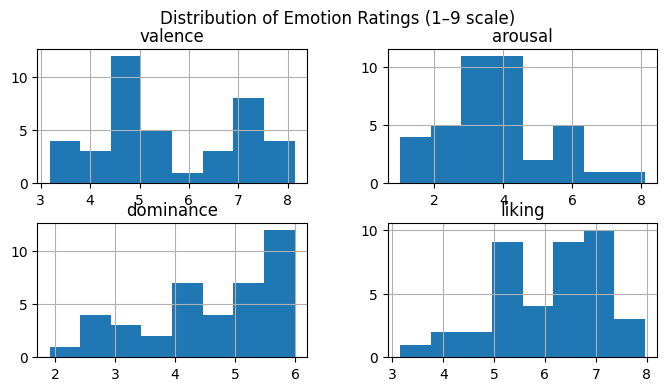

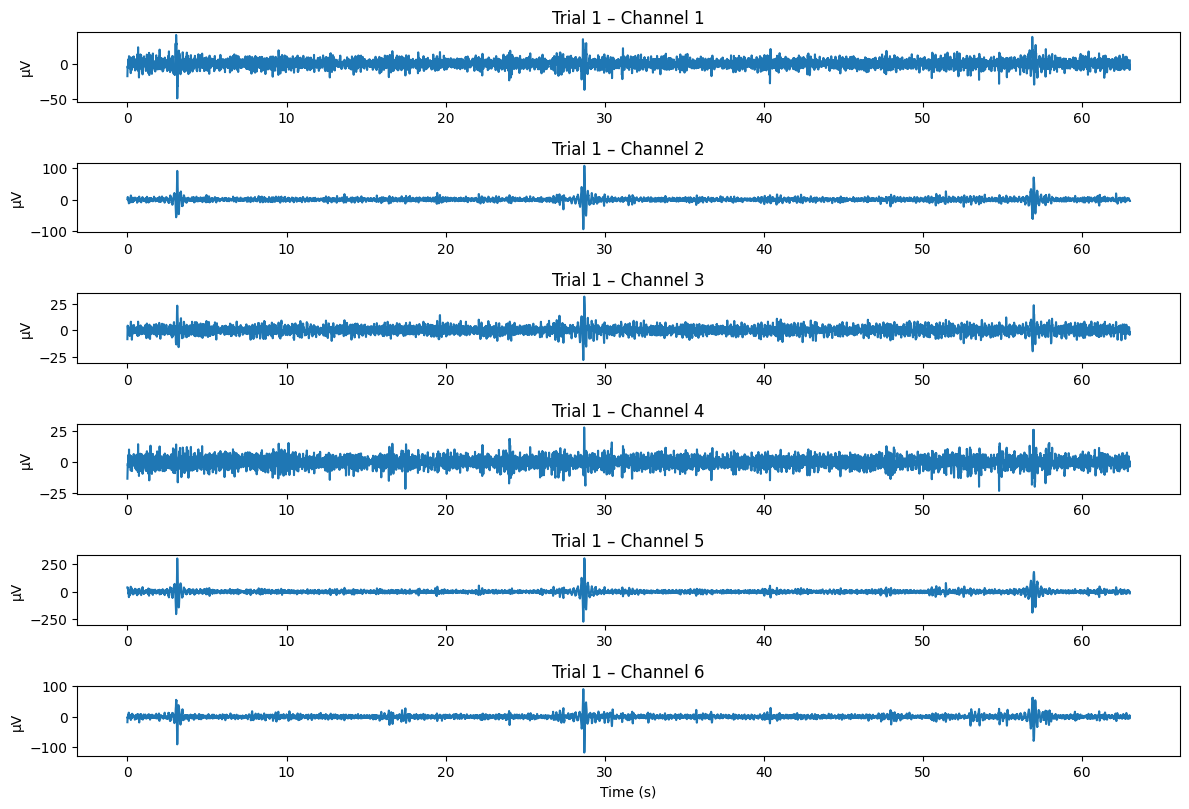

 Visualization complete.

Creating dataset directory at /content/data/deap_dataset_FaceCrops


Downloading...
From (original): https://drive.google.com/uc?id=1-vhALiRCQZPjc5doyyldWbPbpOr8EUcd
From (redirected): https://drive.google.com/uc?id=1-vhALiRCQZPjc5doyyldWbPbpOr8EUcd&confirm=t&uuid=c445be11-120a-41b5-ac25-6130015f0fd3
To: /content/data/deap_dataset_FaceCrops/deap_data.zip
100%|██████████| 562M/562M [00:07<00:00, 78.7MB/s]


Extracting dataset ...
Dataset ready at /content/data/deap_dataset_FaceCrops


In [ ]:
dataset_path = data_download("1uMjlCfL8RO5_e336viq_ABrGzCQ5SDxT","deap_dataset_EEG")
DEAP_ROOT= dataset_path
data_info(dataset_path / "data_preprocessed_python")
dataset_path_VFC = data_download("1-vhALiRCQZPjc5doyyldWbPbpOr8EUcd","deap_dataset_FaceCrops")
CROPS_DIR = dataset_path_VFC

In [ ]:
# =========================
# CONFIG
# =========================
DEAP_ROOT = dataset_path
IMAGE_ROOT = CROPS_DIR
LABEL_TYPE = 1      # 0 = valence, 1 = arousal
MAX_SUBJECT_ID = 22
NUM_FRAMES = 18
BATCH_SIZE = 4
WEIGHT_DECAY = 1e-5
EPOCHS = 20
LR = 1e-3
FREEZE_BACKBONE = True
TRAIN_RATIO = 0.75
SEED = 42
NUM_WORKERS = 4




# 2.1 EEG Preprocessing and Feature Extraction

In [ ]:
# preprocessed.py
"""
Feature extraction utilities for DEAP EEG (preprocessed signals).

This module implements a compact, reusable preprocessing + feature pipeline that:
1) (Optionally) re-references EEG with CAR (common average reference),
2) (Optionally) applies band-pass + notch filtering,
3) splits each 63s DEAP trial into baseline (first 3s) and stimulus (next 60s),
4) extracts DE-like features using log-bandpower (Welch PSD) in standard EEG bands,
5) (Optionally) appends hemispheric asymmetry features (DASM/RASM),
6) (Optionally) baseline-corrects trial features using baseline DE,
7) (Optionally) z-scores features across windows.

All functions are written to work on arrays shaped (C, T):
- C = number of EEG channels
- T = number of time samples
"""


# =========================
# Constants & Configuration
# =========================

# DEAP EEG sampling rate (Hz)
FS: int = 128

# Canonical EEG bands (DEAP "preprocessed" EEG often focuses on 4–45 Hz)
# These are used for bandpower/DE features.
BANDS: Dict[str, Tuple[float, float]] = {
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta":  (13.0, 30.0),
    "gamma": (30.0, 45.0),
}

# Left–Right symmetric electrode pairs for asymmetry features.
# Indices are 0-based and MUST match the channel order in your EEG arrays.
# If your channel ordering differs, update this list accordingly.
LR_PAIRS: List[Tuple[int, int]] = [
    (0, 1),    # Fp1, Fp2
    (2, 3),    # AF3, AF4
    (4, 5),    # F3, F4
    (6, 7),    # F7, F8
    (8, 9),    # FC5, FC6
    (10, 11),  # FC1, FC2
    (12, 13),  # C3, C4
    (14, 15),  # T7, T8
    (16, 17),  # CP5, CP6
    (18, 19),  # CP1, CP2
    (20, 21),  # P3, P4
    (22, 23),  # P7, P8
    (24, 25),  # PO3, PO4
    (26, 27),  # O1, O2
]

# ==============
# Core Utilities
# ==============

def butter_bandpass_notch(
    x: np.ndarray,
    fs: int = FS,
    bp: Tuple[float, float] = (4.0, 45.0),
    notch_freq: float = 50.0,
    notch_q: float = 30.0,
) -> np.ndarray:
    """
    Apply a band-pass filter + notch filter to multi-channel EEG.

    This function is designed for signals shaped (C, T) and filters along time (axis=1).

    Args:
        x:
            EEG signal of shape (C, T), where C=channels and T=samples.
        fs:
            Sampling rate in Hz.
        bp:
            (low, high) cutoffs for band-pass filter in Hz.
        notch_freq:
            Notch frequency (commonly 50 Hz in Europe, 60 Hz in US).
        notch_q:
            Notch quality factor (higher => narrower notch).

    Returns:
        Filtered EEG signal with shape (C, T), dtype float32.

    Notes:
        - Uses zero-phase filtering (filtfilt) to avoid phase distortion.
        - 4th-order Butterworth band-pass is a common simple choice for EEG cleaning.
    """
    # Design band-pass (Butterworth) in normalized frequency (Nyquist = fs/2)
    b, a = butter(4, [bp[0] / (fs / 2), bp[1] / (fs / 2)], btype="bandpass")
    y = filtfilt(b, a, x, axis=1)

    # Design and apply a notch filter to suppress powerline noise
    w0 = notch_freq / (fs / 2)
    b2, a2 = iirnotch(w0=w0, Q=notch_q)
    y = filtfilt(b2, a2, y, axis=1)

    return y.astype(np.float32)


def re_reference_car(x: np.ndarray) -> np.ndarray:
    """
    Common Average Reference (CAR).

    CAR subtracts, at each timepoint, the mean over channels:
        x_car[c, t] = x[c, t] - mean_c(x[c, t])

    Args:
        x:
            EEG signal of shape (C, T).

    Returns:
        CAR-referenced EEG of shape (C, T), dtype float32.

    Why it helps:
        CAR can reduce common-mode noise shared across electrodes and sometimes
        stabilizes downstream feature extraction.
    """
    # Subtract the across-channel mean for each time sample
    return (x - x.mean(axis=0, keepdims=True)).astype(np.float32)


def split_baseline_trial(
    x: np.ndarray,
    fs: int = FS,
    baseline_sec: float = 3.0,
    trial_sec: float = 60.0,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Split a DEAP 63-second trial into baseline and stimulus segments.

    DEAP trials are typically:
    - first 3 seconds: baseline (rest)
    - next 60 seconds: stimulus (watching the video / emotion elicitation)

    Args:
        x:
            EEG for a single trial, shape (C, T) where T ≈ 63 * fs.
        fs:
            Sampling rate (Hz).
        baseline_sec:
            Baseline duration in seconds (default 3s).
        trial_sec:
            Stimulus duration in seconds (default 60s).

    Returns:
        x_base:
            Baseline segment, shape (C, baseline_sec * fs).
        x_trial:
            Stimulus segment, shape (C, trial_sec * fs).

    Raises:
        ValueError:
            If the provided signal does not contain enough samples.
    """
    b = int(round(baseline_sec * fs))
    t = int(round(trial_sec * fs))

    # DEAP expects baseline + trial to fit inside the total time series
    if x.shape[1] < (b + t):
        raise ValueError(
            f"Signal too short for expected DEAP trial length: got {x.shape[1]} samples."
        )

    x_base = x[:, :b]
    x_trial = x[:, b : b + t]
    return x_base.astype(np.float32), x_trial.astype(np.float32)


def window_indices(
    T: int,
    fs: int = FS,
    win_sec: float = 2.0,
    step_sec: float = 1.0,
) -> List[Tuple[int, int]]:
    """
    Generate sliding-window index ranges [start, end) over a signal length T.

    Args:
        T:
            Total number of samples in the signal.
        fs:
            Sampling rate (Hz).
        win_sec:
            Window length in seconds.
        step_sec:
            Step/stride length in seconds.

    Returns:
        A list of (start, end) sample indices, each representing one window.

    Notes:
        - Uses integer rounding of seconds -> samples.
        - If T is shorter than one window, returns a single clipped window.
    """
    w = max(1, int(round(win_sec * fs)))
    s = max(1, int(round(step_sec * fs)))

    idx: List[Tuple[int, int]] = []
    start = 0
    while start + w <= T:
        idx.append((start, start + w))
        start += s

    # Fallback for very short signals
    if not idx:
        idx = [(0, min(w, T))]

    return idx


def _de_log_bandpower_window(
    x_win: np.ndarray,
    fs: int,
    band: Tuple[float, float],
) -> np.ndarray:
    """
    Compute a DE-like feature for one window via log-bandpower.

    Many DEAP pipelines use "Differential Entropy (DE)" features. A practical proxy
    commonly used is log of bandpower in canonical EEG bands:
        feature = log(mean PSD over band)

    Args:
        x_win:
            EEG window of shape (C, W).
        fs:
            Sampling rate (Hz).
        band:
            (f_low, f_high) frequency band in Hz.

    Returns:
        Per-channel log-bandpower feature, shape (C,), dtype float32.

    Implementation details:
        - Welch PSD estimates power spectral density per channel.
        - Then average PSD inside the target band and apply log().
    """
    # Welch PSD per channel: returns frequencies f and PSD pxx shaped (C, F)
    f, pxx = welch(
        x_win,
        fs=fs,
        nperseg=min(256, x_win.shape[1]),
        axis=1
    )

    f_low, f_high = band
    mask = (f >= f_low) & (f < f_high)

    # Mean band power; epsilon avoids log(0) for numerical safety
    bp = pxx[:, mask].mean(axis=1) + 1e-12
    return np.log(bp).astype(np.float32)


def compute_de_features(
    x: np.ndarray,
    fs: int = FS,
    bands: Dict[str, Tuple[float, float]] = BANDS,
    win_sec: float = 2.0,
    step_sec: float = 1.0,
    include_asym: bool = True,
    lr_pairs: Optional[List[Tuple[int, int]]] = None,
) -> Tuple[np.ndarray, Dict[str, Any]]:
    """
    Compute DE/log-bandpower features over sliding windows, with optional asymmetry.

    Output shape convention:
        features: (F, Nwin)
        - rows are feature dimensions
        - columns are windows over time

    Base (per-band per-channel) features:
        For each window and each band, compute (C,) log-bandpower.
        These are stacked across bands to form (C * nbands,) per window.

    Optional asymmetry features:
        For each band and each left/right pair (L, R):
        - DASM: L - R  (difference)
        - RASM: L / (R + eps) (ratio)
        These are appended after base features.

    Args:
        x:
            EEG of shape (C, T) for the segment you want to featurize.
        fs:
            Sampling rate (Hz).
        bands:
            Dict mapping band_name -> (f_low, f_high).
        win_sec:
            Window length in seconds.
        step_sec:
            Step size in seconds.
        include_asym:
            If True, append DASM and RASM asymmetry features.
        lr_pairs:
            Optional left-right electrode pairs override (0-based indices).

    Returns:
        features:
            Array of shape (F, Nwin), dtype float32.
        info:
            Metadata dict (band names, window indices, and intermediate shapes).
    """
    C, T = x.shape

    # Compute which sample ranges define each temporal window
    idx = window_indices(T, fs, win_sec, step_sec)

    band_list = list(bands.values())
    nbands = len(band_list)

    # Base features: (C * nbands, Nwin)
    base = np.zeros((C * nbands, len(idx)), dtype=np.float32)

    # For each window, compute log-bandpower per band then stack them
    for j, (a, b) in enumerate(idx):
        xw = x[:, a:b]  # (C, W)

        cols = []
        for band in band_list:
            # Each call returns (C,) for this band in this window
            cols.append(_de_log_bandpower_window(xw, fs, band))

        # Stack bands: [band0(C), band1(C), ...] => (C*nbands,)
        base[:, j] = np.concatenate(cols, axis=0)

    # If asymmetry is disabled, we are done
    if not include_asym:
        return base, {
            "bands": list(bands.keys()),
            "windows": idx,
            "base_shape": base.shape
        }

    # Use default LR pairs unless an override is provided
    pairs = LR_PAIRS if lr_pairs is None else lr_pairs
    n_pairs = len(pairs)

    # Asymmetry features: DASM + RASM for each band and each LR pair
    # Shape: (n_pairs * nbands * 2, Nwin)
    asym = np.zeros((n_pairs * nbands * 2, len(idx)), dtype=np.float32)

    for j in range(base.shape[1]):
        # base[:, j] is (C*nbands,), split back into per-band vectors of length C
        band_blocks = np.split(base[:, j], nbands)

        block_cols = []
        for band_vec in band_blocks:
            dasm = []
            rasm = []
            for (l, r) in pairs:
                L = band_vec[l]
                R = band_vec[r]
                dasm.append(L - R)
                rasm.append(L / (R + 1e-6))  # eps avoids divide-by-zero
            block_cols.append(np.array(dasm, dtype=np.float32))
            block_cols.append(np.array(rasm, dtype=np.float32))

        # Concatenate per-band [DASM, RASM] blocks into one asym vector
        asym[:, j] = np.concatenate(block_cols, axis=0)

    # Final feature matrix: base features + asymmetry features
    feats = np.concatenate([base, asym], axis=0)

    info = {
        "bands": list(bands.keys()),
        "windows": idx,
        "base_shape": base.shape,
        "asym_shape": asym.shape,
        "feat_shape": feats.shape,
        "include_asym": include_asym,
        "n_lr_pairs": n_pairs,
    }
    return feats, info

# ===================
# Normalization Tools
# ===================

def baseline_de(
    x_base: np.ndarray,
    fs: int = FS,
    win_sec: float = 1.0,
) -> np.ndarray:
    """
    Compute baseline DE/log-bandpower features from the baseline segment only.

    This uses non-overlapping windows (step_sec == win_sec) so the baseline is
    summarized cleanly.

    Args:
        x_base:
            Baseline EEG segment of shape (C, T_base), e.g. 3 seconds in DEAP.
        fs:
            Sampling rate (Hz).
        win_sec:
            Window length in seconds for baseline windows.

    Returns:
        baseline_vec:
            Mean baseline feature vector of shape (C * nbands,).
            (No asymmetry is computed here by design.)
    """
    F_base, _info = compute_de_features(
        x_base,
        fs=fs,
        win_sec=win_sec,
        step_sec=win_sec,
        include_asym=False
    )

    # Average baseline features across baseline windows -> a single vector
    return F_base.mean(axis=1)  # (C*nbands,)


def baseline_correct_features(
    feat: np.ndarray,
    baseline_vec: np.ndarray,
    include_asym: bool = True,
    nbands: int = 4,
) -> np.ndarray:
    """
    Apply baseline correction by subtracting baseline feature means.

    This function assumes the first `base_len` rows of `feat` correspond to the
    base band features (C * nbands). Any appended asymmetry features (if present)
    are left unchanged because they are already relative quantities.

    Args:
        feat:
            Trial feature matrix of shape (F, Nwin).
        baseline_vec:
            Baseline feature vector of shape (C * nbands,).
        include_asym:
            Present for readability/consistency; asym features are not corrected here.
        nbands:
            Number of frequency bands used for base features.

    Returns:
        corrected:
            Baseline-corrected feature matrix, same shape as `feat`.
    """
    corrected = feat.copy()
    base_len = baseline_vec.shape[0]

    # Subtract baseline per feature dimension for the base band features only
    corrected[:base_len, :] = corrected[:base_len, :] - baseline_vec[:, None]

    # Asymmetry features remain unchanged
    return corrected


def zscore_features(F: np.ndarray, axis: int = 1, eps: float = 1e-8) -> np.ndarray:
    """
    Z-score normalize a feature matrix.

    Default behavior (axis=1):
        Normalize each feature dimension across windows:
            for each row d: (F[d, :] - mean) / std

    Args:
        F:
            Feature matrix of shape (D, N).
        axis:
            Axis along which to compute mean/std.
            - axis=1: per feature across windows (common for time-window features)
            - axis=0: per window across features (less common)
        eps:
            Numerical stability term to avoid divide-by-zero.

    Returns:
        Z-scored feature matrix with the same shape as F.
    """
    mu = F.mean(axis=axis, keepdims=True)
    sd = F.std(axis=axis, keepdims=True) + eps
    return (F - mu) / sd

# ===========================
# High-level Pipeline Wrapper
# ===========================

def build_deap_features_pipeline(
    x_trial_63s: np.ndarray,
    fs: int = FS,
    use_car: bool = True,
    filter_first: bool = True,
    bp: Tuple[float, float] = (4.0, 45.0),
    notch_freq: float = 50.0,
    notch_q: float = 30.0,
    win_sec: float = 2.0,
    step_sec: float = 1.0,
    include_asym: bool = True,
    do_baseline: bool = True,
    baseline_win_sec: float = 1.0,
    do_zscore: bool = True,
) -> Tuple[np.ndarray, Dict[str, Any]]:
    """
    End-to-end DEAP-style preprocessing pipeline returning windowed DE features.

    High-level steps:
        1) cast to float32
        2) optional CAR re-referencing
        3) optional band-pass + notch filtering
        4) split 63s trial into baseline (3s) and stimulus (60s)
        5) extract DE/log-bandpower features on the 60s stimulus
        6) optional baseline correction using baseline DE
        7) optional z-score normalization across windows

    Args:
        x_trial_63s:
            One full DEAP trial shaped (C, T=63*fs).
        fs:
            Sampling rate (Hz).
        use_car:
            If True, apply common average reference.
        filter_first:
            If True, apply band-pass + notch filtering.
        bp, notch_freq, notch_q:
            Filter parameters.
        win_sec, step_sec:
            Sliding window length and step (seconds) for stimulus features.
        include_asym:
            If True, append DASM/RASM features.
        do_baseline:
            If True, compute baseline DE (from 3s) and subtract from base features.
        baseline_win_sec:
            Window length for baseline DE (non-overlapping).
        do_zscore:
            If True, z-score features per feature dimension across windows.

    Returns:
        feats:
            Feature matrix of shape (F, Nwin), float32.
        meta:
            Metadata dictionary describing the pipeline configuration and shapes.
    """
    # Ensure consistent dtype early (helps performance + stability)
    x = x_trial_63s.astype(np.float32)

    # Optional spatial re-reference to reduce common-mode noise
    if use_car:
        x = re_reference_car(x)

    # Optional frequency-domain cleaning (band-pass + notch)
    if filter_first:
        x = butter_bandpass_notch(
            x,
            fs=fs,
            bp=bp,
            notch_freq=notch_freq,
            notch_q=notch_q
        )

    # Separate baseline and stimulus parts according to DEAP trial timing
    x_base, x_stim = split_baseline_trial(
        x,
        fs=fs,
        baseline_sec=3.0,
        trial_sec=60.0
    )

    # Extract features over the stimulus part using sliding windows
    feats, info = compute_de_features(
        x_stim,
        fs=fs,
        win_sec=win_sec,
        step_sec=step_sec,
        include_asym=include_asym
    )

    # Baseline correction only affects the base band features (C*nbands)
    if do_baseline:
        base_vec = baseline_de(
            x_base,
            fs=fs,
            win_sec=baseline_win_sec
        )
        feats = baseline_correct_features(
            feats,
            baseline_vec=base_vec,
            include_asym=include_asym,
            nbands=len(BANDS),
        )

    # Z-score across windows to stabilize learning / reduce scale differences
    if do_zscore:
        feats = zscore_features(feats, axis=1, eps=1e-8)

    # Collect useful metadata for debugging and reproducibility
    meta = {
        "fs": fs,
        "bp": bp,
        "notch_freq": notch_freq,
        "notch_q": notch_q,
        "win_sec": win_sec,
        "step_sec": step_sec,
        "include_asym": include_asym,
        "do_baseline": do_baseline,
        "baseline_win_sec": baseline_win_sec,
        "do_zscore": do_zscore,
        "feat_shape": feats.shape,
        "bands": list(BANDS.keys()),
        "lr_pairs": LR_PAIRS,
        "windows": info.get("windows"),
        "base_shape": info.get("base_shape"),
        "asym_shape": info.get("asym_shape") if include_asym else None,
    }
    return feats.astype(np.float32), meta

# ================
# Quick Smoke Test
# ================

def _smoke_test() -> None:
    """
    Minimal sanity test for the feature pipeline using synthetic EEG.

    What it checks:
    - Output is 2D (F, Nwin)
    - No NaNs or infs appear
    - Prints feature shape and a small subset of meta settings

    This is useful when refactoring or moving code between files/notebooks.
    """
    # Use 32 channels (common EEG setups) and one DEAP-length trial (63s)
    C = 32
    T = 63 * FS

    # Random synthetic EEG-like signal (scaled to a microvolt-ish magnitude)
    rng = np.random.default_rng(0)
    x = rng.standard_normal((C, T)).astype(np.float32) * 5e-6

    # Run the full pipeline with typical settings
    feats, meta = build_deap_features_pipeline(
        x,
        fs=FS,
        use_car=True,
        filter_first=True,
        win_sec=2.0,
        step_sec=1.0,
        include_asym=True,
        do_baseline=True,
        baseline_win_sec=1.0,
        do_zscore=True,
    )

    # Basic assertions for quick failure if something is wrong
    assert feats.ndim == 2
    assert np.isfinite(feats).all(), "NaNs or infs in features"

    print("✅ Smoke test passed. Feature shape:", feats.shape)
    print("Meta:", {k: meta[k] for k in ("feat_shape", "win_sec", "step_sec", "include_asym")})



_smoke_test()


✅ Smoke test passed. Feature shape: (240, 59)
Meta: {'feat_shape': (240, 59), 'win_sec': 2.0, 'step_sec': 1.0, 'include_asym': True}


#2.2 VIDEO Preprocessing (Don't RUN)

In [ ]:
dataset_path_V = data_download("1qL7NCnakfNVdhFdjKoIQgCtG-mTj6Isw","deap_dataset_Video")
dataset_path_V= dataset_path_V / "content" / "drive" / "MyDrive" / "deap_video"
VIDEO_DIR = dataset_path_V


Creating dataset directory at /content/data/deap_dataset_Video


Downloading...
From (original): https://drive.google.com/uc?id=1qL7NCnakfNVdhFdjKoIQgCtG-mTj6Isw
From (redirected): https://drive.google.com/uc?id=1qL7NCnakfNVdhFdjKoIQgCtG-mTj6Isw&confirm=t&uuid=d350f1de-f1fc-4a5d-bb4a-997325312d79
To: /content/data/deap_dataset_Video/deap_data.zip
100%|██████████| 16.4G/16.4G [03:49<00:00, 71.5MB/s]


Extracting dataset ...
Dataset ready at /content/data/deap_dataset_Video
Creating dataset directory at /content/data/deap_dataset_Video_Frames


Downloading...
From (original): https://drive.google.com/uc?id=10Yu0eL4_L6He1TuLzGed8s-4digNXw5E
From (redirected): https://drive.google.com/uc?id=10Yu0eL4_L6He1TuLzGed8s-4digNXw5E&confirm=t&uuid=4e932d5f-9772-44a1-a9dc-e8f9fae65c39
To: /content/data/deap_dataset_Video_Frames/deap_data.zip
100%|██████████| 1.38G/1.38G [00:20<00:00, 65.9MB/s]


Extracting dataset ...
Dataset ready at /content/data/deap_dataset_Video_Frames


In [ ]:
FRAMES_DIR = Path("/content/data/deap_dataset_Video_Frames")
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".webm"}

video_paths = sorted([p for p in VIDEO_DIR.rglob("*") if p.suffix.lower() in VIDEO_EXTS])

print(f"Found {len(video_paths)} videos")
for p in video_paths[:5]:
    print(p)

Found 874 videos
/content/data/deap_dataset_Video/content/drive/MyDrive/deap_video/s01/s01_trial01.avi
/content/data/deap_dataset_Video/content/drive/MyDrive/deap_video/s01/s01_trial02.avi
/content/data/deap_dataset_Video/content/drive/MyDrive/deap_video/s01/s01_trial03.avi
/content/data/deap_dataset_Video/content/drive/MyDrive/deap_video/s01/s01_trial04.avi
/content/data/deap_dataset_Video/content/drive/MyDrive/deap_video/s01/s01_trial05.avi


In [ ]:
def extract_n_frames_from_video(video_path, output_root, num_frames=18, overwrite=False):
    """
    Extract num_frames evenly spaced frames from one video and save them.

    Returns a dictionary with useful metadata.
    """
    video_path = Path(video_path)
    output_root = Path(output_root)

    # Create one folder per video
    video_id = video_path.stem
    save_dir = output_root / video_id
    save_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {
            "video_path": str(video_path),
            "video_id": video_id,
            "success": False,
            "reason": "could_not_open",
            "saved_frames": 0,
        }

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    if total_frames <= 0:
        cap.release()
        return {
            "video_path": str(video_path),
            "video_id": video_id,
            "success": False,
            "reason": "invalid_frame_count",
            "saved_frames": 0,
        }

    # 18 evenly spaced indices from 0 to total_frames - 1
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    saved_paths = []
    used_indices = []

    for i, frame_idx in enumerate(frame_indices):
        out_path = save_dir / f"{video_id}_frame_{i:02d}.jpg"

        if out_path.exists() and not overwrite:
            saved_paths.append(str(out_path))
            used_indices.append(int(frame_idx))
            continue

        # Jump to the chosen frame index
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        ok, frame = cap.read()

        if not ok or frame is None:
            continue

        # Save as image
        cv2.imwrite(str(out_path), frame)

        saved_paths.append(str(out_path))
        used_indices.append(int(frame_idx))

    cap.release()

    return {
        "video_path": str(video_path),
        "video_id": video_id,
        "success": True,
        "reason": "ok",
        "saved_frames": len(saved_paths),
        "total_frames": total_frames,
        "fps": fps,
        "frame_indices": used_indices,
        "saved_paths": saved_paths,
    }

In [ ]:
example_video = video_paths[0]

result = extract_n_frames_from_video(
    video_path=example_video,
    output_root=FRAMES_DIR,
    num_frames=18,
    overwrite=True
)

print(result["video_id"])
print("success:", result["success"])
print("saved_frames:", result["saved_frames"])
print("frame_indices:", result["frame_indices"])

s01_trial01
success: True
saved_frames: 18
frame_indices: [0, 176, 352, 529, 705, 882, 1058, 1234, 1411, 1587, 1764, 1940, 2116, 2293, 2469, 2646, 2822, 2999]


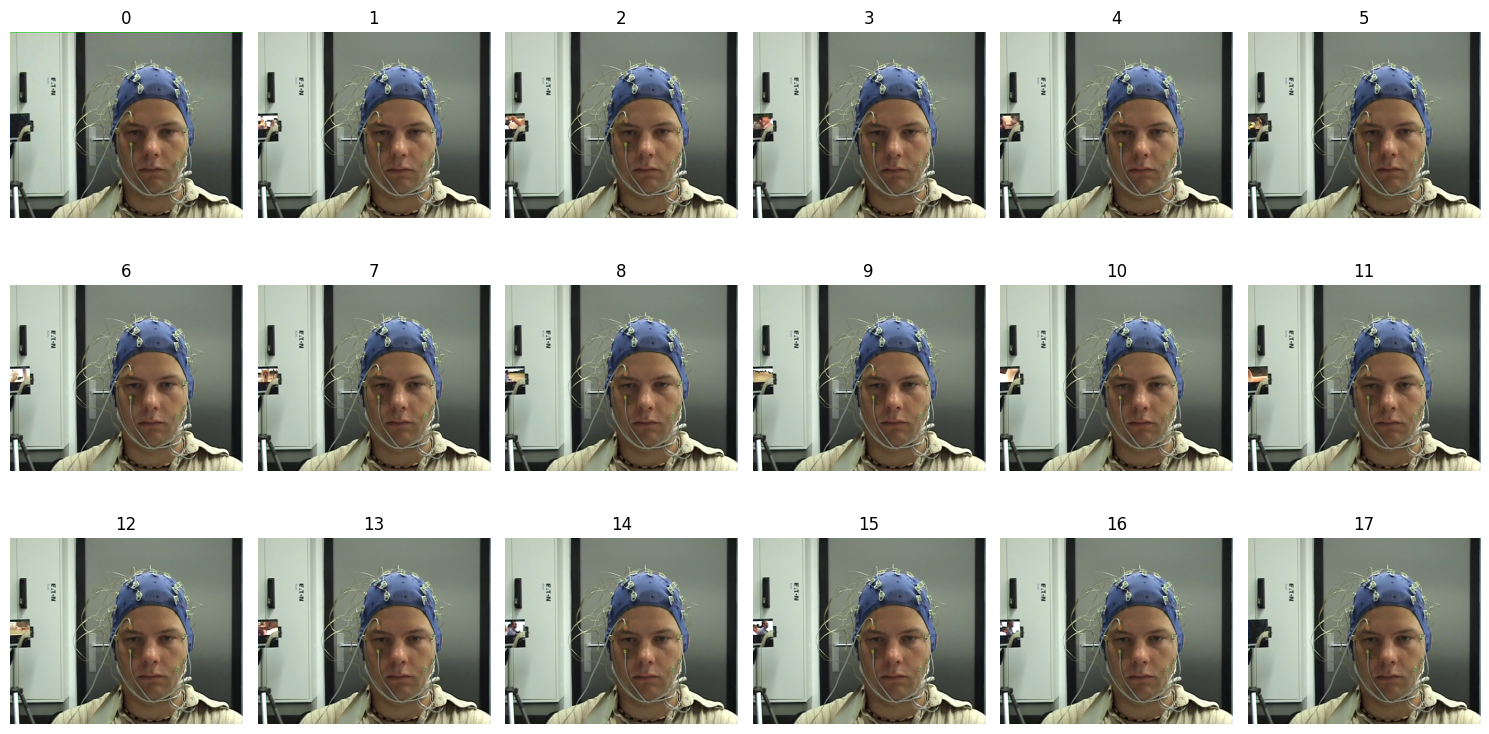

In [ ]:
def show_extracted_frames(frame_paths, cols=6, figsize=(15, 8)):
    rows = int(np.ceil(len(frame_paths) / cols))
    plt.figure(figsize=figsize)

    for i, frame_path in enumerate(frame_paths):
        img_bgr = cv2.imread(frame_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_rgb)
        plt.title(f"{i}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_extracted_frames(result["saved_paths"], cols=6)

In [ ]:
all_results = []

for video_path in tqdm(video_paths):
    result = extract_n_frames_from_video(
        video_path=video_path,
        output_root=FRAMES_DIR,
        num_frames=18,
        overwrite=False
    )
    all_results.append(result)

print("Done.")

100%|██████████| 874/874 [1:01:52<00:00,  4.25s/it]

Done.


In [ ]:
dataset_path_VF = data_download("10Yu0eL4_L6He1TuLzGed8s-4digNXw5E","deap_dataset_Video_Frames")
FRAMES_DIR = dataset_path_VF
CROPS_DIR = Path("/content/data/deap_dataset_FaceCrops")
CROPS_DIR.mkdir(parents=True, exist_ok=True)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
face_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(face_cascade_path)

print("Loaded cascade:", face_cascade_path)

Loaded cascade: /usr/local/lib/python3.12/dist-packages/cv2/data/haarcascade_frontalface_default.xml


In [ ]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

rows = []
trial_folders = sorted([p for p in FRAMES_DIR.iterdir() if p.is_dir()])

for trial_folder in trial_folders:
    folder_name = trial_folder.name  # example: s01_trial01

    m = re.match(r"s(\d+)_trial(\d+)", folder_name, flags=re.IGNORECASE)
    if m is None:
        print(f"Skipping unexpected folder name: {folder_name}")
        continue

    subject_id = int(m.group(1))
    trial_id = int(m.group(2))

    frame_paths = sorted([p for p in trial_folder.iterdir() if p.suffix.lower() in IMAGE_EXTS])

    for frame_order, frame_path in enumerate(frame_paths):
        rows.append({
            "subject_id": subject_id,
            "trial_id": trial_id,
            "trial_name": folder_name,
            "frame_order": frame_order,
            "frame_path": str(frame_path)
        })

frame_df = pd.DataFrame(rows)
print(frame_df.head())
print("Total frames:", len(frame_df))

   subject_id  trial_id   trial_name  frame_order  \
0           1         1  s01_trial01            0   
1           1         1  s01_trial01            1   
2           1         1  s01_trial01            2   
3           1         1  s01_trial01            3   
4           1         1  s01_trial01            4   

                                          frame_path  
0  /content/data/deap_dataset_Video_Frames/s01_tr...  
1  /content/data/deap_dataset_Video_Frames/s01_tr...  
2  /content/data/deap_dataset_Video_Frames/s01_tr...  
3  /content/data/deap_dataset_Video_Frames/s01_tr...  
4  /content/data/deap_dataset_Video_Frames/s01_tr...  
Total frames: 15732


In [ ]:
def detect_face_box(image_bgr, face_cascade):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    # Try standard grayscale first
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.05,
        minNeighbors=4,
        minSize=(60, 60)
    )

    # If nothing found, try contrast-enhanced grayscale
    if len(faces) == 0:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        gray2 = clahe.apply(gray)

        faces = face_cascade.detectMultiScale(
            gray2,
            scaleFactor=1.05,
            minNeighbors=3,
            minSize=(60, 60)
        )

    if len(faces) == 0:
        return None

    # keep largest face
    areas = [w * h for (x, y, w, h) in faces]
    idx = int(np.argmax(areas))
    x, y, w, h = faces[idx]
    return int(x), int(y), int(w), int(h)


def expand_box(x, y, w, h, img_w, img_h, margin=0.35):
    mx = int(w * margin)
    my = int(h * margin)

    x1 = max(0, x - mx)
    y1 = max(0, y - my)
    x2 = min(img_w, x + w + mx)
    y2 = min(img_h, y + h + my)

    return x1, y1, x2, y2

def fallback_center_box(img_w, img_h):
    # central crop, slightly biased upward for face/head
    crop_w = int(img_w * 0.55)
    crop_h = int(img_h * 0.72)

    cx = img_w // 2
    cy = int(img_h * 0.42)

    x1 = max(0, cx - crop_w // 2)
    y1 = max(0, cy - crop_h // 2)
    x2 = min(img_w, x1 + crop_w)
    y2 = min(img_h, y1 + crop_h)

    return x1, y1, x2, y2

def estimate_trial_box(frame_paths, face_cascade, margin=0.35):
    raw_boxes = []
    first_img_shape = None

    for frame_path in frame_paths:
        img_bgr = cv2.imread(str(frame_path))
        if img_bgr is None:
            continue

        if first_img_shape is None:
            first_img_shape = img_bgr.shape

        box = detect_face_box(img_bgr, face_cascade)
        if box is not None:
            raw_boxes.append(box)

    if first_img_shape is None:
        return None, "failed_read", 0

    img_h, img_w = first_img_shape[:2]

    if len(raw_boxes) > 0:
        boxes = np.array(raw_boxes)
        x, y, w, h = np.median(boxes, axis=0).astype(int)
        x1, y1, x2, y2 = expand_box(x, y, w, h, img_w, img_h, margin=margin)
        return (x1, y1, x2, y2), "detected", len(raw_boxes)

    # fallback if no face detected in any frame
    x1, y1, x2, y2 = fallback_center_box(img_w, img_h)
    return (x1, y1, x2, y2), "fallback_center", 0

In [ ]:
results = []

grouped = frame_df.groupby(["subject_id", "trial_id", "trial_name"])

for (subject_id, trial_id, trial_name), g in tqdm(grouped, total=len(grouped)):
    g = g.sort_values("frame_order")
    frame_paths = [Path(p) for p in g["frame_path"].tolist()]

    trial_box, box_source, n_detected = estimate_trial_box(
        frame_paths=frame_paths,
        face_cascade=face_cascade,
        margin=0.35
    )

    if trial_box is None:
        for _, row in g.iterrows():
            results.append({
                "subject_id": subject_id,
                "trial_id": trial_id,
                "trial_name": trial_name,
                "frame_order": row["frame_order"],
                "frame_path": row["frame_path"],
                "face_path": None,
                "box_source": "failed_read",
                "n_detected_seed_frames": 0
            })
        continue

    x1, y1, x2, y2 = trial_box

    out_dir = CROPS_DIR / trial_name
    out_dir.mkdir(parents=True, exist_ok=True)

    for _, row in g.iterrows():
        frame_path = Path(row["frame_path"])
        frame_order = row["frame_order"]

        img_bgr = cv2.imread(str(frame_path))
        if img_bgr is None:
            results.append({
                "subject_id": subject_id,
                "trial_id": trial_id,
                "trial_name": trial_name,
                "frame_order": frame_order,
                "frame_path": str(frame_path),
                "face_path": None,
                "box_source": "failed_read",
                "n_detected_seed_frames": n_detected
            })
            continue

        crop_bgr = img_bgr[y1:y2, x1:x2]
        out_path = out_dir / f"face_{frame_order:02d}.jpg"
        cv2.imwrite(str(out_path), crop_bgr)

        results.append({
            "subject_id": subject_id,
            "trial_id": trial_id,
            "trial_name": trial_name,
            "frame_order": frame_order,
            "frame_path": str(frame_path),
            "face_path": str(out_path),
            "box_source": box_source,
            "n_detected_seed_frames": n_detected,
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2
        })

face_df2 = pd.DataFrame(results)
face_df2.head()

100%|██████████| 874/874 [34:27<00:00,  2.37s/it]


,subject_id,trial_id,trial_name,frame_order,frame_path,face_path,box_source,n_detected_seed_frames,x1,y1,x2,y2
0,1,1,s01_trial01,0,/content/data/deap_dataset_Video_Frames/s01_tr...,/content/data/deap_dataset_FaceCrops/s01_trial...,detected,18,196,108,674,576
1,1,1,s01_trial01,1,/content/data/deap_dataset_Video_Frames/s01_tr...,/content/data/deap_dataset_FaceCrops/s01_trial...,detected,18,196,108,674,576
2,1,1,s01_trial01,2,/content/data/deap_dataset_Video_Frames/s01_tr...,/content/data/deap_dataset_FaceCrops/s01_trial...,detected,18,196,108,674,576
3,1,1,s01_trial01,3,/content/data/deap_dataset_Video_Frames/s01_tr...,/content/data/deap_dataset_FaceCrops/s01_trial...,detected,18,196,108,674,576
4,1,1,s01_trial01,4,/content/data/deap_dataset_Video_Frames/s01_tr...,/content/data/deap_dataset_FaceCrops/s01_trial...,detected,18,196,108,674,576


In [ ]:
csv_path = CROPS_DIR / "frame_face_metadata_trialbox.csv"
face_df2.to_csv(csv_path, index=False)

print("Saved:", csv_path)
print(face_df2["box_source"].value_counts())

Saved: /content/data/deap_dataset_FaceCrops/frame_face_metadata_trialbox.csv
box_source
detected    15732
Name: count, dtype: int64


In [ ]:
trial_box_stats = (
    face_df2.groupby(["subject_id", "trial_id", "trial_name"])
    .agg(
        box_source=("box_source", "first"),
        n_detected_seed_frames=("n_detected_seed_frames", "first"),
        n_saved_frames=("face_path", lambda x: x.notna().sum())
    )
    .reset_index()
)

trial_box_stats.head(20)

,subject_id,trial_id,trial_name,box_source,n_detected_seed_frames,n_saved_frames
0,1,1,s01_trial01,detected,18,18
1,1,2,s01_trial02,detected,18,18
2,1,3,s01_trial03,detected,18,18
3,1,4,s01_trial04,detected,18,18
4,1,5,s01_trial05,detected,18,18
5,1,6,s01_trial06,detected,18,18
6,1,7,s01_trial07,detected,18,18
7,1,8,s01_trial08,detected,18,18
8,1,9,s01_trial09,detected,18,18
9,1,10,s01_trial10,detected,18,18


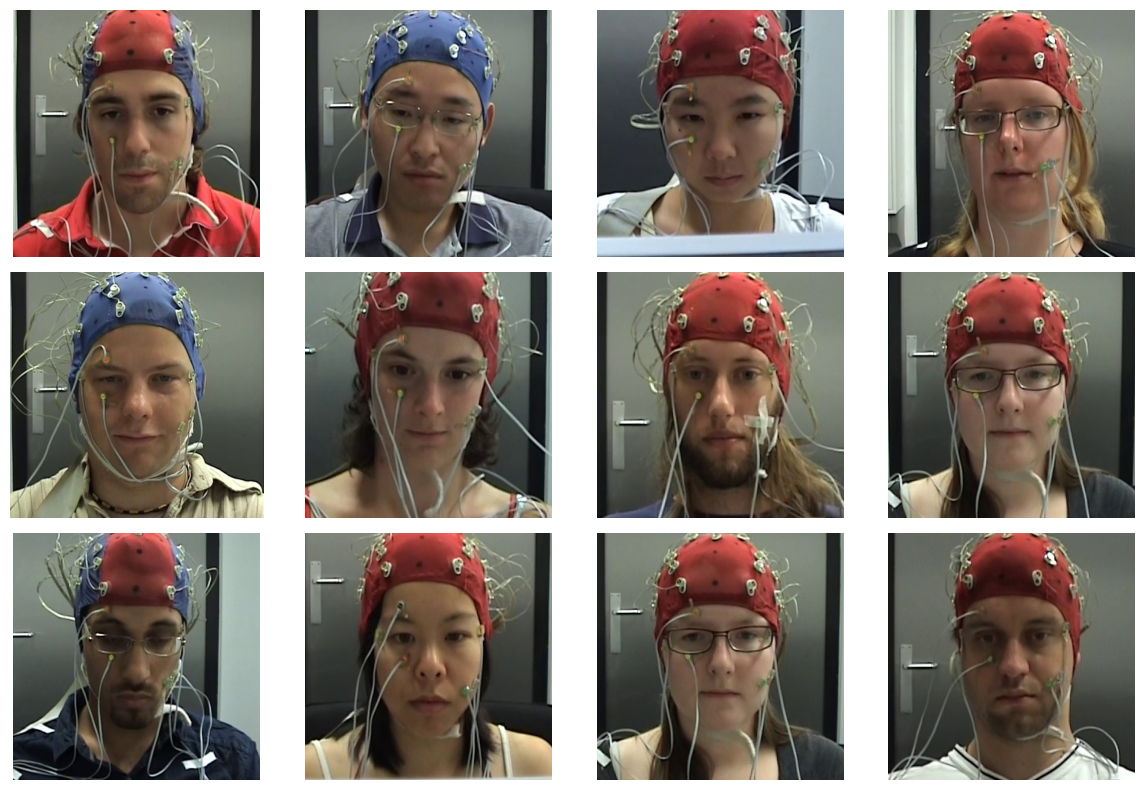

In [ ]:
sample_ok = face_df2.dropna(subset=["face_path"]).sample(12, random_state=42)

plt.figure(figsize=(12, 8))
for i, p in enumerate(sample_ok["face_path"].tolist()):
    img_bgr = cv2.imread(p)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img_rgb)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import shutil
from google.colab import files

zip_name = "/content/face_croped_zip"

shutil.make_archive(zip_name, 'zip', CROPS_DIR)
files.download(zip_name + ".zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 3. Dataset Loading, Caching, and Shared Splits

In [ ]:


# =============================================================================
# Cache helpers (to avoid recomputing expensive preprocessing for modes 1/2/3)
# =============================================================================

def _mode_cache_dir(
    root: Path,
    mode: int,
    l: int,
    filt_bp: Tuple[float, float],
    notch_freq: float,
    notch_q: float,
    win_sec: float,
    step_sec: float,
    include_asym: bool,
) -> Path:
    """
    Build the cache directory path for one exact preprocessing configuration.

    The cache name is made from all important preprocessing settings so that
    changing any of them creates a different cache folder.

    This prevents accidentally reusing old cached data when parameters such as:
    - label type
    - filtering values
    - window length / step
    - asymmetry features

    are changed.

    Args:
        root: Root directory where cache folders are stored.
        mode: Data mode (0, 1, 2, or 3).
        l: Label type (for example valence or arousal).
        filt_bp: Band-pass filter range as (low, high).
        notch_freq: Notch filter frequency.
        notch_q: Notch filter quality factor.
        win_sec: Window length in seconds.
        step_sec: Window step in seconds.
        include_asym: Whether asymmetry features are included.

    Returns:
        Path to the cache directory corresponding to this configuration.
    """
    bp_low, bp_high = filt_bp

    tag = (
        f"data_mode{mode}"
        f"_label{l}"
        f"_bp{bp_low}-{bp_high}"
        f"_notch{notch_freq}_q{notch_q}"
        f"_win{win_sec}_step{step_sec}"
        f"_asym{int(include_asym)}"
    )

    return root / tag

def _cache_manifest_path(mode_dir: Path) -> Path:
    """
    Return the path of the manifest file inside a cache directory.

    The manifest is a small JSON file listing the saved subject files.
    """
    return mode_dir / "manifest.json"

def _cache_exists(mode_dir: Path) -> bool:
    """
    Check whether a cache directory looks usable.

    A cache is considered valid if:
    - the directory exists
    - manifest.json exists
    - at least one subject .npz file exists

    Args:
        mode_dir: Cache directory to check.

    Returns:
        True if the cache looks valid, otherwise False.
    """
    m = _cache_manifest_path(mode_dir)
    return mode_dir.exists() and m.exists() and any(mode_dir.glob("*.npz"))

def _save_mode_cache(mode_dir: Path, subjects: Dict[str, Dict[str, Any]]) -> None:
    """
    Save all subject data for one preprocessing mode into a cache directory.

    Storage design:
    - one compressed .npz file per subject
    - one small manifest.json listing these files

    This format is simple, easy to inspect, and convenient to reload later.

    Args:
        mode_dir: Directory where the cache will be written.
        subjects: Dictionary keyed by subject id (for example "s01").
            Each value contains the processed arrays and optional metadata.
    """
    mode_dir.mkdir(parents=True, exist_ok=True)
    files = []

    for sid, payload in subjects.items():
        # Store mandatory fields for every subject.
        arrs = {
            "mode": np.array(payload.get("mode", -1), dtype=np.int32),
            "X": np.asarray(payload["X"]),
            "y": np.asarray(payload["y"]),
        }

        # Add optional arrays only when they are available.
        if payload.get("Y_raw") is not None:
            arrs["Y_raw"] = np.asarray(payload["Y_raw"])
        if payload.get("X_trials_raw") is not None:
            arrs["X_trials_raw"] = np.asarray(payload["X_trials_raw"])
        if payload.get("win_index") is not None:
            arrs["win_index"] = np.asarray(payload["win_index"], dtype=np.int32)

        # Save example metadata as JSON bytes because .npz does not directly store dicts safely.
        if payload.get("meta_example") is not None:
            meta_json = json.dumps(payload["meta_example"], default=float)
            arrs["meta_json"] = np.frombuffer(meta_json.encode("utf-8"), dtype=np.uint8)

        # Save one compressed file per subject.
        fpath = mode_dir / f"{sid}.npz"
        np.savez_compressed(fpath, **arrs)
        files.append(fpath.name)

    # Save the list of cache files so loading is straightforward later.
    with open(_cache_manifest_path(mode_dir), "w", encoding="utf-8") as fh:
        json.dump({"files": files}, fh, indent=2)

def _load_mode_cache(mode_dir: Path) -> Dict[str, Dict[str, Any]]:
    """
    Load all cached subject data from a cache directory.

    This restores the subject dictionary in the same general format used by
    the preprocessing pipeline.

    Args:
        mode_dir: Cache directory to read.

    Returns:
        Dictionary keyed by subject id with arrays and optional metadata.
    """
    with open(_cache_manifest_path(mode_dir), "r", encoding="utf-8") as fh:
        mani = json.load(fh)

    subjects: Dict[str, Dict[str, Any]] = {}
    for fname in mani["files"]:
        # allow_pickle=False keeps loading safer and avoids hidden Python objects.
        D = np.load(mode_dir / fname, allow_pickle=False)
        sid = Path(fname).stem

        payload: Dict[str, Any] = {
            "mode": int(D["mode"]),
            "X": D["X"],
            "y": D["y"],
            "Y_raw": D["Y_raw"] if "Y_raw" in D.files else None,
            "X_trials_raw": D["X_trials_raw"] if "X_trials_raw" in D.files else None,
        }

        # Restore optional fields if they were saved.
        if "win_index" in D.files:
            payload["win_index"] = D["win_index"]
        if "meta_json" in D.files:
            payload["meta_example"] = json.loads(bytes(D["meta_json"]).decode("utf-8"))

        subjects[sid] = payload

    return subjects

def download_preprocessed_data(
    root: Path | str,
    mode: int,
    l: int = 0,
    filt_bp: Tuple[float, float] = (4.0, 45.0),
    notch_freq: float = 50.0,
    notch_q: float = 30.0,
    win_sec: float = 2.0,
    step_sec: float = 1.0,
    include_asym: bool = True,
) -> Path:
    """
    Zip an existing cache directory and optionally trigger a Colab download.

    This is useful when preprocessing was already done and you want to save or
    export the prepared data without recomputing it.

    Args:
        root: Project root containing cache folders.
        mode: Data mode to export.
        l: Label type.
        filt_bp: Band-pass filter range.
        notch_freq: Notch filter frequency.
        notch_q: Notch filter quality factor.
        win_sec: Window length in seconds.
        step_sec: Window step in seconds.
        include_asym: Whether asymmetry features are included.

    Returns:
        Path to the generated zip file.

    Raises:
        FileNotFoundError: If no matching cache directory exists.
    """
    root = Path(root)
    mode_dir = _mode_cache_dir(
        root=root,
        mode=mode,
        l=l,
        filt_bp=filt_bp,
        notch_freq=notch_freq,
        notch_q=notch_q,
        win_sec=win_sec,
        step_sec=step_sec,
        include_asym=include_asym,
    )

    if not _cache_exists(mode_dir):
        raise FileNotFoundError(f"No cache found under {mode_dir}")

    zip_path = mode_dir.with_suffix(".zip")
    shutil.make_archive(str(mode_dir), "zip", root_dir=mode_dir)

    # If this runs in Google Colab, try to trigger an automatic browser download.
    try:
        from google.colab import files  # type: ignore
        files.download(str(zip_path))
    except Exception:
        pass

    return zip_path

# ------------------------------ labels & data ------------------------------

def make_labels(Y_raw: np.ndarray, thr: float = 5, l: int = 0) -> np.ndarray:
    """
    Convert continuous DEAP ratings into binary labels.

    DEAP provides ratings for:
    - valence
    - arousal
    - dominance
    - liking

    This function selects one target dimension and binarizes it using a threshold.

    Args:
        Y_raw: Raw labels of shape (40, 4) for one subject.
        thr: Threshold used for binarization. Values >= thr become class 1.
        l: Label dimension to use:
            0 -> valence
            1 -> arousal

    Returns:
        Binary label array of shape (40,) with dtype int32.
    """
    if l == 0:
        y = (Y_raw[:, 0] >= thr).astype(np.int32)  # Valence
    else:
        y = (Y_raw[:, 1] >= thr).astype(np.int32)  # Arousal
    return y

def get_data(
    root: Path | str,
    mode: int = 0,
    l: int = 0,
    filt_bp: Tuple[float, float] = (4.0, 45.0),
    notch_freq: float = 50.0,
    notch_q: float = 30.0,
    win_sec: float = 2.0,
    step_sec: float = 1.0,
    include_asym: bool = True,
) -> Dict[str, Dict[str, Any]]:
    """
    Load DEAP subject files and return data according to the selected mode.

    Mode summary
    ------------
    mode 0:
        Raw DEAP preprocessed EEG
        X -> (40, 32, 8064)
        y -> (40,)

    mode 1:
        CAR + band-pass + notch filtered EEG
        X -> (40, 32, 8064)
        y -> (40,)

    mode 2:
        DE / log-bandpower features kept as one sequence per trial
        X -> (40, Nwin, F)
        y -> (40,)

    mode 3:
        Same DE features as mode 2, but all windows are flattened
        X -> (total_windows, F)
        y -> (total_windows,)
        win_index -> [(trial_idx, window_idx), ...]

    Notes:
        - Modes 1, 2, and 3 use caching because preprocessing is more expensive.
        - Only the first 32 EEG channels are kept from the DEAP files.

    Args:
        root: Root directory containing `data_preprocessed_python/`.
        mode: Data preparation mode (0, 1, 2, or 3).
        l: Label type (0=valence, 1=arousal).
        filt_bp: Band-pass filter range.
        notch_freq: Notch filter frequency.
        notch_q: Notch filter quality factor.
        win_sec: Window length for feature extraction.
        step_sec: Step between windows.
        include_asym: Whether asymmetry features are included.

    Returns:
        Dictionary keyed by subject id (for example "s01"). Each subject contains:
        - "X": mode-dependent data
        - "y": labels
        - "Y_raw": raw DEAP ratings
        - optional fields such as "win_index", "meta_example", and "X_trials_raw"
    """
    root = Path(root)

    # For expensive modes, first try to reuse a previously saved cache.
    if mode in (1, 2, 3):
        _cachedir = _mode_cache_dir(
            root=root,
            mode=mode,
            l=l,
            filt_bp=filt_bp,
            notch_freq=notch_freq,
            notch_q=notch_q,
            win_sec=win_sec,
            step_sec=step_sec,
            include_asym=include_asym,
        )
        if _cache_exists(_cachedir):
            return _load_mode_cache(_cachedir)

    # Folder containing DEAP .dat files.
    datadir = root / "data_preprocessed_python"
    if not datadir.exists():
        raise FileNotFoundError(f"DEAP path not found: {datadir}")

    files = sorted(datadir.glob("*.dat"))
    if not files:
        raise RuntimeError(f"No .dat files under {datadir}")

    subjects: Dict[str, Dict[str, Any]] = {}

    # Process each subject separately.
    for f in files:
        sid = f.stem.lower()  # Example: "s01"

        with open(f, "rb") as fh:
            dat = pickle.load(fh, encoding="latin1")

        # DEAP contains 40 channels, but here only the 32 EEG channels are kept.
        X_trials_raw = dat["data"][:, :32, :].astype(np.float32)  # (40, 32, 8064)
        Y_raw = dat["labels"].astype(np.float32)                  # (40, 4)
        y_trials = make_labels(Y_raw=Y_raw, l=l)                  # (40,)

        # Expected DEAP structure checks.
        assert X_trials_raw.shape == (40, 32, 8064)
        assert Y_raw.shape == (40, 4)
        assert y_trials.shape == (40,)

        # These variables will store the final output for this subject.
        X_out: Any = None
        y_out: Any = None
        extra: Dict[str, Any] = {}

        # ----------------
        # Mode 0: raw EEG
        # ----------------
        if mode == 0:
            X_out = X_trials_raw
            y_out = y_trials

        # -------------------------------------------------
        # Mode 1: filtered EEG (CAR + band-pass + notch)
        # -------------------------------------------------
        elif mode == 1:
            X_filt = np.empty_like(X_trials_raw)

            for t in range(40):
                # Apply re-referencing and filtering trial by trial.
                x = re_reference_car(X_trials_raw[t])
                x = butter_bandpass_notch(
                    x, fs=FS, bp=filt_bp, notch_freq=notch_freq, notch_q=notch_q
                )
                X_filt[t] = x

            X_out = X_filt
            y_out = y_trials

        # ---------------------------------------------------------
        # Mode 2/3: DE features (sequence per trial or flattened)
        # ---------------------------------------------------------
        elif mode in (2, 3):
            # One sequence per trial, each of shape (Nwin, F).
            seq_list: List[np.ndarray] = []

            # Used only for the flattened version in mode 3.
            Xw_list: List[np.ndarray] = []
            yw_list: List[int] = []

            # Keeps the mapping from flattened row index back to trial/window.
            win_index: List[Tuple[int, int]] = []

            # Representative metadata example to keep preprocessing settings.
            meta_example: Dict[str, Any] = {}

            for t in range(40):
                # Full preprocessing pipeline on one trial.
                feats, meta = build_deap_features_pipeline(
                    X_trials_raw[t],
                    fs=FS,
                    use_car=True,
                    filter_first=True,
                    bp=filt_bp,
                    notch_freq=notch_freq,
                    notch_q=notch_q,
                    win_sec=win_sec,
                    step_sec=step_sec,
                    include_asym=include_asym,
                    do_baseline=True,
                    baseline_win_sec=1.0,
                    do_zscore=True,
                )   # feats: (F, Nwin)

                # Convert features to sequence format expected by sequence models.
                seq = feats.T.astype(np.float32)  # (Nwin, F)

                # Keep the sequence trial by trial.
                seq_list.append(seq)

                # Also collect all windows for mode 3.
                Xw_list.append(seq)

                # Repeat the trial label once per window.
                yw_list.extend([int(y_trials[t])] * seq.shape[0])

                # Save the link between flattened window index and original trial/window.
                win_index.extend([(t, w) for w in range(seq.shape[0])])

                # Save any representative metadata.
                meta_example = meta

            # Mode 2 keeps one sequence per trial.
            if mode == 2:
                X_out = np.stack(seq_list, axis=0)   # (40, Nwin, F)
                y_out = y_trials                     # (40,)

            # Mode 3 flattens all windows into a single matrix.
            else:
                X_out = np.vstack(Xw_list).astype(np.float32)  # (40*Nwin, F)
                y_out = np.array(yw_list, dtype=np.int64)      # (40*Nwin,)
                extra["win_index"] = win_index

            extra["meta_example"] = meta_example

        else:
            raise ValueError("mode must be one of {0,1,2,3}")

        # Save this subject's data.
        subjects[sid] = {
            "Y_raw": Y_raw,
            "X": X_out,
            "y": y_out,
            "mode": mode,
            **extra,
            # Raw trials are kept for modes where they may still be useful later.
            "X_trials_raw": X_trials_raw if mode != 0 else None,
        }

    # Save processed data to cache for expensive modes.
    if mode in (1, 2, 3):
        _cachedir = _mode_cache_dir(
            root=root,
            mode=mode,
            l=l,
            filt_bp=filt_bp,
            notch_freq=notch_freq,
            notch_q=notch_q,
            win_sec=win_sec,
            step_sec=step_sec,
            include_asym=include_asym,
        )
        _save_mode_cache(_cachedir, subjects)

    return subjects

def _infer_trial_labels_from_entry(entry: Dict[str, Any]) -> np.ndarray:
    """
    Recover trial-level labels from one subject entry.

    This makes the label format consistent across modes:
    - modes 0/1/2 already store one label per trial
    - mode 3 stores one label per window, so trial labels are rebuilt using win_index

    Args:
        entry: One subject dictionary returned by get_data(...).

    Returns:
        Array of trial-level labels with shape (n_trials,).
    """
    y = entry["y"]

    # In mode 3, labels are stored per window.
    if "win_index" in entry:
        win_index: List[Tuple[int, int]] = entry["win_index"]

        # Infer number of trials from the maximum trial index present.
        n_trials = max(t for (t, _) in win_index) + 1
        y_trials = np.full(n_trials, fill_value=-1, dtype=int)

        # Since all windows from the same trial should share the same label,
        # the first observed label for that trial is enough.
        for row_i, (t, _) in enumerate(win_index):
            if y_trials[t] == -1:
                y_trials[t] = int(y[row_i])

        # Fallback: if something is missing, fill it with the majority window label.
        if np.any(y_trials == -1):
            for t in range(n_trials):
                if y_trials[t] == -1:
                    ys = [int(y[i]) for i, (tt, _) in enumerate(win_index) if tt == t]
                    y_trials[t] = max(set(ys), key=ys.count)

        return y_trials

    # In modes 0/1/2, labels are already per trial.
    return np.asarray(y, dtype=int)

def _video_pairs_from_folders(image_root: str | Path) -> Set[Tuple[str, int]]:
    """
    Read available video trial folders and extract (subject, trial) pairs.

    Expected folder naming style:
        s01_trial01  -> ("s01", 0)

    Args:
        image_root: Root folder containing video trial subfolders.

    Returns:
        Set of pairs in the form (sid, trial_idx).
    """
    image_root = Path(image_root)
    pairs: Set[Tuple[str, int]] = set()

    if not image_root.exists():
        return pairs

    for folder in image_root.iterdir():
        if not folder.is_dir():
            continue

        m = re.match(r"^(s\d+)_trial(\d+)$", folder.name, flags=re.IGNORECASE)
        if m is None:
            continue

        sid = m.group(1).lower()
        trial_idx = int(m.group(2)) - 1
        pairs.add((sid, trial_idx))

    return pairs

def build_available_trial_pairs(
    subjects: Dict[str, Dict[str, Any]],
    image_root: str | Path | None = None,
    max_subject_id: Optional[int] = None,
) -> List[Tuple[str, int]]:
    """
    Build the list of valid (sid, trial_idx) pairs.

    Behavior:
    - If image_root is None:
        return EEG trials only
    - If image_root is provided:
        return only trials موجودة in both EEG and video

    This shared pair list is useful when EEG, video, and fusion models must use
    the exact same trial availability.

    Args:
        subjects: Subject dictionary returned by get_data(...).
        image_root: Optional folder containing video trial folders.
        max_subject_id: If given, keep only subjects with id <= this value.

    Returns:
        Sorted list of valid (sid, trial_idx) pairs.
    """
    eeg_pairs: Set[Tuple[str, int]] = set()

    for sid, entry in subjects.items():
        sid_num = int(sid[1:])

        if max_subject_id is not None and sid_num > max_subject_id:
            continue

        y_trials = _infer_trial_labels_from_entry(entry)
        n_trials = len(y_trials)

        for t in range(n_trials):
            eeg_pairs.add((sid, t))

    if image_root is None:
        return sorted(eeg_pairs)

    video_pairs = _video_pairs_from_folders(image_root)
    common_pairs = eeg_pairs & video_pairs
    return sorted(common_pairs)

def _build_pair_label_lookup(
    subjects: Dict[str, Dict[str, Any]],
    max_subject_id: Optional[int] = None,
) -> Dict[Tuple[str, int], int]:
    """
    Build a lookup table from (subject, trial) to label.

    This is useful for creating stratified splits while keeping the trial-pair format.

    Args:
        subjects: Subject dictionary returned by get_data(...), usually from mode 0.
        max_subject_id: Optional upper limit on kept subjects.

    Returns:
        Dictionary mapping:
            (sid, trial_idx) -> binary label
    """
    pair_to_label = {}

    for sid, entry in subjects.items():
        sid_num = int(sid[1:])

        if max_subject_id is not None and sid_num > max_subject_id:
            continue

        y_trials = _infer_trial_labels_from_entry(entry)

        for t, y in enumerate(y_trials):
            pair_to_label[(sid.lower(), int(t))] = int(y)

    return pair_to_label

def _split_list_once(items, train_ratio=TRAIN_RATIO, seed=42):
    """
    Split a list into train and validation parts using plain random shuffling.

    This is a fallback helper used when stratification cannot be applied.

    Args:
        items: List of items to split.
        train_ratio: Fraction to keep for training.
        seed: Random seed.

    Returns:
        train_items, val_items
    """
    items = list(items)
    rng = random.Random(seed)
    rng.shuffle(items)

    if len(items) < 2:
        raise ValueError("Need at least 2 samples to create a train/val split.")

    # Keep at least one sample in each split.
    n_train = int(len(items) * train_ratio)
    n_train = max(1, min(n_train, len(items) - 1))

    train_items = items[:n_train]
    val_items = items[n_train:]

    return train_items, val_items

def _stratified_split_pairs(
    pairs: List[Tuple[str, int]],
    pair_to_label: Dict[Tuple[str, int], int],
    train_ratio: float = TRAIN_RATIO,
    seed: int = 42,
):
    """
    Split (sid, trial_idx) pairs using stratification on their labels.

    If stratification is not possible, this function falls back to a simple
    random split.

    Stratification is considered possible only if:
    - there are at least 2 classes
    - each class has at least 2 samples

    Args:
        pairs: List of (sid, trial_idx) pairs.
        pair_to_label: Mapping from pair to binary label.
        train_ratio: Fraction for the training set.
        seed: Random seed.

    Returns:
        train_pairs, val_pairs
    """
    pairs = list(pairs)

    if len(pairs) < 2:
        raise ValueError("Need at least 2 samples to create a train/val split.")

    labels = [pair_to_label[p] for p in pairs]

    # Count samples per class to decide whether stratification is safe.
    unique, counts = np.unique(labels, return_counts=True)
    class_count = dict(zip(unique.tolist(), counts.tolist()))

    can_stratify = (
        len(class_count) >= 2
        and all(c >= 2 for c in class_count.values())
    )

    if not can_stratify:
        return _split_list_once(pairs, train_ratio=train_ratio, seed=seed)

    test_size = 1.0 - train_ratio

    train_pairs, val_pairs = train_test_split(
        pairs,
        test_size=test_size,
        random_state=seed,
        shuffle=True,
        stratify=labels,
    )

    return list(train_pairs), list(val_pairs)

def make_shared_trial_split(
    pairs: List[Tuple[str, int]],
    split_mode: str = "subject_dependent",
    target_sid: Optional[str] = None,
    train_ratio: float = TRAIN_RATIO,
    seed: int = 42,
    pair_to_label: Optional[Dict[Tuple[str, int], int]] = None,
    stratify: bool = True,
) -> Tuple[List[Tuple[str, int]], List[Tuple[str, int]], Dict[str, Any]]:
    """
    Create one shared split over (sid, trial_idx) pairs.

    The goal is to reuse exactly the same train/validation split for:
    - EEG-only experiments
    - video-only experiments
    - fusion experiments

    Supported split modes:
        - "subject_dependent"
        - "random_all"
        - "loso"

    Stratification:
        - used only for "subject_dependent" and "random_all"
        - requires pair_to_label
        - LOSO is left unchanged by design

    Args:
        pairs: List of available (sid, trial_idx) pairs.
        split_mode: Split strategy to use.
        target_sid: Required for "subject_dependent" and "loso".
        train_ratio: Fraction for training when a random split is used.
        seed: Random seed.
        pair_to_label: Optional pair -> label mapping for stratification.
        stratify: Whether to try stratified splitting when possible.

    Returns:
        train_pairs: Training pairs.
        val_pairs: Validation pairs.
        split_info: Dictionary with useful split statistics.
    """
    pairs = sorted(list(pairs))

    if len(pairs) == 0:
        raise ValueError("No available (sid, trial_idx) pairs found.")

    use_stratified = stratify and (pair_to_label is not None)

    if split_mode == "subject_dependent":
        if target_sid is None:
            raise ValueError("target_sid is required for split_mode='subject_dependent'")

        # Keep only pairs from the chosen subject.
        subject_pairs = [p for p in pairs if p[0] == target_sid]

        if len(subject_pairs) == 0:
            raise ValueError(f"No pairs found for subject {target_sid}")

        if use_stratified:
            train_pairs, val_pairs = _stratified_split_pairs(
                subject_pairs,
                pair_to_label=pair_to_label,
                train_ratio=train_ratio,
                seed=seed,
            )
        else:
            train_pairs, val_pairs = _split_list_once(
                subject_pairs,
                train_ratio=train_ratio,
                seed=seed,
            )

    elif split_mode == "random_all":
        # Random split over all available pairs, optionally stratified.
        if use_stratified:
            train_pairs, val_pairs = _stratified_split_pairs(
                pairs,
                pair_to_label=pair_to_label,
                train_ratio=train_ratio,
                seed=seed,
            )
        else:
            train_pairs, val_pairs = _split_list_once(
                pairs,
                train_ratio=train_ratio,
                seed=seed,
            )

    elif split_mode == "loso":
        if target_sid is None:
            raise ValueError("target_sid is required for split_mode='loso'")

        # Leave-one-subject-out:
        # train = all other subjects, val = target subject.
        train_pairs = [p for p in pairs if p[0] != target_sid]
        val_pairs = [p for p in pairs if p[0] == target_sid]

        if len(train_pairs) == 0 or len(val_pairs) == 0:
            raise ValueError(
                f"Bad LOSO split for {target_sid}: "
                f"train={len(train_pairs)}, val={len(val_pairs)}"
            )

    else:
        raise ValueError("split_mode must be one of {'subject_dependent', 'random_all', 'loso'}")

    split_info = {
        "split_mode": split_mode,
        "target_sid": target_sid,
        "n_total_pairs": len(pairs),
        "n_train_pairs": len(train_pairs),
        "n_val_pairs": len(val_pairs),
        "stratified": bool(use_stratified and split_mode in {"subject_dependent", "random_all"}),
    }

    # Add label distribution info when labels are available.
    if pair_to_label is not None:
        train_labels = [pair_to_label[p] for p in train_pairs]
        val_labels = [pair_to_label[p] for p in val_pairs]

        split_info["train_label_counts"] = {
            int(k): int(v) for k, v in zip(*np.unique(train_labels, return_counts=True))
        } if len(train_labels) > 0 else {}

        split_info["val_label_counts"] = {
            int(k): int(v) for k, v in zip(*np.unique(val_labels, return_counts=True))
        } if len(val_labels) > 0 else {}

    return train_pairs, val_pairs, split_info

# =========================================================
# GLOBAL SHARED SPLIT CACHE
# =========================================================

SHARED_SPLITS = {}

def init_shared_splits(
    eeg_root=DEAP_ROOT,
    image_root=IMAGE_ROOT,
    label_type=LABEL_TYPE,
    max_subject_id=MAX_SUBJECT_ID,
    split_mode="subject_dependent",
    train_ratio=TRAIN_RATIO,
    seed=SEED,
):
    """
    Create all train/validation splits once and store them globally.

    Then every model can reuse the exact same split:
    - EEG
    - Video
    - FiLM fusion
    - Concat fusion
    - Decision fusion
    """
    global SHARED_SPLITS

    subjects = get_data(root=eeg_root, mode=0, l=label_type)

    all_pairs = build_available_trial_pairs(
        subjects=subjects,
        image_root=image_root,
        max_subject_id=max_subject_id,
    )

    pair_to_label = _build_pair_label_lookup(
        subjects=subjects,
        max_subject_id=max_subject_id,
    )

    SHARED_SPLITS = {}

    # One global split over all available pairs
    if split_mode == "random_all":
        train_pairs, val_pairs, split_info = make_shared_trial_split(
            pairs=all_pairs,
            split_mode="random_all",
            target_sid=None,
            train_ratio=train_ratio,
            seed=seed,
            pair_to_label=pair_to_label,
            stratify=True,
        )

        SHARED_SPLITS["global"] = {
            "train_pairs": train_pairs,
            "val_pairs": val_pairs,
            "split_info": split_info,
        }

    # One split per subject: subject_dependent or loso
    else:
        for sid_num in range(1, max_subject_id + 1):
            sid = f"s{sid_num:02d}"

            train_pairs, val_pairs, split_info = make_shared_trial_split(
                pairs=all_pairs,
                split_mode=split_mode,
                target_sid=sid,
                train_ratio=train_ratio,
                seed=seed,
                pair_to_label=pair_to_label,
                stratify=True,
            )

            SHARED_SPLITS[sid] = {
                "train_pairs": train_pairs,
                "val_pairs": val_pairs,
                "split_info": split_info,
            }

    print(f"Shared splits initialized for split_mode={split_mode}")
    print(f"Number of stored splits: {len(SHARED_SPLITS)}")

    return SHARED_SPLITS


def get_shared_split(sid=None, split_mode="subject_dependent"):
    """
    Retrieve an already-created split.

    For subject_dependent / loso:
        get_shared_split("s01", "subject_dependent")

    For random_all:
        get_shared_split(split_mode="random_all")
    """
    key = "global" if split_mode == "random_all" else sid

    if key not in SHARED_SPLITS:
        raise ValueError(
            f"No shared split found for key={key}. "
            "Run init_shared_splits(...) before running experiments."
        )

    split_pack = SHARED_SPLITS[key]

    return (
        split_pack["train_pairs"],
        split_pack["val_pairs"],
        split_pack["split_info"],
    )

# =========================================================
# 5-FOLD CROSS-VALIDATION SHARED SPLITS
# =========================================================

SHARED_CV_SPLITS = {}
CURRENT_CV_FOLD = None
CURRENT_RUN_TAG = "single_run"


def _label_counts_from_pairs(pairs, pair_to_label):
    """
    Small helper to count labels inside a list of pairs.
    """
    labels = [pair_to_label[p] for p in pairs]
    if len(labels) == 0:
        return {}

    keys, vals = np.unique(labels, return_counts=True)
    return {int(k): int(v) for k, v in zip(keys, vals)}


def init_shared_cv_splits(
    eeg_root=DEAP_ROOT,
    image_root=IMAGE_ROOT,
    label_type=LABEL_TYPE,
    max_subject_id=MAX_SUBJECT_ID,
    split_mode="subject_dependent",
    n_splits=5,
    seed=SEED,
):
    """
    Create 5-fold CV splits once.

    For subject_dependent:
        For each subject, split that subject's trials into 5 folds.

    For random_all:
        Split all available trials into 5 global folds.

    Each fold is stored globally, so all models reuse the same train/val pairs.
    """
    global SHARED_CV_SPLITS

    subjects = get_data(root=eeg_root, mode=0, l=label_type)

    all_pairs = build_available_trial_pairs(
        subjects=subjects,
        image_root=image_root,
        max_subject_id=max_subject_id,
    )

    pair_to_label = _build_pair_label_lookup(
        subjects=subjects,
        max_subject_id=max_subject_id,
    )

    SHARED_CV_SPLITS = {fold: {} for fold in range(n_splits)}

    # -----------------------------------------------------
    # Case 1: one global 5-fold CV over all trials
    # -----------------------------------------------------
    if split_mode == "random_all":
        pairs = sorted(all_pairs)
        labels = np.array([pair_to_label[p] for p in pairs])

        unique, counts = np.unique(labels, return_counts=True)
        can_stratify = len(unique) >= 2 and counts.min() >= n_splits

        if can_stratify:
            splitter = StratifiedKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=seed,
            )
            split_iter = splitter.split(pairs, labels)
        else:
            splitter = KFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=seed,
            )
            split_iter = splitter.split(pairs)

        for fold, (train_idx, val_idx) in enumerate(split_iter):
            train_pairs = [pairs[i] for i in train_idx]
            val_pairs = [pairs[i] for i in val_idx]

            split_info = {
                "cv": True,
                "fold": fold,
                "n_splits": n_splits,
                "split_mode": split_mode,
                "target_sid": None,
                "n_total_pairs": len(pairs),
                "n_train_pairs": len(train_pairs),
                "n_val_pairs": len(val_pairs),
                "stratified": bool(can_stratify),
                "train_label_counts": _label_counts_from_pairs(train_pairs, pair_to_label),
                "val_label_counts": _label_counts_from_pairs(val_pairs, pair_to_label),
            }

            SHARED_CV_SPLITS[fold]["global"] = {
                "train_pairs": train_pairs,
                "val_pairs": val_pairs,
                "split_info": split_info,
            }

        print(f"Initialized {n_splits}-fold CV splits for random_all")
        return SHARED_CV_SPLITS

    # -----------------------------------------------------
    # Case 2: subject-dependent 5-fold CV
    # -----------------------------------------------------
    for sid_num in range(1, max_subject_id + 1):
        sid = f"s{sid_num:02d}"

        subject_pairs = sorted([p for p in all_pairs if p[0] == sid])

        if len(subject_pairs) < n_splits:
            print(f"Skipping {sid}: not enough trials for {n_splits}-fold CV")
            continue

        labels = np.array([pair_to_label[p] for p in subject_pairs])

        unique, counts = np.unique(labels, return_counts=True)
        can_stratify = len(unique) >= 2 and counts.min() >= n_splits

        if can_stratify:
            splitter = StratifiedKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=seed,
            )
            split_iter = splitter.split(subject_pairs, labels)
        else:
            # Fallback if a subject has too few samples in one class
            splitter = KFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=seed,
            )
            split_iter = splitter.split(subject_pairs)

        for fold, (train_idx, val_idx) in enumerate(split_iter):
            train_pairs = [subject_pairs[i] for i in train_idx]
            val_pairs = [subject_pairs[i] for i in val_idx]

            split_info = {
                "cv": True,
                "fold": fold,
                "n_splits": n_splits,
                "split_mode": split_mode,
                "target_sid": sid,
                "n_total_pairs": len(subject_pairs),
                "n_train_pairs": len(train_pairs),
                "n_val_pairs": len(val_pairs),
                "stratified": bool(can_stratify),
                "train_label_counts": _label_counts_from_pairs(train_pairs, pair_to_label),
                "val_label_counts": _label_counts_from_pairs(val_pairs, pair_to_label),
            }

            SHARED_CV_SPLITS[fold][sid] = {
                "train_pairs": train_pairs,
                "val_pairs": val_pairs,
                "split_info": split_info,
            }

    print(f"Initialized {n_splits}-fold CV splits for split_mode={split_mode}")
    print(f"Available folds: {list(SHARED_CV_SPLITS.keys())}")

    return SHARED_CV_SPLITS


def activate_cv_fold(fold):
    """
    Activate one CV fold by copying its splits into SHARED_SPLITS.

    Your existing run_all_* functions can stay simple:
        they call get_shared_split(...)
    and get_shared_split will now return the active fold split.
    """
    global SHARED_SPLITS
    global CURRENT_CV_FOLD
    global CURRENT_RUN_TAG

    if fold not in SHARED_CV_SPLITS:
        raise ValueError(
            f"Fold {fold} does not exist. "
            "Run init_shared_cv_splits(...) first."
        )

    SHARED_SPLITS = SHARED_CV_SPLITS[fold]
    CURRENT_CV_FOLD = fold
    CURRENT_RUN_TAG = f"cv_fold_{fold}"

    print(f"Activated CV fold {fold}")
    print(f"Number of active splits: {len(SHARED_SPLITS)}")


def ckpt_path(filename):
    """
    Save checkpoints inside a fold-specific folder to avoid overwriting models.
    """
    folder = Path("models") / CURRENT_RUN_TAG
    folder.mkdir(parents=True, exist_ok=True)

    filename = Path(filename).name  # removes any accidental folder prefix

    return str(folder / filename)


def set_seeds(seed: int = 42) -> None:
    """
    Set the random seeds used by Python, NumPy, and PyTorch.

    This helps make experiments more reproducible, especially for:
    - data splitting
    - model initialization
    - training behavior

    Args:
        seed: Seed value to apply.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [ ]:
class DEAPDataset(Dataset):
    """
    PyTorch Dataset wrapper around data returned by `get_data(...)`.

    This dataset supports optional filtering through `allowed_pairs`, where each pair is:
        (sid, trial_idx)

    This is especially useful when you want EEG-only, video-only, and fusion
    pipelines to use exactly the same train/validation split.

    Modes:
        - 0, 1, 2: indexing is trial-based
        - 3: indexing is window-based, but filtering is still done at trial level

    Args:
        path: Root path used by `get_data(...)`.
        mode: Data mode (0, 1, 2, or 3).
        l: Label type (for example valence or arousal).
        allowed_pairs: Optional list of allowed (sid, trial_idx) pairs.
            If provided, only samples belonging to these pairs are kept.
    """
    def __init__(
        self,
        path: Path | str,
        mode: int = 0,
        l: int = 0,
        allowed_pairs: List[Tuple[str, int]] | None = None,
    ):
        assert mode in (0, 1, 2, 3), "mode must be one of {0,1,2,3}"
        self.mode = mode
        self.label_type = l

        # Load all subject data from disk or cache.
        self.data = get_data(path, mode=self.mode, l=l)
        self.sids: List[str] = sorted(self.data.keys())

        # Normalize allowed pairs once so membership checks are fast and consistent.
        # Subject ids are lowercased and trial indices are converted to int.
        allowed_set = None
        if allowed_pairs is not None:
            allowed_set = {(sid.lower(), int(t)) for sid, t in allowed_pairs}

        # Global index used by PyTorch.
        # Each element is (sid, sample_idx), where sample_idx means:
        # - trial index for modes 0/1/2
        # - window index for mode 3
        self.index: List[Tuple[str, int]] = []

        for sid in self.sids:
            entry = self.data[sid]

            # Modes 0/1/2 store one sample per trial,
            # so filtering is done directly with (sid, trial_idx).
            if self.mode in (0, 1, 2):
                n = entry["X"].shape[0]
                for t in range(n):
                    pair = (sid.lower(), int(t))
                    if allowed_set is not None and pair not in allowed_set:
                        continue
                    self.index.append((sid, t))

            # Mode 3 stores one sample per window.
            # Each window belongs to a parent trial, so filtering is done
            # using that parent (sid, trial_idx) pair.
            else:
                n = entry["X"].shape[0]

                if "win_index" not in entry:
                    raise ValueError("mode=3 requires win_index in dataset entry")

                for w in range(n):
                    trial_idx, _win_in_trial = entry["win_index"][w]
                    pair = (sid.lower(), int(trial_idx))
                    if allowed_set is not None and pair not in allowed_set:
                        continue
                    self.index.append((sid, w))

        # Binary class mapping used in the project.
        self.class_to_idx = {"L": 0, "H": 1}
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}

    def __len__(self) -> int:
        """
        Return the total number of samples currently exposed by the dataset.

        Returns:
            Number of indexed samples after optional filtering.
        """
        return len(self.index)

    def __getitem__(self, idx):
        """
        Return one sample from the dataset.

        Returned format:
            x, y, meta

        Where:
            - x is the input tensor
            - y is the class label tensor
            - meta contains identifiers such as subject, trial, and optionally window info

        Args:
            idx: Global dataset index.

        Returns:
            Tuple of (x, y, meta).
        """
        sid, i = self.index[idx]
        entry = self.data[sid]

        # Modes 0/1/2 are trial-based.
        if self.mode in (0, 1, 2):
            x = torch.from_numpy(entry["X"][i]).float()
            y = torch.tensor(entry["y"][i], dtype=torch.long)
            return x, y, {"sid": sid, "trial": i}

        # Mode 3 is window-based.
        else:
            x = torch.from_numpy(entry["X"][i]).float()
            y = torch.tensor(int(entry["y"][i]), dtype=torch.long)

            # Basic metadata always returned for mode 3.
            meta = {"sid": sid, "win": i}

            # Add parent trial and local window index when available.
            if "win_index" in entry:
                tr, w = entry["win_index"][i]
                meta.update({"trial": tr, "win_in_trial": w})

            return x, y, meta

    @property
    def n_subjects(self) -> int:
        """
        Return how many subjects are currently loaded in the dataset.

        Returns:
            Number of subject ids in `self.data`.
        """
        return len(self.sids)

    @property
    def shape_info(self) -> Dict[str, Any]:
        """
        Return a quick summary of shapes for each subject.

        This is useful for debugging and checking that the loaded data
        matches the expected format for the selected mode.

        Returns:
            Dictionary of the form:
                {
                    "s01": {
                        "X_shape": ...,
                        "y_shape": ...,
                        "mode": ...
                    },
                    ...
                }
        """
        info = {}
        for sid in self.sids:
            X = self.data[sid]["X"]
            y = self.data[sid]["y"]
            info[sid] = {
                "X_shape": tuple(X.shape),
                "y_shape": tuple(y.shape),
                "mode": self.mode
            }
        return info


def create_eeg_dataloaders_from_pairs(
    path: str | Path,
    mode: int,
    label_type: int,
    train_pairs,
    val_pairs,
    batch_size: int,
    num_workers: int = 0,
):
    """
    Build EEG train and validation DataLoaders using shared (sid, trial_idx) pairs.

    This function creates two `DEAPDataset` instances:
    - one filtered with `train_pairs`
    - one filtered with `val_pairs`

    Using shared trial pairs ensures consistent splits across different pipelines,
    for example EEG-only, video-only, and fusion models.

    Args:
        path: Root path used by `get_data(...)`.
        mode: Data mode passed to `DEAPDataset`.
        label_type: Label type passed to `DEAPDataset`.
        train_pairs: List of training (sid, trial_idx) pairs.
        val_pairs: List of validation (sid, trial_idx) pairs.
        batch_size: Batch size for the DataLoaders.
        num_workers: Number of DataLoader worker processes.

    Returns:
        train_loader: DataLoader for training data.
        val_loader: DataLoader for validation data.
        train_dataset: Filtered training dataset.
        val_dataset: Filtered validation dataset.
    """

    # Training dataset restricted to the selected training pairs.
    train_dataset = DEAPDataset(
        path=path,
        mode=mode,
        l=label_type,
        allowed_pairs=train_pairs,
    )

    # Validation dataset restricted to the selected validation pairs.
    val_dataset = DEAPDataset(
        path=path,
        mode=mode,
        l=label_type,
        allowed_pairs=val_pairs,
    )

    # Pin memory is useful when training on GPU.
    pin_mem = torch.cuda.is_available()

    # Persistent workers are only valid when num_workers > 0.
    persistent = num_workers > 0

    # Training loader uses shuffle=True.
    # drop_last=True keeps batch sizes consistent during training.
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_mem,
        persistent_workers=persistent,
        drop_last=True,
    )

    # Validation loader does not shuffle.
    # drop_last=False ensures all validation samples are evaluated.
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_mem,
        persistent_workers=persistent,
        drop_last=False,
    )

    return train_loader, val_loader, train_dataset, val_dataset

In [ ]:
init_shared_splits(
    eeg_root=DEAP_ROOT,
    image_root=IMAGE_ROOT,
    label_type=LABEL_TYPE,
    max_subject_id=MAX_SUBJECT_ID,
    split_mode="subject_dependent",
    train_ratio=TRAIN_RATIO,
    seed=SEED,
)

target_sid = "s01"

train_pairs, val_pairs, split_info = get_shared_split(
    sid=target_sid,
    split_mode="subject_dependent",
)

print(split_info)

Shared splits initialized for split_mode=subject_dependent
Number of stored splits: 22
{'split_mode': 'subject_dependent', 'target_sid': 's01', 'n_total_pairs': 874, 'n_train_pairs': 30, 'n_val_pairs': 10, 'stratified': True, 'train_label_counts': {0: 12, 1: 18}, 'val_label_counts': {0: 4, 1: 6}}


# 4. Exploratory Data Analysis Before Modeling

In [ ]:
# =========================
# 4.1 Build trial-level analysis table
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

LABEL_NAMES = {
    0: "low",
    1: "high"
}

TARGET_NAMES = {
    0: "valence",
    1: "arousal"
}

print("Current target:", TARGET_NAMES[LABEL_TYPE])

# Load raw EEG data only for analysis
subjects = get_data(
    root=DEAP_ROOT,
    mode=0,
    l=LABEL_TYPE
)

# Detect available video/facial folders
video_pairs = _video_pairs_from_folders(IMAGE_ROOT)

rows = []

for sid, entry in subjects.items():
    sid_num = int(sid[1:])

    if sid_num > MAX_SUBJECT_ID:
        continue

    X = entry["X"]          # EEG trials: usually (40, 32, 8064)
    y = entry["y"]          # binary labels
    Y_raw = entry["Y_raw"]  # raw DEAP ratings: valence, arousal, dominance, liking

    for trial_idx in range(len(y)):
        pair = (sid, trial_idx)

        rows.append({
            "subject": sid,
            "subject_num": sid_num,
            "trial": trial_idx,
            "has_video": pair in video_pairs,
            "label": int(y[trial_idx]),
            "label_name": LABEL_NAMES[int(y[trial_idx])],
            "valence_raw": float(Y_raw[trial_idx, 0]),
            "arousal_raw": float(Y_raw[trial_idx, 1]),
            "dominance_raw": float(Y_raw[trial_idx, 2]),
            "liking_raw": float(Y_raw[trial_idx, 3]),
            "eeg_shape": X[trial_idx].shape
        })

# This is our clean pandas table
df_trials = pd.DataFrame(rows)

display(df_trials.head())
print("df_trials shape:", df_trials.shape)

Current target: arousal


,subject,subject_num,trial,has_video,label,label_name,valence_raw,arousal_raw,dominance_raw,liking_raw,eeg_shape
0,s01,1,0,True,1,high,7.71,7.60,6.90,7.83,"(32, 8064)"
1,s01,1,1,True,1,high,8.10,7.31,7.28,8.47,"(32, 8064)"
2,s01,1,2,True,1,high,8.58,7.54,9.00,7.08,"(32, 8064)"
3,s01,1,3,True,1,high,4.94,6.01,6.12,8.06,"(32, 8064)"
4,s01,1,4,True,0,low,6.96,3.92,7.19,6.05,"(32, 8064)"


df_trials shape: (880, 11)


In [ ]:
# =========================
# 4.2 Dataset overview
# =========================

print("Number of subjects:", df_trials["subject"].nunique())
print("Number of trials:", len(df_trials))
print("Trials with video:", df_trials["has_video"].sum())
print("Trials without video:", (~df_trials["has_video"]).sum())

display(df_trials.describe())

Number of subjects: 22
Number of trials: 880
Trials with video: 874
Trials without video: 6


,subject_num,trial,label,valence_raw,arousal_raw,dominance_raw,liking_raw
count,880.000000,880.000000,880.000000,880.000000,880.000000,880.000000,880.000000
mean,11.500000,19.500000,0.589773,5.218034,5.238898,5.033068,5.577409
std,6.347897,11.549961,0.492155,2.093837,1.879631,1.960169,2.127766
min,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,6.000000,9.750000,0.000000,3.650000,3.895000,3.575000,4.040000
50%,11.500000,19.500000,1.000000,5.040000,5.490000,5.040000,6.060000
75%,17.000000,29.250000,1.000000,7.040000,6.795000,6.327500,7.060000
max,22.000000,39.000000,1.000000,9.000000,9.000000,9.000000,9.000000


,count
label_name,
high,519
low,361


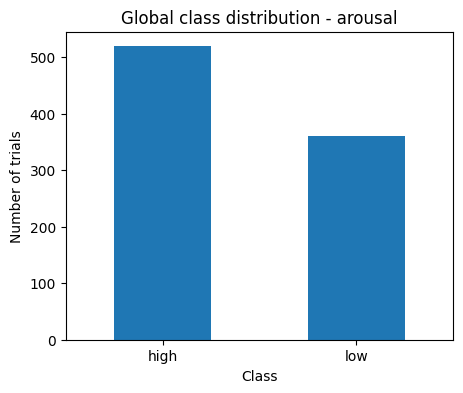

In [ ]:
# =========================
# 4.3 Global label distribution
# =========================

label_counts = df_trials["label_name"].value_counts()

display(label_counts)

label_counts.plot(kind="bar", figsize=(5, 4))
plt.title(f"Global class distribution - {TARGET_NAMES[LABEL_TYPE]}")
plt.xlabel("Class")
plt.ylabel("Number of trials")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# =========================
# 4.4 Subject-level label balance
# =========================

subject_balance = (
    df_trials
    .groupby("subject")
    .agg(
        n_trials=("trial", "count"),
        n_video=("has_video", "sum"),
        low_count=("label", lambda x: (x == 0).sum()),
        high_count=("label", lambda x: (x == 1).sum()),
        high_rate=("label", "mean"),
        valence_mean=("valence_raw", "mean"),
        arousal_mean=("arousal_raw", "mean")
    )
    .reset_index()
)

display(subject_balance)

,subject,n_trials,n_video,low_count,high_count,high_rate,valence_mean,arousal_mean
0,s01,40,40,16,24,0.600,5.11775,5.65975
1,s02,40,40,16,24,0.600,5.77900,5.43825
2,s03,40,39,32,8,0.200,5.60800,3.73825
3,s04,40,40,24,16,0.400,4.12350,4.26150
4,s05,40,39,21,19,0.475,5.57950,5.31525
5,s06,40,40,23,17,0.425,6.15600,4.79975
6,s07,40,40,15,25,0.625,5.83775,5.33525
7,s08,40,40,16,24,0.600,5.39975,5.52325
8,s09,40,40,15,25,0.625,4.94325,5.41925
9,s10,40,40,18,22,0.550,5.16025,4.89550


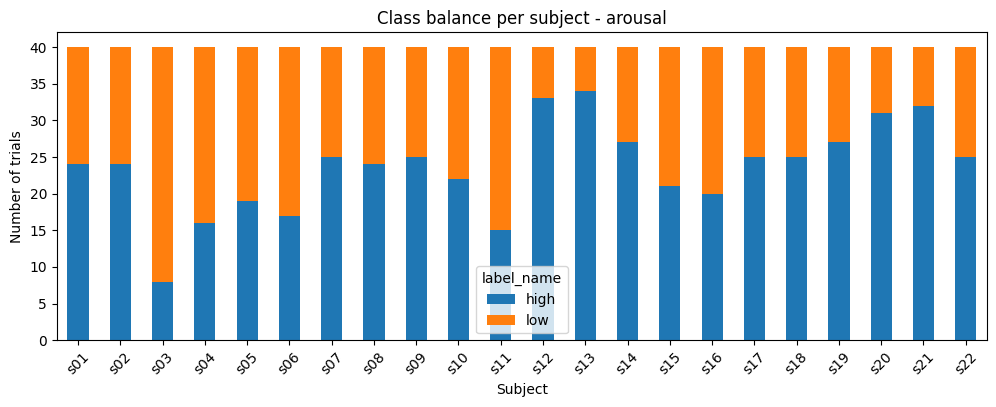

In [ ]:
pd.crosstab(df_trials["subject"], df_trials["label_name"]).plot(
    kind="bar",
    stacked=True,
    figsize=(12, 4)
)

plt.title(f"Class balance per subject - {TARGET_NAMES[LABEL_TYPE]}")
plt.xlabel("Subject")
plt.ylabel("Number of trials")
plt.xticks(rotation=45)
plt.show()

,subject,total_trials,video_trials,missing_video_trials
0,s01,40,40,0
1,s02,40,40,0
2,s03,40,39,1
3,s04,40,40,0
4,s05,40,39,1
5,s06,40,40,0
6,s07,40,40,0
7,s08,40,40,0
8,s09,40,40,0
9,s10,40,40,0


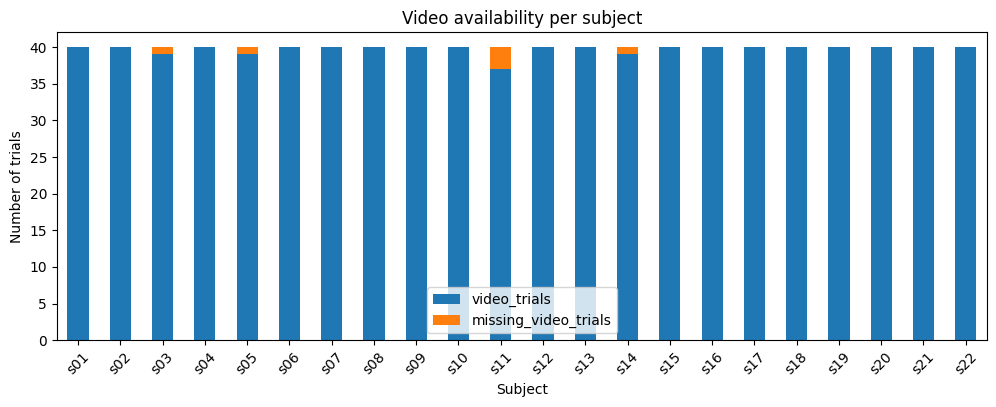

In [ ]:
# =========================
# 4.5 EEG/video availability
# =========================

availability = (
    df_trials
    .groupby("subject")
    .agg(
        total_trials=("trial", "count"),
        video_trials=("has_video", "sum")
    )
    .reset_index()
)

availability["missing_video_trials"] = availability["total_trials"] - availability["video_trials"]

display(availability)

availability.plot(
    x="subject",
    y=["video_trials", "missing_video_trials"],
    kind="bar",
    stacked=True,
    figsize=(12, 4)
)

plt.title("Video availability per subject")
plt.xlabel("Subject")
plt.ylabel("Number of trials")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# =========================
# 4.6 Train/validation split audit
# =========================

def audit_split(target_sid="s01", split_mode="subject_dependent"):
    train_pairs, val_pairs, split_info = get_shared_split(
        sid=target_sid,
        split_mode=split_mode,
    )

    pair_to_label = _build_pair_label_lookup(
        subjects=subjects,
        max_subject_id=MAX_SUBJECT_ID,
    )

    split_rows = []

    for sid, trial_idx in train_pairs:
        split_rows.append({
            "subject": sid,
            "trial": trial_idx,
            "split": "train",
            "label": pair_to_label[(sid, trial_idx)]
        })

    for sid, trial_idx in val_pairs:
        split_rows.append({
            "subject": sid,
            "trial": trial_idx,
            "split": "val",
            "label": pair_to_label[(sid, trial_idx)]
        })

    df_split = pd.DataFrame(split_rows)
    df_split["label_name"] = df_split["label"].map(LABEL_NAMES)

    print("Split info:")
    print(split_info)

    print("\nClass distribution in split:")
    display(pd.crosstab(df_split["split"], df_split["label_name"]))

    return df_split, split_info, train_pairs, val_pairs


df_split_s01, split_info_s01, train_pairs_s01, val_pairs_s01 = audit_split(
    target_sid="s01",
    split_mode="subject_dependent"
)

Split info:
{'split_mode': 'subject_dependent', 'target_sid': 's01', 'n_total_pairs': 874, 'n_train_pairs': 30, 'n_val_pairs': 10, 'stratified': True, 'train_label_counts': {0: 12, 1: 18}, 'val_label_counts': {0: 4, 1: 6}}

Class distribution in split:


label_name,high,low
split,,
train,18,12
val,6,4


# 5. Training and Evaluation Utilities

In [ ]:

"""
Model zoo / factory for DEAP EEG experiments.

This module groups baseline models that match the 4 dataset "modes" produced
by the data pipeline.

Modes
-----
mode 0/1:
    - Time-domain EEG (raw or filtered), shape (B, C=32, T)
    - Models: 1D CNN baselines

mode 2:
    - Per-trial sequence of window features, shape (B, Nwin, F)
    - Models: temporal Conv1D baseline or Transformer encoder baseline

mode 3:
    - Per-window features flattened across all trials, shape (B, F)
    - Model: small MLP classifier

The `build_model(...)` factory returns the correct model for the selected mode.
"""


# =========================
# Mode 0/1: time-domain CNN
# =========================
class CNNTimeDomain(nn.Module):
    """
    Time-domain CNN baseline for modes 0 and 1.

    Expected input:
        x: (B, C=32, T)
           - B: batch size
           - C: number of EEG channels
           - T: number of time samples in one trial

    Output:
        logits: (B, num_classes)

    Notes:
        This model applies 1D convolutions along the time axis.
        It is a compact baseline that is useful for:
        - fast experiments
        - sanity-checking the pipeline
        - comparing raw vs filtered EEG
    """
    def __init__(self, num_channels: int = 32, num_classes: int = 2):
        super().__init__()

        # First block:
        # extract early temporal patterns and reduce sequence length
        self.convblock1 = nn.Sequential(
            nn.Conv1d(num_channels, 64, kernel_size=7, padding=3),
            nn.GroupNorm(8, 64),
            nn.ReLU(inplace=True),
            nn.AvgPool1d(2),
        )

        # Second block:
        # learn deeper temporal representations
        self.convblock2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=7, padding=3),
            nn.GroupNorm(8, 128),
            nn.ReLU(inplace=True),
        )

        # Third block:
        # refine learned features while keeping the same channel width
        self.convblock3 = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=7, padding=3),
            nn.GroupNorm(8, 128),
            nn.ReLU(inplace=True),
        )

        # Classification head:
        # pool over time, flatten, regularize, then classify
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(1),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Run the forward pass.

        Args:
            x: EEG batch of shape (B, C, T)

        Returns:
            Logits of shape (B, num_classes)
        """
        x = self.convblock1(x)
        x = self.convblock2(x)
        x = self.convblock3(x)
        return self.head(x)


class TripathiSmallCNN1D(nn.Module):
    """
    Small and shallow 1D CNN baseline for DEAP trials (modes 0/1).

    Expected input:
        x: (B, 32, T)

    Output:
        logits: (B, num_classes)

    Why this model:
        This is a lightweight baseline inspired by shallow CNN setups used in
        older EEG emotion recognition work. It is simple, stable, and fast to train.
    """
    def __init__(self, num_channels=32, num_classes=2, p_drop=0.5):
        super().__init__()

        self.emb_dim = 128

        self.features = nn.Sequential(
            nn.Conv1d(num_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.AvgPool1d(2),

            nn.Conv1d(64, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.AvgPool1d(2),

            nn.Conv1d(128, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(1),
        )

        self.dropout = nn.Dropout(p_drop)
        self.head = nn.Linear(self.emb_dim, num_classes)

    def encode(self, x):
        return self.features(x)   # (B, 128)

    def forward(self, x):
        z = self.encode(x)
        z = self.dropout(z)
        return self.head(z)


# ===========================================
# Mode 2: per-trial SEQUENCE model over DE/PSD
# ===========================================
class SeqConv1D(nn.Module):
    """
    Temporal Conv1D baseline for feature sequences (mode 2).

    Expected input:
        x: (B, Nwin, F)
           - Nwin: number of windows per trial
           - F: feature dimension for each window

    Output:
        logits: (B, num_classes)

    Pipeline:
        1) Project each window feature vector from F to hidden_dim
        2) Transpose to (B, hidden_dim, Nwin) so Conv1D runs over windows
        3) Apply temporal Conv1D layers
        4) Pool across windows and classify
    """
    def __init__(
        self,
        feature_dim: int,         # F
        num_classes: int = 2,
        hidden_dim: int = 128,    # D
        dropout: float = 0.3,
    ):
        super().__init__()

        # Project each window independently into a hidden representation
        self.proj = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
        )

        # Temporal Conv1D stack over the window axis
        self.temporal = nn.Sequential(
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

        # Pool sequence information into one vector, then classify
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(1),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Run the forward pass.

        Args:
            x: Feature sequence batch of shape (B, Nwin, F)

        Returns:
            Logits of shape (B, num_classes)
        """
        # x: (B, Nwin, F)
        B, N, F = x.shape

        # Step 1: project each window feature vector
        x = self.proj(x)          # (B, N, D)

        # Step 2: rearrange dimensions for Conv1D
        x = x.transpose(1, 2)     # (B, D, N)

        # Step 3: temporal modeling across windows
        x = self.temporal(x)      # (B, D, N)

        # Step 4: global pooling + classification
        return self.head(x)       # (B, num_classes)


class EEGFeatureTransformer(nn.Module):
    """
    Transformer encoder baseline for EEG feature sequences (mode 2).

    Expected input:
        x: (B, Nwin, F)

    Output:
        logits: (B, num_classes)

    Important:
        - `encode(x)` returns the sequence embedding before classification
        - `forward(x)` returns normal classification logits
    """
    def __init__(
        self,
        feat_dim,
        num_classes=2,
        d_model=128,
        num_heads=4,
        num_layers=2,
        dropout=0.1,
    ):
        super().__init__()

        self.feat_dim = feat_dim
        self.d_model = d_model
        self.num_classes = num_classes

        # Project each window feature vector into the transformer embedding space
        self.input_proj = nn.Linear(feat_dim, d_model)

        # Standard Transformer encoder stack
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=2 * d_model,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Final classifier used in EEG-only training
        self.head = nn.Linear(d_model, num_classes)

    def encode(self, x):
        """
        Encode the input sequence into one EEG embedding.

        Args:
            x: Input tensor of shape (B, Nwin, F)

        Returns:
            z: Embedding tensor of shape (B, d_model)
        """
        x = self.input_proj(x)   # (B, Nwin, D)
        x = self.encoder(x)      # (B, Nwin, D)

        # Mean pooling across windows to get one vector per sample
        z = x.mean(dim=1)        # (B, D)
        return z

    def forward(self, x):
        """
        Standard classification forward pass.

        Args:
            x: Input tensor of shape (B, Nwin, F)

        Returns:
            Logits of shape (B, num_classes)
        """
        z = self.encode(x)       # (B, D)
        logits = self.head(z)    # (B, num_classes)
        return logits


# ======================================
# Mode 3: per-window MLP over features F
# ======================================
class MLPWindow(nn.Module):
    """
    MLP baseline for per-window classification (mode 3).

    Expected input:
        x: (B, F)
           - one feature vector per window

    Output:
        logits: (B, num_classes)

    Notes:
        This is a simple baseline for the flattened-window setting, where each
        window is treated as an independent sample.
    """
    def __init__(
        self,
        feature_dim: int,
        num_classes: int = 2,
        hidden: int = 256,
        dropout: float = 0.4,
    ):
        super().__init__()

        # Two hidden layers with GELU and dropout for regularization
        self.net = nn.Sequential(
            nn.Linear(feature_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Run the forward pass.

        Args:
            x: Input tensor of shape (B, F)

        Returns:
            Logits of shape (B, num_classes)
        """
        return self.net(x)


# ==========================
# Factory for the three modes
# ==========================
def build_model(
    mode: int,
    num_channels: int = 32,
    feature_dim: Optional[int] = None,
    num_classes: int = 2,
):
    """
    Return a model compatible with the selected dataset mode.

    Args:
        mode:
            0/1 -> time-domain EEG
            2   -> per-trial sequence of feature windows
            3   -> per-window features
        num_channels:
            Number of EEG channels for mode 0/1 CNN models.
        feature_dim:
            Feature dimension F.
            Required for modes 2 and 3.
        num_classes:
            Number of output classes.

    Returns:
        A `torch.nn.Module` matching the input format of the selected mode.

    Mode mapping:
        mode 0/1 -> TripathiSmallCNN1D
        mode 2   -> EEGFeatureTransformer
        mode 3   -> MLPWindow
    """
    # Raw / filtered time-domain EEG
    if mode in (0, 1):
        return TripathiSmallCNN1D(num_channels=num_channels, num_classes=num_classes)

    # Sequence of per-window features
    elif mode == 2:
        assert feature_dim is not None, "feature_dim is required for mode=2"
        return EEGFeatureTransformer(feat_dim=feature_dim, num_classes=num_classes)

    # Single-window feature vectors
    elif mode == 3:
        assert feature_dim is not None, "feature_dim is required for mode=3"
        return MLPWindow(feature_dim=feature_dim, num_classes=num_classes)

    else:
        raise ValueError("mode must be one of {0,1,2,3}")

In [ ]:
"""
Training engine utilities for DEAP EEG experiments.

This module provides the main training helpers used in the project:
- `train_step`: runs one full training epoch
- `test_step`: runs one full validation/test pass
- `train`: handles multi-epoch training and keeps the best model in memory
- `train_kfold`: repeats training over several folds for cross-validation

Main design choices:
- Works with batches returned as (X, y, meta) or just (X, y)
- Uses AMP (automatic mixed precision) on CUDA for faster training
- Tracks loss and accuracy for both train and validation sets
- Restores the best model weights at the end of training
"""


def _unpack_xy(batch):
    """
    Extract only (X, y) from a batch.

    Some datasets return:
        (X, y, meta)

    while the training code only needs:
        (X, y)

    Args:
        batch: Batch returned by a DataLoader. Expected formats:
            - (X, y)
            - (X, y, ...)

    Returns:
        X, y

    Raises:
        ValueError: If the batch does not have at least two elements.
    """
    if isinstance(batch, (list, tuple)) and len(batch) >= 2:
        return batch[0], batch[1]
    raise ValueError("Expected batch to be (X, y) or (X, y, ...).")


def eeg_augmentation(X, eeg_input_type="features", noise_std=0.01, scale_std=0.03):
    """
    Creates a slightly perturbed version of EEG input.

    eeg_input_type:
    - "raw"      for X shape (B, C, T)
    - "features" for X shape (B, Nwin, F)
    """

    noise = torch.randn_like(X) * noise_std

    if X.ndim == 3:
        if eeg_input_type == "raw":
            # raw EEG: scale each channel
            scale = 1.0 + torch.randn(
                X.size(0), X.size(1), 1, device=X.device
            ) * scale_std
        else:
            # DE features: scale each feature dimension
            scale = 1.0 + torch.randn(
                X.size(0), 1, X.size(2), device=X.device
            ) * scale_std

    elif X.ndim == 2:
        scale = 1.0 + torch.randn(
            X.size(0), X.size(1), device=X.device
        ) * scale_std

    else:
        scale = 1.0

    return X * scale + noise


def eeg_consistency_loss(logits_clean, logits_aug):
    """
    Forces the model to give similar predictions for:
    - original EEG
    - slightly perturbed EEG
    """
    p_clean = F.softmax(logits_clean.detach(), dim=1)
    log_p_aug = F.log_softmax(logits_aug, dim=1)

    return F.kl_div(log_p_aug, p_clean, reduction="batchmean")

def train_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    scaler: GradScaler | None = None,
    verbose: int = 0,
    lambda_cons: float = 0.0,
    eeg_input_type: str = "features",
) -> Tuple[float, float]:

    model.train()
    train_loss, train_acc, totalseen = 0.0, 0.0, 0

    loop = tqdm(dataloader, desc="Training", leave=False, disable=(verbose < 2))
    use_amp = (device.type == "cuda")

    for batch in loop:
        X, y = _unpack_xy(batch)
        X, y = X.to(device), y.to(device).long()

        optimizer.zero_grad(set_to_none=True)

        with amp_autocast(device_type=device.type, enabled=use_amp):

            # Normal prediction
            logits_clean = model(X)
            loss_cls = loss_fn(logits_clean, y)

            # Optional consistency regularization
            if lambda_cons > 0:
                X_aug = eeg_augmentation(
                    X,
                    eeg_input_type=eeg_input_type,
                    noise_std=0.01,
                    scale_std=0.03,
                )

                logits_aug = model(X_aug)
                loss_cons = eeg_consistency_loss(logits_clean, logits_aug)

                loss = loss_cls + lambda_cons * loss_cons
            else:
                loss = loss_cls

        if use_amp and scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        bsz = y.size(0)
        train_loss += loss.item() * bsz
        train_acc += (logits_clean.argmax(1) == y).sum().item()
        totalseen += bsz

        if verbose >= 2:
            loop.set_postfix(loss=float(loss.detach().cpu()))

    return train_loss / max(1, totalseen), train_acc / max(1, totalseen)

def test_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    device: torch.device,
    verbose: int = 0,
) -> Tuple[float, float]:
    """
    Evaluate a model on a validation or test DataLoader.

    This function:
    - switches the model to evaluation mode
    - disables gradient computation
    - computes average loss and accuracy over the loader
    - optionally uses AMP on CUDA for faster inference

    Args:
        model: Model to evaluate.
        dataloader: Validation or test DataLoader.
        loss_fn: Loss function.
        device: Device where tensors and model are placed.
        verbose: Controls tqdm display.
            - 0/1: no progress bar
            - 2: show tqdm progress bar

    Returns:
        Tuple:
            - average loss
            - average accuracy
    """
    # Evaluation mode disables training-specific behaviors such as dropout updates.
    model.eval()

    test_loss, correct, total = 0.0, 0, 0
    use_amp = (device.type == "cuda")

    loop = tqdm(dataloader, desc="Evaluating", leave=False, disable=(verbose < 2))

    # inference_mode is faster and uses less memory than full grad-enabled execution.
    with torch.inference_mode():
        for batch in loop:
            X, y = _unpack_xy(batch)
            X, y = X.to(device), y.to(device).long()

            # Forward pass only, no gradients.
            with amp_autocast(device_type=device.type, enabled=use_amp):
                y_pred = model(X)
                loss = loss_fn(y_pred, y)

            # Accumulate weighted loss and accuracy.
            bsz = y.size(0)
            test_loss += loss.item() * bsz
            correct += (y_pred.argmax(1) == y).sum().item()
            total += bsz

            if verbose >= 2:
                loop.set_postfix(loss=float(loss.detach().cpu()))

    return test_loss / max(1, total), correct / max(1, total)


def train(
    model: torch.nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    test_dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    epochs: int,
    device: torch.device,
    verbose: int = 0,
    lambda_cons: float = 0.0,
    eeg_input_type: str = "features",
) -> Tuple[torch.nn.Module, float, Dict[str, List[float]]]:
    """
    Train a model for multiple epochs and restore the best checkpoint in memory.

    At each epoch, this function:
    - runs one training epoch
    - runs one validation pass
    - stores train/validation metrics in `history`
    - computes a simple score to decide whether the current model is the best

    Best-model score:
        score = 0.5 * normalized_loss + 0.5 * val_acc

    where:
        normalized_loss = max(0, 1 - min(val_loss, 1))

    This gives a simple balance between lower validation loss and higher validation accuracy.

    Args:
        model: Initialized model.
        train_dataloader: Training DataLoader.
        test_dataloader: Validation DataLoader.
        loss_fn: Loss function.
        optimizer: Optimizer.
        epochs: Number of training epochs.
        device: Device used for training.
        verbose: Logging level.
            - 0: silent
            - 1: print one summary line per epoch
            - 2: show tqdm bars too

    Returns:
        Tuple:
            - model with best weights loaded
            - best_score achieved during training
            - history dictionary with per-epoch metrics
    """
    # History is useful for plots, debugging, and comparing runs later.
    history: Dict[str, List[float]] = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_score = 0.0
    best_model_state = None

    # Create an AMP scaler only when training on CUDA.
    use_amp = (device.type == "cuda")
    scaler = GradScaler(enabled=use_amp)

    for epoch in range(epochs):
        if verbose >= 1:
            print(f"\nEpoch {epoch + 1}/{epochs}")

        # Training phase for one epoch.
        train_loss, train_acc = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device,
            scaler=scaler,
            verbose=verbose,
            lambda_cons=lambda_cons,
            eeg_input_type=eeg_input_type,
        )

        # Validation phase after the epoch.
        val_loss, val_acc = test_step(
            model, test_dataloader, loss_fn, device, verbose=verbose
        )

        # Convert loss into a simple score where smaller loss becomes better.
        # Then average it with validation accuracy.
        normalized_loss = max(0.0, 1 - min(val_loss, 1))
        score = 0.5 * normalized_loss + 0.5 * val_acc

        # Save metrics for later analysis.
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose >= 1:
            print(f"Train {train_loss:.4f}/{train_acc:.4f} | Val {val_loss:.4f}/{val_acc:.4f} | Score {score:.4f}")

        # Keep the best model weights in memory.
        if score > best_score:
            best_score = score
            best_model_state = deepcopy(model.state_dict())
            if verbose >= 1:
                print(f"↗ New best Score {best_score:.4f}")

    # At the end, restore the best model found during training.
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        if verbose >= 1:
            print("Loaded best model from memory.")

    return model, best_score, history




In [ ]:

"""
High-level training entry points for DEAP EEG baselines.

This module connects the main parts of the EEG pipeline:
- dataset / dataloader creation
- model construction
- training loop execution
- optional checkpoint saving and reloading

Supported evaluation styles
---------------------------
1) Per-subject training:
   - Train one model per subject
   - Useful for subject-dependent evaluation

2) Shared-split / global style:
   - Train using externally prepared train/validation pairs
   - Useful when EEG, video, and fusion must use the exact same split

Notes:
- Global hyperparameters are defined in this file.
- Model weights are saved under ./models by default.
"""





def save_model(model: nn.Module, save_path: str | Path) -> None:
    """
    Save a model state_dict to a full checkpoint path.

    Example:
        save_model(model, "models/cv_fold_0/eeg_s01.pth")
    """
    save_path = Path(save_path)

    # Create parent folder automatically
    save_path.parent.mkdir(parents=True, exist_ok=True)

    torch.save(model.state_dict(), save_path)

def load_model_checkpoint(
    checkpoint_path: str | Path,
    mode: int,
    feature_dim: Optional[int] = None,
    num_channels: int = 32,
    num_classes: int = 2,
    map_location: Optional[str | torch.device] = None,
) -> nn.Module:
    """
    Rebuild the correct model architecture and load a saved checkpoint.

    This is useful when you saved only the state_dict and want to restore the model
    later for evaluation or inference.

    Args:
        checkpoint_path: Path to the saved .pth file.
        mode: Dataset mode used when the model was trained.
        feature_dim: Required for mode 2 and mode 3 models.
        num_channels: Number of EEG channels for time-domain models (mode 0/1).
        num_classes: Number of output classes.
        map_location: Device mapping used when loading the checkpoint
            (for example "cpu" or "cuda").

    Returns:
        Loaded model in evaluation mode.
    """
    checkpoint_path = Path(checkpoint_path)

    # Recreate the same architecture used during training
    model = build_model(
        mode=mode,
        num_channels=num_channels,
        feature_dim=feature_dim,
        num_classes=num_classes,
    )

    # Load saved weights
    state_dict = torch.load(checkpoint_path, map_location=map_location)
    model.load_state_dict(state_dict)

    # Put the model in eval mode for inference / validation usage
    model.eval()

    return model

@torch.no_grad()
def evaluate_eeg_detailed(model, loader, criterion, device):
    """
    Evaluate the EEG model on a loader and return detailed classification metrics.

    Returns:
        dict containing:
        - loss
        - acc
        - balanced_acc
        - precision
        - recall
        - f1
        - confusion_matrix
        - y_true
        - y_pred
    """
    model.eval()

    total_loss = 0.0
    total_samples = 0
    all_y = []
    all_pred = []

    for x, y, _ in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item() * y.size(0)
        total_samples += y.size(0)

        all_y.extend(y.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())

    acc = float(np.mean(np.array(all_y) == np.array(all_pred))) if total_samples > 0 else 0.0
    bal_acc = float(balanced_accuracy_score(all_y, all_pred)) if len(set(all_y)) > 1 else acc
    precision = float(precision_score(all_y, all_pred, zero_division=0))
    recall = float(recall_score(all_y, all_pred, zero_division=0))
    f1 = float(f1_score(all_y, all_pred, zero_division=0))
    cm = confusion_matrix(all_y, all_pred, labels=[0, 1])

    return {
        "loss": total_loss / max(1, total_samples),
        "acc": acc,
        "balanced_acc": bal_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm.tolist(),
        "y_true": all_y,
        "y_pred": all_pred,
    }


def run_eeg_experiment_shared_split(
    dataset_path: str | Path,
    train_pairs,
    val_pairs,
    model_name: str = "EEG",
    mode: int = 2,
    label_type: int = 0,
    batch_size: int = BATCH_SIZE,
    epochs: int = EPOCHS,
    lr: float = LR,
    weight_decay: float = WEIGHT_DECAY,
    verbose: int = 0,
    save_path: str | None = None,
    lambda_cons: float = 0.0,
):
    """
    Train one EEG model using a pre-defined shared train/validation split.

    This is useful when you want EEG-only training to use the exact same split as:
    - video-only training
    - fusion training

    The split is given through:
        train_pairs = [(sid, trial_idx), ...]
        val_pairs   = [(sid, trial_idx), ...]

    Args:
        dataset_path: Root path of the EEG dataset.
        train_pairs: Shared training pairs.
        val_pairs: Shared validation pairs.
        model_name: Prefix used for saved model naming.
        mode: EEG data mode.
        label_type: Label type (for example valence or arousal).
        batch_size: Batch size for training and validation.
        epochs: Number of training epochs.
        lr: Learning rate.
        weight_decay: Weight decay used by Adam.
        verbose: Verbosity level passed to the training loop.
        save_path: Optional custom checkpoint filename.

    Returns:
        Dictionary containing:
        - training history
        - best score
        - best / last validation accuracy
        - saved checkpoint path
        - inferred feature_dim
    """
    # Build train and validation loaders from the same shared trial pairs
    train_loader, val_loader, train_dataset, val_dataset = create_eeg_dataloaders_from_pairs(
        path=dataset_path,
        mode=mode,
        label_type=label_type,
        train_pairs=train_pairs,
        val_pairs=val_pairs,
        batch_size=batch_size,
        num_workers= NUM_WORKERS,
    )

    print("EEG train dataset size:", len(train_dataset))
    print("EEG val dataset size:", len(val_dataset))

    # Infer feature dimension automatically when using feature-based modes
    feature_dim = None
    if mode in (2, 3):
        x0, y0, meta0 = train_dataset[0]
        if mode == 2:
            feature_dim = x0.shape[-1]   # x0 shape: (Nwin, F)
        else:
            feature_dim = x0.shape[0]    # x0 shape: (F,)

    # Build the model matching the selected mode
    model = build_model(
        mode=mode,
        num_channels=32,
        feature_dim=feature_dim,
        num_classes=2,
    ).to(device)

    # Standard classification setup
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    eeg_input_type = "raw" if mode in (0, 1) else "features"

    # Train the model and keep the best checkpoint in memory
    model, best_score, history = train(
        model=model,
        train_dataloader=train_loader,
        test_dataloader=val_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        epochs=epochs,
        device=device,
        verbose=verbose,
        lambda_cons=lambda_cons,
        eeg_input_type=eeg_input_type,
    )

    detailed_metrics = evaluate_eeg_detailed(
        model=model,
        loader=val_loader,
        criterion=loss_fn,
        device=device,
    )

    # Default checkpoint filename if the caller did not provide one
    if save_path is None:
        save_path = f"{model_name}_mode{mode}_label{label_type}.pth"

    # Save final restored-best model
    save_model(model, save_path)

    best_val_acc = max(history["val_acc"]) if history.get("val_acc") else None
    last_val_acc = history["val_acc"][-1] if history.get("val_acc") else None

    print("EEG model saved to:", save_path)
    if best_val_acc is not None:
        print(f"EEG best val acc: {best_val_acc:.4f}")
    if last_val_acc is not None:
        print(f"EEG last val acc: {last_val_acc:.4f}")

    return {
        "history": history,
        "best_score": float(best_score),
        "best_val_acc": float(best_val_acc) if best_val_acc is not None else None,
        "last_val_acc": float(last_val_acc) if last_val_acc is not None else None,
        "save_path": str(save_path),
        "feature_dim": feature_dim,
        "detailed_metrics": detailed_metrics,
    }


def run_all_eeg_shared_split(
    dataset_path=DEAP_ROOT,
    image_root=IMAGE_ROOT,
    label_type=0,
    mode=2,
    max_subject_id=22,
    split_mode="subject_dependent",
    train_ratio=TRAIN_RATIO,
    seed=42,
    model_name="EEG_TR",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    verbose=0,
    lambda_cons=0.0,
):
    """
    Run EEG experiments using shared trial splits.

    This function prepares one common trial space, then creates train/validation splits
    that can also be reused by video or fusion pipelines.

    Supported split modes:
        - "subject_dependent":
            For each subject, split only that subject's trials into train/val
        - "loso":
            Leave-one-subject-out
        - "random_all":
            One global random split across all available pairs

    Args:
        dataset_path: Root path of the EEG dataset.
        image_root: Optional video/image root. If provided, only trials available in
            both EEG and video are kept.
        label_type: Label type used for training.
        mode: EEG mode to train with.
        max_subject_id: Maximum subject id to include.
        split_mode: Split strategy to use.
        train_ratio: Train ratio for random-style splits.
        seed: Random seed.
        model_name: Prefix used for saved model naming.
        epochs: Number of training epochs.
        batch_size: Batch size.
        lr: Learning rate.
        weight_decay: Weight decay.
        verbose: Verbosity passed to the training function.

    Returns:
        For random_all:
            {
                "global_result": ...,
                "split_info": ...
            }

        For subject_dependent / loso:
            {
                "subject_results": ...,
                "mean_best_acc": ...,
                "split_mode": ...
            }
    """
    results = {}

    cons_tag = f"cons{str(lambda_cons).replace('.', 'p')}"


    # random_all is one single global run, not one experiment per subject
    if split_mode == "random_all":
        train_pairs, val_pairs, split_info = get_shared_split(
            sid=None,
            split_mode="random_all",
        )

        print("split info:", split_info)

        result = run_eeg_experiment_shared_split(
            dataset_path=dataset_path,
            train_pairs=train_pairs,
            val_pairs=val_pairs,
            model_name=model_name,
            mode=mode,
            label_type=label_type,
            batch_size=batch_size,
            epochs=epochs,
            lr=lr,
            weight_decay=weight_decay,
            verbose=verbose,
            save_path=f"{model_name}_random_all_mode{mode}_label{label_type}_{cons_tag}.pth",
            lambda_cons=lambda_cons,
        )

        return {
            "global_result": result,
            "split_info": split_info,
        }

    # For subject_dependent and loso, run one experiment per subject
    for sid_num in range(1, max_subject_id + 1):
        sid = f"s{sid_num:02d}"

        print("\n" + "=" * 60)
        print(f"Running EEG experiment for {sid} | split_mode={split_mode}")
        print("=" * 60)

        try:

            train_pairs, val_pairs, split_info = get_shared_split(
                sid=sid,
                split_mode=split_mode,
            )

            print("split info:", split_info)

            # Train one EEG model using that split
            result = run_eeg_experiment_shared_split(
                dataset_path=dataset_path,
                train_pairs=train_pairs,
                val_pairs=val_pairs,
                model_name=model_name,
                mode=mode,
                label_type=label_type,
                batch_size=batch_size,
                epochs=epochs,
                lr=lr,
                weight_decay=weight_decay,
                verbose=verbose,
                save_path=ckpt_path(
                    f"{model_name}_{split_mode}_{sid}_mode{mode}_label{label_type}.pth"
                ),
                lambda_cons=lambda_cons,
            )

            results[sid] = {
                "best_val_acc": result["best_val_acc"],
                "last_val_acc": result["last_val_acc"],
                "save_path": result["save_path"],
                "history": result["history"],
                "detailed_metrics": result["detailed_metrics"],
                "split_info": split_info,
                "train_pairs": train_pairs,
                "val_pairs": val_pairs,
            }

        except Exception as e:
            # Continue even if one subject fails, so the whole sweep is not lost
            print(f"Skipping {sid}: {e}")

    # Compute mean best validation accuracy across valid subject runs
    valid_best = [
        v["best_val_acc"] for v in results.values()
        if v["best_val_acc"] is not None
    ]
    mean_best_acc = sum(valid_best) / len(valid_best) if len(valid_best) > 0 else 0.0

    print("\n" + "#" * 60)
    print("EEG RESULTS")
    print("#" * 60)
    for sid, info in results.items():
        print(f"{sid}: best_val_acc={info['best_val_acc']:.4f}")

    print(f"\nMean best accuracy: {mean_best_acc:.4f}")

    return {
        "subject_results": results,
        "mean_best_acc": mean_best_acc,
        "split_mode": split_mode,
    }



# 7. Video Experiments

In [ ]:


# Use GPU if available, otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


# =========================
# REPRODUCIBILITY
# =========================
def set_seed(seed=42):
    """
    Set random seeds for reproducibility.

    This helps make results more stable across runs by fixing the random state
    for Python, NumPy, and PyTorch.

    Args:
        seed: Integer seed value.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


# =========================
# LABELS: EEG -> IMAGE DICT
# =========================
def create_labels_dict_from_eeg_and_images(subjects, image_root, max_subject_id=22):
    """
    Build a label dictionary for video/image trials using EEG trial labels.

    The image folders are expected to be named like:
        s01_trial01
        s01_trial02
        ...

    For each valid folder, this function matches:
        subject id + trial id -> EEG label

    Args:
        subjects: EEG subject dictionary returned by the EEG pipeline.
        image_root: Root directory containing image trial folders.
        max_subject_id: Ignore subjects with id greater than this value.

    Returns:
        Nested dictionary of the form:
            {
                "s01": {
                    "trial01": 0,
                    "trial02": 1,
                    ...
                },
                ...
            }
    """
    image_root = Path(image_root)
    labels_dict = {}

    for folder in sorted(image_root.iterdir()):
        if not folder.is_dir():
            continue

        parts = folder.name.split("_")
        if len(parts) != 2:
            continue

        sid, trial_key = parts

        # Skip subjects outside the allowed range.
        if int(sid[1:]) > max_subject_id:
            continue

        # Skip if the subject does not exist in EEG labels.
        if sid not in subjects:
            continue

        y = subjects[sid]["y"]
        trial_idx = int(trial_key.replace("trial", "")) - 1

        # Skip invalid trial indices.
        if trial_idx < 0 or trial_idx >= len(y):
            continue

        if sid not in labels_dict:
            labels_dict[sid] = {}

        labels_dict[sid][trial_key] = int(y[trial_idx])

    return labels_dict


# =========================
# BUILD IMAGE INDEX
# =========================
def build_trial_dict(root_dir):
    """
    Scan the image root directory and build:
    1) a dictionary mapping each (subject, trial) to its image paths
    2) a flat list of available (subject, trial) samples

    Expected folder structure:
        root_dir/
            s01_trial01/
                img1.jpg
                img2.jpg
                ...
            s01_trial02/
            ...

    Args:
        root_dir: Root directory containing trial folders.

    Returns:
        trial_dict:
            {
                "s01": {
                    "trial01": [img_path1, img_path2, ...],
                    ...
                },
                ...
            }

        sample_index:
            [
                ("s01", "trial01"),
                ("s01", "trial02"),
                ...
            ]
    """
    root_dir = Path(root_dir)
    trial_dict = {}
    sample_index = []

    for folder in sorted(root_dir.iterdir()):
        if not folder.is_dir():
            continue

        parts = folder.name.split("_")
        if len(parts) != 2:
            continue

        sid, trial = parts

        # Keep only common image formats.
        image_paths = sorted([
            str(img) for img in folder.iterdir()
            if img.is_file() and img.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])

        if len(image_paths) == 0:
            continue

        if sid not in trial_dict:
            trial_dict[sid] = {}

        trial_dict[sid][trial] = image_paths
        sample_index.append((sid, trial))

    return trial_dict, sample_index


# =========================
# DATASET
# =========================
class DEAPFaceTrialDataset(Dataset):
    """
    PyTorch dataset for video/image trials.

    This dataset can be filtered using a shared list of allowed pairs:
        allowed_pairs = [(sid, trial_idx), ...]

    Internal naming:
        sid   -> "s01"
        trial -> "trial01"

    Shared split format:
        (sid, trial_idx) where trial_idx is 0-based

    Each item returns:
        x: stacked frames of shape [T, C, H, W]
        y: trial label
        meta: dictionary containing subject/trial information

    Args:
        root_dir: Root directory of trial folders.
        labels_dict: Nested dictionary containing labels per subject/trial.
        transform: Optional image transform.
        num_frames: Number of frames to keep per trial.
        allowed_pairs: Optional shared split filter.
    """
    def __init__(
        self,
        root_dir,
        labels_dict,
        transform=None,
        num_frames=18,
        allowed_pairs=None,
    ):
        self.trial_dict, self.sample_index = build_trial_dict(root_dir)
        self.labels_dict = labels_dict
        self.transform = transform
        self.num_frames = num_frames

        # Normalize allowed pairs once for fast membership checking.
        allowed_set = None
        if allowed_pairs is not None:
            allowed_set = {(sid.lower(), int(t)) for sid, t in allowed_pairs}

        filtered = []
        for sid, trial in self.sample_index:
            # Keep only samples that have labels.
            if sid not in labels_dict:
                continue
            if trial not in labels_dict[sid]:
                continue

            # Convert "trial01" -> 0, "trial02" -> 1, ...
            trial_idx = int(trial.replace("trial", "")) - 1
            pair = (sid.lower(), trial_idx)

            # If a shared split is provided, keep only matching trials.
            if allowed_set is not None and pair not in allowed_set:
                continue

            filtered.append((sid, trial))

        self.sample_index = filtered

    def __len__(self):
        """
        Return the number of available filtered samples.
        """
        return len(self.sample_index)

    def __getitem__(self, idx):
        """
        Load one video trial.

        Steps:
        - load up to `num_frames` images from the trial folder
        - apply transform if provided
        - stack frames into one tensor
        - pad by repeating the last frame if there are not enough images

        Args:
            idx: Dataset index.

        Returns:
            x: Tensor of shape [T, C, H, W]
            y: Label tensor
            meta: Dictionary with subject/trial information
        """
        sid, trial = self.sample_index[idx]
        image_paths = self.trial_dict[sid][trial][:self.num_frames]

        frames = []
        for p in image_paths:
            img = Image.open(p).convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
            frames.append(img)

        if len(frames) == 0:
            raise ValueError(f"No images found for sample {sid}_{trial}")

        # If the trial has fewer frames than expected, repeat the last frame.
        while len(frames) < self.num_frames:
            frames.append(frames[-1].clone())

        x = torch.stack(frames)  # [T, C, H, W]
        y = torch.tensor(self.labels_dict[sid][trial], dtype=torch.long)

        trial_idx = int(trial.replace("trial", "")) - 1
        meta = {"sid": sid, "trial": trial_idx, "trial_key": trial}

        return x, y, meta


# =========================
# MODEL
# =========================
def _set_bn_eval(module):
    """
    Put BatchNorm layers in evaluation mode.

    This is useful when the backbone is frozen and you want BatchNorm running
    statistics to stay fixed.
    """
    if isinstance(module, nn.modules.batchnorm._BatchNorm):
        module.eval()


class ResNet18TrialModel(nn.Module):
    """
    ResNet18-based model for trial-level video classification.

    The model:
    - extracts frame-level features using a ResNet18 backbone
    - averages features across frames to get one trial representation
    - classifies the trial with a linear layer

    Args:
        num_classes: Number of output classes.
        freeze_backbone: If True, freeze all ResNet backbone parameters.
        freeze_bn_stats: If True, keep BatchNorm layers in eval mode during training.
            If None, it follows the value of `freeze_backbone`.
    """
    def __init__(self, num_classes=2, freeze_backbone=True, freeze_bn_stats=None):
        super().__init__()

        # Load pretrained ResNet18 and remove its final classifier.
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.backbone = backbone
        self.feat_dim = feat_dim
        self.classifier = nn.Linear(feat_dim, num_classes)

        self.freeze_backbone = freeze_backbone
        self.freeze_bn_stats = freeze_backbone if freeze_bn_stats is None else freeze_bn_stats

        # Optionally freeze the backbone so only the classifier is trained.
        if self.freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def set_bn_eval(self):
        """
        Force all BatchNorm layers in the backbone into evaluation mode.
        """
        self.backbone.apply(_set_bn_eval)

    def train(self, mode=True):
        """
        Override nn.Module.train() to optionally keep BatchNorm layers frozen.

        Args:
            mode: Standard PyTorch train/eval switch.

        Returns:
            self
        """
        super().train(mode)
        if self.freeze_bn_stats:
            self.set_bn_eval()
        return self

    def encode_frames(self, x):
        """
        Encode each frame independently using the ResNet backbone.

        Args:
            x: Input tensor of shape [B, T, C, H, W]

        Returns:
            Frame features of shape [B, T, feat_dim]
        """
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        feats = self.backbone(x)
        feats = feats.view(B, T, -1)
        return feats

    def encode_trial(self, x):
        """
        Build one feature vector per trial by averaging frame features.

        Args:
            x: Input tensor of shape [B, T, C, H, W]

        Returns:
            Trial features of shape [B, feat_dim]
        """
        feats = self.encode_frames(x)
        return feats.mean(dim=1)

    def forward(self, x):
        """
        Forward pass for classification.

        Args:
            x: Input tensor of shape [B, T, C, H, W]

        Returns:
            Logits of shape [B, num_classes]
        """
        trial_feats = self.encode_trial(x)
        return self.classifier(trial_feats)


# =========================
# TRAIN / EVAL
# =========================
def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Train the model for one epoch.

    Args:
        model: Model to train.
        loader: Training DataLoader.
        criterion: Loss function.
        optimizer: Optimizer.
        device: CPU or GPU device.

    Returns:
        Tuple:
            - average training loss
            - average training accuracy
    """
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for x, y, _ in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += y.size(0)

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Evaluate the model on a validation or test loader.

    Args:
        model: Model to evaluate.
        loader: Validation/test DataLoader.
        criterion: Loss function.
        device: CPU or GPU device.

    Returns:
        Tuple:
            - average loss
            - average accuracy
    """
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for x, y, _ in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += y.size(0)

    return total_loss / total_samples, total_correct / total_samples

@torch.no_grad()
def evaluate_video_detailed(model, loader, criterion, device):
    """
    Evaluate the video model on a loader and return detailed classification metrics.

    Returns:
        dict containing:
        - loss
        - acc
        - balanced_acc
        - precision
        - recall
        - f1
        - confusion_matrix
        - y_true
        - y_pred
    """
    model.eval()

    total_loss = 0.0
    total_samples = 0
    all_y = []
    all_pred = []

    for x, y, _ in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item() * y.size(0)
        total_samples += y.size(0)

        all_y.extend(y.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())

    acc = float(np.mean(np.array(all_y) == np.array(all_pred))) if total_samples > 0 else 0.0
    bal_acc = float(balanced_accuracy_score(all_y, all_pred)) if len(set(all_y)) > 1 else acc
    precision = float(precision_score(all_y, all_pred, zero_division=0))
    recall = float(recall_score(all_y, all_pred, zero_division=0))
    f1 = float(f1_score(all_y, all_pred, zero_division=0))
    cm = confusion_matrix(all_y, all_pred, labels=[0, 1])

    return {
        "loss": total_loss / max(1, total_samples),
        "acc": acc,
        "balanced_acc": bal_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm.tolist(),
        "y_true": all_y,
        "y_pred": all_pred,
    }

def fit_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, save_path):
    """
    Full training loop with validation and best-checkpoint saving.

    At each epoch:
    - train on the training loader
    - evaluate on the validation loader
    - store metrics in `history`
    - save the model if validation accuracy improves

    Args:
        model: Model to train.
        train_loader: Training DataLoader.
        val_loader: Validation DataLoader.
        criterion: Loss function.
        optimizer: Optimizer.
        device: CPU or GPU device.
        epochs: Number of training epochs.
        save_path: Path where the best checkpoint is saved.

    Returns:
        history: Dictionary of train/validation metrics across epochs.
        best_val_acc: Best validation accuracy reached.
    """
    best_val_acc = 0.0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        # Save only the best validation model.
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    return history, best_val_acc


# =========================
# MAIN EXPERIMENT
# =========================
def run_experiment(
    deap_root=DEAP_ROOT,
    image_root=IMAGE_ROOT,
    train_pairs=None,
    val_pairs=None,
    split_mode="subject_dependent",
    target_sid=None,
    label_type=0,
    max_subject_id=22,
    num_frames=18,
    batch_size=4,
    epochs=10,
    lr=1e-3,
    freeze_backbone=True,
    train_ratio=TRAIN_RATIO,
    num_workers=NUM_WORKERS,
    seed=42,
    save_path=None,
):
    """
    Run one video-only experiment.

    This function:
    - loads EEG labels
    - matches them to video/image trials
    - builds a shared train/validation split if not provided
    - creates datasets and dataloaders
    - trains a ResNet18 trial classifier
    - saves the best checkpoint

    Args:
        deap_root: Root path for EEG data.
        image_root: Root path for trial image folders.
        train_pairs: Optional externally provided training pairs.
        val_pairs: Optional externally provided validation pairs.
        split_mode: Split mode used when pairs are not provided.
        target_sid: Subject id used for subject-dependent or LOSO split.
        label_type: Label type (for example valence or arousal).
        max_subject_id: Maximum subject id to keep.
        num_frames: Number of frames used per trial.
        batch_size: Batch size.
        epochs: Number of epochs.
        lr: Learning rate.
        freeze_backbone: Whether to freeze the ResNet backbone.
        train_ratio: Train ratio for random-style splits.
        num_workers: Number of DataLoader workers.
        seed: Random seed.
        save_path: Optional custom checkpoint filename.

    Returns:
        Dictionary containing training history, best validation accuracy,
        split information, checkpoint path, and used train/val pairs.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("device:", device)

    # -------------------------
    # Load labels from EEG side
    # -------------------------
    subjects = get_data(root=deap_root, mode=0, l=label_type)

    labels_dict = create_labels_dict_from_eeg_and_images(
        subjects=subjects,
        image_root=image_root,
        max_subject_id=max_subject_id
    )

    # ----------------------------------------
    # If shared pairs are not provided, build them
    # ----------------------------------------
    if train_pairs is None or val_pairs is None:
        train_pairs, val_pairs, split_info = get_shared_split(
            sid=target_sid,
            split_mode=split_mode,
        )
    else:
        split_info = {
            "split_mode": "external_shared_pairs",
            "target_sid": target_sid,
            "n_train_pairs": len(train_pairs),
            "n_val_pairs": len(val_pairs),
            "stratified": True,
        }

    # Use pretrained ResNet18 normalization / resize pipeline.
    weights = models.ResNet18_Weights.DEFAULT
    transform = weights.transforms()

    # ----------------------------------------
    # Build datasets directly from shared pairs
    # ----------------------------------------
    train_dataset = DEAPFaceTrialDataset(
        root_dir=image_root,
        labels_dict=labels_dict,
        transform=transform,
        num_frames=num_frames,
        allowed_pairs=train_pairs,
    )

    val_dataset = DEAPFaceTrialDataset(
        root_dir=image_root,
        labels_dict=labels_dict,
        transform=transform,
        num_frames=num_frames,
        allowed_pairs=val_pairs,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    print("split info:", split_info)
    print("train dataset size:", len(train_dataset))
    print("val dataset size:", len(val_dataset))

    model = ResNet18TrialModel(
        num_classes=2,
        freeze_backbone=freeze_backbone
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    # If the backbone is frozen, train only the classifier layer.
    if freeze_backbone:
        optimizer = torch.optim.Adam(model.classifier.parameters(), lr=lr)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    if save_path is None:
        save_path = f"best_resnet18_{split_mode}_{target_sid if target_sid else 'all'}_label{label_type}.pth"

    history, best_val_acc = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=epochs,
        save_path=save_path
    )

    model.load_state_dict(torch.load(save_path, map_location=device))

    detailed_metrics = evaluate_video_detailed(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    print(f"Best val acc: {best_val_acc:.4f}")
    print(f"Model saved to: {save_path}")

    return {
        "history": history,
        "best_val_acc": best_val_acc,
        "detailed_metrics": detailed_metrics,
        "split_info": split_info,
        "save_path": save_path,
        "train_pairs": train_pairs,
        "val_pairs": val_pairs,
    }


def run_all_subject_dependent(
    deap_root=DEAP_ROOT,
    image_root=IMAGE_ROOT,
    label_type=0,
    max_subject_id=22,
    train_ratio=TRAIN_RATIO,
    seed=42,
    **kwargs,
):
    """
    Run subject-dependent video experiments for all subjects.

    For each subject:
    - build a shared subject-dependent split
    - run one experiment
    - store the best validation accuracy and checkpoint path

    Args:
        deap_root: Root path for EEG data.
        image_root: Root path for video/image trials.
        label_type: Label type.
        max_subject_id: Maximum subject id to include.
        train_ratio: Train ratio for the subject-dependent split.
        seed: Random seed.
        **kwargs: Extra arguments forwarded to `run_experiment`.

    Returns:
        Dictionary containing:
        - per-subject results
        - mean validation accuracy across subjects
    """
    results = {}



    for sid_num in range(1, max_subject_id + 1):
        sid = f"s{sid_num:02d}"

        print("\n" + "=" * 60)
        print(f"Running subject-dependent experiment for {sid}")
        print("=" * 60)

        try:
            train_pairs, val_pairs, split_info = get_shared_split(
                sid=sid,
                split_mode="subject_dependent",
            )

            print("split info:", split_info)

            result = run_experiment(
                deap_root=deap_root,
                image_root=image_root,
                train_pairs=train_pairs,
                val_pairs=val_pairs,
                split_mode="subject_dependent",
                target_sid=sid,
                label_type=label_type,
                max_subject_id=max_subject_id,
                train_ratio=train_ratio,
                seed=seed,
                save_path=ckpt_path(
                    f"best_resnet18_subject_dependent_{sid}_label{label_type}.pth"
                ),
                **kwargs,
            )

            results[sid] = {
                "best_val_acc": result["best_val_acc"],
                "save_path": result["save_path"],
                "split_info": split_info,
                "train_pairs": train_pairs,
                "val_pairs": val_pairs,
                "history": result["history"],
                "detailed_metrics": result["detailed_metrics"],
            }

        except Exception as e:
            # Continue even if one subject fails.
            print(f"Skipping {sid}: {e}")

    if len(results) > 0:
        mean_acc = sum(v["best_val_acc"] for v in results.values()) / len(results)
    else:
        mean_acc = 0.0

    print("\n" + "#" * 60)
    print("SUBJECT RESULTS")
    print("#" * 60)
    for sid, info in results.items():
        print(f"{sid}: {info['best_val_acc']:.4f}")

    print(f"\nMean accuracy across subjects: {mean_acc:.4f}")

    return {
        "subject_results": results,
        "mean_acc": mean_acc,
    }


def load_video_model_checkpoint(
    checkpoint_path: str | Path,
    num_classes: int = 2,
    freeze_backbone: bool = False,
    freeze_bn_stats: bool | None = None,
    map_location: str | torch.device | None = None,
) -> nn.Module:
    """
    Rebuild a video model and load its saved state_dict.

    Args:
        checkpoint_path: Path to the saved .pth file.
        num_classes: Number of output classes.
        freeze_backbone: Whether the rebuilt model should freeze the backbone.
        freeze_bn_stats: Whether BatchNorm statistics should stay frozen.
        map_location: Device mapping for loading the checkpoint.

    Returns:
        Loaded video model in evaluation mode.
    """
    checkpoint_path = Path(checkpoint_path)

    model = ResNet18TrialModel(
        num_classes=num_classes,
        freeze_backbone=freeze_backbone,
        freeze_bn_stats=freeze_bn_stats,
    )

    state_dict = torch.load(checkpoint_path, map_location=map_location)
    model.load_state_dict(state_dict)
    model.eval()
    return model

device: cuda


# 8. FiLM Fusion Experiments

In [ ]:
# =========================
# FUSION DATASET / LOADERS
# =========================


def _normalize_pair(pair):
    """
    Normalize one (sid, trial) pair into a standard format.

    This helps keep subject ids and trial indices consistent across EEG, video,
    and fusion datasets.

    Args:
        pair: Tuple like (sid, trial)

    Returns:
        Tuple:
            (sid_lowercase, trial_as_int)
    """
    sid, trial = pair
    return str(sid).lower(), int(trial)


def _normalize_pairs(pairs):
    """
    Normalize a list of (sid, trial) pairs.

    Args:
        pairs: Iterable of pairs

    Returns:
        List of normalized pairs
    """
    return [_normalize_pair(p) for p in pairs]


def _pair_from_meta(meta):
    """
    Extract the normalized (sid, trial) pair from a metadata dictionary.

    Expected keys:
        - "sid"
        - "trial"

    Args:
        meta: Metadata dictionary

    Returns:
        Tuple:
            (sid_lowercase, trial_as_int)

    Raises:
        KeyError: If "sid" or "trial" is missing
    """
    if "sid" not in meta or "trial" not in meta:
        raise KeyError(f"Expected meta to contain 'sid' and 'trial', got keys={list(meta.keys())}")
    return str(meta["sid"]).lower(), int(meta["trial"])


def _build_pair_to_index_map(dataset):
    """
    Build a mapping:
        (sid, trial_idx) -> dataset index

    This is done by reading every item in the dataset once and extracting
    the pair from its metadata.

    For DEAP-sized datasets this is small enough and keeps the alignment
    logic simple and reliable.

    Args:
        dataset: Dataset whose items return (..., meta)

    Returns:
        Dictionary mapping normalized (sid, trial_idx) pairs to dataset indices

    Raises:
        ValueError: If the same pair appears more than once
    """
    pair_to_idx = {}

    for i in range(len(dataset)):
        _, _, meta = dataset[i]
        pair = _pair_from_meta(meta)

        if pair in pair_to_idx:
            raise ValueError(f"Duplicate pair found in dataset: {pair}")

        pair_to_idx[pair] = i

    return pair_to_idx


class DEAPFusionTrialDataset(Dataset):
    """
    Fusion dataset that returns matched EEG and video samples for the same trial.

    Each item corresponds to one shared pair:
        (sid, trial_idx)

    Returned values:
        eeg_x   : EEG input for one trial
        video_x : Video input for the same trial
        y       : Single shared label
        meta    : Dictionary containing:
                  - 'sid'
                  - 'trial'
                  - 'eeg_meta'
                  - 'video_meta'

    Important:
    - This dataset does not create train/validation splits by itself.
    - It only consumes already prepared shared pairs.
    - Alignment is enforced strictly so EEG and video always refer to
      the exact same subject and trial.
    """

    def __init__(
        self,
        eeg_root,
        image_root,
        eeg_mode=2,
        label_type=0,
        num_frames=18,
        allowed_pairs=None,
        max_subject_id=22,
        video_transform=None,
        labels_dict=None,
    ):
        """
        Initialize the fusion dataset.

        Args:
            eeg_root: Root path of EEG data
            image_root: Root path of video/image data
            eeg_mode: EEG mode used by DEAPDataset
            label_type: Label type (for example valence or arousal)
            num_frames: Number of frames used per video trial
            allowed_pairs: Shared list of allowed (sid, trial_idx) pairs
            max_subject_id: Maximum allowed subject id
            video_transform: Optional transform for video frames
            labels_dict: Optional precomputed video label dictionary
        """
        super().__init__()

        # Normalize allowed pairs once so alignment checks are consistent.
        self.allowed_pairs = None if allowed_pairs is None else _normalize_pairs(allowed_pairs)

        # -------------------------
        # EEG dataset
        # -------------------------
        self.eeg_dataset = DEAPDataset(
            path=eeg_root,
            mode=eeg_mode,
            l=label_type,
            allowed_pairs=self.allowed_pairs,
        )

        # -------------------------
        # Video labels + transform
        # -------------------------
        # If labels are not already provided, derive them from the EEG side.
        if labels_dict is None:
            subjects = get_data(root=eeg_root, mode=0, l=label_type)
            labels_dict = create_labels_dict_from_eeg_and_images(
                subjects=subjects,
                image_root=image_root,
                max_subject_id=max_subject_id,
            )

        # If no video transform is given, use the default ResNet18 preprocessing.
        if video_transform is None:
            weights = models.ResNet18_Weights.DEFAULT
            video_transform = weights.transforms()

        # -------------------------
        # Video dataset
        # -------------------------
        self.video_dataset = DEAPFaceTrialDataset(
            root_dir=image_root,
            labels_dict=labels_dict,
            transform=video_transform,
            num_frames=num_frames,
            allowed_pairs=self.allowed_pairs,
        )

        # -------------------------
        # Build alignment maps
        # -------------------------
        # Map each (sid, trial) pair to its index inside the EEG and video datasets.
        self.eeg_pair_to_idx = _build_pair_to_index_map(self.eeg_dataset)
        self.video_pair_to_idx = _build_pair_to_index_map(self.video_dataset)

        eeg_pairs = set(self.eeg_pair_to_idx.keys())
        video_pairs = set(self.video_pair_to_idx.keys())
        common_pairs = eeg_pairs & video_pairs

        # If no external pair filter is provided, use every pair that exists in both datasets.
        if self.allowed_pairs is None:
            self.pairs = sorted(common_pairs)
        else:
            allowed_set = set(self.allowed_pairs)

            # Helpful checks to catch missing trials early.
            missing_in_eeg = allowed_set - eeg_pairs
            missing_in_video = allowed_set - video_pairs

            if len(missing_in_eeg) > 0:
                raise ValueError(
                    f"Some allowed_pairs are missing in EEG dataset. "
                    f"Example: {sorted(list(missing_in_eeg))[:5]}"
                )

            if len(missing_in_video) > 0:
                raise ValueError(
                    f"Some allowed_pairs are missing in video dataset. "
                    f"Example: {sorted(list(missing_in_video))[:5]}"
                )

            # Keep exactly the order given by allowed_pairs.
            self.pairs = [p for p in self.allowed_pairs if p in common_pairs]

        if len(self.pairs) == 0:
            raise ValueError("Fusion dataset is empty after alignment.")

    def __len__(self):
        """
        Return the number of aligned fusion samples.
        """
        return len(self.pairs)

    def __getitem__(self, idx):
        """
        Return one aligned EEG + video sample.

        Steps:
        - find the shared (sid, trial) pair
        - fetch the corresponding EEG item
        - fetch the corresponding video item
        - verify that both point to the same pair
        - verify that both labels match

        Args:
            idx: Dataset index

        Returns:
            eeg_x, video_x, eeg_y, meta

        Raises:
            RuntimeError: If alignment or label consistency fails
        """
        pair = self.pairs[idx]

        eeg_idx = self.eeg_pair_to_idx[pair]
        video_idx = self.video_pair_to_idx[pair]

        eeg_x, eeg_y, eeg_meta = self.eeg_dataset[eeg_idx]
        video_x, video_y, video_meta = self.video_dataset[video_idx]

        eeg_pair = _pair_from_meta(eeg_meta)
        video_pair = _pair_from_meta(video_meta)

        # Strict alignment check: both modalities must refer to the same pair.
        if eeg_pair != pair:
            raise RuntimeError(f"EEG alignment error: expected {pair}, got {eeg_pair}")

        if video_pair != pair:
            raise RuntimeError(f"Video alignment error: expected {pair}, got {video_pair}")

        eeg_label = int(eeg_y.item()) if torch.is_tensor(eeg_y) else int(eeg_y)
        video_label = int(video_y.item()) if torch.is_tensor(video_y) else int(video_y)

        # Both modalities must share the exact same label.
        if eeg_label != video_label:
            raise RuntimeError(
                f"Label mismatch for pair {pair}: EEG={eeg_label}, VIDEO={video_label}"
            )

        meta = {
            "sid": pair[0],
            "trial": pair[1],
            "eeg_meta": eeg_meta,
            "video_meta": video_meta,
        }

        return eeg_x, video_x, eeg_y, meta


def fusion_collate_fn(batch):
    """
    Custom collate function for fusion batches.

    Why custom?
    Because we want the metadata to stay as a simple Python list of dicts,
    instead of being automatically merged into a tensor-like structure.

    Args:
        batch: List of dataset items

    Returns:
        eeg_x: Batched EEG tensor
        video_x: Batched video tensor
        y: Batched labels
        meta_list: List of metadata dictionaries
    """
    eeg_x_list, video_x_list, y_list, meta_list = zip(*batch)

    eeg_x = torch.stack(eeg_x_list, dim=0)
    video_x = torch.stack(video_x_list, dim=0)
    y = torch.stack(y_list, dim=0).long()

    return eeg_x, video_x, y, list(meta_list)


def create_fusion_dataloaders_from_pairs(
    eeg_root,
    image_root,
    train_pairs,
    val_pairs,
    eeg_mode=2,
    label_type=0,
    num_frames=18,
    batch_size=4,
    num_workers=NUM_WORKERS,
    max_subject_id=22,
):
    """
    Build train and validation fusion dataloaders from shared trial pairs.

    The important point is that both loaders are built from the exact same
    pair definition used elsewhere in EEG-only and video-only experiments.

    Args:
        eeg_root: EEG root directory
        image_root: Video/image root directory
        train_pairs: Shared training pairs
        val_pairs: Shared validation pairs
        eeg_mode: EEG mode
        label_type: Label type
        num_frames: Number of video frames per trial
        batch_size: Batch size
        num_workers: Number of DataLoader workers
        max_subject_id: Maximum allowed subject id

    Returns:
        train_loader, val_loader, train_dataset, val_dataset
    """

    # Build labels once and reuse them for both train and validation datasets.
    subjects = get_data(root=eeg_root, mode=0, l=label_type)
    labels_dict = create_labels_dict_from_eeg_and_images(
        subjects=subjects,
        image_root=image_root,
        max_subject_id=max_subject_id,
    )

    weights = models.ResNet18_Weights.DEFAULT
    video_transform = weights.transforms()

    train_dataset = DEAPFusionTrialDataset(
        eeg_root=eeg_root,
        image_root=image_root,
        eeg_mode=eeg_mode,
        label_type=label_type,
        num_frames=num_frames,
        allowed_pairs=train_pairs,
        max_subject_id=max_subject_id,
        video_transform=video_transform,
        labels_dict=labels_dict,
    )

    val_dataset = DEAPFusionTrialDataset(
        eeg_root=eeg_root,
        image_root=image_root,
        eeg_mode=eeg_mode,
        label_type=label_type,
        num_frames=num_frames,
        allowed_pairs=val_pairs,
        max_subject_id=max_subject_id,
        video_transform=video_transform,
        labels_dict=labels_dict,
    )

    pin_mem = torch.cuda.is_available()
    persistent = num_workers > 0

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_mem,
        persistent_workers=persistent,
        drop_last=True,
        collate_fn=fusion_collate_fn,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_mem,
        persistent_workers=persistent,
        drop_last=False,
        collate_fn=fusion_collate_fn,
    )

    return train_loader, val_loader, train_dataset, val_dataset


# =========================
# FUSION MODEL
# =========================

class FiLMGenerator(nn.Module):
    """
    Generate FiLM parameters from the EEG embedding.

    Role:
        EEG embedding -> gamma, beta

    These parameters are then used to modulate the video representation.
    """
    def __init__(self, eeg_dim, video_dim, hidden_dim=256, dropout=0.2):
        """
        Args:
            eeg_dim: Dimension of EEG embedding
            video_dim: Dimension of video embedding to modulate
            hidden_dim: Hidden size of the FiLM MLP
            dropout: Dropout used inside the FiLM generator
        """
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(eeg_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2 * video_dim),
        )

    def forward(self, eeg_z):
        """
        Generate FiLM parameters from EEG embedding.

        Args:
            eeg_z: EEG embedding of shape (B, eeg_dim)

        Returns:
            gamma: Multiplicative modulation of shape (B, video_dim)
            beta: Additive modulation of shape (B, video_dim)
        """
        film_params = self.net(eeg_z)
        gamma_raw, beta_raw = torch.chunk(film_params, 2, dim=-1)

        gamma = 1.0 + 0.1 * torch.tanh(gamma_raw)
        beta = 0.1 * torch.tanh(beta_raw)

        return gamma, beta


class EEGVideoFiLMFusion(nn.Module):
    """
    EEG-video fusion model using FiLM-style conditioning.

    Pipeline:
        EEG   -> eeg_encoder.encode(...)         -> eeg_z
        Video -> video_encoder.encode_trial(...) -> video_z
        eeg_z -> FiLMGenerator                   -> gamma, beta
        video_z modulated by gamma/beta          -> video_mod
        classifier(video_mod)                    -> logits
    """
    def __init__(
        self,
        eeg_encoder: nn.Module,
        video_encoder: nn.Module,
        eeg_dim: int,
        video_dim: int,
        num_classes: int = 2,
        film_hidden_dim: int = 256,
        head_hidden_dim: int = 256,
        dropout: float = 0.3,
    ):
        """
        Args:
            eeg_encoder: Pretrained EEG encoder
            video_encoder: Pretrained video encoder
            eeg_dim: Dimension of EEG embedding
            video_dim: Dimension of video embedding
            num_classes: Number of output classes
            film_hidden_dim: Hidden size inside FiLM generator
            head_hidden_dim: Hidden size of fusion classifier
            dropout: Dropout used in fusion blocks
        """
        super().__init__()

        self.eeg_encoder = eeg_encoder
        self.video_encoder = video_encoder

        self.eeg_dim = eeg_dim
        self.video_dim = video_dim
        self.num_classes = num_classes

        # FiLM block that predicts modulation parameters from EEG features.
        self.film = FiLMGenerator(
            eeg_dim=eeg_dim,
            video_dim=video_dim,
            hidden_dim=film_hidden_dim,
            dropout=dropout,
        )

        # Extra gate to control how much modulation is applied.
        self.gate = nn.Linear(eeg_dim, video_dim)
        nn.init.constant_(self.gate.bias, -2.0)


        # Final classifier operating on EEG-conditioned video representation
        self.fusion_dim = video_dim

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.fusion_dim),
            nn.Dropout(dropout),
            nn.Linear(self.fusion_dim, head_hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, num_classes),
        )

    def freeze_encoders(self):
        """
        Freeze both EEG and video encoders.

        Used in stage 1 so only FiLM and classifier layers are trained.
        """
        for p in self.eeg_encoder.parameters():
            p.requires_grad = False
        for p in self.video_encoder.parameters():
            p.requires_grad = False

    def unfreeze_encoders(self):
        """
        Unfreeze both EEG and video encoders.

        Useful when switching to a fine-tuning stage.
        """
        for p in self.eeg_encoder.parameters():
            p.requires_grad = True
        for p in self.video_encoder.parameters():
            p.requires_grad = True

    def forward(self, eeg_x, video_x, return_features=False):
        """
        Forward pass of the fusion model.

        Args:
            eeg_x: EEG input, typically shape (B, Nwin, F)
            video_x: Video input, typically shape (B, T, C, H, W)
            return_features: If True, also return intermediate features

        Returns:
            logits if return_features=False

            or

            logits, feature_dict if return_features=True
        """
        eeg_z = self.eeg_encoder.encode(eeg_x)              # (B, eeg_dim)
        video_z = self.video_encoder.encode_trial(video_x)  # (B, video_dim)

        gamma, beta = self.film(eeg_z)

        # Standard FiLM modulation of video features.
        film_out = gamma * video_z + beta

        # Gated residual interpolation between original and FiLM-modulated video features.
        gate = torch.sigmoid(self.gate(eeg_z))
        video_mod = video_z + gate * (film_out - video_z)
        logits = self.classifier(video_mod)

        if return_features:
            return logits, {
                "eeg_z": eeg_z,
                "video_z": video_z,
                "gamma": gamma,
                "beta": beta,
                "gate": gate,
                "video_mod": video_mod,
                "classifier_input": video_mod,
            }

        return logits


# =========================
# FUSION TRAIN / EVAL
# =========================

def train_one_epoch_fusion(model, loader, criterion, optimizer, device):
    """
    Train the fusion model for one epoch.

    Args:
        model: Fusion model
        loader: Training dataloader
        criterion: Loss function
        optimizer: Optimizer
        device: Torch device

    Returns:
        Average training loss and accuracy
    """
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for eeg_x, video_x, y, _ in loader:
        eeg_x = eeg_x.to(device)
        video_x = video_x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(eeg_x, video_x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += y.size(0)

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate_fusion(model, loader, criterion, device):
    """
    Evaluate the fusion model on a validation loader.

    Args:
        model: Fusion model
        loader: Validation dataloader
        criterion: Loss function
        device: Torch device

    Returns:
        Average validation loss and accuracy
    """
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for eeg_x, video_x, y, _ in loader:
        eeg_x = eeg_x.to(device)
        video_x = video_x.to(device)
        y = y.to(device)

        logits = model(eeg_x, video_x)
        loss = criterion(logits, y)

        total_loss += loss.item() * y.size(0)
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += y.size(0)

    return total_loss / total_samples, total_correct / total_samples



def fit_fusion_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    save_path,
    patience=None,
):
    """
    Train the fusion model with validation tracking and optional early stopping.

    The best checkpoint is selected primarily by validation accuracy, and in case
    of a tie, by lower validation loss.

    Args:
        model: Fusion model
        train_loader: Training dataloader
        val_loader: Validation dataloader
        criterion: Loss function
        optimizer: Optimizer
        device: Torch device
        epochs: Number of epochs
        save_path: Path where the best model is saved
        patience: Optional early stopping patience

    Returns:
        history: Training history dictionary
        best_val_acc: Best validation accuracy
        best_val_loss: Best validation loss associated with the selected checkpoint
    """
    best_val_acc = -1.0
    best_val_loss = float("inf")
    wait = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch_fusion(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )

        val_loss, val_acc = evaluate_fusion(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        # Save a new checkpoint if validation performance improves.
        improved = (
            (val_acc > best_val_acc) or
            (val_acc == best_val_acc and val_loss < best_val_loss)
        )

        if improved:
            best_val_acc = val_acc
            best_val_loss = val_loss
            wait = 0
            torch.save(model.state_dict(), save_path)
        else:
            wait += 1

        # Stop early if patience is used and there is no improvement.
        if patience is not None and wait >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    return history, best_val_acc, best_val_loss


@torch.no_grad()
def evaluate_fusion_detailed(model, loader, criterion, device):
    """
    Evaluate the fusion model and return detailed classification metrics.

    Returns:
        dict containing:
        - loss
        - acc
        - balanced_acc
        - precision
        - recall
        - f1
        - confusion_matrix
        - y_true
        - y_pred
    """
    model.eval()

    total_loss = 0.0
    total_samples = 0
    all_y = []
    all_pred = []

    for eeg_x, video_x, y, _ in loader:
        eeg_x = eeg_x.to(device)
        video_x = video_x.to(device)
        y = y.to(device)

        logits = model(eeg_x, video_x)
        loss = criterion(logits, y)

        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item() * y.size(0)
        total_samples += y.size(0)

        all_y.extend(y.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())

    acc = float(np.mean(np.array(all_y) == np.array(all_pred))) if total_samples > 0 else 0.0
    bal_acc = float(balanced_accuracy_score(all_y, all_pred)) if len(set(all_y)) > 1 else acc
    precision = float(precision_score(all_y, all_pred, zero_division=0))
    recall = float(recall_score(all_y, all_pred, zero_division=0))
    f1 = float(f1_score(all_y, all_pred, zero_division=0))
    cm = confusion_matrix(all_y, all_pred, labels=[0, 1])

    return {
        "loss": total_loss / max(1, total_samples),
        "acc": acc,
        "balanced_acc": bal_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm.tolist(),
        "y_true": all_y,
        "y_pred": all_pred,
    }

# =========================================================
# FiLM PARAMETER ANALYSIS
# =========================================================

@torch.no_grad()
def collect_film_modulation_stats(
    model,
    loader,
    criterion,
    device,
    split_name="val",
    selected_stage=None,
):
    """
    Collect gamma, beta, gate, and modulation-strength statistics
    for the EEG-guided FiLM model.

    This uses:
        logits, feats = model(eeg_x, video_x, return_features=True)

    Expected feats:
        gamma, beta, gate, video_z, video_mod
    """
    model.eval()

    rows = []

    for eeg_x, video_x, y, meta_list in loader:
        eeg_x = eeg_x.to(device)
        video_x = video_x.to(device)
        y = y.to(device)

        logits, feats = model(eeg_x, video_x, return_features=True)

        loss = criterion(logits, y)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)

        gamma = feats["gamma"].detach()
        beta = feats["beta"].detach()
        gate = feats["gate"].detach()
        video_z = feats["video_z"].detach()
        video_mod = feats["video_mod"].detach()

        modulation_norm = (video_mod - video_z).norm(dim=1)
        video_norm = video_z.norm(dim=1)
        relative_modulation = modulation_norm / (video_norm + 1e-8)

        for i in range(y.size(0)):
            meta = meta_list[i] if meta_list is not None else {}

            row = {
                "split": split_name,
                "selected_stage": selected_stage,

                "sid": meta.get("sid", None),
                "trial": meta.get("trial", None),

                "label": int(y[i].item()),
                "pred": int(preds[i].item()),
                "correct": int(preds[i].item() == y[i].item()),

                "prob_0": float(probs[i, 0].item()),
                "prob_1": float(probs[i, 1].item()),
                "loss": float(loss.item()),

                # Gamma statistics
                "gamma_mean": float(gamma[i].mean().item()),
                "gamma_std": float(gamma[i].std().item()),
                "gamma_min": float(gamma[i].min().item()),
                "gamma_max": float(gamma[i].max().item()),
                "gamma_abs_mean": float(gamma[i].abs().mean().item()),

                # Since your gamma is identity-centered:
                # gamma = 1 + 0.1 * tanh(gamma_raw)
                "gamma_deviation_from_1": float((gamma[i] - 1.0).abs().mean().item()),

                # Beta statistics
                "beta_mean": float(beta[i].mean().item()),
                "beta_std": float(beta[i].std().item()),
                "beta_min": float(beta[i].min().item()),
                "beta_max": float(beta[i].max().item()),
                "beta_abs_mean": float(beta[i].abs().mean().item()),

                # Gate statistics
                "gate_mean": float(gate[i].mean().item()),
                "gate_std": float(gate[i].std().item()),
                "gate_min": float(gate[i].min().item()),
                "gate_max": float(gate[i].max().item()),

                # How much FiLM changed the video embedding
                "video_norm": float(video_norm[i].item()),
                "modulation_norm": float(modulation_norm[i].item()),
                "relative_modulation": float(relative_modulation[i].item()),
            }

            rows.append(row)

    return pd.DataFrame(rows)


def summarize_film_modulation_stats(film_stats_df):
    """
    Compact summary of FiLM behavior.
    """
    if film_stats_df is None or len(film_stats_df) == 0:
        return pd.DataFrame()

    cols = [
        "gamma_mean",
        "gamma_std",
        "gamma_deviation_from_1",
        "beta_mean",
        "beta_std",
        "beta_abs_mean",
        "gate_mean",
        "gate_std",
        "relative_modulation",
        "correct",
    ]

    existing_cols = [c for c in cols if c in film_stats_df.columns]

    summary = film_stats_df[existing_cols].agg(["mean", "std", "min", "max"]).T
    summary = summary.reset_index().rename(columns={"index": "statistic"})

    return summary
# =========================
# FUSION OPTIMIZERS
# =========================

def build_fusion_optimizer_stage1(model, lr=1e-3, weight_decay=1e-5):
    """
    Build the optimizer for fusion stage 1.

    Stage 1 trains only:
        - FiLM generator
        - fusion classifier

    The encoders are expected to already be frozen before this is used.

    Args:
        model: Fusion model
        lr: Learning rate
        weight_decay: Weight decay

    Returns:
        Adam optimizer
    """
    params = (
        list(model.film.parameters()) +
        list(model.gate.parameters()) +
        list(model.classifier.parameters())
    )
    return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)


def build_fusion_optimizer_stage2(
    model,
    head_lr=1e-4,
    encoder_lr=1e-5,
    weight_decay=1e-5,
):
    """
    Build the optimizer for stage 2 fine-tuning.

    In this stage the fusion blocks usually keep a larger learning rate,
    while the encoders use a smaller learning rate.

    Args:
        model: Fusion model
        head_lr: Learning rate for fusion head / FiLM parts
        encoder_lr: Learning rate for encoder parameters
        weight_decay: Weight decay

    Returns:
        Adam optimizer with parameter groups
    """
    return torch.optim.Adam(
        [
            {"params": model.film.parameters(), "lr": head_lr},
            {"params": model.gate.parameters(), "lr": head_lr},
            {"params": model.classifier.parameters(), "lr": head_lr},
            {"params": model.eeg_encoder.parameters(), "lr": encoder_lr},
            {"params": model.video_encoder.parameters(), "lr": encoder_lr},
        ],
        weight_decay=weight_decay,
    )



# =========================
# RUN FUSION EXPERIMENT
# =========================

def run_fusion_experiment_shared_split(
    eeg_root,
    image_root,
    train_pairs,
    val_pairs,
    eeg_checkpoint_path,
    video_checkpoint_path,
    label_type=0,
    eeg_mode=2,
    num_frames=18,
    batch_size=4,
    stage1_epochs=5,
    stage2_epochs=3,
    stage1_lr=1e-3,
    stage2_head_lr=1e-4,
    stage2_encoder_lr=5e-6,
    weight_decay=1e-5,
    save_path_stage1="fusion_stage1_best.pth",
    save_path_stage2="fusion_stage2_best.pth",
):
    """
    Run one full fusion experiment using a shared train/validation split.

    Workflow:
    1) Build aligned fusion dataloaders from shared pairs
    2) Load pretrained EEG and video encoders
    3) Build the FiLM-based fusion model
    4) Stage 1:
         - freeze encoders
         - train FiLM + classifier only
    5) Stage 2 (optional):
         - start from best stage 1 model
         - keep EEG frozen
         - unfreeze only video layer4
         - fine-tune gently

    Args:
        eeg_root: EEG root directory
        image_root: Video/image root directory
        train_pairs: Shared training pairs
        val_pairs: Shared validation pairs
        eeg_checkpoint_path: Path to pretrained EEG model
        video_checkpoint_path: Path to pretrained video model
        label_type: Label type
        eeg_mode: EEG mode
        num_frames: Number of video frames per trial
        batch_size: Batch size
        stage1_epochs: Number of epochs for stage 1
        stage2_epochs: Number of epochs for stage 2
        stage1_lr: Learning rate for stage 1
        stage2_head_lr: Fusion head learning rate in stage 2
        stage2_encoder_lr: Encoder learning rate in stage 2
        weight_decay: Weight decay
        save_path_stage1: Best checkpoint path for stage 1
        save_path_stage2: Best checkpoint path for stage 2

    Returns:
        Dictionary containing histories, best scores, dimensions, and detailed metrics
    """
    # -------------------------
    # Build paired fusion loaders
    # -------------------------
    fusion_train_loader, fusion_val_loader, fusion_train_ds, fusion_val_ds = create_fusion_dataloaders_from_pairs(
        eeg_root=eeg_root,
        image_root=image_root,
        train_pairs=train_pairs,
        val_pairs=val_pairs,
        eeg_mode=eeg_mode,
        label_type=label_type,
        num_frames=num_frames,
        batch_size=batch_size,
        num_workers=NUM_WORKERS,
        max_subject_id=MAX_SUBJECT_ID,
    )

    print("Fusion train size:", len(fusion_train_ds))
    print("Fusion val size:", len(fusion_val_ds))

    # -------------------------
    # Infer EEG input feature_dim
    # -------------------------
    eeg_x0, video_x0, y0, meta0 = fusion_train_ds[0]
    eeg_feature_dim = eeg_x0.shape[-1]   # mode 2 -> (Nwin, F)

    # -------------------------
    # Load pretrained encoders
    # -------------------------
    eeg_model = load_model_checkpoint(
        checkpoint_path=eeg_checkpoint_path,
        mode=eeg_mode,
        feature_dim=eeg_feature_dim,
        num_channels=32,
        num_classes=2,
        map_location=device,
    )

    video_model = load_video_model_checkpoint(
        checkpoint_path=video_checkpoint_path,
        num_classes=2,
        freeze_backbone=False,
        freeze_bn_stats=True,
        map_location=device,
    )

    eeg_model = eeg_model.to(device)
    video_model = video_model.to(device)

    # Get embedding dimensions directly from the loaded models.
    if hasattr(eeg_model, "d_model"):
        eeg_dim = eeg_model.d_model
    elif hasattr(eeg_model, "emb_dim"):
        eeg_dim = eeg_model.emb_dim
    else:
        raise ValueError("EEG model must expose d_model or emb_dim")
    video_dim = video_model.feat_dim

    fusion_model = EEGVideoFiLMFusion(
        eeg_encoder=eeg_model,
        video_encoder=video_model,
        eeg_dim=eeg_dim,
        video_dim=video_dim,
        num_classes=2,
        film_hidden_dim=256,
        head_hidden_dim=256,
        dropout=0.3,
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    # ==================================================
    # Stage 1: freeze encoders, train FiLM + head only
    # ==================================================
    fusion_model.freeze_encoders()

    optimizer_stage1 = build_fusion_optimizer_stage1(
        model=fusion_model,
        lr=stage1_lr,
        weight_decay=weight_decay,
    )

    print("\n" + "=" * 60)
    print("FUSION STAGE 1: train FiLM + classifier only")
    print("=" * 60)

    history_stage1, best_val_acc_stage1, best_val_loss_stage1 = fit_fusion_model(
        model=fusion_model,
        train_loader=fusion_train_loader,
        val_loader=fusion_val_loader,
        criterion=criterion,
        optimizer=optimizer_stage1,
        device=device,
        epochs=stage1_epochs,
        save_path=save_path_stage1,
        patience=None,
    )

    print(f"Best stage1 val acc: {best_val_acc_stage1:.4f}")
    print(f"Saved stage1 model to: {save_path_stage1}")

    # Load the best stage 1 checkpoint before evaluating it in detail.
    fusion_model.load_state_dict(torch.load(save_path_stage1, map_location=device))
    stage1_metrics = evaluate_fusion_detailed(
        fusion_model,
        fusion_val_loader,
        criterion,
        device,
    )
    print("Stage 1 metrics:", stage1_metrics)

    # Load best stage 1 checkpoint again before stage 2 fine-tuning.
    fusion_model.load_state_dict(torch.load(save_path_stage1, map_location=device))

    # ==========================================
    # Stage 2: gentle fine-tuning
    # - keep EEG frozen
    # - unfreeze only video layer4
    # - keep BN stats frozen
    # ==========================================
    history_stage2 = None
    best_val_acc_stage2 = None
    best_val_loss_stage2 = None
    stage2_metrics = None

    if stage2_epochs > 0:
        # Start stage 2 from the best stage 1 checkpoint.
        fusion_model.load_state_dict(torch.load(save_path_stage1, map_location=device))

        # Freeze everything first, then selectively unfreeze only what we want.
        fusion_model.freeze_encoders()

        # Keep video BatchNorm statistics stable during fine-tuning.
        fusion_model.video_encoder.freeze_bn_stats = True

        # Unfreeze only the last visual block for a gentle adaptation.
        for p in fusion_model.video_encoder.backbone.layer4.parameters():
            p.requires_grad = True

        optimizer_stage2 = build_fusion_optimizer_stage2(
            model=fusion_model,
            head_lr=stage2_head_lr,
            encoder_lr=stage2_encoder_lr,
            weight_decay=weight_decay,
        )

        print("\n" + "=" * 60)
        print("FUSION STAGE 2: gentle fine-tuning (video layer4 only)")
        print("=" * 60)

        history_stage2, best_val_acc_stage2, best_val_loss_stage2 = fit_fusion_model(
            model=fusion_model,
            train_loader=fusion_train_loader,
            val_loader=fusion_val_loader,
            criterion=criterion,
            optimizer=optimizer_stage2,
            device=device,
            epochs=stage2_epochs,
            save_path=save_path_stage2,
            patience=None,
        )

        print(f"Best stage2 val acc: {best_val_acc_stage2:.4f}")
        print(f"Saved stage2 model to: {save_path_stage2}")

        # Load best stage 2 checkpoint before final detailed evaluation.
        fusion_model.load_state_dict(torch.load(save_path_stage2, map_location=device))
        stage2_metrics = evaluate_fusion_detailed(
            fusion_model,
            fusion_val_loader,
            criterion,
            device,
        )
        print("Stage 2 metrics:", stage2_metrics)

    # ------------------------------------------
    # Select final stage for standardized output
    # ------------------------------------------
    if best_val_acc_stage2 is not None and best_val_acc_stage2 > best_val_acc_stage1:
        final_stage = "stage2"
        final_history = history_stage2
        final_metrics = stage2_metrics
        final_best_val_acc = best_val_acc_stage2
        final_save_path = save_path_stage2
    else:
        final_stage = "stage1"
        final_history = history_stage1
        final_metrics = stage1_metrics
        final_best_val_acc = best_val_acc_stage1
        final_save_path = save_path_stage1


    # ==================================================
    # FiLM gamma / beta / gate analysis on final model
    # ==================================================
    fusion_model.load_state_dict(torch.load(final_save_path, map_location=device))

    film_stats_df = collect_film_modulation_stats(
        model=fusion_model,
        loader=fusion_val_loader,
        criterion=criterion,
        device=device,
        split_name="val",
        selected_stage=final_stage,
    )

    film_summary_df = summarize_film_modulation_stats(film_stats_df)

    print("\nFiLM modulation summary:")
    display(film_summary_df)



    return {
        # standardized final view
        "history": final_history,
        "detailed_metrics": final_metrics,
        "best_val_acc": final_best_val_acc,
        "save_path": final_save_path,
        "selected_stage": final_stage,

        # FiLM interpretability analysis
        "film_stats": film_stats_df,
        "film_summary": film_summary_df,

        # keep stage-specific info too
        "stage1_history": history_stage1,
        "stage1_best_val_acc": best_val_acc_stage1,
        "stage1_save_path": save_path_stage1,
        "stage1_metrics": stage1_metrics,

        "stage2_history": history_stage2,
        "stage2_best_val_acc": best_val_acc_stage2,
        "stage2_save_path": save_path_stage2 if stage2_epochs > 0 else None,
        "stage2_metrics": stage2_metrics,

        # useful dimensions
        "eeg_feature_dim": eeg_feature_dim,
        "eeg_dim": eeg_dim,
        "video_dim": video_dim,
    }


# =========================
# RUN FUSION FOR ALL SUBJECTS
# =========================

def run_all_fusion_shared_split(
    eeg_root=DEAP_ROOT,
    image_root=IMAGE_ROOT,

    eeg_results=None,      # expected: all_eeg_sd
    video_results=None,    # expected: all_video_sd

    label_type=0,
    eeg_mode=2,
    max_subject_id=22,
    split_mode="subject_dependent",   # "subject_dependent" | "loso" | "random_all"
    train_ratio=TRAIN_RATIO,
    seed=42,

    num_frames=18,
    batch_size=4,

    stage1_epochs=5,
    stage2_epochs=3,
    stage1_lr=1e-3,
    stage2_head_lr=1e-4,
    stage2_encoder_lr=5e-6,
    weight_decay=1e-5,
):
    """
    Run fusion experiments for either:
    - one global random_all split
    - or one experiment per subject for subject_dependent / loso

    Expected inputs:
        - eeg_results: output of EEG shared-split training
        - video_results: output of video shared-split training

    Args:
        eeg_root: EEG root directory
        image_root: Video/image root directory
        eeg_results: EEG experiment output
        video_results: Video experiment output
        label_type: Label type
        eeg_mode: EEG mode
        max_subject_id: Maximum subject id
        split_mode: "subject_dependent", "loso", or "random_all"
        train_ratio: Train ratio for random-style splits
        seed: Random seed
        num_frames: Number of video frames per trial
        batch_size: Batch size
        stage1_epochs: Fusion stage 1 epochs
        stage2_epochs: Fusion stage 2 epochs
        stage1_lr: Learning rate for stage 1
        stage2_head_lr: Head learning rate for stage 2
        stage2_encoder_lr: Encoder learning rate for stage 2
        weight_decay: Weight decay

    Returns:
        Global or per-subject fusion results depending on split_mode
    """
    if eeg_results is None:
        raise ValueError("eeg_results is required (use the output of run_all_eeg_shared_split)")
    if video_results is None:
        raise ValueError("video_results is required (use the output of run_all_subject_dependent)")



    # -------------------------------------------------
    # random_all = one single global fusion experiment
    # -------------------------------------------------
    if split_mode == "random_all":
        if "global_result" not in eeg_results:
            raise ValueError("For split_mode='random_all', eeg_results must come from random_all EEG training.")
        if "global_result" not in video_results:
            raise ValueError("For split_mode='random_all', video_results must come from random_all video training.")

        train_pairs, val_pairs, split_info = get_shared_split(
            sid=None,
            split_mode="random_all",
        )
        fusion_result = run_fusion_experiment_shared_split(
            eeg_root=eeg_root,
            image_root=image_root,
            train_pairs=train_pairs,
            val_pairs=val_pairs,

            eeg_checkpoint_path=eeg_results["global_result"]["save_path"],
            video_checkpoint_path=video_results["global_result"]["save_path"],

            label_type=label_type,
            eeg_mode=eeg_mode,
            num_frames=num_frames,
            batch_size=batch_size,

            stage1_epochs=stage1_epochs,
            stage2_epochs=stage2_epochs,
            stage1_lr=stage1_lr,
            stage2_head_lr=stage2_head_lr,
            stage2_encoder_lr=stage2_encoder_lr,
            weight_decay=weight_decay,

            save_path_stage1=f"fusion_random_all_stage1_label{label_type}.pth",
            save_path_stage2=f"fusion_random_all_stage2_label{label_type}.pth",
        )

        return {
            "global_result": fusion_result,
            "split_info": split_info,
        }

    # -------------------------------------------------
    # subject_dependent / loso = one fusion per subject
    # -------------------------------------------------
    results = {}

    for sid_num in range(1, max_subject_id + 1):
        sid = f"s{sid_num:02d}"

        print("\n" + "=" * 60)
        print(f"Running FUSION for {sid} | split_mode={split_mode}")
        print("=" * 60)

        try:
            train_pairs, val_pairs, split_info = get_shared_split(
                sid=sid,
                split_mode=split_mode,
            )

            # Retrieve the subject-specific EEG checkpoint.
            eeg_subject_results = eeg_results.get("subject_results", {})
            if sid not in eeg_subject_results:
                raise ValueError(f"Missing EEG checkpoint info for {sid}")

            eeg_ckpt = eeg_subject_results[sid]["save_path"]

            # Retrieve the subject-specific video checkpoint.
            video_subject_results = video_results.get("subject_results", {})
            if sid not in video_subject_results:
                raise ValueError(f"Missing video checkpoint info for {sid}")

            video_ckpt = video_subject_results[sid]["save_path"]

            fusion_result = run_fusion_experiment_shared_split(
                eeg_root=eeg_root,
                image_root=image_root,
                train_pairs=train_pairs,
                val_pairs=val_pairs,

                eeg_checkpoint_path=eeg_ckpt,
                video_checkpoint_path=video_ckpt,

                label_type=label_type,
                eeg_mode=eeg_mode,
                num_frames=num_frames,
                batch_size=batch_size,

                stage1_epochs=stage1_epochs,
                stage2_epochs=stage2_epochs,
                stage1_lr=stage1_lr,
                stage2_head_lr=stage2_head_lr,
                stage2_encoder_lr=stage2_encoder_lr,
                weight_decay=weight_decay,

                save_path_stage1=ckpt_path(
                    f"fusion_{split_mode}_{sid}_stage1_label{label_type}.pth"
                ),
                save_path_stage2=ckpt_path(
                    f"fusion_{split_mode}_{sid}_stage2_label{label_type}.pth"
                ),
            )

            results[sid] = {
                "best_val_acc": fusion_result["best_val_acc"],
                "save_path": fusion_result["save_path"],
                "selected_stage": fusion_result["selected_stage"],
                "history": fusion_result["history"],
                "detailed_metrics": fusion_result["detailed_metrics"],

                "stage1_best_val_acc": fusion_result["stage1_best_val_acc"],
                "stage2_best_val_acc": fusion_result["stage2_best_val_acc"],
                "stage1_history": fusion_result["stage1_history"],
                "stage2_history": fusion_result["stage2_history"],
                "stage1_metrics": fusion_result["stage1_metrics"],
                "stage2_metrics": fusion_result["stage2_metrics"],

                # FiLM interpretability analysis
                "film_stats": fusion_result.get("film_stats"),
                "film_summary": fusion_result.get("film_summary"),

                "split_info": split_info,
                "train_pairs": train_pairs,
                "val_pairs": val_pairs,
            }
        except Exception as e:
            # Continue with the next subject even if one run fails.
            print(f"Skipping {sid}: {e}")

    valid_best = [
        v["best_val_acc"] for v in results.values()
        if v["best_val_acc"] is not None
    ]
    mean_best_acc = sum(valid_best) / len(valid_best) if len(valid_best) > 0 else 0.0

    print("\n" + "#" * 60)
    print("FUSION RESULTS")
    print("#" * 60)
    for sid, info in results.items():
        print(f"{sid}: best_val_acc={info['best_val_acc']:.4f}")

    print(f"\nMean best fusion accuracy: {mean_best_acc:.4f}")

    return {
        "subject_results": results,
        "mean_best_acc": mean_best_acc,
        "split_mode": split_mode,
    }

#10. Strong Concat Fusion :

In [ ]:
# =========================================================
# FEATURE-LEVEL CONCATENATION FUSION BASELINE
# =========================================================

class EEGVideoConcatFusion(nn.Module):
    """
    Feature-level concatenation fusion baseline.

    This model uses the same pretrained EEG and video encoders as FiLM fusion.

    Difference with FiLM:
    - FiLM: EEG conditions/modulates video features.
    - Concat: EEG and video features are simply concatenated.

    This gives a fair static feature-level fusion baseline.
    """

    def __init__(
        self,
        eeg_encoder,
        video_encoder,
        eeg_dim,
        video_dim,
        num_classes=2,
        head_hidden_dim=256,
        dropout=0.3,
    ):
        super().__init__()

        self.eeg_encoder = eeg_encoder
        self.video_encoder = video_encoder

        self.eeg_dim = eeg_dim
        self.video_dim = video_dim
        self.fusion_dim = eeg_dim + video_dim

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.fusion_dim),
            nn.Dropout(dropout),
            nn.Linear(self.fusion_dim, head_hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, num_classes),
        )

    def freeze_encoders(self):
        """
        Freeze EEG and video encoders.

        Stage 1 trains only the concat classifier.
        """
        for p in self.eeg_encoder.parameters():
            p.requires_grad = False

        for p in self.video_encoder.parameters():
            p.requires_grad = False

    def unfreeze_encoders(self):
        """
        Unfreeze EEG and video encoders.
        """
        for p in self.eeg_encoder.parameters():
            p.requires_grad = True

        for p in self.video_encoder.parameters():
            p.requires_grad = True

    def forward(self, eeg_x, video_x, return_features=False):
        """
        Args:
            eeg_x: EEG input, usually (B, Nwin, F)
            video_x: video input, usually (B, T, C, H, W)
            return_features: if True, return intermediate embeddings

        Returns:
            logits or (logits, feature_dict)
        """
        eeg_z = self.eeg_encoder.encode(eeg_x)
        video_z = self.video_encoder.encode_trial(video_x)

        fusion_z = torch.cat([eeg_z, video_z], dim=1)

        logits = self.classifier(fusion_z)

        if return_features:
            return logits, {
                "eeg_z": eeg_z,
                "video_z": video_z,
                "fusion_z": fusion_z,
            }

        return logits


def build_concat_optimizer_stage1(model, lr=1e-3, weight_decay=1e-5):
    """
    Stage 1 optimizer.

    Only trains the concat classifier.
    Encoders are frozen before this optimizer is created.
    """
    return torch.optim.Adam(
        model.classifier.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )


def build_concat_optimizer_stage2(
    model,
    head_lr=1e-4,
    encoder_lr=5e-6,
    weight_decay=1e-5,
):
    """
    Stage 2 optimizer.

    Uses different learning rates:
    - classifier head: higher LR
    - unfrozen encoder part: lower LR

    Only parameters with requires_grad=True are optimized.
    """

    head_params = [
        p for p in model.classifier.parameters()
        if p.requires_grad
    ]

    encoder_params = [
        p for p in list(model.eeg_encoder.parameters()) + list(model.video_encoder.parameters())
        if p.requires_grad
    ]

    param_groups = []

    if len(head_params) > 0:
        param_groups.append({
            "params": head_params,
            "lr": head_lr,
        })

    if len(encoder_params) > 0:
        param_groups.append({
            "params": encoder_params,
            "lr": encoder_lr,
        })

    return torch.optim.Adam(
        param_groups,
        weight_decay=weight_decay,
    )

In [ ]:
# =========================================================
# SINGLE CONCAT FUSION EXPERIMENT
# =========================================================

def run_concat_fusion_experiment_shared_split(
    eeg_root,
    image_root,
    train_pairs,
    val_pairs,
    eeg_checkpoint_path,
    video_checkpoint_path,
    label_type=0,
    eeg_mode=2,
    num_frames=18,
    batch_size=4,
    stage1_epochs=15,
    stage2_epochs=5,
    stage1_lr=1e-3,
    stage2_head_lr=1e-4,
    stage2_encoder_lr=5e-6,
    weight_decay=1e-5,
    save_path_stage1="concat_fusion_stage1_best.pth",
    save_path_stage2="concat_fusion_stage2_best.pth",
):
    """
    Run one feature-level concatenation fusion experiment.

    This mirrors run_fusion_experiment_shared_split(...), but replaces FiLM with
    simple feature concatenation.

    For fair comparison:
    - same EEG/video train/val pairs
    - same EEG checkpoint
    - same video checkpoint
    - same two-stage training idea
    - same evaluation function
    """

    # -------------------------
    # Build paired fusion loaders
    # -------------------------
    fusion_train_loader, fusion_val_loader, fusion_train_ds, fusion_val_ds = create_fusion_dataloaders_from_pairs(
        eeg_root=eeg_root,
        image_root=image_root,
        train_pairs=train_pairs,
        val_pairs=val_pairs,
        eeg_mode=eeg_mode,
        label_type=label_type,
        num_frames=num_frames,
        batch_size=batch_size,
        num_workers=NUM_WORKERS,
        max_subject_id=MAX_SUBJECT_ID,
    )

    print("Concat fusion train size:", len(fusion_train_ds))
    print("Concat fusion val size:", len(fusion_val_ds))

    # -------------------------
    # Infer EEG feature dimension
    # -------------------------
    eeg_x0, video_x0, y0, meta0 = fusion_train_ds[0]
    eeg_feature_dim = eeg_x0.shape[-1]

    # -------------------------
    # Load pretrained EEG encoder
    # -------------------------
    eeg_model = load_model_checkpoint(
        checkpoint_path=eeg_checkpoint_path,
        mode=eeg_mode,
        feature_dim=eeg_feature_dim,
        num_channels=32,
        num_classes=2,
        map_location=device,
    )

    # -------------------------
    # Load pretrained video encoder
    # -------------------------
    video_model = load_video_model_checkpoint(
        checkpoint_path=video_checkpoint_path,
        num_classes=2,
        freeze_backbone=False,
        freeze_bn_stats=True,
        map_location=device,
    )

    eeg_model = eeg_model.to(device)
    video_model = video_model.to(device)

    # -------------------------
    # Infer embedding dimensions
    # -------------------------
    if hasattr(eeg_model, "d_model"):
        eeg_dim = eeg_model.d_model
    elif hasattr(eeg_model, "emb_dim"):
        eeg_dim = eeg_model.emb_dim
    else:
        raise ValueError("EEG model must expose d_model or emb_dim")

    if not hasattr(video_model, "feat_dim"):
        raise ValueError("Video model must expose feat_dim")

    video_dim = video_model.feat_dim

    # -------------------------
    # Build concat fusion model
    # -------------------------
    concat_model = EEGVideoConcatFusion(
        eeg_encoder=eeg_model,
        video_encoder=video_model,
        eeg_dim=eeg_dim,
        video_dim=video_dim,
        num_classes=2,
        head_hidden_dim=256,
        dropout=0.3,
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    # ==================================================
    # Stage 1: freeze encoders, train concat classifier
    # ==================================================
    concat_model.freeze_encoders()

    optimizer_stage1 = build_concat_optimizer_stage1(
        model=concat_model,
        lr=stage1_lr,
        weight_decay=weight_decay,
    )

    print("\n" + "=" * 60)
    print("CONCAT FUSION STAGE 1: train classifier only")
    print("=" * 60)

    history_stage1, best_val_acc_stage1, best_val_loss_stage1 = fit_fusion_model(
        model=concat_model,
        train_loader=fusion_train_loader,
        val_loader=fusion_val_loader,
        criterion=criterion,
        optimizer=optimizer_stage1,
        device=device,
        epochs=stage1_epochs,
        save_path=save_path_stage1,
        patience=None,
    )

    print(f"Best concat stage1 val acc: {best_val_acc_stage1:.4f}")
    print(f"Saved concat stage1 model to: {save_path_stage1}")

    concat_model.load_state_dict(torch.load(save_path_stage1, map_location=device))

    stage1_metrics = evaluate_fusion_detailed(
        concat_model,
        fusion_val_loader,
        criterion,
        device,
    )

    print("Concat stage 1 metrics:", stage1_metrics)

    # ==================================================
    # Stage 2: gentle fine-tuning
    # Same spirit as FiLM stage 2:
    # keep EEG frozen, unfreeze only video layer4
    # ==================================================
    history_stage2 = None
    best_val_acc_stage2 = None
    best_val_loss_stage2 = None
    stage2_metrics = None

    if stage2_epochs > 0:
        concat_model.load_state_dict(torch.load(save_path_stage1, map_location=device))

        concat_model.freeze_encoders()

        # Keep video BN stable if your video model supports it
        if hasattr(concat_model.video_encoder, "freeze_bn_stats"):
            concat_model.video_encoder.freeze_bn_stats = True

        # Unfreeze only video layer4, like your FiLM implementation
        if hasattr(concat_model.video_encoder, "backbone") and hasattr(concat_model.video_encoder.backbone, "layer4"):
            for p in concat_model.video_encoder.backbone.layer4.parameters():
                p.requires_grad = True
        else:
            print("Warning: video_encoder.backbone.layer4 not found. Stage 2 will train classifier only.")

        optimizer_stage2 = build_concat_optimizer_stage2(
            model=concat_model,
            head_lr=stage2_head_lr,
            encoder_lr=stage2_encoder_lr,
            weight_decay=weight_decay,
        )

        print("\n" + "=" * 60)
        print("CONCAT FUSION STAGE 2: gentle fine-tuning")
        print("=" * 60)

        history_stage2, best_val_acc_stage2, best_val_loss_stage2 = fit_fusion_model(
            model=concat_model,
            train_loader=fusion_train_loader,
            val_loader=fusion_val_loader,
            criterion=criterion,
            optimizer=optimizer_stage2,
            device=device,
            epochs=stage2_epochs,
            save_path=save_path_stage2,
            patience=None,
        )

        print(f"Best concat stage2 val acc: {best_val_acc_stage2:.4f}")
        print(f"Saved concat stage2 model to: {save_path_stage2}")

        concat_model.load_state_dict(torch.load(save_path_stage2, map_location=device))

        stage2_metrics = evaluate_fusion_detailed(
            concat_model,
            fusion_val_loader,
            criterion,
            device,
        )

        print("Concat stage 2 metrics:", stage2_metrics)

    # ==================================================
    # Final stage selection
    # Accuracy first, validation loss as tie-breaker
    # ==================================================
    stage2_better = False

    if best_val_acc_stage2 is not None:
        stage2_better = (
            (best_val_acc_stage2 > best_val_acc_stage1)
            or (
                best_val_acc_stage2 == best_val_acc_stage1
                and best_val_loss_stage2 < best_val_loss_stage1
            )
        )

    if stage2_better:
        final_stage = "stage2"
        final_history = history_stage2
        final_metrics = stage2_metrics
        final_best_val_acc = best_val_acc_stage2
        final_best_val_loss = best_val_loss_stage2
        final_save_path = save_path_stage2
    else:
        final_stage = "stage1"
        final_history = history_stage1
        final_metrics = stage1_metrics
        final_best_val_acc = best_val_acc_stage1
        final_best_val_loss = best_val_loss_stage1
        final_save_path = save_path_stage1

    return {
        "history": final_history,
        "detailed_metrics": final_metrics,
        "best_val_acc": final_best_val_acc,
        "best_val_loss": final_best_val_loss,
        "save_path": final_save_path,
        "selected_stage": final_stage,

        "stage1_history": history_stage1,
        "stage1_best_val_acc": best_val_acc_stage1,
        "stage1_best_val_loss": best_val_loss_stage1,
        "stage1_save_path": save_path_stage1,
        "stage1_metrics": stage1_metrics,

        "stage2_history": history_stage2,
        "stage2_best_val_acc": best_val_acc_stage2,
        "stage2_best_val_loss": best_val_loss_stage2,
        "stage2_save_path": save_path_stage2 if stage2_epochs > 0 else None,
        "stage2_metrics": stage2_metrics,

        "eeg_feature_dim": eeg_feature_dim,
        "eeg_dim": eeg_dim,
        "video_dim": video_dim,
    }

# =========================================================
# ALL-SUBJECT CONCAT FUSION RUNNER
# =========================================================

def run_all_concat_fusion_shared_split(
    eeg_root=DEAP_ROOT,
    image_root=IMAGE_ROOT,
    eeg_results=None,
    video_results=None,
    label_type=0,
    eeg_mode=2,
    max_subject_id=22,
    split_mode="subject_dependent",
    train_ratio=TRAIN_RATIO,
    seed=42,
    num_frames=18,
    batch_size=4,
    stage1_epochs=15,
    stage2_epochs=5,
    stage1_lr=1e-3,
    stage2_head_lr=1e-4,
    stage2_encoder_lr=5e-6,
    weight_decay=1e-5,
):
    """
    Run feature-level concatenation fusion for all subjects.

    Same external structure as run_all_fusion_shared_split(...), so the output
    can be passed directly to standardize_fusion_results(...).
    """

    if eeg_results is None:
        raise ValueError("eeg_results is required.")

    if video_results is None:
        raise ValueError("video_results is required.")

    results = {}



    # ---------------------------------------------------------
    # random_all case
    # ---------------------------------------------------------
    if split_mode == "random_all":
        train_pairs, val_pairs, split_info = get_shared_split(
            sid=None,
            split_mode="random_all",
        )

        eeg_ckpt = eeg_results["global_result"]["save_path"]
        video_ckpt = video_results["global_result"]["save_path"]

        concat_result = run_concat_fusion_experiment_shared_split(
            eeg_root=eeg_root,
            image_root=image_root,
            train_pairs=train_pairs,
            val_pairs=val_pairs,
            eeg_checkpoint_path=eeg_ckpt,
            video_checkpoint_path=video_ckpt,
            label_type=label_type,
            eeg_mode=eeg_mode,
            num_frames=num_frames,
            batch_size=batch_size,
            stage1_epochs=stage1_epochs,
            stage2_epochs=stage2_epochs,
            stage1_lr=stage1_lr,
            stage2_head_lr=stage2_head_lr,
            stage2_encoder_lr=stage2_encoder_lr,
            weight_decay=weight_decay,
            save_path_stage1=ckpt_path(
                f"concat_fusion_{split_mode}_{sid}_stage1_label{label_type}.pth"
            ),
            save_path_stage2=ckpt_path(
                f"concat_fusion_{split_mode}_{sid}_stage2_label{label_type}.pth"
            ),
        )

        return {
            "global_result": concat_result,
            "split_info": split_info,
            "split_mode": split_mode,
        }

    # ---------------------------------------------------------
    # subject_dependent / loso case
    # ---------------------------------------------------------
    for sid_num in range(1, max_subject_id + 1):
        sid = f"s{sid_num:02d}"

        print("\n" + "=" * 60)
        print(f"Running CONCAT FUSION for {sid} | split_mode={split_mode}")
        print("=" * 60)

        try:
            train_pairs, val_pairs, split_info = get_shared_split(
                sid=sid,
                split_mode=split_mode,
            )

            eeg_ckpt = eeg_results["subject_results"][sid]["save_path"]
            video_ckpt = video_results["subject_results"][sid]["save_path"]

            concat_result = run_concat_fusion_experiment_shared_split(
                eeg_root=eeg_root,
                image_root=image_root,
                train_pairs=train_pairs,
                val_pairs=val_pairs,
                eeg_checkpoint_path=eeg_ckpt,
                video_checkpoint_path=video_ckpt,
                label_type=label_type,
                eeg_mode=eeg_mode,
                num_frames=num_frames,
                batch_size=batch_size,
                stage1_epochs=stage1_epochs,
                stage2_epochs=stage2_epochs,
                stage1_lr=stage1_lr,
                stage2_head_lr=stage2_head_lr,
                stage2_encoder_lr=stage2_encoder_lr,
                weight_decay=weight_decay,
                save_path_stage1=f"concat_fusion_{split_mode}_{sid}_stage1_label{label_type}.pth",
                save_path_stage2=f"concat_fusion_{split_mode}_{sid}_stage2_label{label_type}.pth",
            )

            results[sid] = {
                "best_val_acc": concat_result["best_val_acc"],
                "best_val_loss": concat_result["best_val_loss"],
                "save_path": concat_result["save_path"],
                "selected_stage": concat_result["selected_stage"],
                "history": concat_result["history"],
                "detailed_metrics": concat_result["detailed_metrics"],

                "stage1_best_val_acc": concat_result["stage1_best_val_acc"],
                "stage1_best_val_loss": concat_result["stage1_best_val_loss"],
                "stage1_history": concat_result["stage1_history"],
                "stage1_metrics": concat_result["stage1_metrics"],

                "stage2_best_val_acc": concat_result["stage2_best_val_acc"],
                "stage2_best_val_loss": concat_result["stage2_best_val_loss"],
                "stage2_history": concat_result["stage2_history"],
                "stage2_metrics": concat_result["stage2_metrics"],

                "split_info": split_info,
                "train_pairs": train_pairs,
                "val_pairs": val_pairs,
            }

        except Exception as e:
            print(f"Skipping {sid}: {e}")

    valid_best = [
        v["best_val_acc"]
        for v in results.values()
        if v["best_val_acc"] is not None
    ]

    mean_best_acc = sum(valid_best) / len(valid_best) if len(valid_best) > 0 else 0.0

    print("\n" + "#" * 60)
    print("CONCAT FUSION RESULTS")
    print("#" * 60)

    for sid, info in results.items():
        print(f"{sid}: best_val_acc={info['best_val_acc']:.4f}")

    print(f"\nMean best concat fusion accuracy: {mean_best_acc:.4f}")

    return {
        "subject_results": results,
        "mean_best_acc": mean_best_acc,
        "split_mode": split_mode,
    }

# 11. Decision Fusion :

In [ ]:
def _extract_logits(model_output):
    """
    Some models return logits directly.
    Some may return (logits, features).
    This helper keeps it safe.
    """
    if isinstance(model_output, tuple):
        return model_output[0]
    return model_output

def evaluate_decision_level_fusion(
    eeg_model,
    video_model,
    fusion_loader,
    device,
    eeg_weight=0.5,
    video_weight=0.5,
):
    """
    Decision-level fusion baseline.

    It averages the predicted probabilities of the EEG and video models:

        final_prob = eeg_weight * eeg_prob + video_weight * video_prob

    No training.
    No feature-level fusion.
    No FiLM.
    """

    eeg_model.eval()
    video_model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for eeg_x, video_x, y, meta in fusion_loader:
            eeg_x = eeg_x.to(device)
            video_x = video_x.to(device)
            y = y.to(device)

            eeg_logits = _extract_logits(eeg_model(eeg_x))
            video_logits = _extract_logits(video_model(video_x))

            eeg_prob = torch.softmax(eeg_logits, dim=1)
            video_prob = torch.softmax(video_logits, dim=1)

            final_prob = eeg_weight * eeg_prob + video_weight * video_prob
            preds = final_prob.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return {
        "acc": float(acc),
        "balanced_acc": float(bal_acc),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    }

def run_decision_fusion_experiment_shared_split(
      eeg_root,
      image_root,
      train_pairs,
      val_pairs,
      eeg_ckpt_path,
      video_ckpt_path,
      label_type=0,
      eeg_mode=2,
      num_frames=18,
      batch_size=4,
      eeg_weight=0.5,
      video_weight=0.5,
    ):
      """
      Decision-level fusion for one subject.

      Uses already trained unimodal EEG and video models.
      Does NOT train anything.
      """

      device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

      # We only need the val loader for decision fusion.
      _, fusion_val_loader, fusion_train_ds, fusion_val_ds = create_fusion_dataloaders_from_pairs(
          eeg_root=eeg_root,
          image_root=image_root,
          train_pairs=train_pairs,
          val_pairs=val_pairs,
          eeg_mode=eeg_mode,
          label_type=label_type,
          num_frames=num_frames,
          batch_size=batch_size,
          num_workers=NUM_WORKERS,
          max_subject_id=MAX_SUBJECT_ID,
      )

      print("Decision fusion val size:", len(fusion_val_ds))

      # Infer EEG input feature dim
      eeg_x0, video_x0, y0, meta0 = fusion_train_ds[0]
      eeg_feature_dim = eeg_x0.shape[-1]

      # Build EEG model
      eeg_model = build_model(
          mode=eeg_mode,
          num_channels=32,
          feature_dim=eeg_feature_dim,
          num_classes=2,
      ).to(device)

      eeg_model.load_state_dict(
          torch.load(eeg_ckpt_path, map_location=device)
      )

      # Build video model
      video_model = ResNet18TrialModel(
          num_classes=2,
          freeze_backbone=False,
          freeze_bn_stats=False,
      ).to(device)

      video_model.load_state_dict(
          torch.load(video_ckpt_path, map_location=device)
      )

      metrics = evaluate_decision_level_fusion(
          eeg_model=eeg_model,
          video_model=video_model,
          fusion_loader=fusion_val_loader,
          device=device,
          eeg_weight=eeg_weight,
          video_weight=video_weight,
      )

      print("Decision-level fusion metrics:", metrics)

      return {
          "history": None,
          "best_val_acc": metrics["acc"],
          "last_val_acc": metrics["acc"],
          "best_val_loss": None,
          "detailed_metrics": metrics,
          "selected_stage": "decision_level",
          "save_path": None,
          "train_pairs": train_pairs,
          "val_pairs": val_pairs,
          "eeg_weight": eeg_weight,
          "video_weight": video_weight,
      }






def run_all_decision_fusion_shared_split(
    eeg_root,
    image_root,
    eeg_results,
    video_results,
    label_type=0,
    eeg_mode=2,
    max_subject_id=22,
    split_mode="subject_dependent",
    train_ratio=0.75,
    seed=42,
    num_frames=18,
    batch_size=4,
    eeg_weight=0.5,
    video_weight=0.5,
    ):
      """
      Run decision-level fusion for all subjects.

      Requires:
      - all_eeg_sd
      - all_video_sd

      because it loads the trained unimodal checkpoints.
      """



      results = {}

      for sid_num in range(1, max_subject_id + 1):
          sid = f"s{sid_num:02d}"

          print("\n" + "=" * 80)
          print(f"Running DECISION FUSION for {sid}")
          print("=" * 80)

          try:
              train_pairs, val_pairs, split_info = get_shared_split(
                  sid=sid,
                  split_mode=split_mode,
              )

              eeg_ckpt_path = eeg_results["subject_results"][sid]["save_path"]
              video_ckpt_path = video_results["subject_results"][sid]["save_path"]

              result = run_decision_fusion_experiment_shared_split(
                  eeg_root=eeg_root,
                  image_root=image_root,
                  train_pairs=train_pairs,
                  val_pairs=val_pairs,
                  eeg_ckpt_path=eeg_ckpt_path,
                  video_ckpt_path=video_ckpt_path,
                  label_type=label_type,
                  eeg_mode=eeg_mode,
                  num_frames=num_frames,
                  batch_size=batch_size,
                  eeg_weight=eeg_weight,
                  video_weight=video_weight,
              )


              result["split_info"] = split_info
              result["train_pairs"] = train_pairs
              result["val_pairs"] = val_pairs
              results[sid] = result

          except Exception as e:
              print(f"Skipping {sid}: {e}")

      mean_acc = float(np.mean([
          v["best_val_acc"] for v in results.values()
          if v.get("best_val_acc") is not None
      ])) if len(results) > 0 else 0.0

      print("\n" + "#" * 80)
      print("DECISION FUSION RESULTS")
      print("#" * 80)

      for sid, info in results.items():
          print(f"{sid}: {info['best_val_acc']:.4f}")

      print(f"\nMean decision fusion acc: {mean_acc:.4f}")

      return {
          "subject_results": results,
          "mean_best_acc": mean_acc,
          "split_mode": split_mode,
          "eeg_weight": eeg_weight,
          "video_weight": video_weight,
      }

#4 fold experiment

In [ ]:
def run_Kfold_cv_all_models(
    label_type=LABEL_TYPE,
    split_mode="subject_dependent",
    n_splits=4,
    max_subject_id=MAX_SUBJECT_ID,
    seed=SEED,

    run_eeg=True,
    run_video=True,
    run_film=True,
    run_concat=True,
    run_decision=True,

    eeg_mode=2,
    lambda_cons=0.00,

    eeg_epochs=EPOCHS,
    video_epochs=EPOCHS,
    fusion_stage1_epochs=15,
    fusion_stage2_epochs=5,

    batch_size=BATCH_SIZE,
):
    """
    Run the full 5-fold CV pipeline.

    For each fold:
        1. Activate shared fold splits
        2. Train EEG models
        3. Train video models
        4. Train FiLM fusion
        5. Train concat fusion
        6. Run decision fusion
    """

    init_shared_cv_splits(
        eeg_root=DEAP_ROOT,
        image_root=IMAGE_ROOT,
        label_type=label_type,
        max_subject_id=max_subject_id,
        split_mode=split_mode,
        n_splits=n_splits,
        seed=seed,
    )

    cv_results = {}

    for fold in range(n_splits):
        print("\n" + "=" * 80)
        print(f"STARTING CV FOLD {fold + 1}/{n_splits}")
        print("=" * 80)

        activate_cv_fold(fold)

        # Change the seed per fold for training initialization,
        # while keeping the fold split fixed.
        set_seeds(seed + fold)

        fold_results = {}

        # -------------------------------------------------
        # 1) EEG
        # -------------------------------------------------
        if run_eeg:
            all_eeg = run_all_eeg_shared_split(
                dataset_path=DEAP_ROOT,
                image_root=IMAGE_ROOT,
                label_type=label_type,
                mode=eeg_mode,
                max_subject_id=max_subject_id,
                split_mode=split_mode,
                epochs=eeg_epochs,
                batch_size=batch_size,
                lr=LR,
                weight_decay=WEIGHT_DECAY,
                verbose=1,
                model_name="EEG_TR",
                lambda_cons=lambda_cons,
            )
            fold_results["EEG"] = all_eeg
        else:
            all_eeg = None

        # -------------------------------------------------
        # 2) VIDEO
        # -------------------------------------------------
        if run_video:
            all_video = run_all_subject_dependent(
                deap_root=DEAP_ROOT,
                image_root=IMAGE_ROOT,
                label_type=label_type,
                max_subject_id=max_subject_id,
                epochs=video_epochs,
                batch_size=batch_size,
                lr=LR,
                freeze_backbone=FREEZE_BACKBONE,
            )
            fold_results["VIDEO"] = all_video
        else:
            all_video = None

        if all_eeg is None or all_video is None:
            print("Skipping fusion models because EEG or VIDEO is missing.")
            cv_results[fold] = fold_results
            continue

        # -------------------------------------------------
        # 3) FiLM FUSION
        # -------------------------------------------------
        if run_film:
            all_fusion = run_all_fusion_shared_split(
                eeg_root=DEAP_ROOT,
                image_root=IMAGE_ROOT,
                eeg_results=all_eeg,
                video_results=all_video,
                label_type=label_type,
                eeg_mode=eeg_mode,
                max_subject_id=max_subject_id,
                split_mode=split_mode,
                num_frames=NUM_FRAMES,
                batch_size=batch_size,
                stage1_epochs=fusion_stage1_epochs,
                stage2_epochs=fusion_stage2_epochs,
                stage1_lr=1e-3,
                stage2_head_lr=5e-5,
                stage2_encoder_lr=1e-6,
                weight_decay=WEIGHT_DECAY,
            )
            fold_results["FUSION"] = all_fusion

        # -------------------------------------------------
        # 4) CONCAT FUSION
        # -------------------------------------------------
        if run_concat:
            all_concat = run_all_concat_fusion_shared_split(
                eeg_root=DEAP_ROOT,
                image_root=IMAGE_ROOT,
                eeg_results=all_eeg,
                video_results=all_video,
                label_type=label_type,
                eeg_mode=eeg_mode,
                max_subject_id=max_subject_id,
                split_mode=split_mode,
                num_frames=NUM_FRAMES,
                batch_size=batch_size,
                stage1_epochs=fusion_stage1_epochs,
                stage2_epochs=fusion_stage2_epochs,
                stage1_lr=1e-3,
                stage2_head_lr=5e-5,
                stage2_encoder_lr=1e-6,
                weight_decay=WEIGHT_DECAY,
            )
            fold_results["CONCAT"] = all_concat

        # -------------------------------------------------
        # 5) DECISION FUSION
        # -------------------------------------------------
        if run_decision:
            all_decision = run_all_decision_fusion_shared_split(
                eeg_root=DEAP_ROOT,
                image_root=IMAGE_ROOT,
                eeg_results=all_eeg,
                video_results=all_video,
                label_type=label_type,
                eeg_mode=eeg_mode,
                max_subject_id=max_subject_id,
                split_mode=split_mode,
                num_frames=NUM_FRAMES,
                batch_size=batch_size,
                eeg_weight=0.5,
                video_weight=0.5,
            )
            fold_results["DECISION"] = all_decision

        cv_results[fold] = fold_results

        # Clean memory between folds
        _gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return cv_results

In [ ]:
def collect_cv_results(cv_results):
    """
    Convert nested CV results into one long DataFrame.

    One row = one model, one fold, one subject.
    """
    rows = []

    for fold, fold_dict in cv_results.items():
        for model_name, model_results in fold_dict.items():

            if model_results is None:
                continue

            subject_results = model_results.get("subject_results", {})

            for sid, entry in subject_results.items():
                dm = entry.get("detailed_metrics", {}) or {}
                history = entry.get("history", {}) or {}

                last_val_acc = entry.get("last_val_acc")
                if last_val_acc is None and "val_acc" in history and len(history["val_acc"]) > 0:
                    last_val_acc = history["val_acc"][-1]

                row = {
                    "fold": fold,
                    "model": model_name,
                    "subject": sid,

                    "best_val_acc": entry.get("best_val_acc"),
                    "last_val_acc": last_val_acc,

                    "acc": dm.get("acc"),
                    "balanced_acc": dm.get("balanced_acc"),
                    "precision": dm.get("precision"),
                    "recall": dm.get("recall"),
                    "f1": dm.get("f1"),
                    "loss": dm.get("loss"),

                    "selected_stage": entry.get("selected_stage"),
                }

                rows.append(row)

    return pd.DataFrame(rows)


def build_cv_fold_table(cv_subject_df):
    """
    Average subjects inside each fold.

    One row = one model, one fold.
    This is the table used for final mean ± std across folds.
    """
    metrics = [
        "best_val_acc",
        "last_val_acc",
        "acc",
        "balanced_acc",
        "precision",
        "recall",
        "f1",
        "loss",
    ]

    existing_metrics = [m for m in metrics if m in cv_subject_df.columns]

    fold_df = (
        cv_subject_df
        .groupby(["model", "fold"], as_index=False)[existing_metrics]
        .mean()
    )

    return fold_df


def summarize_cv_results(cv_fold_df):
    """
    Final report table.

    Mean ± std are computed across folds, after averaging over subjects per fold.
    """
    metrics = [
        "best_val_acc",
        "last_val_acc",
        "acc",
        "balanced_acc",
        "precision",
        "recall",
        "f1",
        "loss",
    ]

    existing_metrics = [m for m in metrics if m in cv_fold_df.columns]

    rows = []

    for model_name, g in cv_fold_df.groupby("model"):
        row = {
            "model": model_name,
            "n_folds": int(g["fold"].nunique()),
        }

        for m in existing_metrics:
            vals = pd.to_numeric(g[m], errors="coerce").dropna()

            row[f"{m}_mean"] = float(vals.mean()) if len(vals) > 0 else np.nan
            row[f"{m}_std"] = float(vals.std(ddof=1)) if len(vals) > 1 else 0.0
            row[f"{m}_min"] = float(vals.min()) if len(vals) > 0 else np.nan
            row[f"{m}_max"] = float(vals.max()) if len(vals) > 0 else np.nan

        rows.append(row)

    return pd.DataFrame(rows).sort_values("best_val_acc_mean", ascending=False)


def compare_cv_models(cv_fold_df, metric="best_val_acc", baseline="VIDEO"):
    """
    Compare each model against a baseline fold by fold.

    Example:
        FUSION - VIDEO
        CONCAT - VIDEO
        FUSION - CONCAT
    """
    pivot = cv_fold_df.pivot(index="fold", columns="model", values=metric)

    rows = []

    for model in pivot.columns:
        if model == baseline:
            continue

        if baseline not in pivot.columns:
            continue

        diff = pivot[model] - pivot[baseline]

        rows.append({
            "comparison": f"{model} - {baseline}",
            "metric": metric,
            "mean_diff": float(diff.mean()),
            "std_diff": float(diff.std(ddof=1)) if len(diff) > 1 else 0.0,
            "min_diff": float(diff.min()),
            "max_diff": float(diff.max()),
            "wins": int((diff > 0).sum()),
            "ties": int((diff == 0).sum()),
            "losses": int((diff < 0).sum()),
            "n_folds": int(diff.notna().sum()),
        })

    return pd.DataFrame(rows).sort_values("mean_diff", ascending=False)


# =========================================================
# COLLECT FiLM GAMMA / BETA / GATE ANALYSIS ACROSS CV
# =========================================================

def collect_cv_film_stats(cv_results):
    """
    Collect all per-trial FiLM modulation statistics across:
    - folds
    - subjects
    - validation trials

    Output:
        one row = one validation trial for one subject in one fold
    """
    rows = []

    for fold, fold_dict in cv_results.items():
        if "FUSION" not in fold_dict:
            continue

        fusion_results = fold_dict["FUSION"]
        subject_results = fusion_results.get("subject_results", {})

        for sid, entry in subject_results.items():
            film_stats = entry.get("film_stats")

            if film_stats is None or len(film_stats) == 0:
                continue

            df = film_stats.copy()
            df["fold"] = fold
            df["subject"] = sid
            df["model"] = "FUSION"

            rows.append(df)

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


def build_cv_film_summary_table(cv_film_stats_df):
    """
    Build a compact table summarizing FiLM behavior across all folds.
    """
    if cv_film_stats_df is None or len(cv_film_stats_df) == 0:
        return pd.DataFrame()

    metrics = [
        "gamma_mean",
        "gamma_std",
        "gamma_deviation_from_1",
        "beta_mean",
        "beta_std",
        "beta_abs_mean",
        "gate_mean",
        "gate_std",
        "relative_modulation",
    ]

    rows = []

    for metric in metrics:
        vals = pd.to_numeric(cv_film_stats_df[metric], errors="coerce").dropna()

        rows.append({
            "metric": metric,
            "mean": float(vals.mean()),
            "std": float(vals.std(ddof=1)),
            "min": float(vals.min()),
            "max": float(vals.max()),
        })

    return pd.DataFrame(rows)




In [ ]:
cv_results = run_Kfold_cv_all_models(
    label_type=LABEL_TYPE,
    split_mode="subject_dependent",
    n_splits=4,
    max_subject_id=MAX_SUBJECT_ID,
    seed=SEED,

    run_eeg=True,
    run_video=True,
    run_film=True,
    run_concat=True,
    run_decision=True,

    eeg_mode=2,
    lambda_cons=0.00,

    eeg_epochs=EPOCHS,
    video_epochs=EPOCHS,
    fusion_stage1_epochs=15,
    fusion_stage2_epochs=5,

    batch_size=BATCH_SIZE,
)

Initialized 4-fold CV splits for split_mode=subject_dependent
Available folds: [0, 1, 2, 3]

STARTING CV FOLD 1/4
Activated CV fold 0
Number of active splits: 22

Running EEG experiment for s01 | split_mode=subject_dependent
split info: {'cv': True, 'fold': 0, 'n_splits': 4, 'split_mode': 'subject_dependent', 'target_sid': 's01', 'n_total_pairs': 40, 'n_train_pairs': 30, 'n_val_pairs': 10, 'stratified': True, 'train_label_counts': {0: 16, 1: 14}, 'val_label_counts': {0: 5, 1: 5}}
EEG train dataset size: 30
EEG val dataset size: 10

Epoch 1/20
Train 0.7159/0.5357 | Val 0.7269/0.5000 | Score 0.3865
↗ New best Score 0.3865

Epoch 2/20
Train 0.8159/0.5357 | Val 0.7171/0.5000 | Score 0.3914
↗ New best Score 0.3914

Epoch 3/20
Train 0.6736/0.6429 | Val 0.7591/0.5000 | Score 0.3704

Epoch 4/20
Train 0.6701/0.5357 | Val 0.7287/0.5000 | Score 0.3857

Epoch 5/20
Train 0.6333/0.6429 | Val 0.6877/0.5000 | Score 0.4061
↗ New best Score 0.4061

Epoch 6/20
Train 0.5597/0.9643 | Val 0.6829/0.5000 | Sc

100%|██████████| 44.7M/44.7M [00:00<00:00, 68.5MB/s]


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.

Running CONCAT FUSION for s12 | split_mode=subject_dependent
Concat fusion train size: 30
Concat fusion val size: 10

CONCAT FUSION STAGE 1: train classifier only
Epoch [1/15] | Train Loss: 0.8112 | Train Acc: 0.4643 | Val Loss: 0.6481 | Val Acc: 0.7000
Epoch [2/15] | Train Loss: 0.6624 | Train Acc: 0.6071 | Val Loss: 0.6149 | Val Acc: 0.6000
Epoch [3/15] | Train Loss: 0.6833 | Train Acc: 0.6429 | Val Loss: 0.5558 | Val Acc: 0.8000
Epoch [4/15] | Train Loss: 0.6185 | Train Acc: 0.7143 | Val Loss: 0.5421 | Val Acc: 0.8000
Epoch [5/15] | Train Loss: 0.6463 | Train Acc: 0.6071 | Val Loss: 0.5576 | Val Acc: 0.6000
Epoch [6/15] | Train Loss: 0.6623 | Train Acc: 0.6429 | Val Loss: 0.4829 | Val Acc: 0.8000
Epoch [7/15] | Train Loss: 0.4303 | Train Acc: 0.9286 | Val Loss: 0.5032 | Val Acc: 0.6000
Epoch [8/15] | Train Loss: 0.7197 | Train Acc: 0.6429 | Val Loss: 0.3817 | Val Acc: 0.9000
Epoch [9/15] | Train Loss: 0.4

#Results and visualization for K-fold

In [ ]:
# =========================================================
# CV RESULT COLLECTION
# =========================================================

MODEL_DISPLAY_NAMES = {
    "EEG": "EEG",
    "VIDEO": "Video",
    "FUSION": "FiLM Fusion",
    "CONCAT": "Concat Fusion",
    "DECISION": "Decision Fusion",
}


def _safe_last(x):
    """
    Return the last value of a list safely.
    """
    if x is None:
        return None
    if isinstance(x, (list, tuple)) and len(x) > 0:
        return x[-1]
    return None


def _safe_max(x):
    """
    Return max of a list safely.
    """
    if x is None:
        return None
    if isinstance(x, (list, tuple)) and len(x) > 0:
        return max(x)
    return None


def collect_cv_results(cv_results):
    """
    Convert nested K-fold results into one clean DataFrame.

    One row = one fold + one model + one subject.
    """
    rows = []

    for fold, fold_dict in cv_results.items():
        for model_name, model_results in fold_dict.items():

            if model_results is None:
                continue

            subject_results = model_results.get("subject_results", {})

            for sid, entry in subject_results.items():
                dm = entry.get("detailed_metrics", {}) or {}
                history = entry.get("history", {}) or {}
                split_info = entry.get("split_info", {}) or {}

                best_val_acc = entry.get("best_val_acc")
                last_val_acc = entry.get("last_val_acc")

                if last_val_acc is None:
                    last_val_acc = _safe_last(history.get("val_acc"))

                best_train_acc = entry.get("best_train_acc")
                if best_train_acc is None:
                    best_train_acc = _safe_max(history.get("train_acc"))

                last_train_acc = entry.get("last_train_acc")
                if last_train_acc is None:
                    last_train_acc = _safe_last(history.get("train_acc"))

                row = {
                    "fold": int(fold),
                    "model": model_name,
                    "model_display": MODEL_DISPLAY_NAMES.get(model_name, model_name),
                    "subject": sid,

                    "best_val_acc": best_val_acc,
                    "last_val_acc": last_val_acc,
                    "best_train_acc": best_train_acc,
                    "last_train_acc": last_train_acc,

                    "acc": dm.get("acc"),
                    "balanced_acc": dm.get("balanced_acc"),
                    "precision": dm.get("precision"),
                    "recall": dm.get("recall"),
                    "f1": dm.get("f1"),
                    "loss": dm.get("loss"),

                    "selected_stage": entry.get("selected_stage"),
                    "save_path": entry.get("save_path"),

                    "n_train_pairs": split_info.get("n_train_pairs"),
                    "n_val_pairs": split_info.get("n_val_pairs"),
                    "train_label_counts": split_info.get("train_label_counts"),
                    "val_label_counts": split_info.get("val_label_counts"),
                }

                rows.append(row)

    df = pd.DataFrame(rows)

    numeric_cols = [
        "best_val_acc",
        "last_val_acc",
        "best_train_acc",
        "last_train_acc",
        "acc",
        "balanced_acc",
        "precision",
        "recall",
        "f1",
        "loss",
        "n_train_pairs",
        "n_val_pairs",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df
# =========================================================
# CV SUMMARY TABLES
# =========================================================

CV_METRICS = [
    "best_val_acc",
    "last_val_acc",
    "acc",
    "balanced_acc",
    "precision",
    "recall",
    "f1",
    "loss",
]


def build_cv_fold_table(cv_subject_df):
    """
    Average all subjects inside each fold.

    One row = one model + one fold.
    """
    existing_metrics = [m for m in CV_METRICS if m in cv_subject_df.columns]

    fold_df = (
        cv_subject_df
        .groupby(["model", "model_display", "fold"], as_index=False)
        .agg(
            n_subjects=("subject", "nunique"),
            **{m: (m, "mean") for m in existing_metrics}
        )
    )

    return fold_df


def summarize_cv_results(cv_fold_df):
    """
    Final CV table.

    Mean and std are computed across folds.
    """
    existing_metrics = [m for m in CV_METRICS if m in cv_fold_df.columns]

    rows = []

    for (model, model_display), g in cv_fold_df.groupby(["model", "model_display"]):
        row = {
            "model": model,
            "model_display": model_display,
            "n_folds": int(g["fold"].nunique()),
            "n_subjects_mean": float(g["n_subjects"].mean()),
        }

        for m in existing_metrics:
            vals = pd.to_numeric(g[m], errors="coerce").dropna()

            row[f"{m}_mean"] = float(vals.mean()) if len(vals) > 0 else np.nan
            row[f"{m}_std"] = float(vals.std(ddof=1)) if len(vals) > 1 else 0.0
            row[f"{m}_min"] = float(vals.min()) if len(vals) > 0 else np.nan
            row[f"{m}_max"] = float(vals.max()) if len(vals) > 0 else np.nan

        rows.append(row)

    summary_df = pd.DataFrame(rows)

    if "best_val_acc_mean" in summary_df.columns:
        summary_df = summary_df.sort_values("best_val_acc_mean", ascending=False)

    return summary_df


def make_cv_paper_table(cv_summary_df):
    """
    Create a clean table for thesis/report.

    Values are displayed as percentage mean ± std.
    """
    rows = []

    for _, r in cv_summary_df.iterrows():
        row = {
            "Model": r["model_display"],
            "Best Val Acc": f"{r['best_val_acc_mean']*100:.2f} ± {r['best_val_acc_std']*100:.2f}",
            "Accuracy": f"{r['acc_mean']*100:.2f} ± {r['acc_std']*100:.2f}" if not pd.isna(r.get("acc_mean")) else "",
            "Balanced Acc": f"{r['balanced_acc_mean']*100:.2f} ± {r['balanced_acc_std']*100:.2f}" if not pd.isna(r.get("balanced_acc_mean")) else "",
            "F1": f"{r['f1_mean']*100:.2f} ± {r['f1_std']*100:.2f}" if not pd.isna(r.get("f1_mean")) else "",
            "Precision": f"{r['precision_mean']*100:.2f} ± {r['precision_std']*100:.2f}" if not pd.isna(r.get("precision_mean")) else "",
            "Recall": f"{r['recall_mean']*100:.2f} ± {r['recall_std']*100:.2f}" if not pd.isna(r.get("recall_mean")) else "",
        }

        rows.append(row)

    return pd.DataFrame(rows)

# =========================================================
# CV MODEL COMPARISON
# =========================================================

def compare_cv_models(cv_fold_df, metric="best_val_acc", baseline="VIDEO"):
    """
    Compare each model against a baseline model fold by fold.

    Example:
        FUSION - CONCAT
        FUSION - VIDEO
        FUSION - EEG
    """
    pivot = cv_fold_df.pivot(index="fold", columns="model", values=metric)

    if baseline not in pivot.columns:
        raise ValueError(f"Baseline {baseline} not found. Available models: {list(pivot.columns)}")

    rows = []

    for model in pivot.columns:
        if model == baseline:
            continue

        diff = pivot[model] - pivot[baseline]
        diff = diff.dropna()

        rows.append({
            "comparison": f"{model} - {baseline}",
            "metric": metric,
            "mean_diff": float(diff.mean()) if len(diff) > 0 else np.nan,
            "std_diff": float(diff.std(ddof=1)) if len(diff) > 1 else 0.0,
            "min_diff": float(diff.min()) if len(diff) > 0 else np.nan,
            "max_diff": float(diff.max()) if len(diff) > 0 else np.nan,
            "wins": int((diff > 0).sum()),
            "ties": int((diff == 0).sum()),
            "losses": int((diff < 0).sum()),
            "n_folds": int(len(diff)),
        })

    return pd.DataFrame(rows).sort_values("mean_diff", ascending=False)


def compare_two_cv_models(cv_fold_df, model_a="FUSION", model_b="CONCAT", metric="best_val_acc"):
    """
    Direct comparison between two specific models.

    Example:
        FiLM Fusion vs Concat Fusion.
    """
    pivot = cv_fold_df.pivot(index="fold", columns="model", values=metric)

    if model_a not in pivot.columns:
        raise ValueError(f"{model_a} not found.")
    if model_b not in pivot.columns:
        raise ValueError(f"{model_b} not found.")

    diff = (pivot[model_a] - pivot[model_b]).dropna()

    return pd.DataFrame([{
        "comparison": f"{model_a} - {model_b}",
        "metric": metric,
        "mean_diff": float(diff.mean()) if len(diff) > 0 else np.nan,
        "std_diff": float(diff.std(ddof=1)) if len(diff) > 1 else 0.0,
        "min_diff": float(diff.min()) if len(diff) > 0 else np.nan,
        "max_diff": float(diff.max()) if len(diff) > 0 else np.nan,
        "wins": int((diff > 0).sum()),
        "ties": int((diff == 0).sum()),
        "losses": int((diff < 0).sum()),
        "n_folds": int(len(diff)),
    }])

def compare_all_metrics(cv_fold_df, baselines=("VIDEO", "CONCAT", "EEG")):
    """
    Compare all models against selected baselines using several metrics.
    """
    metrics = [
        "best_val_acc",
        "acc",
        "balanced_acc",
        "f1",
        "precision",
        "recall",
    ]

    all_rows = []

    for metric in metrics:
        if metric not in cv_fold_df.columns:
            continue

        for baseline in baselines:
            if baseline not in cv_fold_df["model"].unique():
                continue

            comp_df = compare_cv_models(
                cv_fold_df,
                metric=metric,
                baseline=baseline,
            )

            comp_df["baseline"] = baseline
            comp_df["metric"] = metric

            all_rows.append(comp_df)

    if len(all_rows) == 0:
        return pd.DataFrame()

    return pd.concat(all_rows, ignore_index=True)

def compare_film_vs_concat_all_metrics(cv_fold_df):
    """
    Direct FiLM vs Concat comparison for all useful metrics.
    """
    metrics = [
        "best_val_acc",
        "acc",
        "balanced_acc",
        "f1",
        "precision",
        "recall",
    ]

    rows = []

    for metric in metrics:
        if metric not in cv_fold_df.columns:
            continue

        comp = compare_two_cv_models(
            cv_fold_df,
            model_a="FUSION",
            model_b="CONCAT",
            metric=metric,
        )

        rows.append(comp)

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)
# =========================================================
# VISUALIZATION 1: FINAL CV BARPLOT
# =========================================================

def plot_cv_summary_bar(cv_summary_df, metric="best_val_acc", title=None):
    """
    Bar plot of final mean ± std across folds.
    """
    mean_col = f"{metric}_mean"
    std_col = f"{metric}_std"

    df = cv_summary_df.copy()
    df = df.sort_values(mean_col, ascending=False)

    labels = df["model_display"].tolist()
    means = df[mean_col].values
    stds = df[std_col].values

    x = np.arange(len(labels))

    plt.figure(figsize=(10, 5))
    plt.bar(x, means, yerr=stds, capsize=5)

    plt.xticks(x, labels, rotation=25, ha="right")
    plt.ylabel(metric)
    plt.ylim(0, 1.05)

    if title is None:
        title = f"4-fold CV performance - {metric}"

    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# =========================================================
# VISUALIZATION 1: FINAL CV BARPLOT
# =========================================================

def plot_cv_summary_bar(cv_summary_df, metric="best_val_acc", title=None):
    """
    Bar plot of final mean ± std across folds.
    """
    mean_col = f"{metric}_mean"
    std_col = f"{metric}_std"

    df = cv_summary_df.copy()
    df = df.sort_values(mean_col, ascending=False)

    labels = df["model_display"].tolist()
    means = df[mean_col].values
    stds = df[std_col].values

    x = np.arange(len(labels))

    plt.figure(figsize=(10, 5))
    plt.bar(x, means, yerr=stds, capsize=5)

    plt.xticks(x, labels, rotation=25, ha="right")
    plt.ylabel(metric)
    plt.ylim(0, 1.05)

    if title is None:
        title = f"4-fold CV performance - {metric}"

    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


# =========================================================
# VISUALIZATION 2: FOLD STABILITY
# =========================================================

def plot_cv_fold_lines(cv_fold_df, metric="best_val_acc", title=None):
    """
    Line plot showing model performance across folds.
    """
    plt.figure(figsize=(10, 5))

    for model_display, g in cv_fold_df.groupby("model_display"):
        g = g.sort_values("fold")
        plt.plot(g["fold"], g[metric], marker="o", label=model_display)

    plt.xlabel("Fold")
    plt.ylabel(metric)
    plt.ylim(0, 1.05)

    if title is None:
        title = f"Performance stability across folds - {metric}"

    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# VISUALIZATION 3: SUBJECT HEATMAP
# =========================================================

def plot_subject_heatmap(cv_subject_df, model="FUSION", metric="best_val_acc", title=None):
    """
    Heatmap: subjects x folds for one model.
    """
    df = cv_subject_df[cv_subject_df["model"] == model].copy()

    pivot = df.pivot(index="subject", columns="fold", values=metric)
    pivot = pivot.sort_index()

    plt.figure(figsize=(8, max(5, len(pivot) * 0.3)))
    plt.imshow(pivot.values, aspect="auto", vmin=0, vmax=1)

    plt.colorbar(label=metric)
    plt.xticks(np.arange(len(pivot.columns)), pivot.columns)
    plt.yticks(np.arange(len(pivot.index)), pivot.index)

    plt.xlabel("Fold")
    plt.ylabel("Subject")

    if title is None:
        display_name = MODEL_DISPLAY_NAMES.get(model, model)
        title = f"{display_name} subject performance across folds"

    plt.title(title)
    plt.tight_layout()
    plt.show()


# =========================================================
# VISUALIZATION 4: MODEL DIFFERENCE PER FOLD
# =========================================================

def plot_cv_model_difference(cv_fold_df, model_a="FUSION", model_b="CONCAT", metric="best_val_acc"):
    """
    Plot fold-by-fold difference between two models.

    Positive value means model_a is better.
    Negative value means model_b is better.
    """
    pivot = cv_fold_df.pivot(index="fold", columns="model", values=metric)

    if model_a not in pivot.columns:
        raise ValueError(f"{model_a} not found.")
    if model_b not in pivot.columns:
        raise ValueError(f"{model_b} not found.")

    diff = pivot[model_a] - pivot[model_b]

    plt.figure(figsize=(8, 4))
    plt.bar(diff.index.astype(str), diff.values)
    plt.axhline(0, linestyle="--", linewidth=1)

    plt.xlabel("Fold")
    plt.ylabel(f"{model_a} - {model_b}")
    plt.title(f"Fold-wise difference: {model_a} vs {model_b} ({metric})")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()



# =========================================================
# FiLM PARAMETER VISUALIZATIONS
# =========================================================

def plot_film_parameter_histograms(cv_film_stats_df):
    """
    Histograms of key FiLM modulation statistics.
    """
    if cv_film_stats_df is None or len(cv_film_stats_df) == 0:
        print("No FiLM stats available.")
        return

    cols = [
        "gamma_mean",
        "gamma_std",
        "gamma_deviation_from_1",
        "beta_mean",
        "beta_std",
        "beta_abs_mean",
        "gate_mean",
        "relative_modulation",
    ]

    existing_cols = [c for c in cols if c in cv_film_stats_df.columns]

    cv_film_stats_df[existing_cols].hist(figsize=(14, 10), bins=25)
    plt.suptitle("FiLM modulation statistics across validation trials")
    plt.tight_layout()
    plt.show()


def plot_film_boxplot_by_label(cv_film_stats_df, column):
    """
    Boxplot of one FiLM statistic grouped by label.
    """
    if cv_film_stats_df is None or len(cv_film_stats_df) == 0:
        print("No FiLM stats available.")
        return

    labels = sorted(cv_film_stats_df["label"].dropna().unique())
    data = [
        cv_film_stats_df[cv_film_stats_df["label"] == lab][column].dropna().values
        for lab in labels
    ]

    plt.figure(figsize=(6, 4))
    plt.boxplot(data, labels=[str(lab) for lab in labels])
    plt.xlabel("Label")
    plt.ylabel(column)
    plt.title(f"{column} by label")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_film_boxplot_correct_vs_wrong(cv_film_stats_df, column):
    """
    Boxplot of one FiLM statistic for correct vs wrong predictions.
    """
    if cv_film_stats_df is None or len(cv_film_stats_df) == 0:
        print("No FiLM stats available.")
        return

    data = [
        cv_film_stats_df[cv_film_stats_df["correct"] == 0][column].dropna().values,
        cv_film_stats_df[cv_film_stats_df["correct"] == 1][column].dropna().values,
    ]

    plt.figure(figsize=(6, 4))
    plt.boxplot(data, labels=["Wrong", "Correct"])
    plt.xlabel("Prediction")
    plt.ylabel(column)
    plt.title(f"{column}: correct vs wrong predictions")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()




In [ ]:
# =========================================================
# BUILD CV RESULT TABLES
# =========================================================

cv_subject_df = collect_cv_results(cv_results)

cv_fold_df = build_cv_fold_table(cv_subject_df)

cv_summary_df = summarize_cv_results(cv_fold_df)

cv_paper_table = make_cv_paper_table(cv_summary_df)


# =========================================================
# MODEL COMPARISONS
# =========================================================

cv_vs_video_df = compare_cv_models(
    cv_fold_df,
    metric="best_val_acc",
    baseline="VIDEO",
)

cv_vs_concat_df = compare_cv_models(
    cv_fold_df,
    metric="best_val_acc",
    baseline="CONCAT",
)

cv_vs_eeg_df = compare_cv_models(
    cv_fold_df,
    metric="best_val_acc",
    baseline="EEG",
)

film_vs_concat_df = compare_two_cv_models(
    cv_fold_df,
    model_a="FUSION",
    model_b="CONCAT",
    metric="best_val_acc",
)

cv_all_metric_comparisons_df = compare_all_metrics(
    cv_fold_df,
    baselines=("VIDEO", "CONCAT", "EEG"),
)

film_vs_concat_all_metrics_df = compare_film_vs_concat_all_metrics(cv_fold_df)


# =========================================================
# DISPLAY TABLES
# =========================================================

print("Subject-level CV results")
display(cv_subject_df)

print("Fold-level CV results")
display(cv_fold_df)

print("Final CV summary")
display(cv_summary_df)

print("Paper-ready table")
display(cv_paper_table)

print("Comparison against VIDEO")
display(cv_vs_video_df)

print("Comparison against CONCAT")
display(cv_vs_concat_df)

print("Comparison against EEG")
display(cv_vs_eeg_df)

print("Direct comparison: FiLM vs Concat")
display(film_vs_concat_df)




display(cv_all_metric_comparisons_df)

display(film_vs_concat_all_metrics_df)

cv_film_stats_df = collect_cv_film_stats(cv_results)
cv_film_summary_df = build_cv_film_summary_table(cv_film_stats_df)

print("FiLM gamma / beta / gate trial-level analysis")
display(cv_film_stats_df)

print("FiLM gamma / beta / gate summary")
display(cv_film_summary_df)

Subject-level CV results


,fold,model,model_display,subject,best_val_acc,last_val_acc,best_train_acc,last_train_acc,acc,balanced_acc,precision,recall,f1,loss,selected_stage,save_path,n_train_pairs,n_val_pairs,train_label_counts,val_label_counts
0,0,EEG,EEG,s01,0.7,0.7,1.0,1.0,0.6,0.600000,1.000000,0.200000,0.333333,0.675053,None,models/cv_fold_0/EEG_TR_subject_dependent_s01_...,30,10,"{0: 16, 1: 14}","{0: 5, 1: 5}"
1,0,EEG,EEG,s02,0.8,0.5,1.0,1.0,0.8,0.761905,0.857143,0.857143,0.857143,0.600335,None,models/cv_fold_0/EEG_TR_subject_dependent_s02_...,30,10,"{0: 12, 1: 18}","{0: 3, 1: 7}"
2,0,EEG,EEG,s03,0.7,0.4,1.0,1.0,0.6,0.500000,0.600000,1.000000,0.750000,0.680929,None,models/cv_fold_0/EEG_TR_subject_dependent_s03_...,29,10,"{0: 14, 1: 15}","{0: 4, 1: 6}"
3,0,EEG,EEG,s04,0.9,0.8,1.0,1.0,0.9,0.916667,0.800000,1.000000,0.888889,0.285798,None,models/cv_fold_0/EEG_TR_subject_dependent_s04_...,30,10,"{0: 18, 1: 12}","{0: 6, 1: 4}"
4,0,EEG,EEG,s05,1.0,0.8,1.0,1.0,0.9,0.916667,1.000000,0.833333,0.909091,0.154574,None,models/cv_fold_0/EEG_TR_subject_dependent_s05_...,29,10,"{0: 12, 1: 17}","{0: 4, 1: 6}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,3,DECISION,Decision Fusion,s18,1.0,1.0,NaN,NaN,1.0,1.000000,1.000000,1.000000,1.000000,NaN,decision_level,None,30,10,"{0: 10, 1: 20}","{0: 4, 1: 6}"
436,3,DECISION,Decision Fusion,s19,0.7,0.7,NaN,NaN,0.7,0.700000,0.666667,0.800000,0.727273,NaN,decision_level,None,30,10,"{0: 12, 1: 18}","{0: 5, 1: 5}"
437,3,DECISION,Decision Fusion,s20,0.8,0.8,NaN,NaN,0.8,0.800000,1.000000,0.600000,0.750000,NaN,decision_level,None,30,10,"{0: 12, 1: 18}","{0: 5, 1: 5}"
438,3,DECISION,Decision Fusion,s21,0.7,0.7,NaN,NaN,0.7,0.700000,0.666667,0.800000,0.727273,NaN,decision_level,None,30,10,"{0: 14, 1: 16}","{0: 5, 1: 5}"


Fold-level CV results


,model,model_display,fold,n_subjects,best_val_acc,last_val_acc,acc,balanced_acc,precision,recall,f1,loss
0,CONCAT,Concat Fusion,0,22,0.886364,0.859091,0.886364,0.845779,0.848160,0.915801,0.877337,0.371945
1,CONCAT,Concat Fusion,1,22,0.830808,0.771212,0.830808,0.817045,0.883676,0.807576,0.822509,0.453192
2,CONCAT,Concat Fusion,2,22,0.849495,0.762626,0.849495,0.825000,0.852309,0.807576,0.814726,0.427655
3,CONCAT,Concat Fusion,3,22,0.819697,0.764141,0.819697,0.797727,0.765115,0.878030,0.810369,0.464229
4,DECISION,Decision Fusion,0,22,0.790909,0.790909,0.790909,0.740097,0.730195,0.833983,0.770114,NaN
5,DECISION,Decision Fusion,1,22,0.743939,0.743939,0.743939,0.693939,0.758027,0.746970,0.717405,NaN
6,DECISION,Decision Fusion,2,22,0.763131,0.763131,0.763131,0.726136,0.745797,0.751515,0.719862,NaN
7,DECISION,Decision Fusion,3,22,0.732828,0.732828,0.732828,0.695833,0.731962,0.787879,0.724401,NaN
8,EEG,EEG,0,22,0.754545,0.609091,0.736364,0.677976,0.718236,0.818831,0.739794,0.550570
9,EEG,EEG,1,22,0.753030,0.616162,0.734848,0.689177,0.747078,0.749567,0.717847,0.578044


Final CV summary


...

,comparison,metric,mean_diff,std_diff,min_diff,max_diff,wins,ties,losses,n_folds
0,CONCAT - EEG,best_val_acc,0.094571,0.037583,0.050000,0.131818,4,0,0,4
2,FUSION - EEG,best_val_acc,0.086616,0.039762,0.050505,0.127273,4,0,0,4
3,VIDEO - EEG,best_val_acc,0.051894,0.051297,-0.016162,0.104545,3,0,1,4
1,DECISION - EEG,best_val_acc,0.005682,0.035023,-0.036869,0.036364,2,0,2,4


Direct comparison: FiLM vs Concat


,comparison,metric,mean_diff,std_diff,min_diff,max_diff,wins,ties,losses,n_folds
0,FUSION - CONCAT,best_val_acc,-0.007955,0.013573,-0.027273,0.004545,1,0,3,4


,comparison,metric,mean_diff,std_diff,min_diff,max_diff,wins,ties,losses,n_folds,baseline
0,CONCAT - VIDEO,best_val_acc,0.042677,0.017459,0.027273,0.066162,4,0,0,4,VIDEO
1,FUSION - VIDEO,best_val_acc,0.034722,0.028212,0.004545,0.070707,4,0,0,4,VIDEO
2,DECISION - VIDEO,best_val_acc,-0.046212,0.020326,-0.068182,-0.020707,0,0,4,4,VIDEO
3,EEG - VIDEO,best_val_acc,-0.051894,0.051297,-0.104545,0.016162,1,0,3,4,VIDEO
4,FUSION - CONCAT,best_val_acc,-0.007955,0.013573,-0.027273,0.004545,1,0,3,4,CONCAT
...,...,...,...,...,...,...,...,...,...,...,...
67,EEG - CONCAT,recall,-0.086851,0.049079,-0.151515,-0.040909,0,0,4,4,CONCAT
68,CONCAT - EEG,recall,0.086851,0.049079,0.040909,0.151515,4,0,0,4,EEG
69,FUSION - EEG,recall,0.055195,0.054518,0.007143,0.109524,4,0,0,4,EEG
70,VIDEO - EEG,recall,0.042045,0.056016,-0.027706,0.106818,3,0,1,4,EEG


,comparison,metric,mean_diff,std_diff,min_diff,max_diff,wins,ties,losses,n_folds
0,FUSION - CONCAT,best_val_acc,-0.007955,0.013573,-0.027273,0.004545,1,0,3,4
1,FUSION - CONCAT,acc,-0.007955,0.013573,-0.027273,0.004545,1,0,3,4
2,FUSION - CONCAT,balanced_acc,-0.007549,0.019005,-0.035660,0.006061,2,0,2,4
3,FUSION - CONCAT,f1,-0.013433,0.021190,-0.039702,0.012150,1,0,3,4
4,FUSION - CONCAT,precision,0.017366,0.042215,-0.043362,0.051172,3,0,1,4
5,FUSION - CONCAT,recall,-0.031656,0.031394,-0.056818,0.012554,1,0,3,4


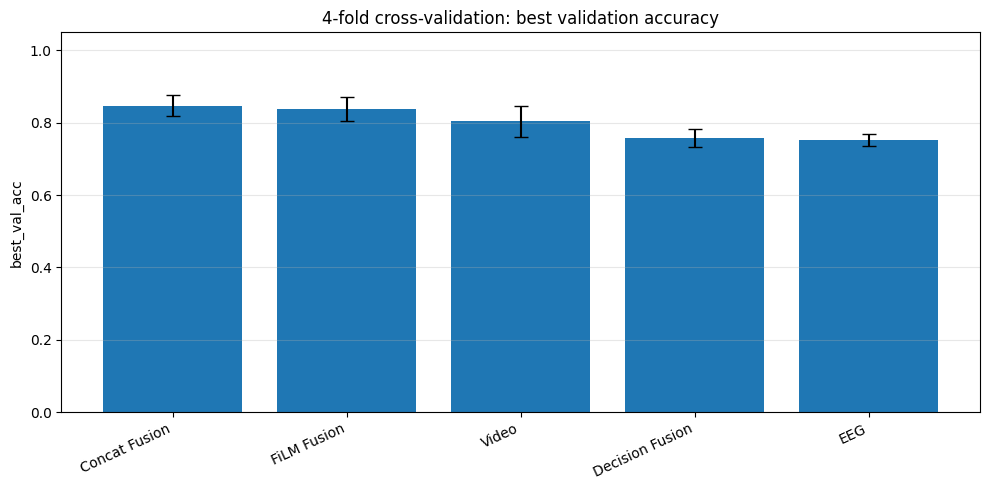

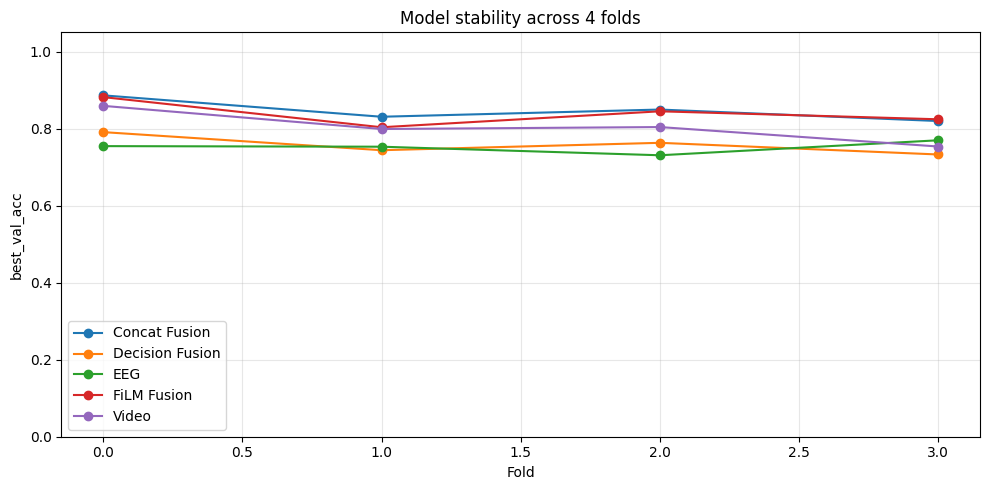

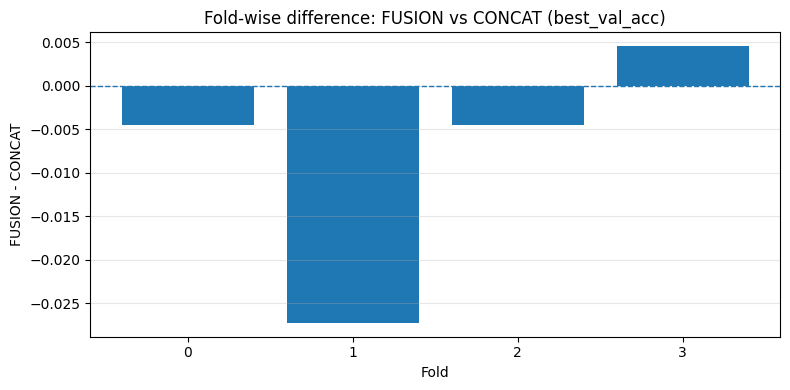

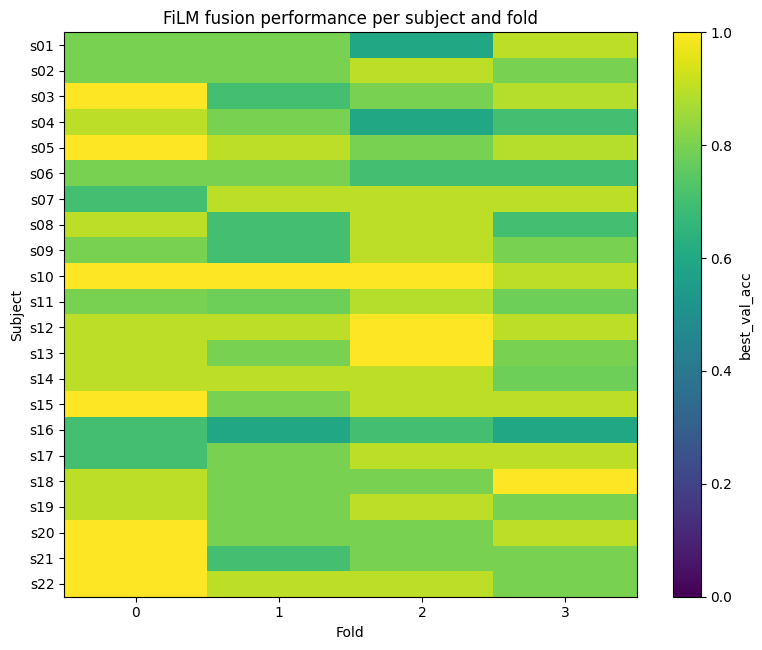

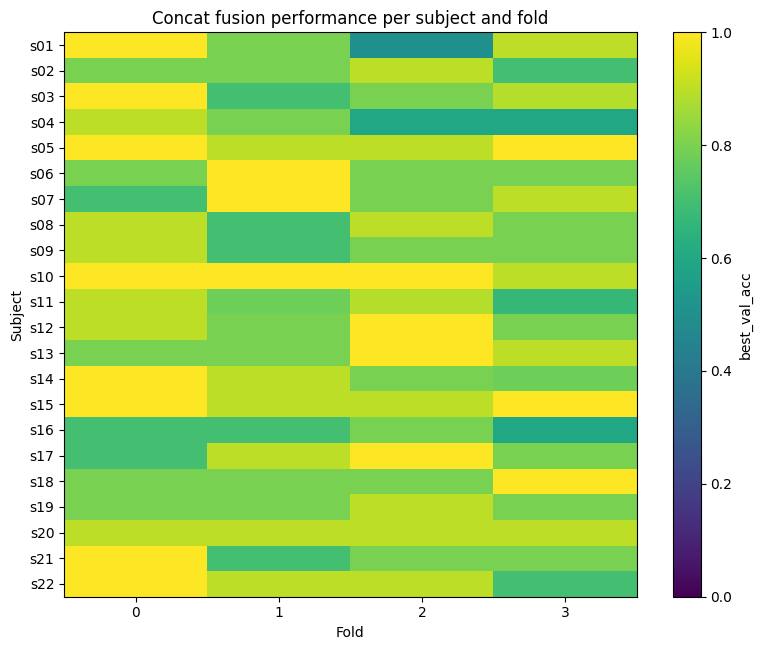

In [ ]:
# Final performance with error bars
plot_cv_summary_bar(
    cv_summary_df,
    metric="best_val_acc",
    title="4-fold cross-validation: best validation accuracy"
)

# Stability across folds
plot_cv_fold_lines(
    cv_fold_df,
    metric="best_val_acc",
    title="Model stability across 4 folds"
)

# FiLM vs Concat
plot_cv_model_difference(
    cv_fold_df,
    model_a="FUSION",
    model_b="CONCAT",
    metric="best_val_acc"
)

# FiLM subject heatmap
plot_subject_heatmap(
    cv_subject_df,
    model="FUSION",
    metric="best_val_acc",
    title="FiLM fusion performance per subject and fold"
)

# Concat subject heatmap
plot_subject_heatmap(
    cv_subject_df,
    model="CONCAT",
    metric="best_val_acc",
    title="Concat fusion performance per subject and fold"
)




plot_film_parameter_histograms(cv_film_stats_df)

plot_film_boxplot_by_label(cv_film_stats_df, "gamma_deviation_from_1")
plot_film_boxplot_by_label(cv_film_stats_df, "beta_abs_mean")
plot_film_boxplot_by_label(cv_film_stats_df, "gate_mean")
plot_film_boxplot_by_label(cv_film_stats_df, "relative_modulation")

plot_film_boxplot_correct_vs_wrong(cv_film_stats_df, "relative_modulation")
plot_film_boxplot_correct_vs_wrong(cv_film_stats_df, "beta_abs_mean")
plot_film_boxplot_correct_vs_wrong(cv_film_stats_df, "gate_mean")

In [ ]:
# =========================================================
# SAVE CV RESULTS
# =========================================================

out_dir = Path("cv_results")
out_dir.mkdir(parents=True, exist_ok=True)

cv_subject_df.to_csv(out_dir / f"cv4_subject_results_label{LABEL_TYPE}.csv", index=False)
cv_fold_df.to_csv(out_dir / f"cv4_fold_results_label{LABEL_TYPE}.csv", index=False)
cv_summary_df.to_csv(out_dir / f"cv4_summary_label{LABEL_TYPE}.csv", index=False)
cv_paper_table.to_csv(out_dir / f"cv4_paper_table_label{LABEL_TYPE}.csv", index=False)

cv_vs_video_df.to_csv(out_dir / f"cv4_comparison_vs_video_label{LABEL_TYPE}.csv", index=False)
cv_vs_concat_df.to_csv(out_dir / f"cv4_comparison_vs_concat_label{LABEL_TYPE}.csv", index=False)
cv_vs_eeg_df.to_csv(out_dir / f"cv4_comparison_vs_eeg_label{LABEL_TYPE}.csv", index=False)
film_vs_concat_df.to_csv(out_dir / f"cv4_film_vs_concat_label{LABEL_TYPE}.csv", index=False)

cv_all_metric_comparisons_df.to_csv(
    out_dir / f"cv4_all_metric_comparisons_label{LABEL_TYPE}.csv",
    index=False,
)

film_vs_concat_all_metrics_df.to_csv(
    out_dir / f"cv4_film_vs_concat_all_metrics_label{LABEL_TYPE}.csv",
    index=False,
)

cv_film_stats_df.to_csv(
    out_dir / f"cv4_film_gamma_beta_gate_trial_stats_label{LABEL_TYPE}.csv",
    index=False,
)

cv_film_summary_df.to_csv(
    out_dir / f"cv4_film_gamma_beta_gate_summary_label{LABEL_TYPE}.csv",
    index=False,
)

print("Saved all CV tables in:", out_dir)

Saved all CV tables in: cv_results


#12. Main Experiment Run :

In [ ]:
def run_main_experiment(label_type=LABEL_TYPE, seed=SEED):
    """
    Main subject-dependent experiment:
    EEG -> Video -> FiLM -> Concat -> Decision
    """
    global CURRENT_CV_FOLD
    global CURRENT_RUN_TAG

    CURRENT_CV_FOLD = None
    CURRENT_RUN_TAG = f"main_label{label_type}_seed{seed}"

    print("=" * 80)
    print(f"MAIN EXPERIMENT | LABEL_TYPE={label_type} | SEED={seed}")
    print("=" * 80)

    # 0) Create the same split for all models
    init_shared_splits(
        eeg_root=DEAP_ROOT,
        image_root=IMAGE_ROOT,
        label_type=label_type,
        max_subject_id=22,
        split_mode="subject_dependent",
        train_ratio=TRAIN_RATIO,
        seed=seed,
    )

    # 1) EEG
    all_eeg = run_all_eeg_shared_split(
        dataset_path=DEAP_ROOT,
        image_root=IMAGE_ROOT,
        label_type=label_type,
        mode=2,
        max_subject_id=22,
        split_mode="subject_dependent",
        train_ratio=TRAIN_RATIO,
        seed=seed,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        verbose=1,
        lambda_cons=0.0,
    )

    # 2) Video
    all_video = run_all_subject_dependent(
        deap_root=DEAP_ROOT,
        image_root=IMAGE_ROOT,
        label_type=label_type,
        max_subject_id=22,
        train_ratio=TRAIN_RATIO,
        seed=seed,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        freeze_backbone=FREEZE_BACKBONE,
    )

    # 3) FiLM
    all_film = run_all_fusion_shared_split(
        eeg_root=DEAP_ROOT,
        image_root=IMAGE_ROOT,
        eeg_results=all_eeg,
        video_results=all_video,
        label_type=label_type,
        eeg_mode=2,
        max_subject_id=22,
        split_mode="subject_dependent",
        train_ratio=TRAIN_RATIO,
        seed=seed,
        num_frames=NUM_FRAMES,
        batch_size=BATCH_SIZE,
        stage1_epochs=15,
        stage2_epochs=5,
        stage1_lr=1e-3,
        stage2_head_lr=5e-5,
        stage2_encoder_lr=1e-6,
        weight_decay=WEIGHT_DECAY,
    )

    # 4) Concat
    all_concat = run_all_concat_fusion_shared_split(
        eeg_root=DEAP_ROOT,
        image_root=IMAGE_ROOT,
        eeg_results=all_eeg,
        video_results=all_video,
        label_type=label_type,
        eeg_mode=2,
        max_subject_id=22,
        split_mode="subject_dependent",
        train_ratio=TRAIN_RATIO,
        seed=seed,
        num_frames=NUM_FRAMES,
        batch_size=BATCH_SIZE,
        stage1_epochs=15,
        stage2_epochs=5,
        stage1_lr=1e-3,
        stage2_head_lr=5e-5,
        stage2_encoder_lr=1e-6,
        weight_decay=WEIGHT_DECAY,
    )

    # 5) Decision fusion
    all_decision = run_all_decision_fusion_shared_split(
        eeg_root=DEAP_ROOT,
        image_root=IMAGE_ROOT,
        eeg_results=all_eeg,
        video_results=all_video,
        label_type=label_type,
        eeg_mode=2,
        max_subject_id=22,
        split_mode="subject_dependent",
        train_ratio=TRAIN_RATIO,
        seed=seed,
        num_frames=NUM_FRAMES,
        batch_size=BATCH_SIZE,
        eeg_weight=0.5,
        video_weight=0.5,
    )

    return {
        "EEG": all_eeg,
        "VIDEO": all_video,
        "FUSION": all_film,
        "CONCAT": all_concat,
        "DECISION": all_decision,
    }

In [ ]:
main_results = run_main_experiment(label_type=LABEL_TYPE, seed=42)

all_eeg_sd = main_results["EEG"]
all_video_sd = main_results["VIDEO"]
all_fusion_sd = main_results["FUSION"]
all_concat_fusion_sd = main_results["CONCAT"]
all_decision_fusion_sd = main_results["DECISION"]

MAIN EXPERIMENT | LABEL_TYPE=1 | SEED=42
Shared splits initialized for split_mode=subject_dependent
Number of stored splits: 22

Running EEG experiment for s01 | split_mode=subject_dependent
split info: {'split_mode': 'subject_dependent', 'target_sid': 's01', 'n_total_pairs': 874, 'n_train_pairs': 30, 'n_val_pairs': 10, 'stratified': True, 'train_label_counts': {0: 12, 1: 18}, 'val_label_counts': {0: 4, 1: 6}}
EEG train dataset size: 30
EEG val dataset size: 10

Epoch 1/20
Train 0.7780/0.5714 | Val 0.7883/0.6000 | Score 0.4059
↗ New best Score 0.4059

Epoch 2/20
Train 0.7530/0.6429 | Val 0.6640/0.6000 | Score 0.4680
↗ New best Score 0.4680

Epoch 3/20
Train 0.6478/0.6071 | Val 0.6618/0.6000 | Score 0.4691
↗ New best Score 0.4691

Epoch 4/20
Train 0.6122/0.6429 | Val 0.6554/0.6000 | Score 0.4723
↗ New best Score 0.4723

Epoch 5/20
Train 0.5614/0.7500 | Val 0.6736/0.6000 | Score 0.4632

Epoch 6/20
Train 0.5300/0.6429 | Val 0.6204/0.6000 | Score 0.4898
↗ New best Score 0.4898

Epoch 7/20


100%|██████████| 44.7M/44.7M [00:00<00:00, 138MB/s]


Epoch [1/20] | Train Loss: 0.7805 | Train Acc: 0.5000 | Val Loss: 0.7387 | Val Acc: 0.4000
Epoch [2/20] | Train Loss: 0.7009 | Train Acc: 0.5333 | Val Loss: 0.7065 | Val Acc: 0.6000
Epoch [3/20] | Train Loss: 0.8758 | Train Acc: 0.6000 | Val Loss: 0.7045 | Val Acc: 0.6000
Epoch [4/20] | Train Loss: 0.7211 | Train Acc: 0.5000 | Val Loss: 0.7768 | Val Acc: 0.4000
Epoch [5/20] | Train Loss: 0.6920 | Train Acc: 0.5333 | Val Loss: 0.6820 | Val Acc: 0.6000
Epoch [6/20] | Train Loss: 0.7127 | Train Acc: 0.6000 | Val Loss: 0.6697 | Val Acc: 0.6000
Epoch [7/20] | Train Loss: 0.6610 | Train Acc: 0.5333 | Val Loss: 0.6668 | Val Acc: 0.6000
Epoch [8/20] | Train Loss: 0.6447 | Train Acc: 0.6000 | Val Loss: 0.6728 | Val Acc: 0.6000
Epoch [9/20] | Train Loss: 0.6842 | Train Acc: 0.6333 | Val Loss: 0.6600 | Val Acc: 0.6000
Epoch [10/20] | Train Loss: 0.6328 | Train Acc: 0.6333 | Val Loss: 0.6609 | Val Acc: 0.6000
Epoch [11/20] | Train Loss: 0.6361 | Train Acc: 0.6667 | Val Loss: 0.6528 | Val Acc: 0.80

,statistic,mean,std,min,max
0,gamma_mean,1.000474,0.000933,0.999468,1.001471
1,gamma_std,0.079369,0.014698,0.049315,0.095703
2,gamma_deviation_from_1,0.077569,0.015388,0.046108,0.094823
3,beta_mean,-0.000479,0.000946,-0.001439,0.000730
4,beta_std,0.080360,0.014716,0.049555,0.096357
5,beta_abs_mean,0.078532,0.015370,0.046421,0.095482
6,gate_mean,0.229909,0.043815,0.162452,0.307316
7,gate_std,0.080848,0.020871,0.054287,0.132561
8,relative_modulation,0.031186,0.007244,0.020823,0.048193
9,correct,0.800000,0.421637,0.000000,1.000000



Running FUSION for s02 | split_mode=subject_dependent
Fusion train size: 30
Fusion val size: 10

FUSION STAGE 1: train FiLM + classifier only
Epoch [1/15] | Train Loss: 0.7259 | Train Acc: 0.6429 | Val Loss: 0.7292 | Val Acc: 0.6000
Epoch [2/15] | Train Loss: 0.7988 | Train Acc: 0.5714 | Val Loss: 0.7245 | Val Acc: 0.5000
Epoch [3/15] | Train Loss: 0.8042 | Train Acc: 0.4286 | Val Loss: 0.6787 | Val Acc: 0.4000
Epoch [4/15] | Train Loss: 0.7106 | Train Acc: 0.5714 | Val Loss: 0.6768 | Val Acc: 0.6000
Epoch [5/15] | Train Loss: 0.6637 | Train Acc: 0.6071 | Val Loss: 0.7239 | Val Acc: 0.5000
Epoch [6/15] | Train Loss: 0.6753 | Train Acc: 0.6429 | Val Loss: 0.6655 | Val Acc: 0.6000
Epoch [7/15] | Train Loss: 0.6740 | Train Acc: 0.6429 | Val Loss: 0.6670 | Val Acc: 0.6000
Epoch [8/15] | Train Loss: 0.6187 | Train Acc: 0.6786 | Val Loss: 0.7021 | Val Acc: 0.6000
Epoch [9/15] | Train Loss: 0.6986 | Train Acc: 0.6429 | Val Loss: 0.6645 | Val Acc: 0.6000
Epoch [10/15] | Train Loss: 0.6587 | T

...


Running FUSION for s21 | split_mode=subject_dependent
Fusion train size: 30
Fusion val size: 10

FUSION STAGE 1: train FiLM + classifier only
Epoch [1/15] | Train Loss: 0.8528 | Train Acc: 0.5714 | Val Loss: 0.8638 | Val Acc: 0.8000
Epoch [2/15] | Train Loss: 0.6761 | Train Acc: 0.8214 | Val Loss: 0.5604 | Val Acc: 0.8000
Epoch [3/15] | Train Loss: 0.5272 | Train Acc: 0.7857 | Val Loss: 0.5122 | Val Acc: 0.8000
Epoch [4/15] | Train Loss: 0.6041 | Train Acc: 0.7143 | Val Loss: 0.6363 | Val Acc: 0.8000
Epoch [5/15] | Train Loss: 0.5412 | Train Acc: 0.7500 | Val Loss: 0.5172 | Val Acc: 0.8000
Epoch [6/15] | Train Loss: 0.4415 | Train Acc: 0.8571 | Val Loss: 0.5720 | Val Acc: 0.8000
Epoch [7/15] | Train Loss: 0.5464 | Train Acc: 0.7857 | Val Loss: 0.5238 | Val Acc: 0.8000
Epoch [8/15] | Train Loss: 0.4472 | Train Acc: 0.8214 | Val Loss: 0.5225 | Val Acc: 0.8000
Epoch [9/15] | Train Loss: 0.4953 | Train Acc: 0.7857 | Val Loss: 0.5187 | Val Acc: 0.8000
Epoch [10/15] | Train Loss: 0.4668 | T

,statistic,mean,std,min,max
0,gamma_mean,1.000492,0.000028,1.000453,1.000533
1,gamma_std,0.010444,0.000311,0.009892,0.010924
2,gamma_deviation_from_1,0.008194,0.000247,0.007748,0.008569
3,beta_mean,0.000352,0.000026,0.000313,0.000407
4,beta_std,0.011057,0.000314,0.010488,0.011555
5,beta_abs_mean,0.008969,0.000262,0.008494,0.009382
6,gate_mean,0.118958,0.000117,0.118697,0.119080
7,gate_std,0.023019,0.001039,0.021224,0.024455
8,relative_modulation,0.002493,0.000103,0.002337,0.002652
9,correct,0.800000,0.421637,0.000000,1.000000



Running FUSION for s22 | split_mode=subject_dependent
Fusion train size: 30
Fusion val size: 10

FUSION STAGE 1: train FiLM + classifier only
Epoch [1/15] | Train Loss: 0.9341 | Train Acc: 0.6071 | Val Loss: 0.8871 | Val Acc: 0.6000
Epoch [2/15] | Train Loss: 0.7877 | Train Acc: 0.4643 | Val Loss: 0.7019 | Val Acc: 0.5000
Epoch [3/15] | Train Loss: 0.7076 | Train Acc: 0.6071 | Val Loss: 0.7220 | Val Acc: 0.6000
Epoch [4/15] | Train Loss: 0.6737 | Train Acc: 0.6429 | Val Loss: 0.6952 | Val Acc: 0.5000
Epoch [5/15] | Train Loss: 0.7382 | Train Acc: 0.4643 | Val Loss: 0.6899 | Val Acc: 0.6000
Epoch [6/15] | Train Loss: 0.6113 | Train Acc: 0.6786 | Val Loss: 0.6734 | Val Acc: 0.6000
Epoch [7/15] | Train Loss: 0.5583 | Train Acc: 0.6429 | Val Loss: 0.6669 | Val Acc: 0.6000
Epoch [8/15] | Train Loss: 0.5580 | Train Acc: 0.6786 | Val Loss: 0.6963 | Val Acc: 0.6000
Epoch [9/15] | Train Loss: 0.4866 | Train Acc: 0.8214 | Val Loss: 0.6402 | Val Acc: 0.5000
Epoch [10/15] | Train Loss: 0.4703 | T

,statistic,mean,std,min,max
0,gamma_mean,1.001580,0.001062,0.999168,1.002553
1,gamma_std,0.057699,0.020986,0.027562,0.084284
2,gamma_deviation_from_1,0.053544,0.022270,0.021724,0.081546
3,beta_mean,0.001016,0.000959,-0.000742,0.001978
4,beta_std,0.058720,0.021289,0.028541,0.085606
5,beta_abs_mean,0.054615,0.022898,0.022211,0.083321
6,gate_mean,0.425098,0.074877,0.276408,0.543296
7,gate_std,0.176485,0.041192,0.091128,0.237612
8,relative_modulation,0.051014,0.023782,0.017402,0.081890
9,correct,0.800000,0.421637,0.000000,1.000000



############################################################
FUSION RESULTS
############################################################
s01: best_val_acc=0.8000
s02: best_val_acc=0.6000
s03: best_val_acc=0.9000
s04: best_val_acc=0.8000
s05: best_val_acc=0.6000
s06: best_val_acc=0.7000
s07: best_val_acc=0.7000
s08: best_val_acc=0.9000
s09: best_val_acc=0.6000
s10: best_val_acc=0.8000
s11: best_val_acc=0.7000
s12: best_val_acc=0.9000
s13: best_val_acc=0.8000
s14: best_val_acc=0.9000
s15: best_val_acc=0.7000
s16: best_val_acc=0.6000
s17: best_val_acc=0.7000
s18: best_val_acc=0.7000
s19: best_val_acc=0.7000
s20: best_val_acc=0.8000
s21: best_val_acc=0.8000
s22: best_val_acc=0.8000

Mean best fusion accuracy: 0.7500

Running CONCAT FUSION for s01 | split_mode=subject_dependent
Concat fusion train size: 30
Concat fusion val size: 10

CONCAT FUSION STAGE 1: train classifier only
Epoch [1/15] | Train Loss: 0.7154 | Train Acc: 0.5714 | Val Loss: 0.7315 | Val Acc: 0.6000
Epoch [2/15] | Train L

# 12. Results and Visualizations

In [ ]:


# =========================================================
# 1) STANDARDIZED RESULT FORMAT
# =========================================================
#
# Target format:
#
# standardized = {
#     "model_name": "EEG" / "VIDEO" / "FUSION",
#     "source_type": "eeg" / "video" / "fusion",
#     "split_mode": "...",
#     "subject_results": {
#         "s01": {
#             "history": {...} or None,
#             "detailed_metrics": {...} or None,
#             "best_val_acc": float or None,
#             "last_val_acc": float or None,
#             "save_path": str or None,
#             "split_info": dict or None,
#             "selected_stage": str or None,
#             "extra": {...}
#         },
#         ...
#     }
# }
#
# For random_all/global runs, we map the global result to subject key "global"
# so the same plotting functions still work.


def _safe_get(d, key, default=None):
    """
    Safe dictionary getter.
    """
    if d is None:
        return default
    return d.get(key, default)


def _extract_last_val_acc_from_history(history):
    """
    Extract the last validation accuracy from a history dict.
    """
    if history is None:
        return None

    val_acc = history.get("val_acc")
    if val_acc is None or len(val_acc) == 0:
        return None

    return float(val_acc[-1])


def _standardize_entry(
    entry,
    split_info=None,
    selected_stage=None,
    keep_extra_keys=None,
):
    """
    Convert one raw result entry into the common standardized entry format.
    """
    if keep_extra_keys is None:
        keep_extra_keys = []

    history = entry.get("history")
    detailed_metrics = entry.get("detailed_metrics")

    best_val_acc = entry.get("best_val_acc")
    last_val_acc = entry.get("last_val_acc")

    # If last_val_acc is missing but history exists, infer it.
    if last_val_acc is None:
        last_val_acc = _extract_last_val_acc_from_history(history)

    standardized = {
        "history": history,
        "detailed_metrics": detailed_metrics,
        "best_val_acc": float(best_val_acc) if best_val_acc is not None else None,
        "last_val_acc": float(last_val_acc) if last_val_acc is not None else None,
        "save_path": entry.get("save_path"),
        "split_info": split_info if split_info is not None else entry.get("split_info"),
        "selected_stage": selected_stage if selected_stage is not None else entry.get("selected_stage"),
        "extra": {},
    }

    for k in keep_extra_keys:
        if k in entry:
            standardized["extra"][k] = entry[k]

    return standardized


def standardize_eeg_results(raw_results, model_name="EEG"):
    """
    Standardize EEG results.

    Supports:
    - per-subject results from run_all_eeg_shared_split(...)
    - global random_all results from run_all_eeg_shared_split(...)

    Returns:
        standardized result dict
    """
    out = {
        "model_name": model_name,
        "source_type": "eeg",
        "split_mode": raw_results.get("split_mode"),
        "subject_results": {},
    }

    # Case 1: per-subject
    if "subject_results" in raw_results:
        for sid, entry in raw_results["subject_results"].items():
            out["subject_results"][sid] = _standardize_entry(
                entry,
                split_info=entry.get("split_info"),
            )
        return out

    # Case 2: global_result
    if "global_result" in raw_results:
        global_entry = raw_results["global_result"]
        out["split_mode"] = raw_results.get("split_info", {}).get("split_mode", out["split_mode"])
        out["subject_results"]["global"] = _standardize_entry(
            global_entry,
            split_info=raw_results.get("split_info"),
        )
        return out

    raise ValueError("Could not recognize EEG result structure.")


def standardize_video_results(raw_results, model_name="VIDEO"):
    """
    Standardize video results.

    Supports:
    - per-subject results from run_all_subject_dependent(...)
    - optional global_result structure if you later add random_all for video

    Returns:
        standardized result dict
    """
    out = {
        "model_name": model_name,
        "source_type": "video",
        "split_mode": raw_results.get("split_mode", "subject_dependent"),
        "subject_results": {},
    }

    if "subject_results" in raw_results:
        for sid, entry in raw_results["subject_results"].items():
            out["subject_results"][sid] = _standardize_entry(
                entry,
                split_info=entry.get("split_info"),
            )
        return out

    if "global_result" in raw_results:
        global_entry = raw_results["global_result"]
        out["split_mode"] = raw_results.get("split_info", {}).get("split_mode", out["split_mode"])
        out["subject_results"]["global"] = _standardize_entry(
            global_entry,
            split_info=raw_results.get("split_info"),
        )
        return out

    raise ValueError("Could not recognize VIDEO result structure.")


def standardize_fusion_results(raw_results, model_name="FUSION"):
    """
    Standardize fusion results.

    Supports:
    - per-subject results from run_all_fusion_shared_split(...)
    - global random_all results from run_all_fusion_shared_split(...)

    Returns:
        standardized result dict
    """
    out = {
        "model_name": model_name,
        "source_type": "fusion",
        "split_mode": raw_results.get("split_mode"),
        "subject_results": {},
    }

    if "subject_results" in raw_results:
        for sid, entry in raw_results["subject_results"].items():
            out["subject_results"][sid] = _standardize_entry(
                entry,
                split_info=entry.get("split_info"),
                selected_stage=entry.get("selected_stage"),
                keep_extra_keys=[
                    "stage1_best_val_acc",
                    "stage2_best_val_acc",
                    "stage1_history",
                    "stage2_history",
                    "stage1_metrics",
                    "stage2_metrics",
                ],
            )
        return out

    if "global_result" in raw_results:
        global_entry = raw_results["global_result"]
        out["split_mode"] = raw_results.get("split_info", {}).get("split_mode", out["split_mode"])
        out["subject_results"]["global"] = _standardize_entry(
            global_entry,
            split_info=raw_results.get("split_info"),
            selected_stage=global_entry.get("selected_stage"),
            keep_extra_keys=[
                "stage1_best_val_acc",
                "stage2_best_val_acc",
                "stage1_history",
                "stage2_history",
                "stage1_metrics",
                "stage2_metrics",
            ],
        )
        return out

    raise ValueError("Could not recognize FUSION result structure.")

# =========================================================
# COLLECT MAIN-SPLIT FiLM GAMMA / BETA / GATE ANALYSIS
# =========================================================

def collect_main_film_stats(all_fusion_sd):
    """
    Collect FiLM statistics from the main subject-dependent run.

    Input:
        all_fusion_sd = output of run_all_fusion_shared_split(...)

    Output:
        one row = one validation trial
    """
    rows = []

    subject_results = all_fusion_sd.get("subject_results", {})

    for sid, entry in subject_results.items():
        film_stats = entry.get("film_stats")

        if film_stats is None or len(film_stats) == 0:
            continue

        df = film_stats.copy()
        df["subject"] = sid
        df["model"] = "FUSION"
        df["run_type"] = "main_subject_dependent"

        rows.append(df)

    if len(rows) == 0:
        print("No FiLM stats found. Did you add film_stats to the fusion return dictionary and rerun all_fusion_sd?")
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


def build_main_film_summary_table(main_film_stats_df):
    """
    Compact summary table for the main split FiLM analysis.
    """
    if main_film_stats_df is None or len(main_film_stats_df) == 0:
        return pd.DataFrame()

    metrics = [
        "gamma_mean",
        "gamma_std",
        "gamma_deviation_from_1",
        "beta_mean",
        "beta_std",
        "beta_abs_mean",
        "gate_mean",
        "gate_std",
        "relative_modulation",
    ]

    rows = []

    for metric in metrics:
        vals = pd.to_numeric(main_film_stats_df[metric], errors="coerce").dropna()

        rows.append({
            "metric": metric,
            "mean": float(vals.mean()),
            "std": float(vals.std(ddof=1)),
            "min": float(vals.min()),
            "max": float(vals.max()),
        })

    return pd.DataFrame(rows)



# =========================================================
# 2) TABLE BUILDERS
# =========================================================

def _extract_training_stats_from_history(history):
    """
    Extract useful training-side summary metrics from a history dict.
    """
    if history is None:
        return {
            "best_train_acc": None,
            "last_train_acc": None,
            "best_train_loss": None,
            "last_train_loss": None,
        }

    train_acc = history.get("train_acc", [])
    train_loss = history.get("train_loss", [])

    return {
        "best_train_acc": float(max(train_acc)) if len(train_acc) > 0 else None,
        "last_train_acc": float(train_acc[-1]) if len(train_acc) > 0 else None,
        "best_train_loss": float(min(train_loss)) if len(train_loss) > 0 else None,
        "last_train_loss": float(train_loss[-1]) if len(train_loss) > 0 else None,
    }

def build_subject_metrics_table(std_results):
    """
    Build one per-subject metrics table from standardized results,
    including training-side summary metrics and train/val gaps.
    """
    rows = []

    for sid, entry in std_results["subject_results"].items():
        dm = entry.get("detailed_metrics") or {}
        history = entry.get("history")

        train_stats = _extract_training_stats_from_history(history)

        best_val_acc = entry.get("best_val_acc")
        last_val_acc = entry.get("last_val_acc")

        best_train_acc = train_stats["best_train_acc"]
        last_train_acc = train_stats["last_train_acc"]
        best_train_loss = train_stats["best_train_loss"]
        last_train_loss = train_stats["last_train_loss"]

        row = {
            "subject": sid,

            # validation-side metrics
            "best_val_acc": best_val_acc,
            "last_val_acc": last_val_acc,
            "acc": dm.get("acc"),
            "balanced_acc": dm.get("balanced_acc"),
            "precision": dm.get("precision"),
            "recall": dm.get("recall"),
            "f1": dm.get("f1"),
            "loss": dm.get("loss"),

            # training-side metrics
            "best_train_acc": best_train_acc,
            "last_train_acc": last_train_acc,
            "best_train_loss": best_train_loss,
            "last_train_loss": last_train_loss,

            # train-vs-val gaps
            "best_gap_acc": (
                best_train_acc - best_val_acc
                if best_train_acc is not None and best_val_acc is not None else None
            ),
            "last_gap_acc": (
                last_train_acc - last_val_acc
                if last_train_acc is not None and last_val_acc is not None else None
            ),

            "selected_stage": entry.get("selected_stage"),
            "save_path": entry.get("save_path"),
        }
        rows.append(row)

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df

    return df.sort_values("subject").reset_index(drop=True)

def build_summary_table(std_results):
    """
    Build a one-row summary table with mean/std/min/max over subjects.
    """
    df = build_subject_metrics_table(std_results)
    if len(df) == 0:
        return pd.DataFrame()

    metric_cols = [
        # validation-side
        "best_val_acc",
        "last_val_acc",
        "acc",
        "balanced_acc",
        "precision",
        "recall",
        "f1",
        "loss",

        # training-side
        "best_train_acc",
        "last_train_acc",
        "best_train_loss",
        "last_train_loss",

        # gaps
        "best_gap_acc",
        "last_gap_acc",
    ]

    summary = {}
    for col in metric_cols:
        vals = pd.to_numeric(df[col], errors="coerce").dropna()
        if len(vals) == 0:
            continue

        summary[f"{col}_mean"] = float(vals.mean())
        summary[f"{col}_std"] = float(vals.std(ddof=1)) if len(vals) > 1 else 0.0
        summary[f"{col}_min"] = float(vals.min())
        summary[f"{col}_max"] = float(vals.max())

    summary["model_name"] = std_results.get("model_name")
    summary["source_type"] = std_results.get("source_type")
    summary["split_mode"] = std_results.get("split_mode")

    return pd.DataFrame([summary])


def build_confusion_matrix_table(std_results, sid):
    """
    Return the confusion matrix of one subject as a DataFrame.
    """
    entry = std_results["subject_results"][sid]
    dm = entry.get("detailed_metrics") or {}
    cm = np.array(dm.get("confusion_matrix", [[0, 0], [0, 0]]))

    return pd.DataFrame(
        cm,
        index=["true_0", "true_1"],
        columns=["pred_0", "pred_1"],
    )


def build_prediction_table(std_results, sid):
    """
    Build a DataFrame containing y_true and y_pred for one subject.
    """
    entry = std_results["subject_results"][sid]
    dm = entry.get("detailed_metrics") or {}

    y_true = dm.get("y_true", [])
    y_pred = dm.get("y_pred", [])

    return pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        "correct": [int(a == b) for a, b in zip(y_true, y_pred)],
    })


# =========================================================
# 3) PLOTTING HELPERS
# =========================================================

def _get_history(std_results, sid):
    """
    Fetch subject history safely.
    """
    entry = std_results["subject_results"][sid]
    history = entry.get("history")
    if history is None:
        raise ValueError(f"No history found for subject '{sid}'.")
    return history


def _subject_ids(std_results):
    """
    Return sorted subject ids.
    """
    return sorted(std_results["subject_results"].keys())


# =========================================================
# 4) SINGLE-SUBJECT PLOTS
# =========================================================

def plot_subject_curves(std_results, sid):
    """
    Plot train/val loss and accuracy for one subject.
    """
    history = _get_history(std_results, sid)

    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o", label="train_loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{std_results['model_name']} - {sid} - Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], marker="o", label="train_acc")
    plt.plot(epochs, history["val_acc"], marker="o", label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{std_results['model_name']} - {sid} - Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_subject_confusion_matrix(std_results, sid, normalize=False):
    """
    Plot the confusion matrix for one subject.
    """
    entry = std_results["subject_results"][sid]
    dm = entry.get("detailed_metrics") or {}
    cm = np.array(dm.get("confusion_matrix", [[0, 0], [0, 0]]))

    if normalize:
        cm = cm.astype(float)
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        cm = cm / row_sums
        values_format = ".2f"
    else:
        cm = cm.astype(int)
        values_format = "d"

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[0, 1],
    )
    disp.plot(values_format=values_format)
    plt.title(
        f"{std_results['model_name']} - {sid} - Confusion Matrix"
        + (" (Normalized)" if normalize else "")
    )
    plt.show()


def plot_subject_prediction_table(std_results, sid, n_rows=20):
    """
    Return the first rows of the prediction table for quick inspection.
    """
    return build_prediction_table(std_results, sid).head(n_rows)


# =========================================================
# 5) ALL-SUBJECT PLOTS
# =========================================================

def plot_metric_bar(std_results, metric="best_val_acc", sort=True):
    """
    Plot one metric across all subjects.
    """
    df = build_subject_metrics_table(std_results)
    if len(df) == 0:
        print("Empty results.")
        return

    if metric not in df.columns:
        raise ValueError(f"Metric '{metric}' not found. Available: {list(df.columns)}")

    plot_df = df[["subject", metric]].copy()

    if sort:
        plot_df = plot_df.sort_values(metric, ascending=False)

    plt.figure(figsize=(12, 5))
    plt.bar(plot_df["subject"], plot_df[metric])
    plt.xlabel("Subject")
    plt.ylabel(metric)
    plt.title(f"{std_results['model_name']} - {metric} across subjects")
    plt.xticks(rotation=45)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_mean_curves(std_results):
    """
    Plot mean train/val loss and accuracy across subjects,
    even when histories have different lengths.

    Strategy:
    - collect all available histories
    - pad shorter histories with NaN
    - compute nanmean / nanstd per epoch
    """
    sids = sorted(std_results["subject_results"].keys())
    if len(sids) == 0:
        print("Empty results.")
        return

    train_loss_all = []
    val_loss_all = []
    train_acc_all = []
    val_acc_all = []

    for sid in sids:
        hist = std_results["subject_results"][sid].get("history")
        if hist is None:
            continue

        # keep only subjects with complete keys
        needed = ["train_loss", "val_loss", "train_acc", "val_acc"]
        if not all(k in hist for k in needed):
            continue

        train_loss_all.append(list(hist["train_loss"]))
        val_loss_all.append(list(hist["val_loss"]))
        train_acc_all.append(list(hist["train_acc"]))
        val_acc_all.append(list(hist["val_acc"]))

    if len(train_loss_all) == 0:
        print("No usable histories available.")
        return

    max_len = max(len(x) for x in train_loss_all)

    def pad_with_nan(seqs, max_len):
        arr = np.full((len(seqs), max_len), np.nan, dtype=float)
        for i, seq in enumerate(seqs):
            arr[i, :len(seq)] = seq
        return arr

    train_loss_all = pad_with_nan(train_loss_all, max_len)
    val_loss_all = pad_with_nan(val_loss_all, max_len)
    train_acc_all = pad_with_nan(train_acc_all, max_len)
    val_acc_all = pad_with_nan(val_acc_all, max_len)

    epochs = np.arange(1, max_len + 1)

    train_loss_mean = np.nanmean(train_loss_all, axis=0)
    val_loss_mean = np.nanmean(val_loss_all, axis=0)
    train_loss_std = np.nanstd(train_loss_all, axis=0)
    val_loss_std = np.nanstd(val_loss_all, axis=0)

    train_acc_mean = np.nanmean(train_acc_all, axis=0)
    val_acc_mean = np.nanmean(val_acc_all, axis=0)
    train_acc_std = np.nanstd(train_acc_all, axis=0)
    val_acc_std = np.nanstd(val_acc_all, axis=0)

    plt.figure(figsize=(12, 4))

    # Mean loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss_mean, marker="o", label="mean_train_loss")
    plt.plot(epochs, val_loss_mean, marker="o", label="mean_val_loss")
    plt.fill_between(
        epochs,
        train_loss_mean - train_loss_std,
        train_loss_mean + train_loss_std,
        alpha=0.2
    )
    plt.fill_between(
        epochs,
        val_loss_mean - val_loss_std,
        val_loss_mean + val_loss_std,
        alpha=0.2
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{std_results['model_name']} - Mean Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Mean accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc_mean, marker="o", label="mean_train_acc")
    plt.plot(epochs, val_acc_mean, marker="o", label="mean_val_acc")
    plt.fill_between(
        epochs,
        train_acc_mean - train_acc_std,
        train_acc_mean + train_acc_std,
        alpha=0.2
    )
    plt.fill_between(
        epochs,
        val_acc_mean - val_acc_std,
        val_acc_mean + val_acc_std,
        alpha=0.2
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{std_results['model_name']} - Mean Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_all_subject_confusions(std_results, normalize=False, ncols=4):
    """
    Plot confusion matrices for all subjects in a grid.
    """
    sids = sorted(std_results["subject_results"].keys())
    if len(sids) == 0:
        print("Empty results.")
        return

    n = len(sids)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, sid in zip(axes, sids):
        entry = std_results["subject_results"][sid]
        dm = entry.get("detailed_metrics") or {}
        cm = np.array(dm.get("confusion_matrix", [[0, 0], [0, 0]]))

        if normalize:
            cm = cm.astype(float)
            row_sums = cm.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1.0
            cm = cm / row_sums
        else:
            cm = cm.astype(int)

        ax.imshow(cm)
        ax.set_title(sid)
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xlabel("Pred")
        ax.set_ylabel("True")

        for i in range(2):
            for j in range(2):
                txt = f"{cm[i, j]:.2f}" if normalize else f"{int(cm[i, j])}"
                ax.text(j, i, txt, ha="center", va="center")

    for ax in axes[len(sids):]:
        ax.axis("off")

    plt.suptitle(
        f"{std_results['model_name']} - Confusion Matrices"
        + (" (Normalized)" if normalize else "")
    )
    plt.tight_layout()
    plt.show()


def plot_metric_box(std_results, metrics=None):
    """
    Plot boxplots for selected metrics across subjects.
    """
    if metrics is None:
        metrics = ["best_val_acc", "acc", "balanced_acc", "precision", "recall", "f1"]

    df = build_subject_metrics_table(std_results)
    if len(df) == 0:
        print("Empty results.")
        return

    existing = [m for m in metrics if m in df.columns]
    if len(existing) == 0:
        print("No requested metrics found.")
        return

    plot_data = [pd.to_numeric(df[m], errors="coerce").dropna().values for m in existing]

    plt.figure(figsize=(10, 5))
    plt.boxplot(plot_data, labels=existing)
    plt.ylabel("Value")
    plt.title(f"{std_results['model_name']} - Metric Distributions")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# =========================================================
# FiLM PARAMETER VISUALIZATION FUNCTIONS
# =========================================================

def plot_film_parameter_histograms(film_stats_df):
    """
    Histograms of key FiLM modulation statistics.
    Works for both main split and K-fold FiLM stats.
    """
    if film_stats_df is None or len(film_stats_df) == 0:
        print("No FiLM stats available.")
        return

    cols = [
        "gamma_mean",
        "gamma_std",
        "gamma_deviation_from_1",
        "beta_mean",
        "beta_std",
        "beta_abs_mean",
        "gate_mean",
        "relative_modulation",
    ]

    existing_cols = [c for c in cols if c in film_stats_df.columns]

    film_stats_df[existing_cols].hist(figsize=(14, 10), bins=25)
    plt.suptitle("FiLM modulation statistics across validation trials")
    plt.tight_layout()
    plt.show()


def plot_film_boxplot_by_label(film_stats_df, column):
    """
    Boxplot of one FiLM statistic grouped by label.
    """
    if film_stats_df is None or len(film_stats_df) == 0:
        print("No FiLM stats available.")
        return

    if column not in film_stats_df.columns:
        print(f"Column not found: {column}")
        return

    labels = sorted(film_stats_df["label"].dropna().unique())

    data = [
        film_stats_df[film_stats_df["label"] == lab][column].dropna().values
        for lab in labels
    ]

    plt.figure(figsize=(6, 4))
    plt.boxplot(data, labels=[str(lab) for lab in labels])
    plt.xlabel("Label")
    plt.ylabel(column)
    plt.title(f"{column} by label")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_film_boxplot_correct_vs_wrong(film_stats_df, column):
    """
    Boxplot of one FiLM statistic for wrong vs correct predictions.
    """
    if film_stats_df is None or len(film_stats_df) == 0:
        print("No FiLM stats available.")
        return

    if column not in film_stats_df.columns:
        print(f"Column not found: {column}")
        return

    data = [
        film_stats_df[film_stats_df["correct"] == 0][column].dropna().values,
        film_stats_df[film_stats_df["correct"] == 1][column].dropna().values,
    ]

    plt.figure(figsize=(6, 4))
    plt.boxplot(data, labels=["Wrong", "Correct"])
    plt.xlabel("Prediction")
    plt.ylabel(column)
    plt.title(f"{column}: correct vs wrong predictions")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
# =========================================================
# 6) EXPORT HELPERS
# =========================================================

def save_tables_to_csv(std_results, out_dir="metrics_exports", prefix=None):
    """
    Save the per-subject table and summary table to CSV.
    """
    os.makedirs(out_dir, exist_ok=True)

    if prefix is None:
        prefix = std_results["model_name"].lower()

    subject_df = build_subject_metrics_table(std_results)
    summary_df = build_summary_table(std_results)

    subject_path = os.path.join(out_dir, f"{prefix}_subject_metrics.csv")
    summary_path = os.path.join(out_dir, f"{prefix}_summary_metrics.csv")

    subject_df.to_csv(subject_path, index=False)
    summary_df.to_csv(summary_path, index=False)

    print("Saved:", subject_path)
    print("Saved:", summary_path)


# =========================================================
# 7) CONVENIENCE REPORT
# =========================================================

def quick_report(std_results, sid=None, normalize_cm=True):
    """
    Quick report:
    - print summary table
    - print subject metrics table
    - plot mean curves
    - optionally plot one subject curves + confusion matrix

    Args:
        std_results: standardized result dict
        sid: optional subject id
        normalize_cm: whether to normalize the confusion matrix
    """
    df_subject = build_subject_metrics_table(std_results)
    df_summary = build_summary_table(std_results)

    print("\nSubject metrics:")
    print(df_subject)

    print("\nSummary:")
    print(df_summary)

    plot_mean_curves(std_results)
    plot_metric_bar(std_results, metric="best_val_acc")
    plot_metric_box(std_results)

    if sid is not None:
        plot_subject_curves(std_results, sid)
        plot_subject_confusion_matrix(std_results, sid, normalize=normalize_cm)



EEG subject metrics


,subject,best_val_acc,last_val_acc,acc,balanced_acc,precision,recall,f1,loss,best_train_acc,last_train_acc,best_train_loss,last_train_loss,best_gap_acc,last_gap_acc,selected_stage,save_path
0,s01,0.7,0.6,0.7,0.708333,0.800000,0.666667,0.727273,0.517956,1.0,1.000000,0.000551,0.000551,0.3,0.400000,None,models/main_label1_seed42/EEG_TR_subject_depen...
1,s02,0.6,0.5,0.6,0.500000,0.600000,1.000000,0.750000,0.702334,1.0,1.000000,0.000718,0.000792,0.4,0.500000,None,models/main_label1_seed42/EEG_TR_subject_depen...
2,s03,0.9,0.8,0.9,0.750000,1.000000,0.500000,0.666667,0.595762,1.0,1.000000,0.000098,0.000098,0.1,0.200000,None,models/main_label1_seed42/EEG_TR_subject_depen...
3,s04,0.8,0.6,0.8,0.750000,1.000000,0.500000,0.666667,0.574312,1.0,0.821429,0.000561,0.317780,0.2,0.221429,None,models/main_label1_seed42/EEG_TR_subject_depen...
4,s05,0.6,0.4,0.5,0.500000,0.500000,0.200000,0.285714,0.718633,1.0,0.892857,0.006036,0.295326,0.4,0.492857,None,models/main_label1_seed42/EEG_TR_subject_depen...
5,s06,0.7,0.3,0.7,0.666667,0.666667,0.500000,0.571429,0.700309,1.0,1.000000,0.000346,0.000349,0.3,0.700000,None,models/main_label1_seed42/EEG_TR_subject_depen...
6,s07,0.8,0.4,0.6,0.500000,0.600000,1.000000,0.750000,0.676253,1.0,1.000000,0.000122,0.000122,0.2,0.600000,None,models/main_label1_seed42/EEG_TR_subject_depen...
7,s08,0.7,0.7,0.6,0.541667,0.625000,0.833333,0.714286,0.687120,1.0,1.000000,0.000183,0.000183,0.3,0.300000,None,models/main_label1_seed42/EEG_TR_subject_depen...
8,s09,0.8,0.6,0.7,0.625000,0.666667,1.000000,0.800000,0.659930,1.0,1.000000,0.000139,0.000139,0.2,0.400000,None,models/main_label1_seed42/EEG_TR_subject_depen...
9,s10,0.6,0.5,0.5,0.500000,0.000000,0.000000,0.000000,0.740502,1.0,1.000000,0.000284,0.000434,0.4,0.500000,None,models/main_label1_seed42/EEG_TR_subject_depen...



EEG summary


,best_val_acc_mean,best_val_acc_std,best_val_acc_min,best_val_acc_max,last_val_acc_mean,last_val_acc_std,last_val_acc_min,last_val_acc_max,acc_mean,acc_std,...,best_gap_acc_std,best_gap_acc_min,best_gap_acc_max,last_gap_acc_mean,last_gap_acc_std,last_gap_acc_min,last_gap_acc_max,model_name,source_type,split_mode
0,0.754545,0.085786,0.6,0.9,0.609091,0.150899,0.3,0.8,0.709091,0.11088,...,0.085786,0.1,0.4,0.377922,0.149569,0.2,0.7,EEG,eeg,subject_dependent



VIDEO subject metrics


...

,subject,best_val_acc,last_val_acc,acc,balanced_acc,precision,recall,f1,loss,best_train_acc,last_train_acc,best_train_loss,last_train_loss,best_gap_acc,last_gap_acc,selected_stage,save_path
0,s01,0.8,0.7,0.8,0.750000,0.750000,1.000000,0.857143,0.554435,1.000000,1.000000,0.105777,0.105777,0.200000,0.300000,stage1,models/main_label1_seed42/fusion_subject_depen...
1,s02,0.6,0.4,0.6,0.500000,0.600000,1.000000,0.750000,0.664455,0.785714,0.785714,0.490605,0.490605,0.185714,0.385714,stage1,models/main_label1_seed42/fusion_subject_depen...
2,s03,0.9,0.8,0.9,0.750000,1.000000,0.500000,0.666667,0.424465,1.000000,1.000000,0.027638,0.046086,0.100000,0.200000,stage1,models/main_label1_seed42/fusion_subject_depen...
3,s04,0.8,0.4,0.8,0.750000,1.000000,0.500000,0.666667,0.619147,0.928571,0.892857,0.244735,0.342372,0.128571,0.492857,stage1,models/main_label1_seed42/fusion_subject_depen...
4,s05,0.6,0.5,0.6,0.600000,0.666667,0.400000,0.500000,0.749441,0.928571,0.821429,0.258820,0.454749,0.328571,0.321429,stage1,models/main_label1_seed42/fusion_subject_depen...
5,s06,0.7,0.7,0.7,0.625000,1.000000,0.250000,0.400000,0.638826,0.892857,0.892857,0.292110,0.292110,0.192857,0.192857,stage1,models/main_label1_seed42/fusion_subject_depen...
6,s07,0.7,0.6,0.7,0.625000,0.666667,1.000000,0.800000,0.596667,1.000000,1.000000,0.110826,0.110826,0.300000,0.400000,stage1,models/main_label1_seed42/fusion_subject_depen...
7,s08,0.9,0.8,0.9,0.875000,0.857143,1.000000,0.923077,0.456560,0.964286,0.857143,0.196750,0.266817,0.064286,0.057143,stage1,models/main_label1_seed42/fusion_subject_depen...
8,s09,0.6,0.6,0.6,0.541667,0.625000,0.833333,0.714286,0.632750,0.821429,0.750000,0.513093,0.549842,0.221429,0.150000,stage1,models/main_label1_seed42/fusion_subject_depen...
9,s10,0.8,0.6,0.8,0.800000,1.000000,0.600000,0.750000,0.670184,0.857143,0.785714,0.520303,0.542690,0.057143,0.185714,stage1,models/main_label1_seed42/fusion_subject_depen...



FUSION summary


,best_val_acc_mean,best_val_acc_std,best_val_acc_min,best_val_acc_max,last_val_acc_mean,last_val_acc_std,last_val_acc_min,last_val_acc_max,acc_mean,acc_std,...,best_gap_acc_std,best_gap_acc_min,best_gap_acc_max,last_gap_acc_mean,last_gap_acc_std,last_gap_acc_min,last_gap_acc_max,model_name,source_type,split_mode
0,0.75,0.101183,0.6,0.9,0.663636,0.149747,0.4,0.9,0.75,0.101183,...,0.110554,-0.042857,0.4,0.198918,0.190786,-0.15,0.5,FUSION,fusion,subject_dependent


,best_val_acc_mean,best_val_acc_std,best_val_acc_min,best_val_acc_max,last_val_acc_mean,last_val_acc_std,last_val_acc_min,last_val_acc_max,acc_mean,acc_std,...,best_gap_acc_std,best_gap_acc_min,best_gap_acc_max,last_gap_acc_mean,last_gap_acc_std,last_gap_acc_min,last_gap_acc_max,model_name,source_type,split_mode
0,0.754545,0.085786,0.6,0.9,0.609091,0.150899,0.3,0.8,0.709091,0.110880,...,0.085786,0.100000,0.400000,0.377922,0.149569,0.200000,0.700000,EEG,eeg,subject_dependent
1,0.740909,0.073414,0.6,0.9,0.650000,0.118523,0.4,0.8,0.740909,0.073414,...,0.086718,-0.110345,0.262069,0.075165,0.106007,-0.044828,0.366667,VIDEO,video,subject_dependent
2,0.754545,0.101076,0.6,0.9,0.686364,0.135560,0.4,0.9,0.754545,0.101076,...,0.100039,-0.114286,0.257143,0.093939,0.156771,-0.114286,0.600000,CONCAT_FUSION,fusion,subject_dependent
3,0.677273,0.115189,0.4,0.8,0.677273,0.115189,0.4,0.8,0.677273,0.115189,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DECISION_FUSION,fusion,subject_dependent
4,0.750000,0.101183,0.6,0.9,0.663636,0.149747,0.4,0.9,0.750000,0.101183,...,0.110554,-0.042857,0.400000,0.198918,0.190786,-0.150000,0.500000,FUSION,fusion,subject_dependent


GLOBAL SUMMARY OF ALL MODELS
   best_val_acc_mean  best_val_acc_std  best_val_acc_min  best_val_acc_max  \
0           0.754545          0.085786               0.6               0.9   
1           0.740909          0.073414               0.6               0.9   
2           0.754545          0.101076               0.6               0.9   
3           0.677273          0.115189               0.4               0.8   
4           0.750000          0.101183               0.6               0.9   

   last_val_acc_mean  last_val_acc_std  last_val_acc_min  last_val_acc_max  \
0           0.609091          0.150899               0.3               0.8   
1           0.650000          0.118523               0.4               0.8   
2           0.686364          0.135560               0.4               0.9   
3           0.677273          0.115189               0.4               0.8   
4           0.663636          0.149747               0.4               0.9   

   acc_mean   acc_std  ...  best_

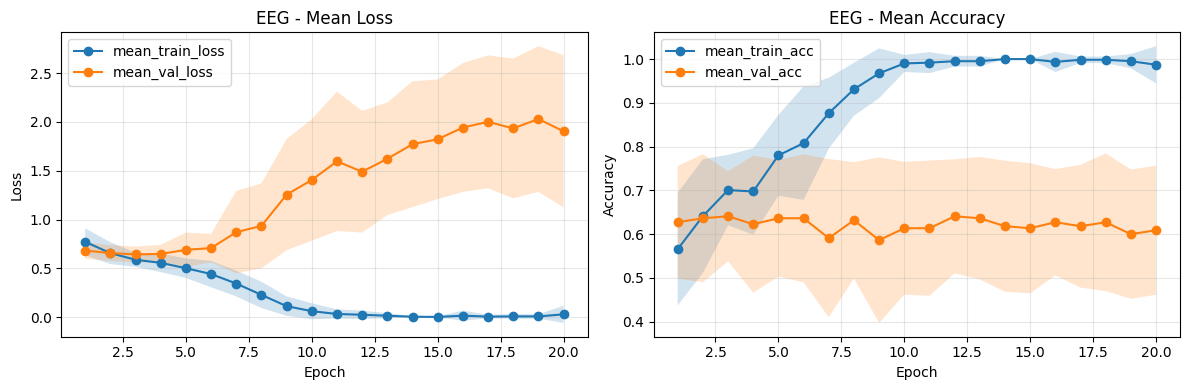


EEG - best validation accuracy


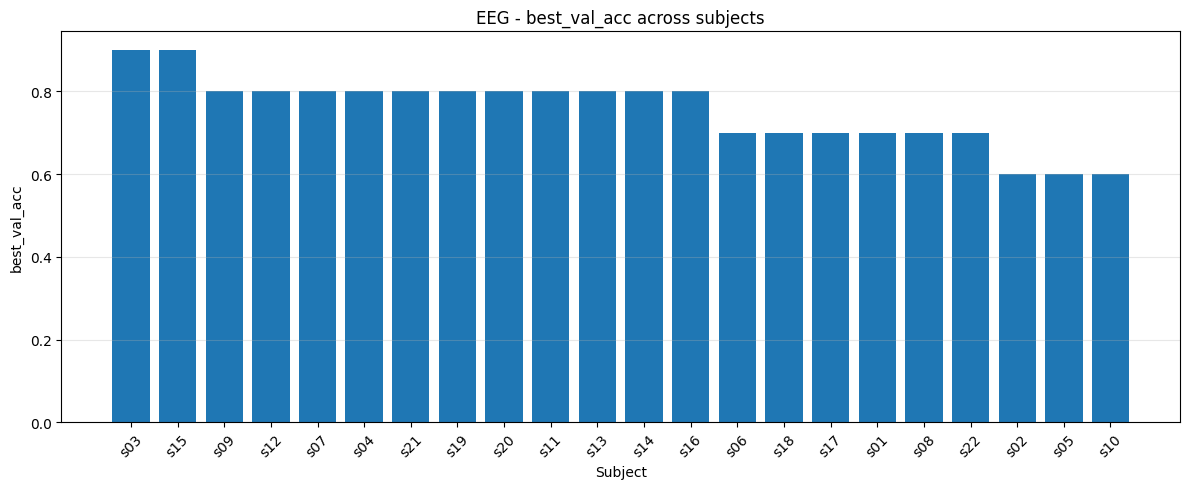


EEG - F1


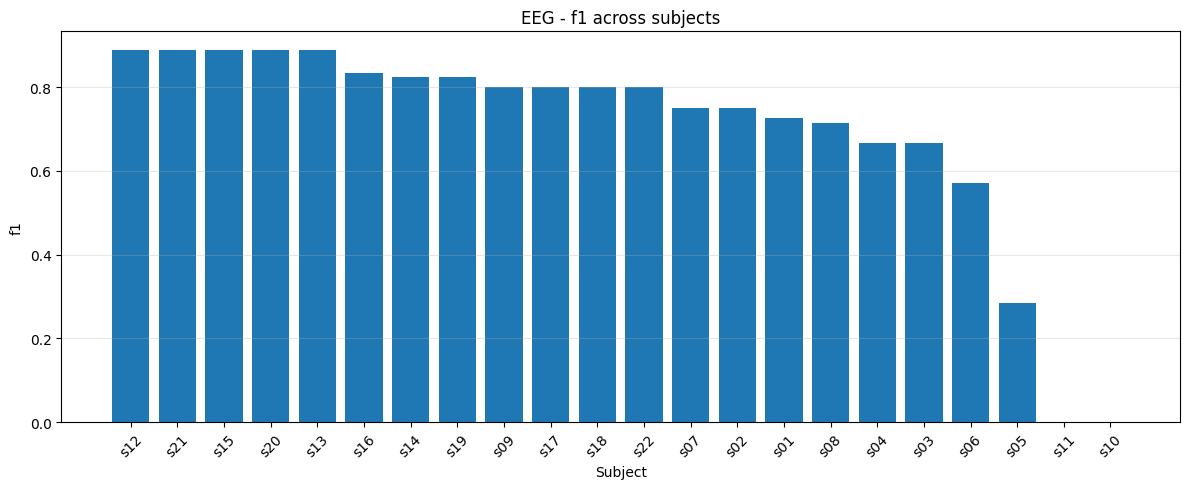


EEG - balanced accuracy


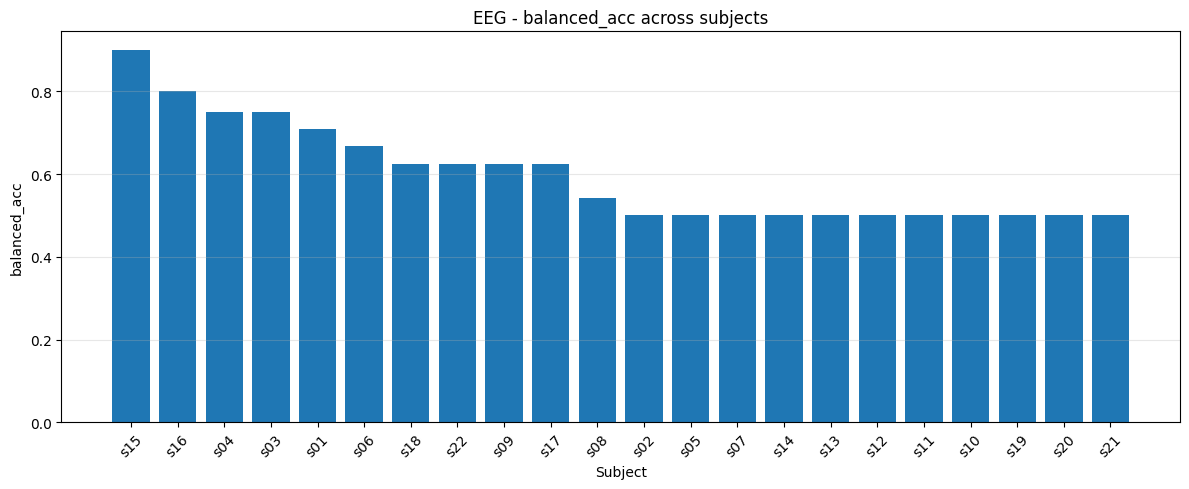


EEG - metric boxplots


/tmp/ipykernel_2656/2276684111.py:779: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=existing)


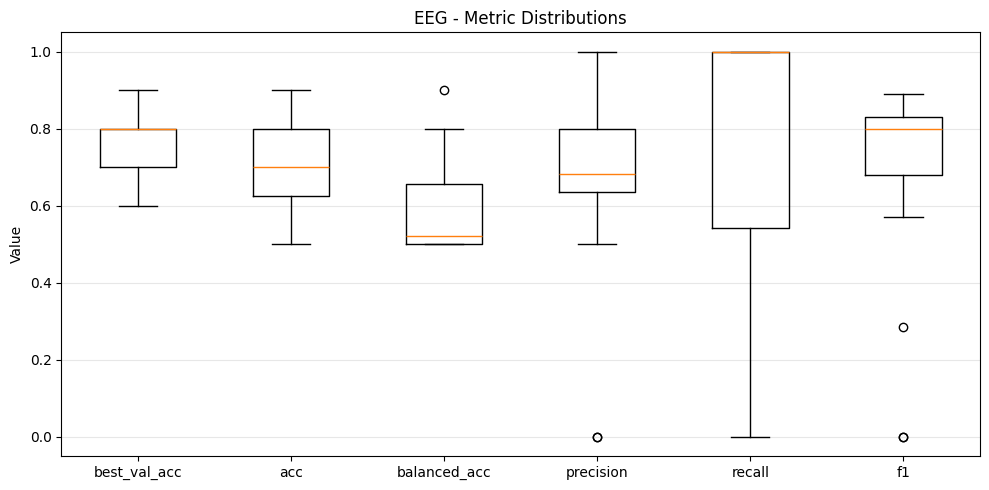


EEG - all confusion matrices


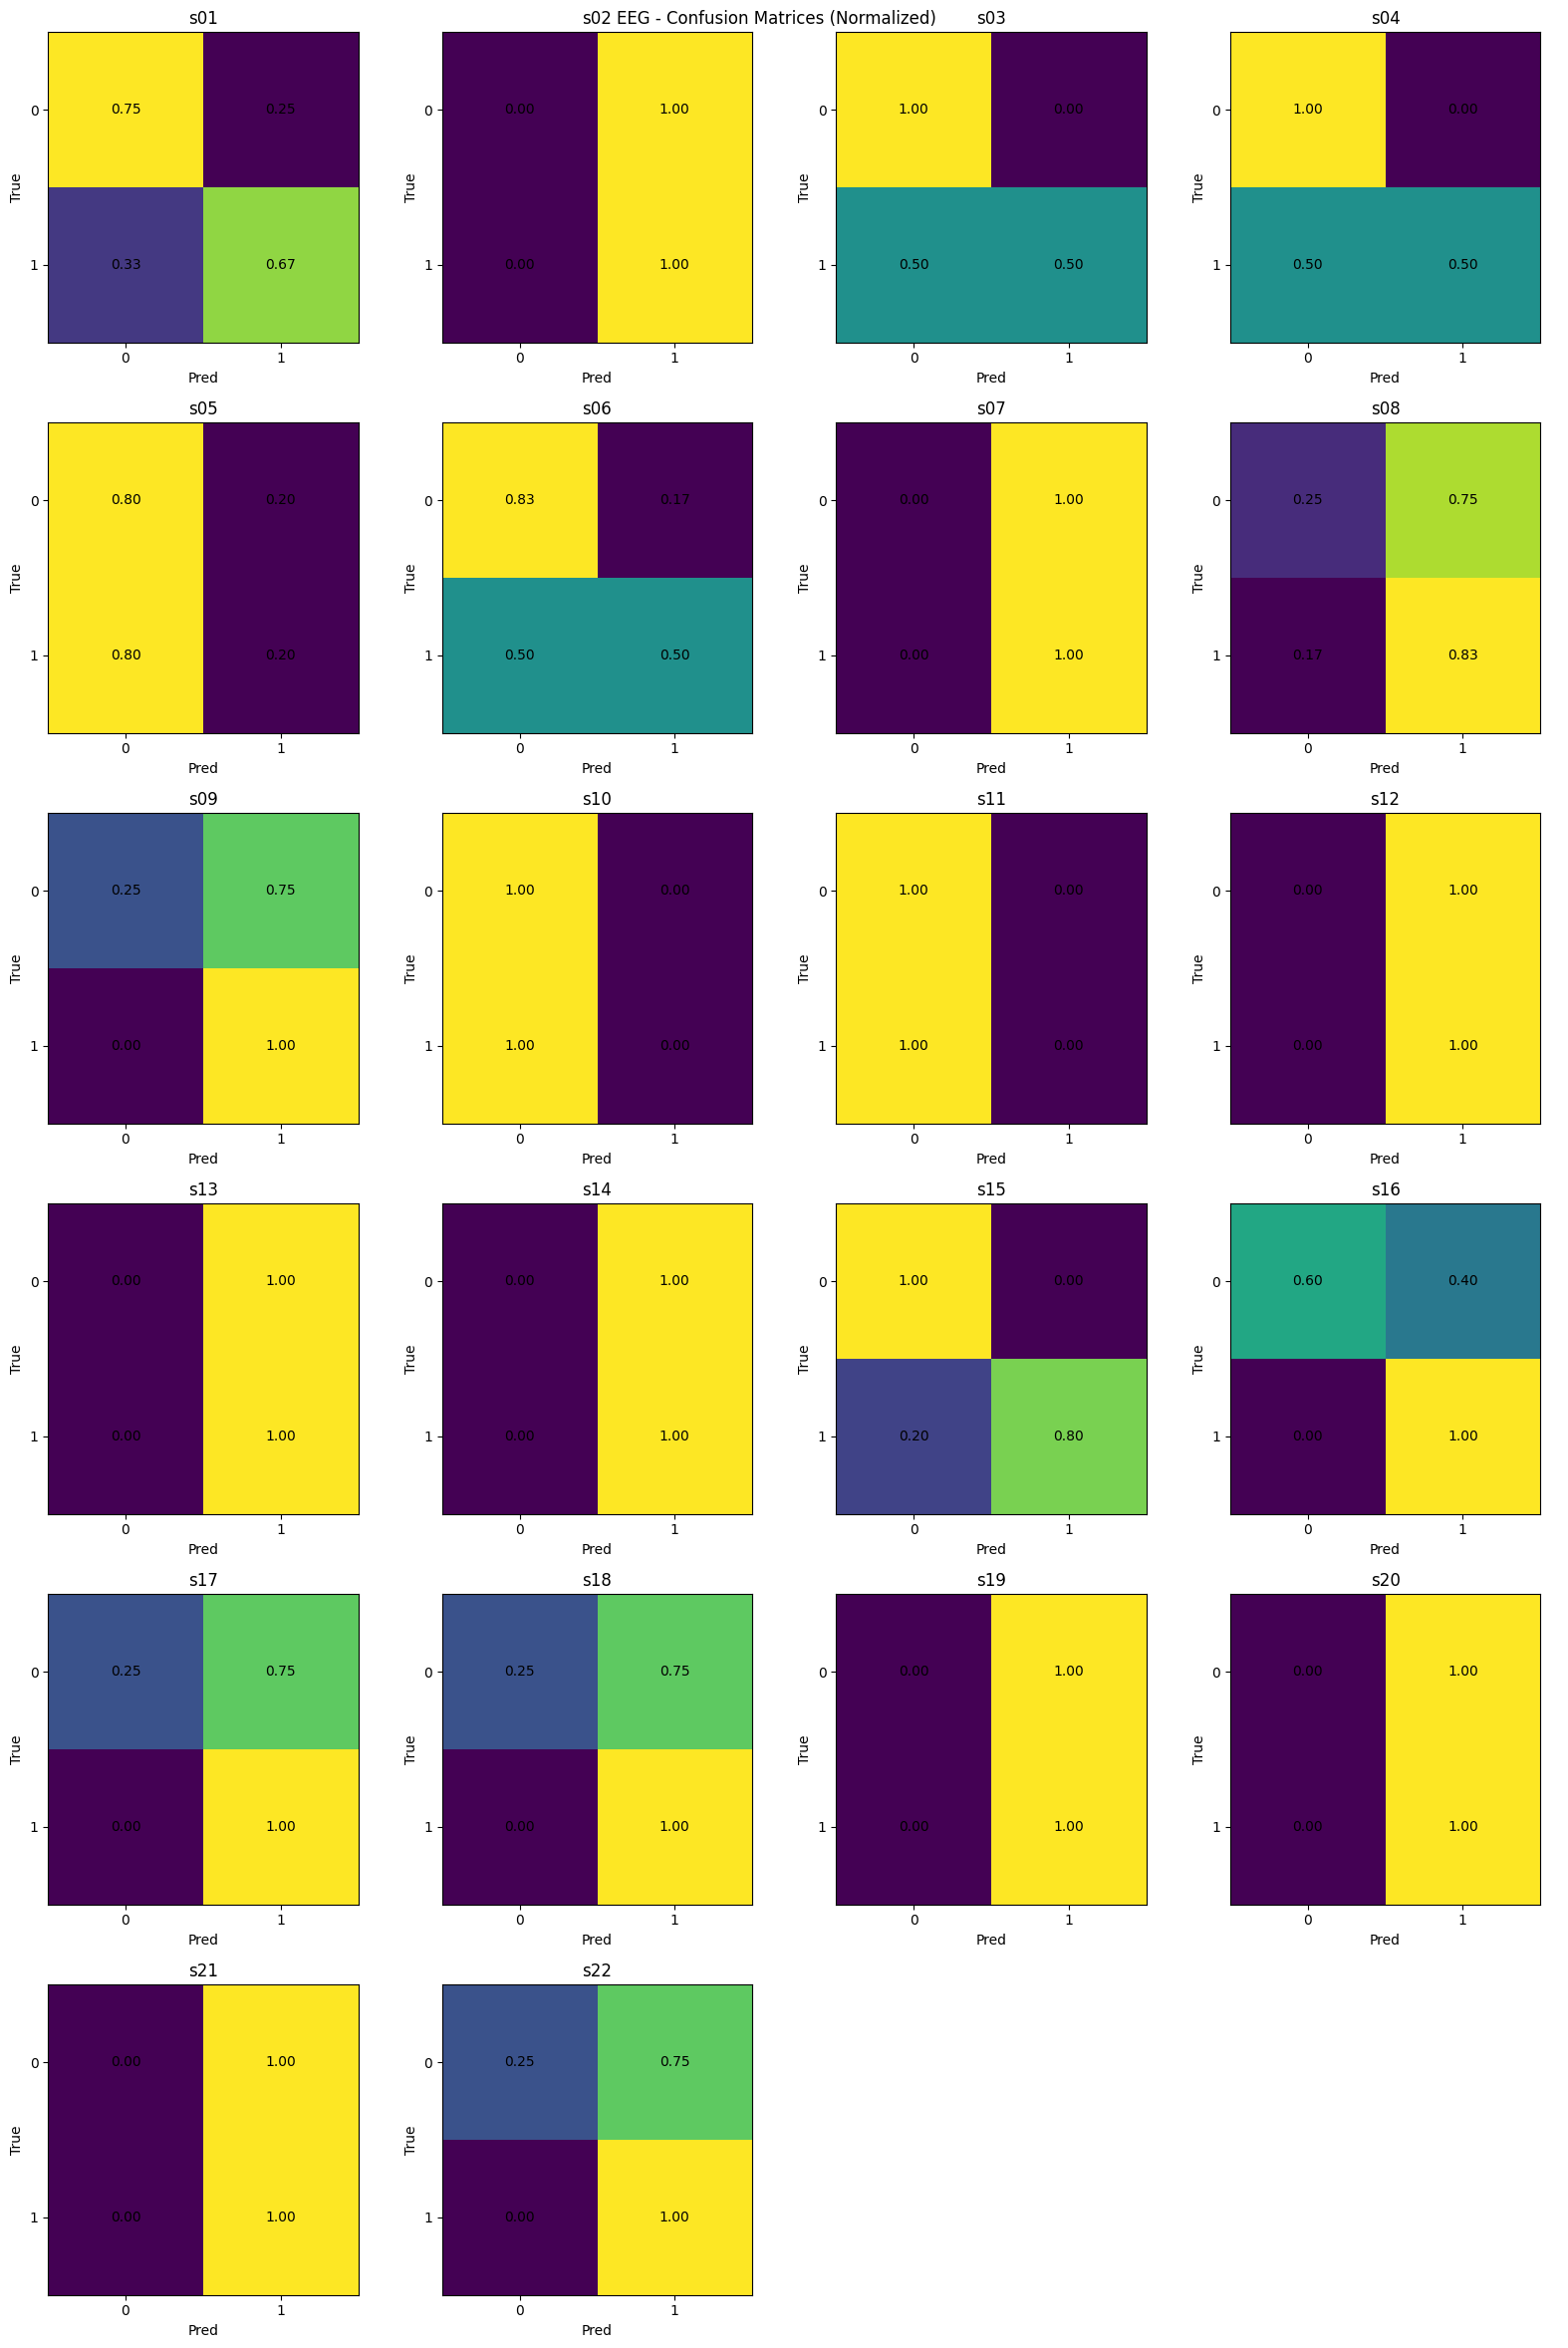


VIDEO - mean curves


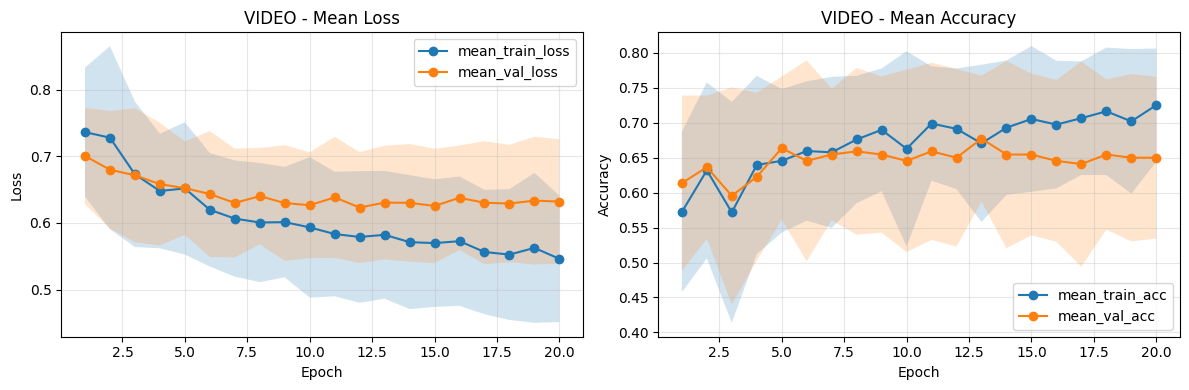


VIDEO - best validation accuracy


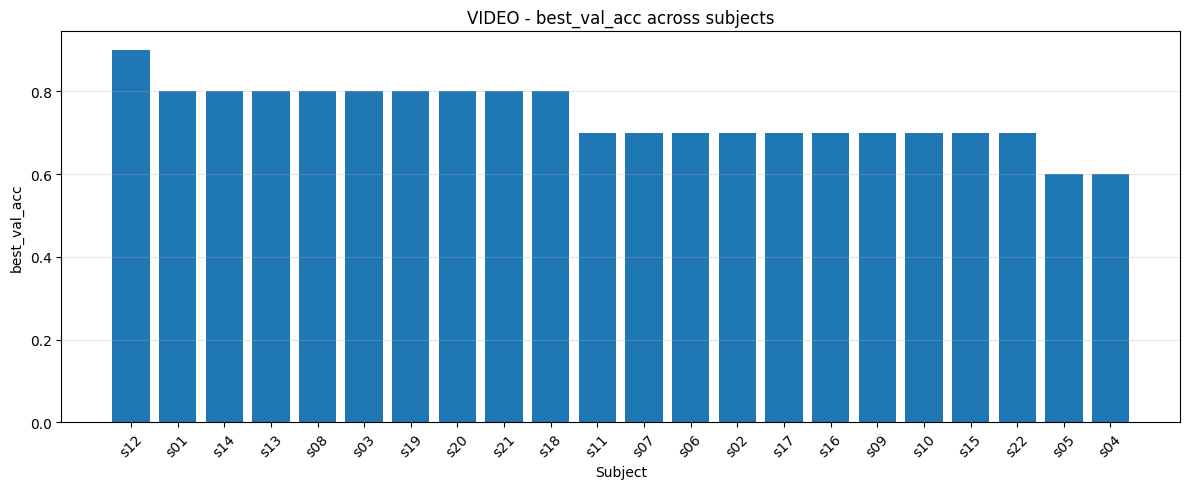


VIDEO - F1


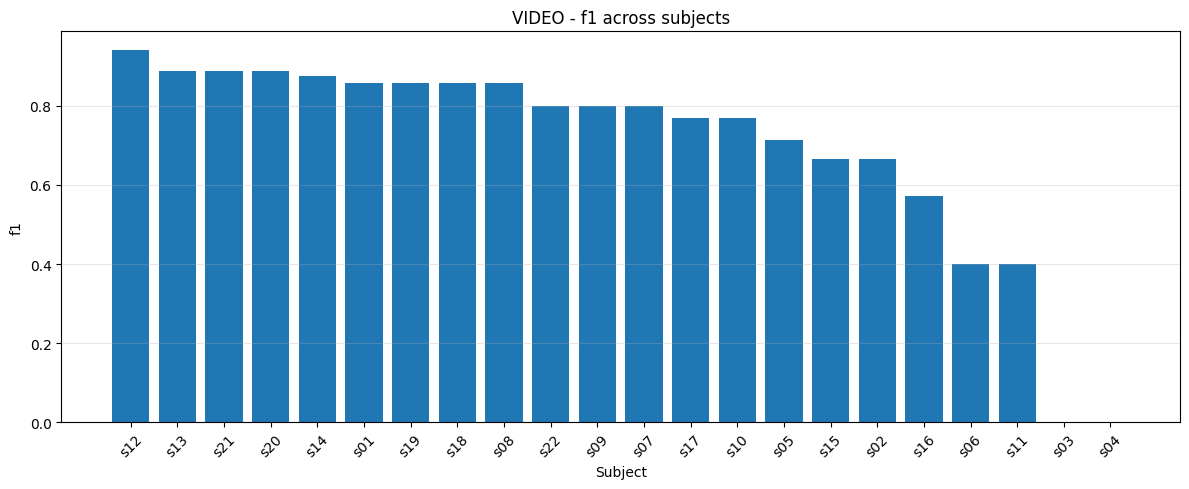


VIDEO - balanced accuracy


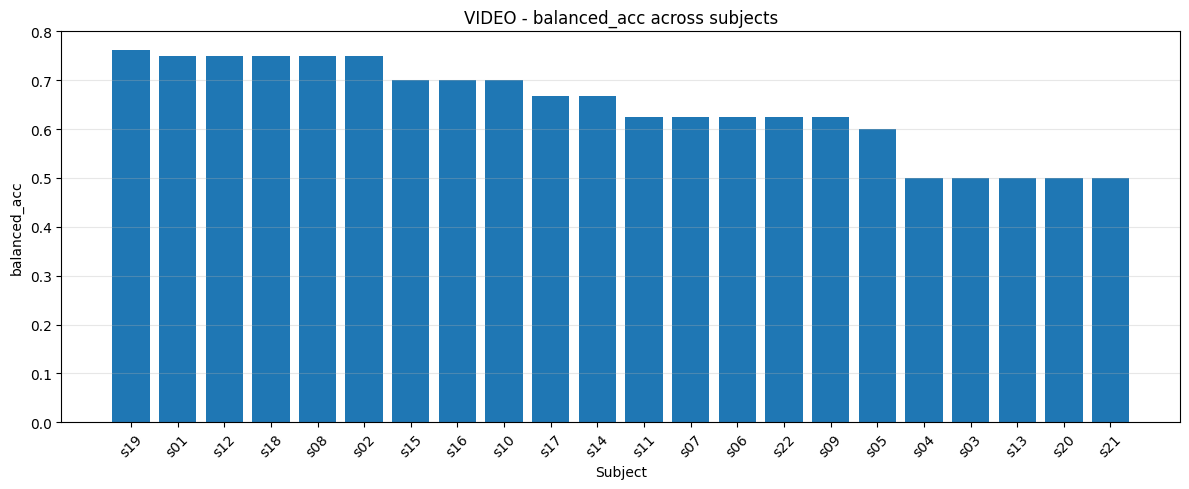


VIDEO - metric boxplots


/tmp/ipykernel_2656/2276684111.py:779: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=existing)


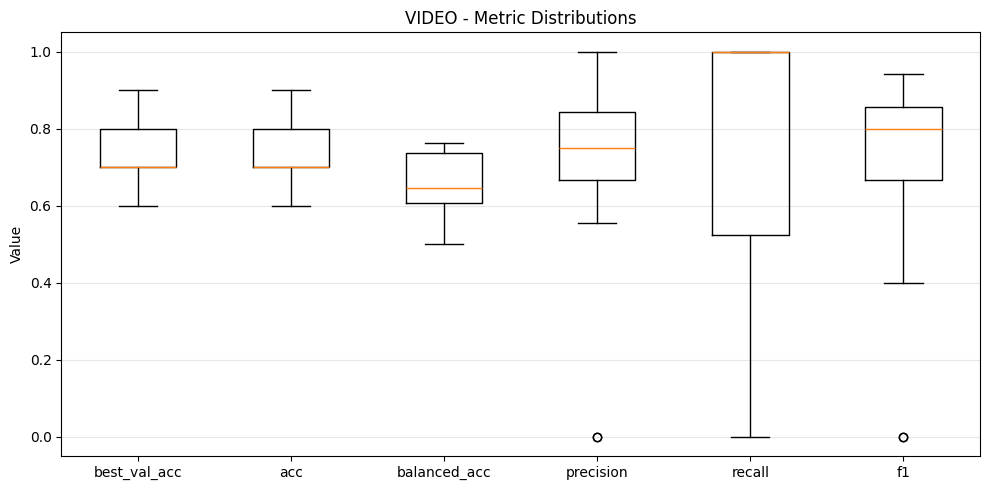


VIDEO - all confusion matrices


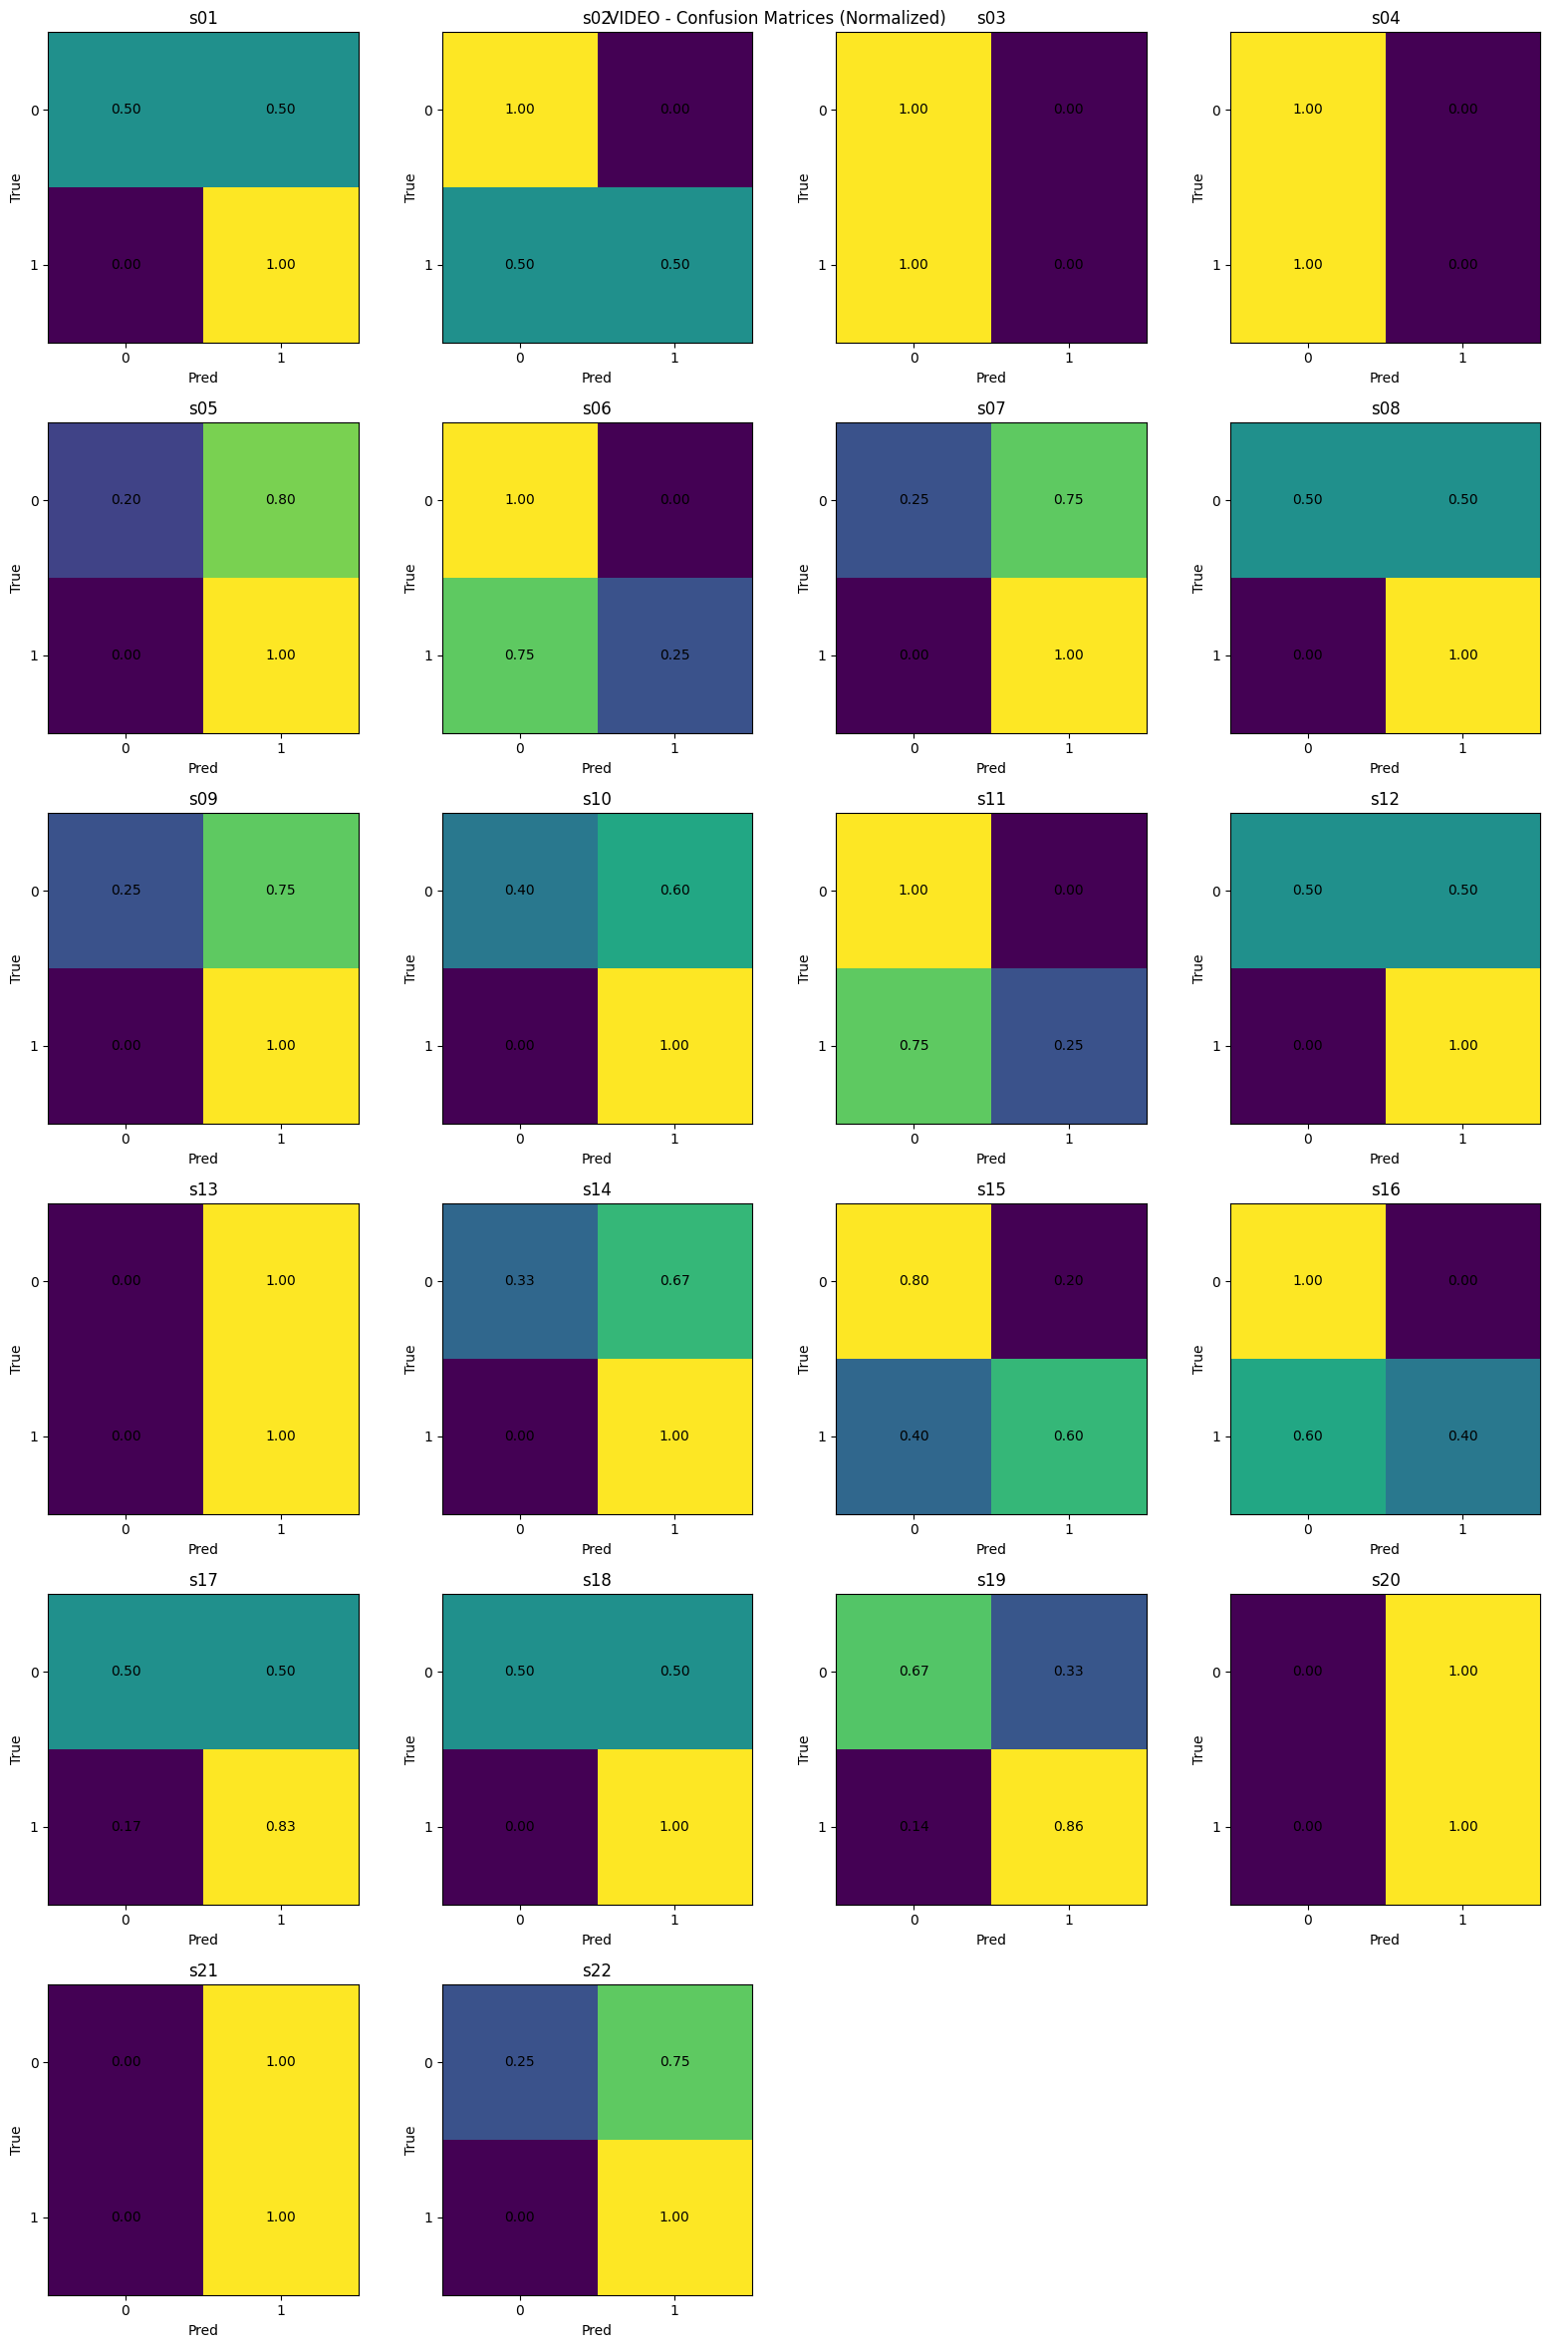


CONCAT_FUSION - mean curves


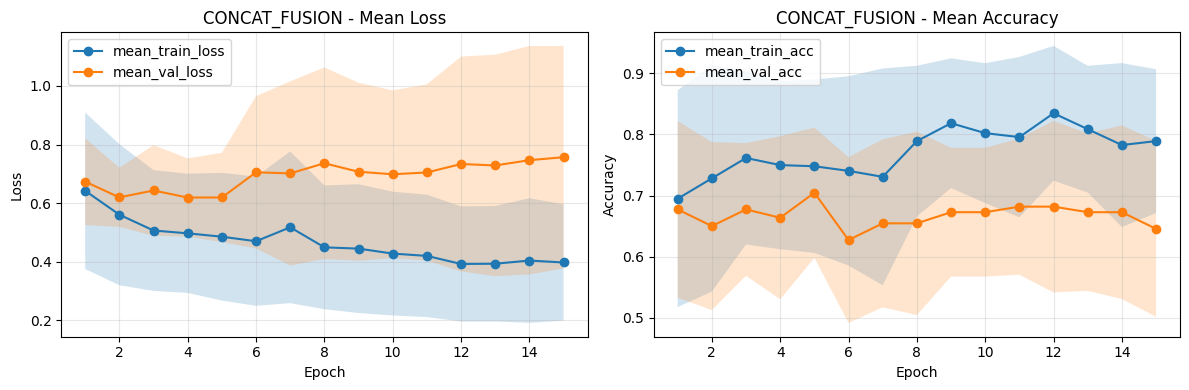


CONCAT_FUSION - best validation accuracy


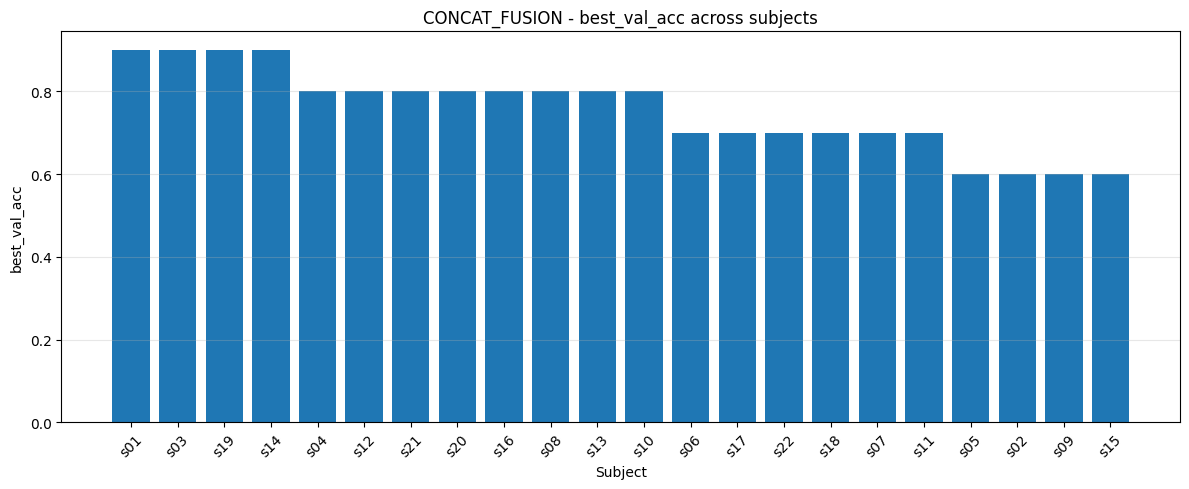


CONCAT_FUSION - F1


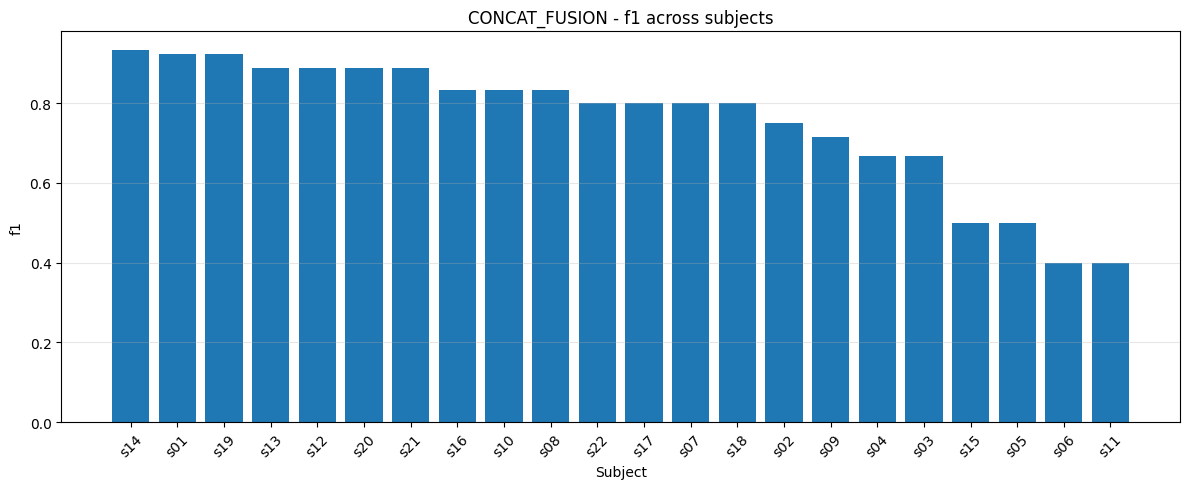


CONCAT_FUSION - balanced accuracy


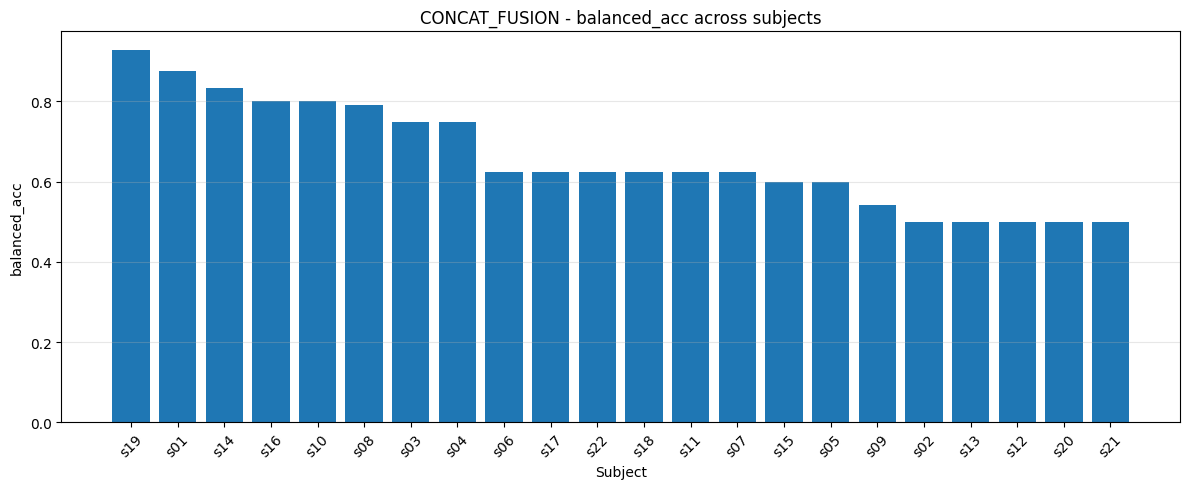


CONCAT_FUSION - metric boxplots


/tmp/ipykernel_2656/2276684111.py:779: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=existing)


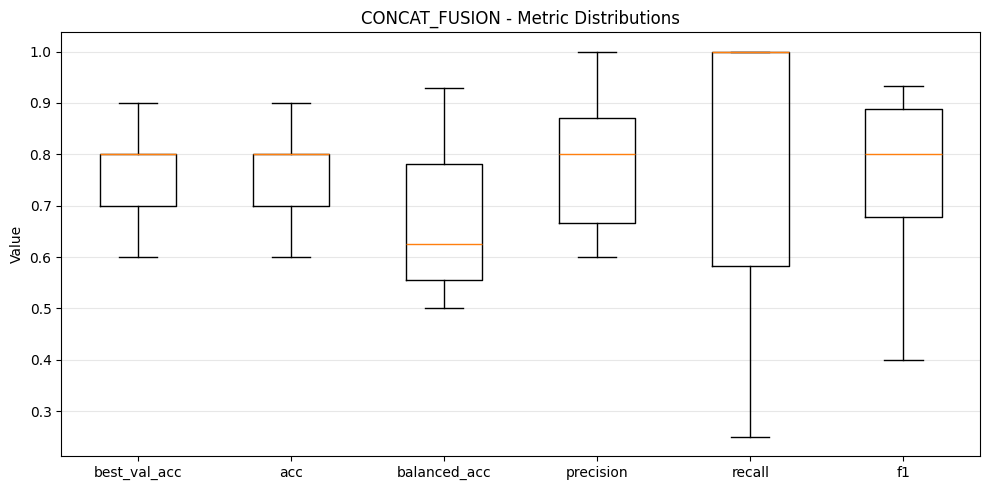


CONCAT_FUSION - all confusion matrices


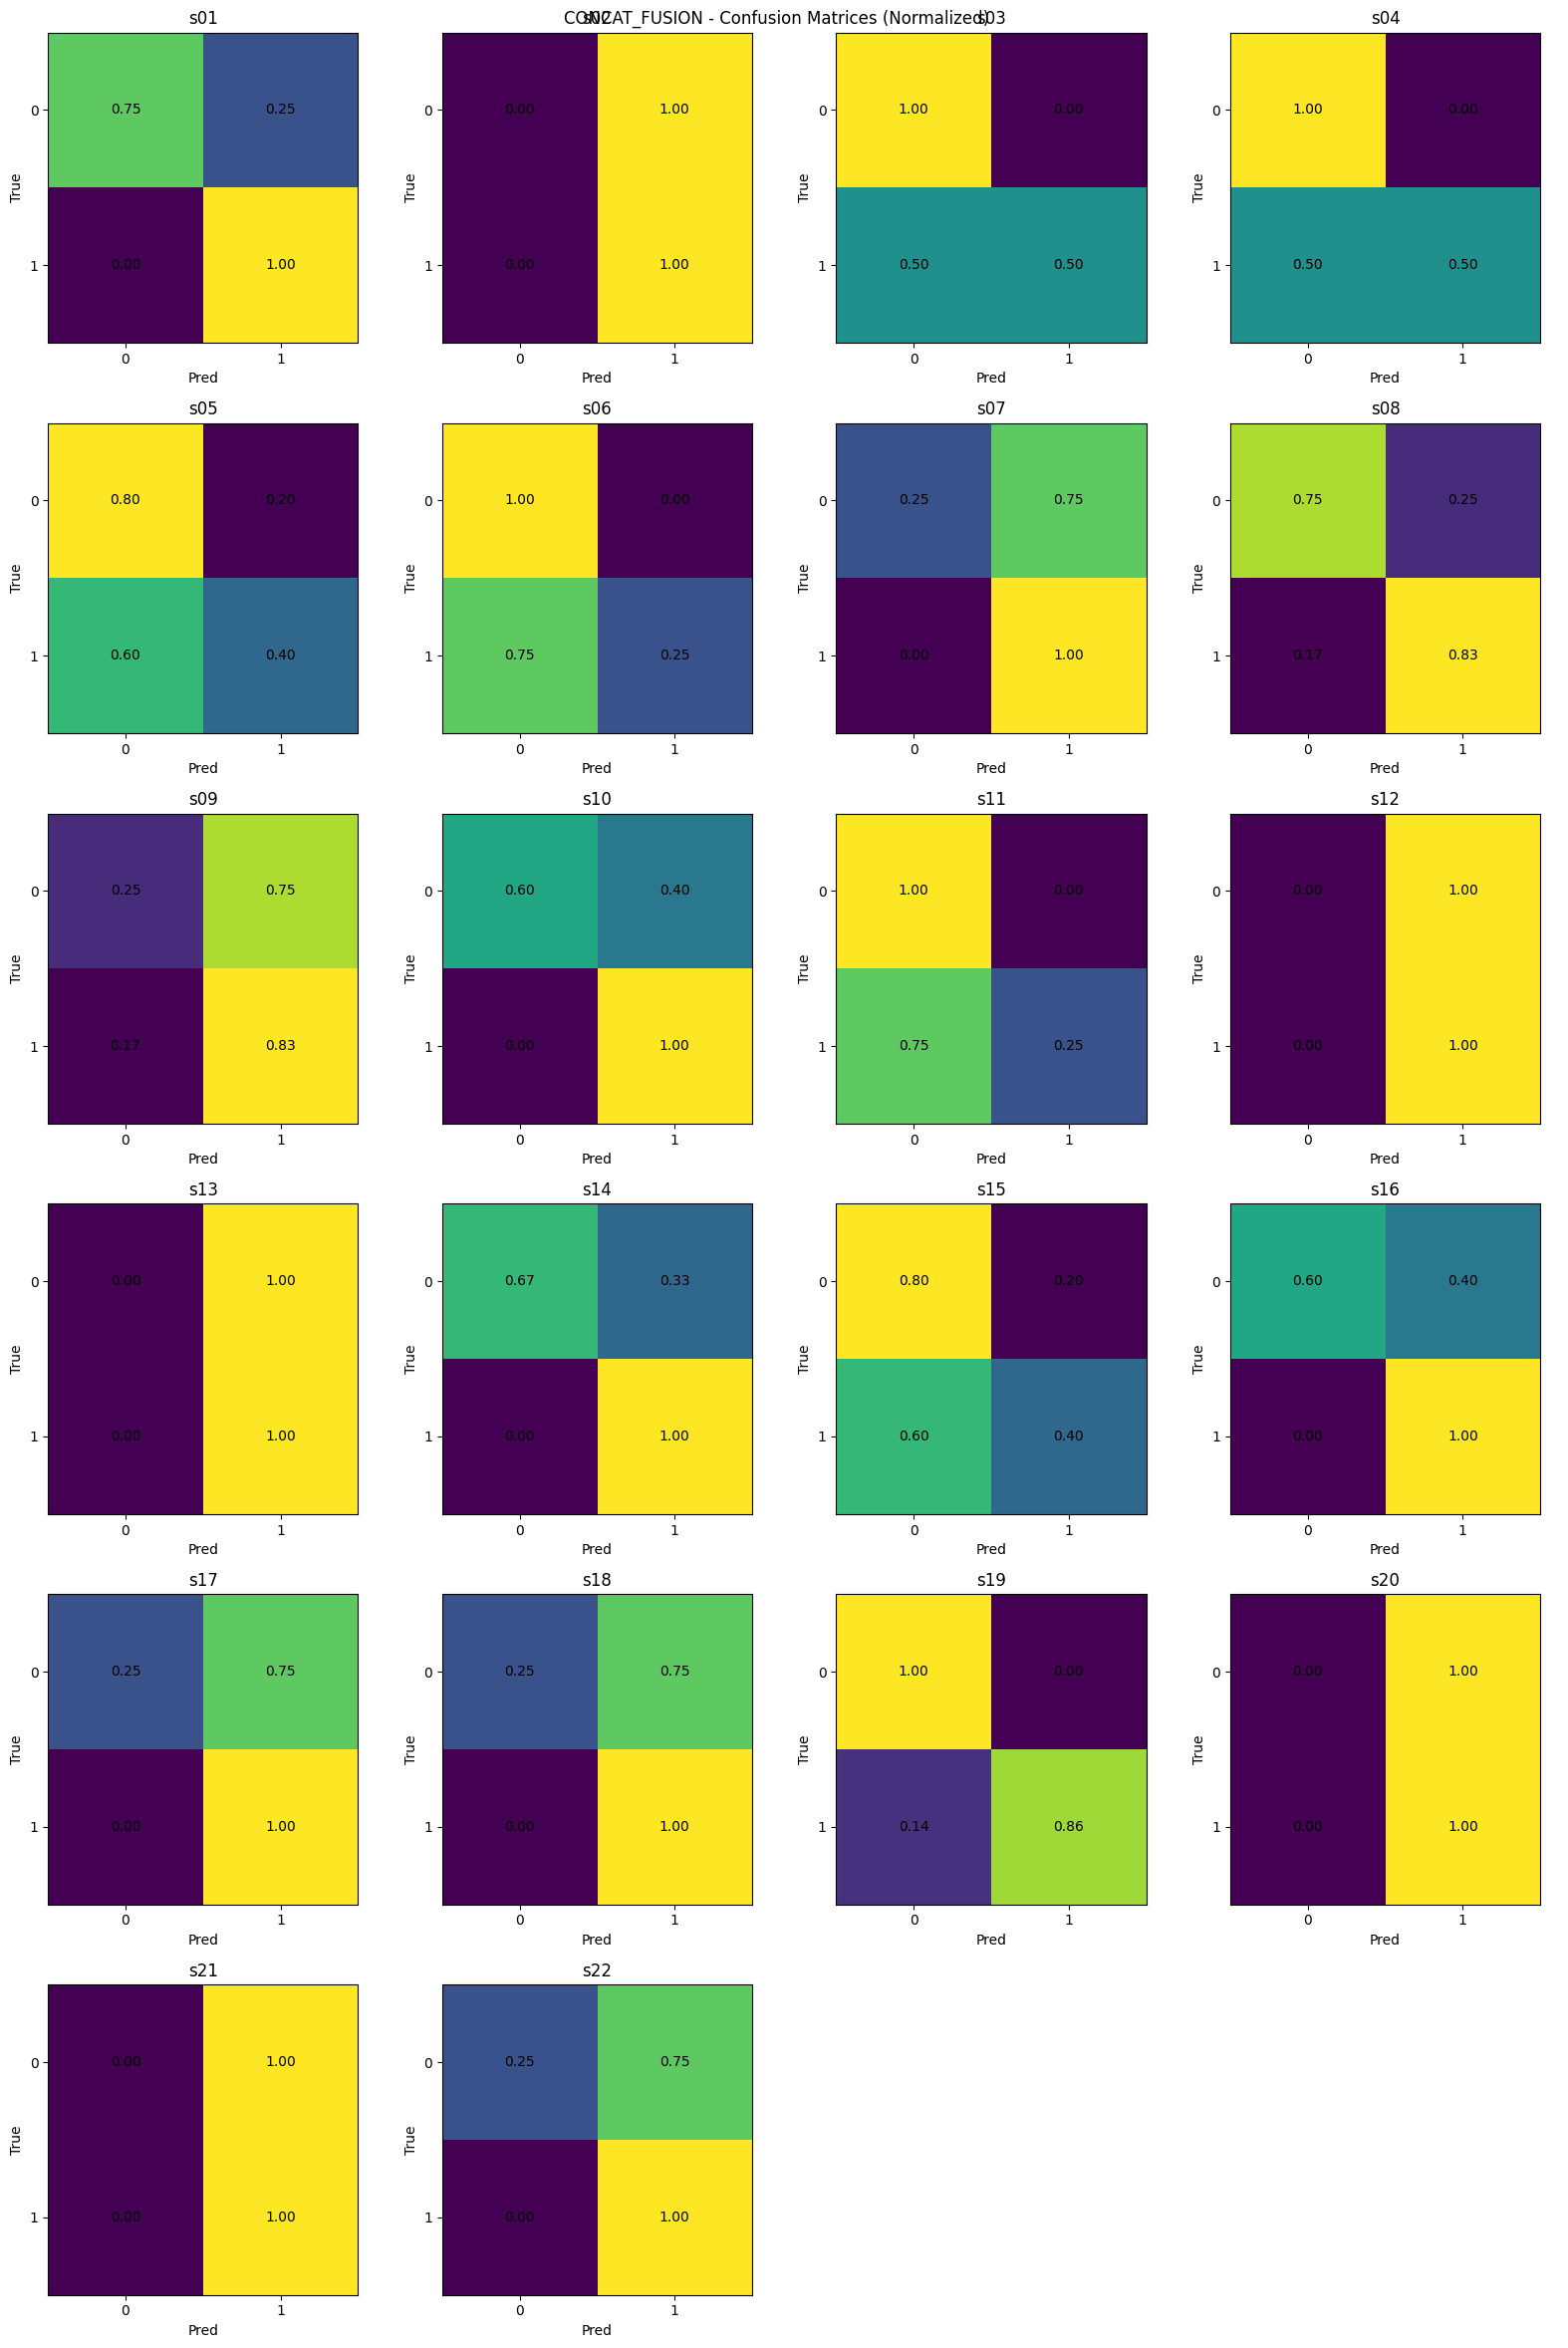


DECISION_FUSION - mean curves
No usable histories available.

DECISION_FUSION - best validation accuracy


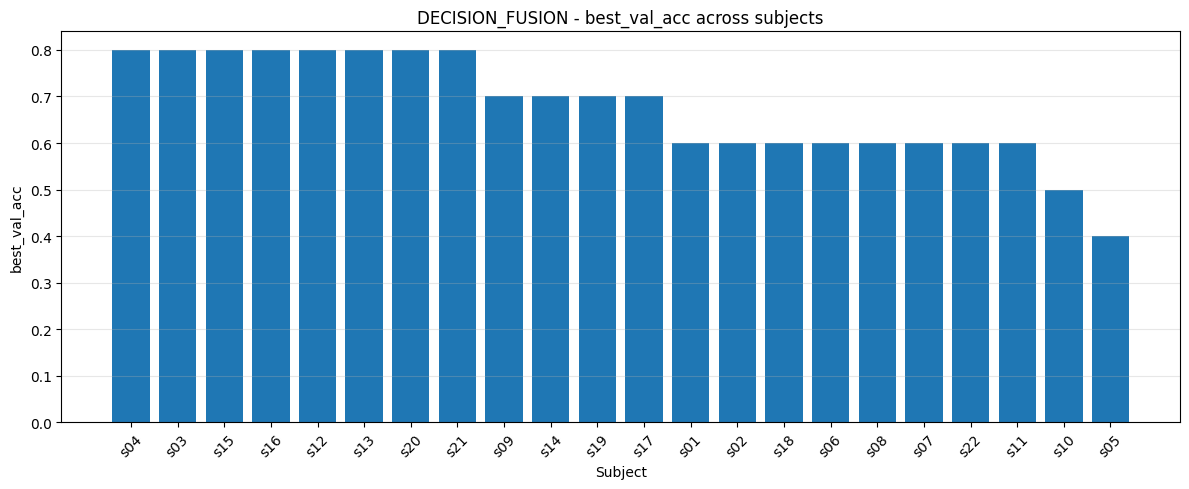


DECISION_FUSION - F1


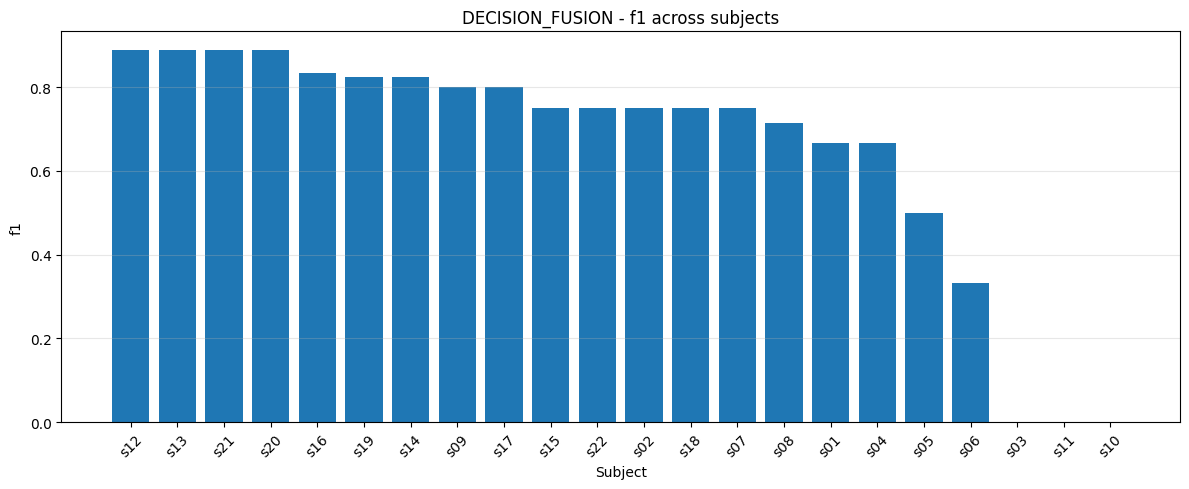


DECISION_FUSION - balanced accuracy


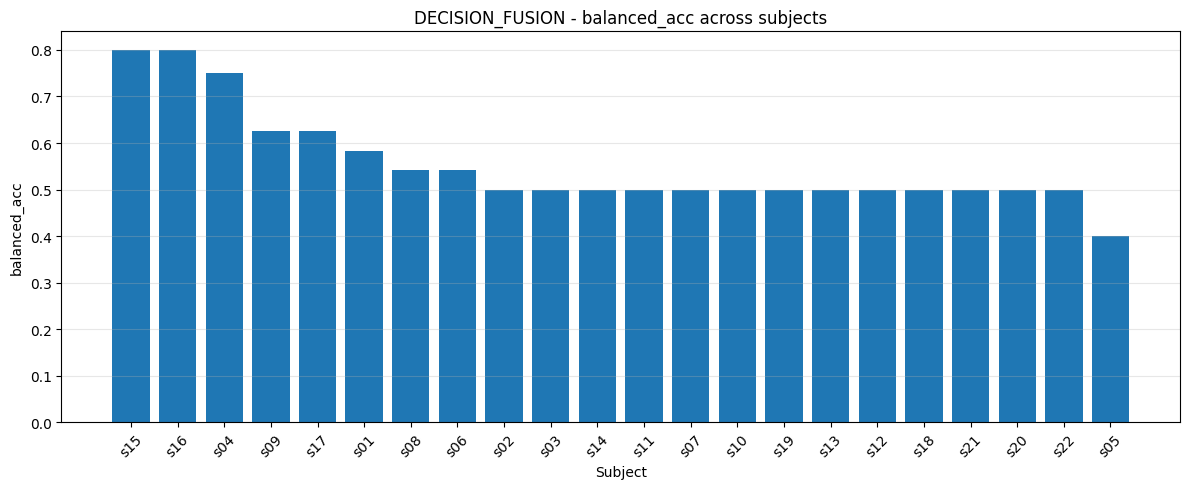


DECISION_FUSION - metric boxplots


/tmp/ipykernel_2656/2276684111.py:779: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=existing)


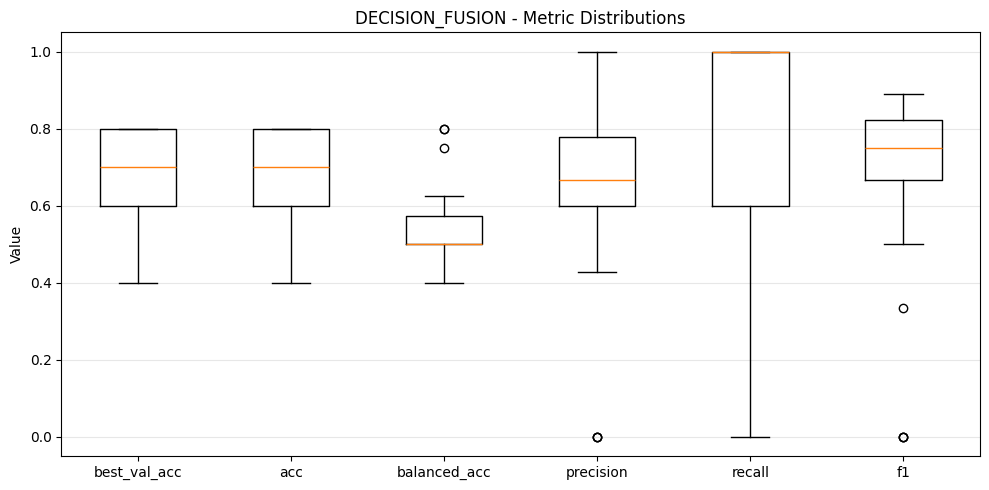


DECISION_FUSION - all confusion matrices


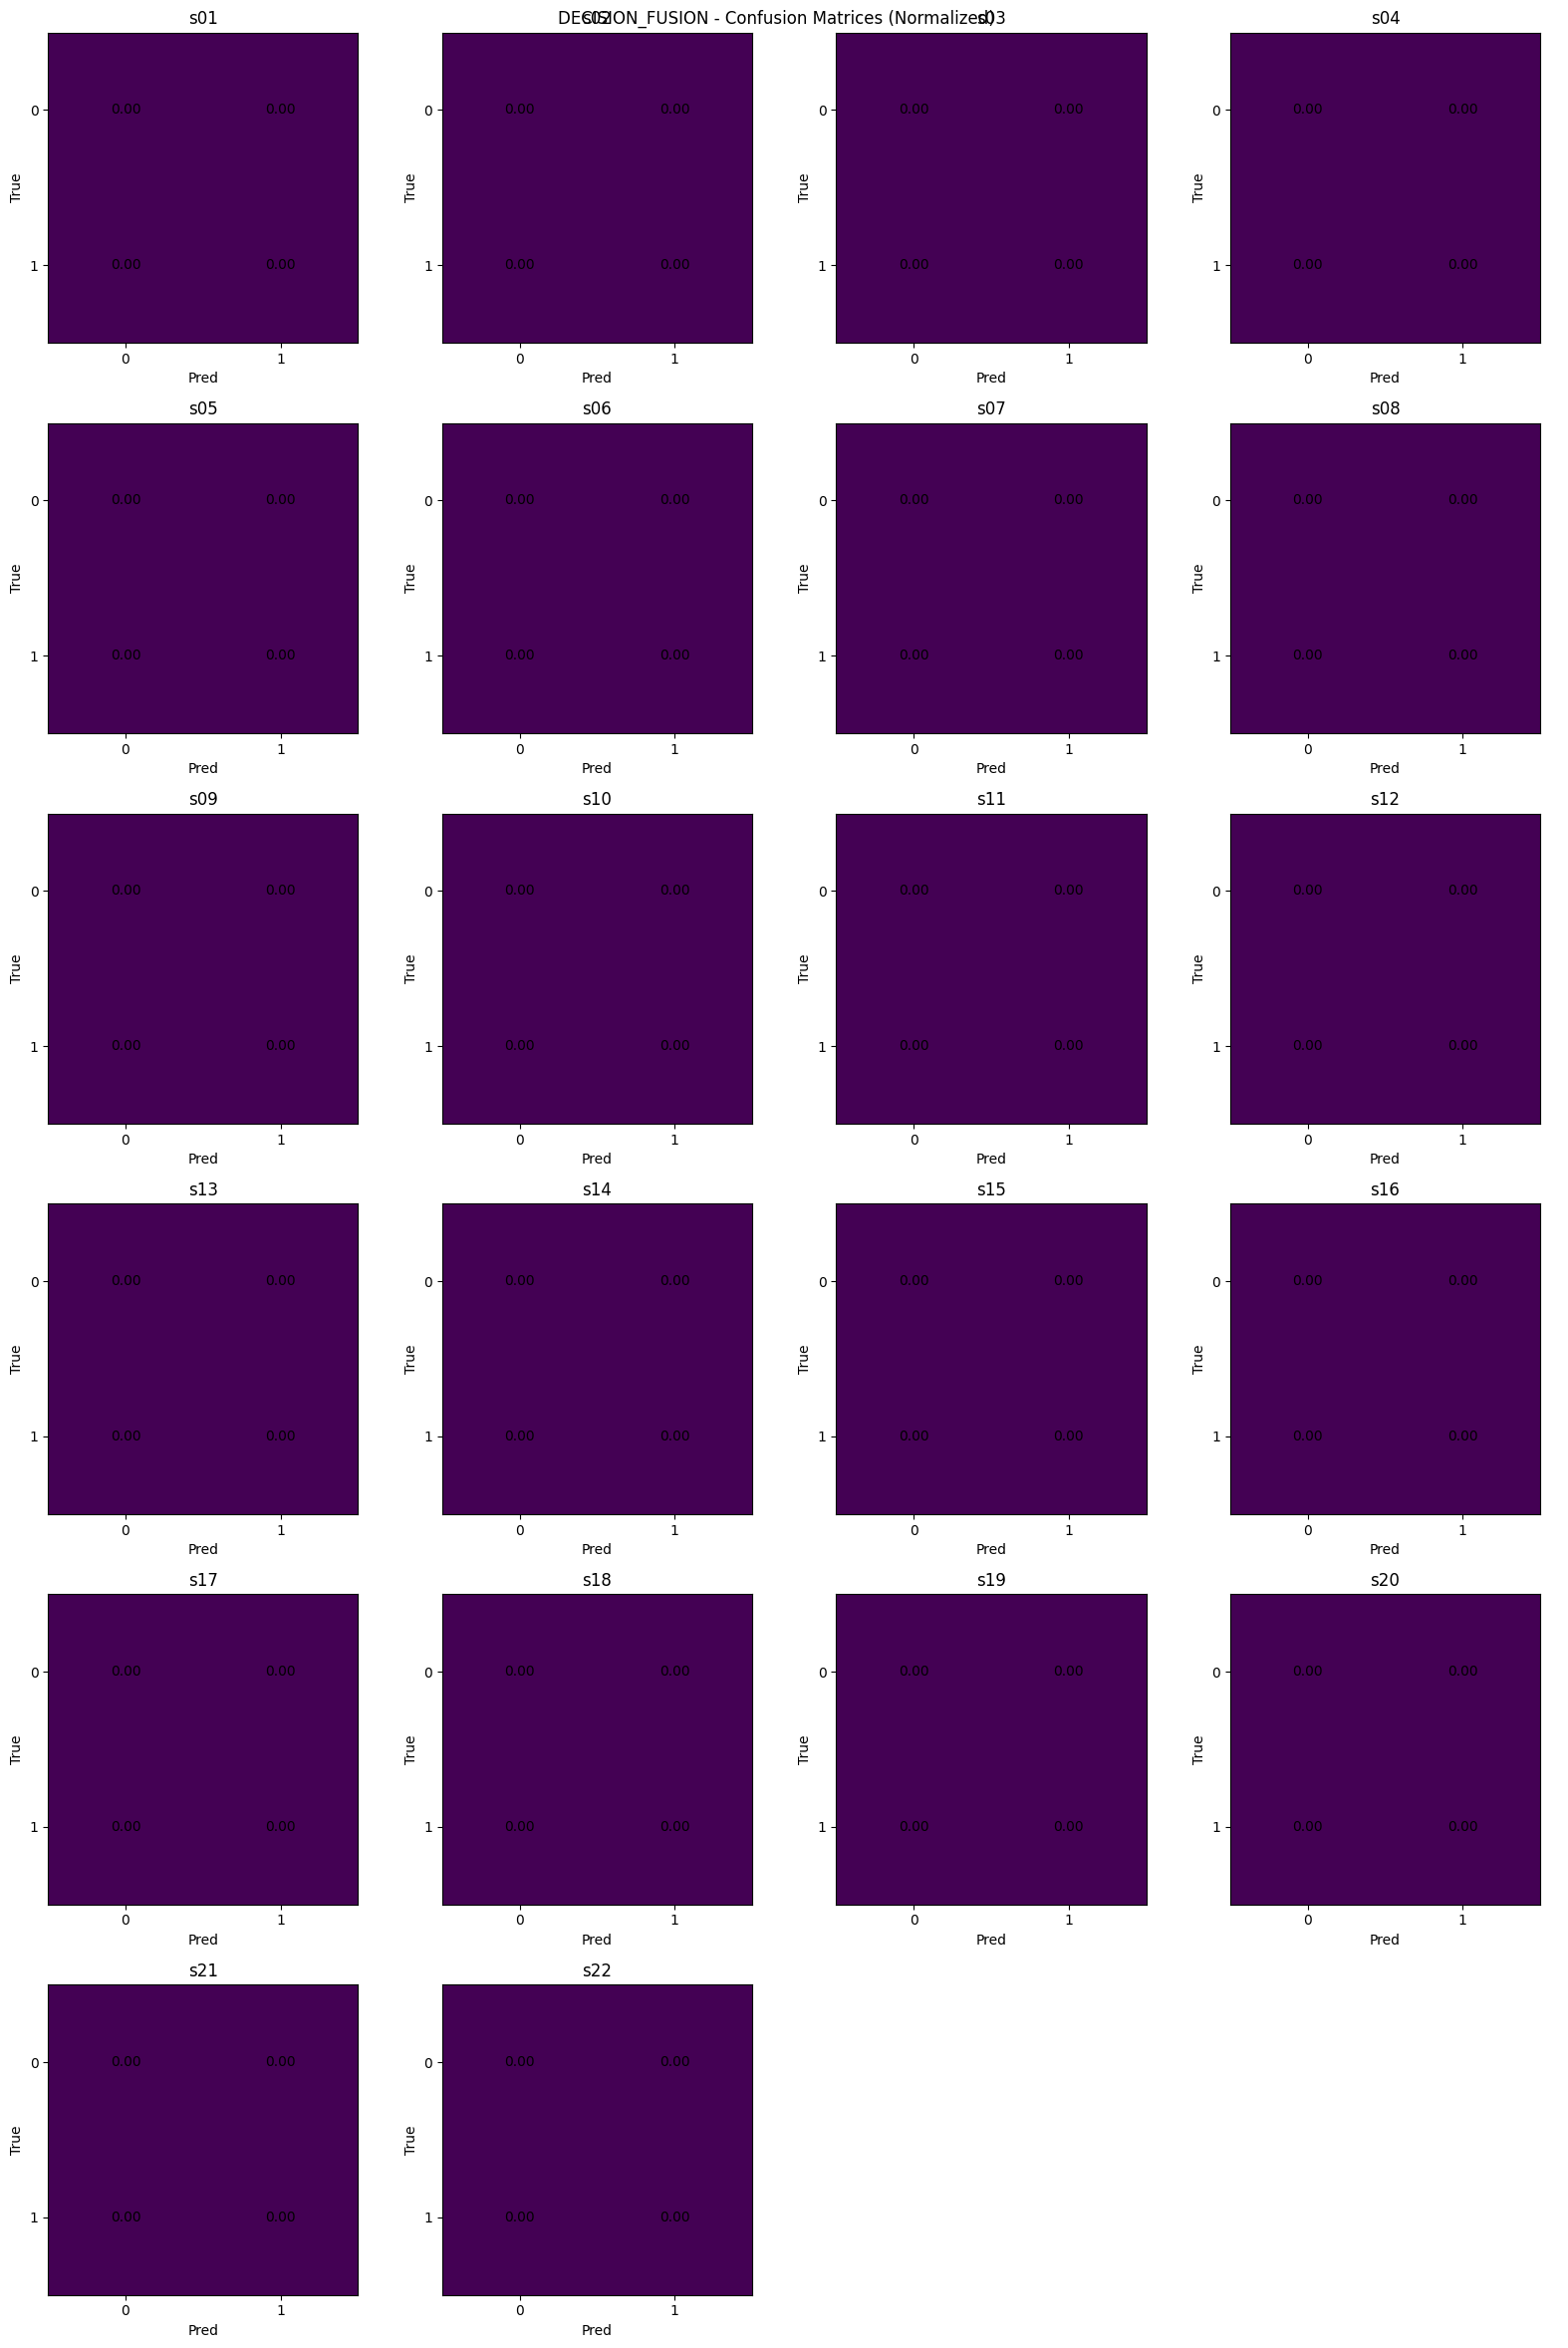


FUSION - mean curves


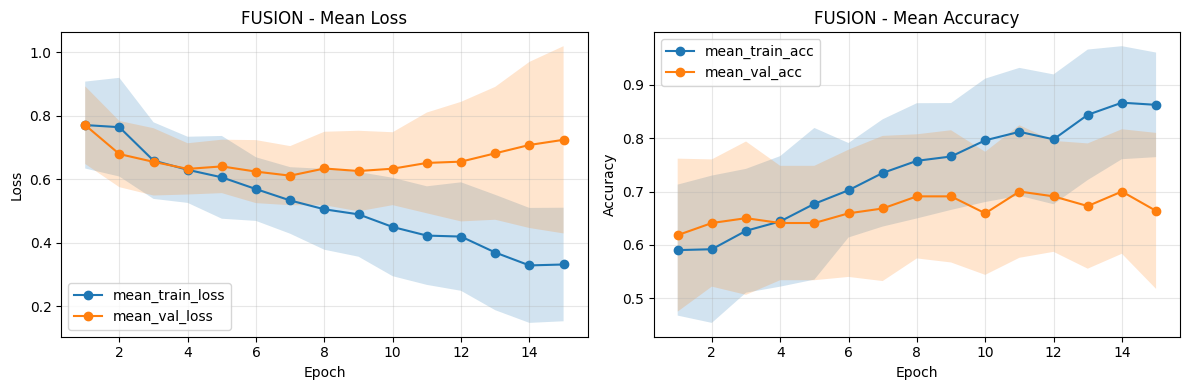


FUSION - best validation accuracy


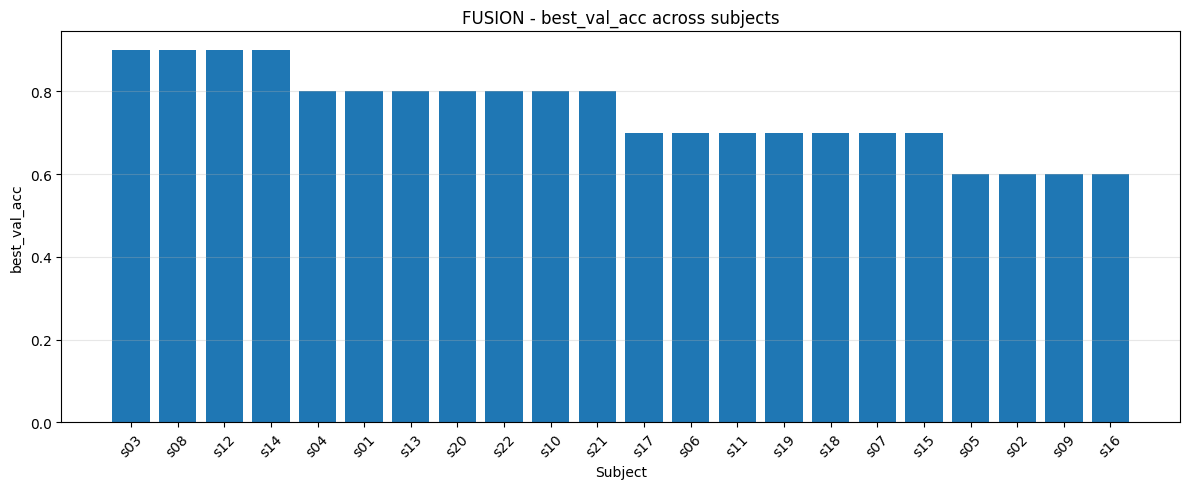


FUSION - F1


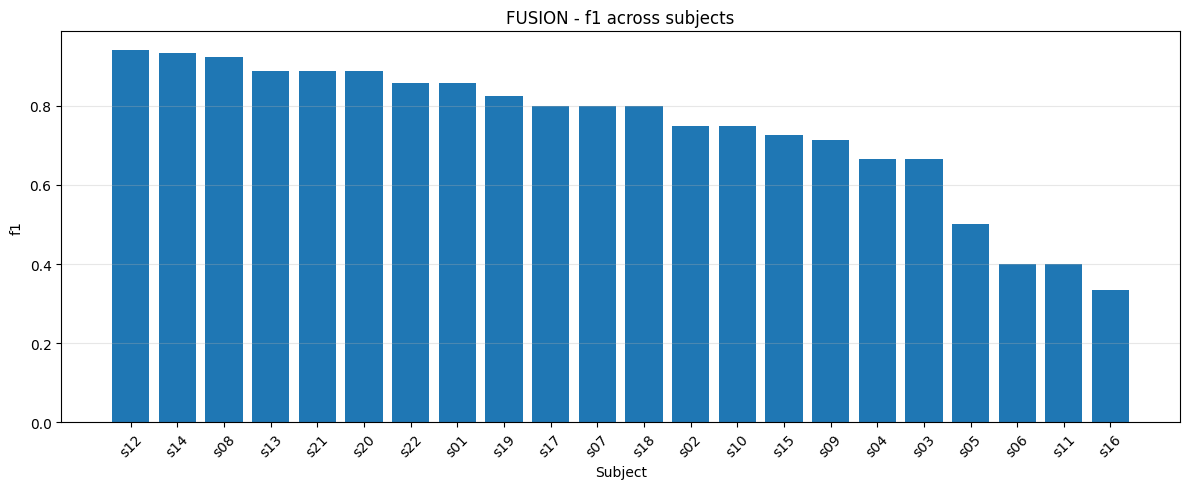


FUSION - balanced accuracy


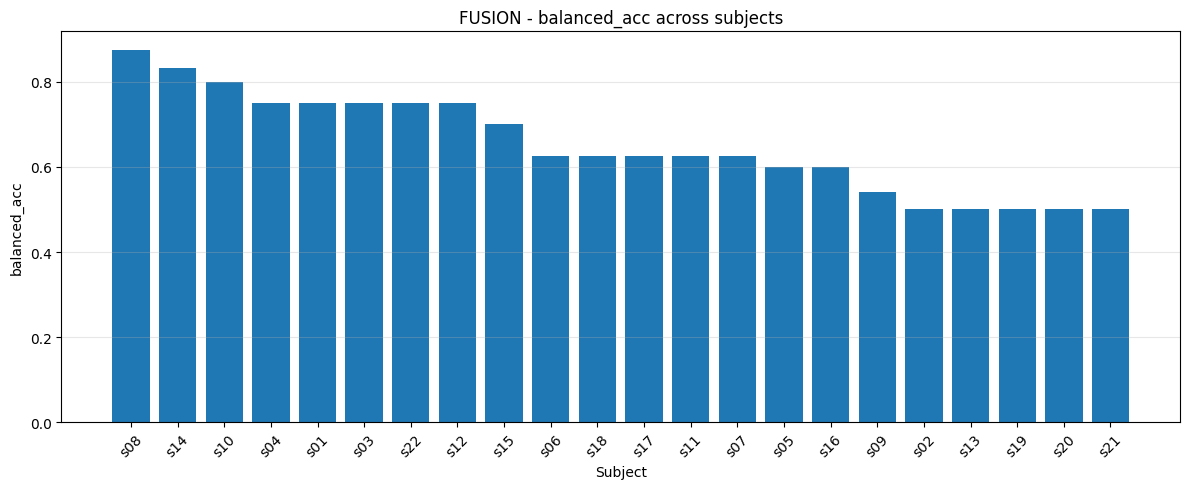


FUSION - metric boxplots


/tmp/ipykernel_2656/2276684111.py:779: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=existing)


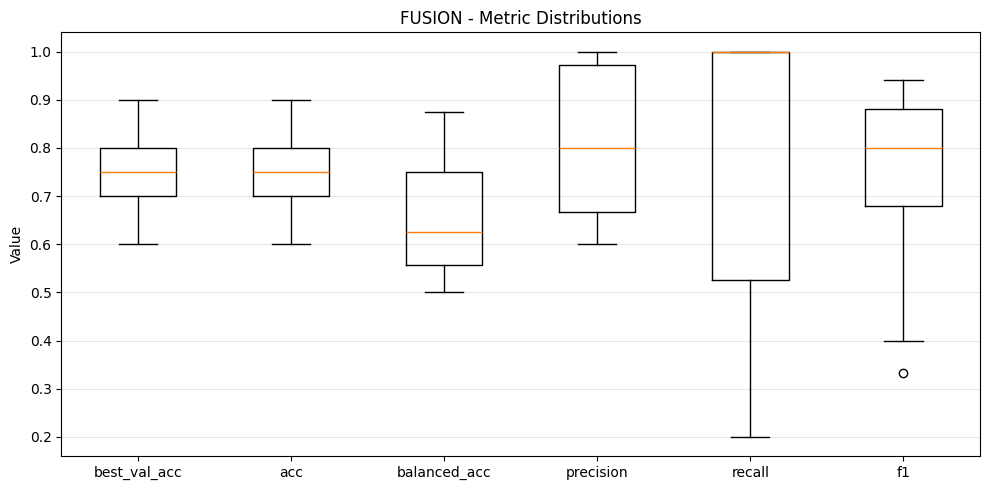


FUSION - all confusion matrices


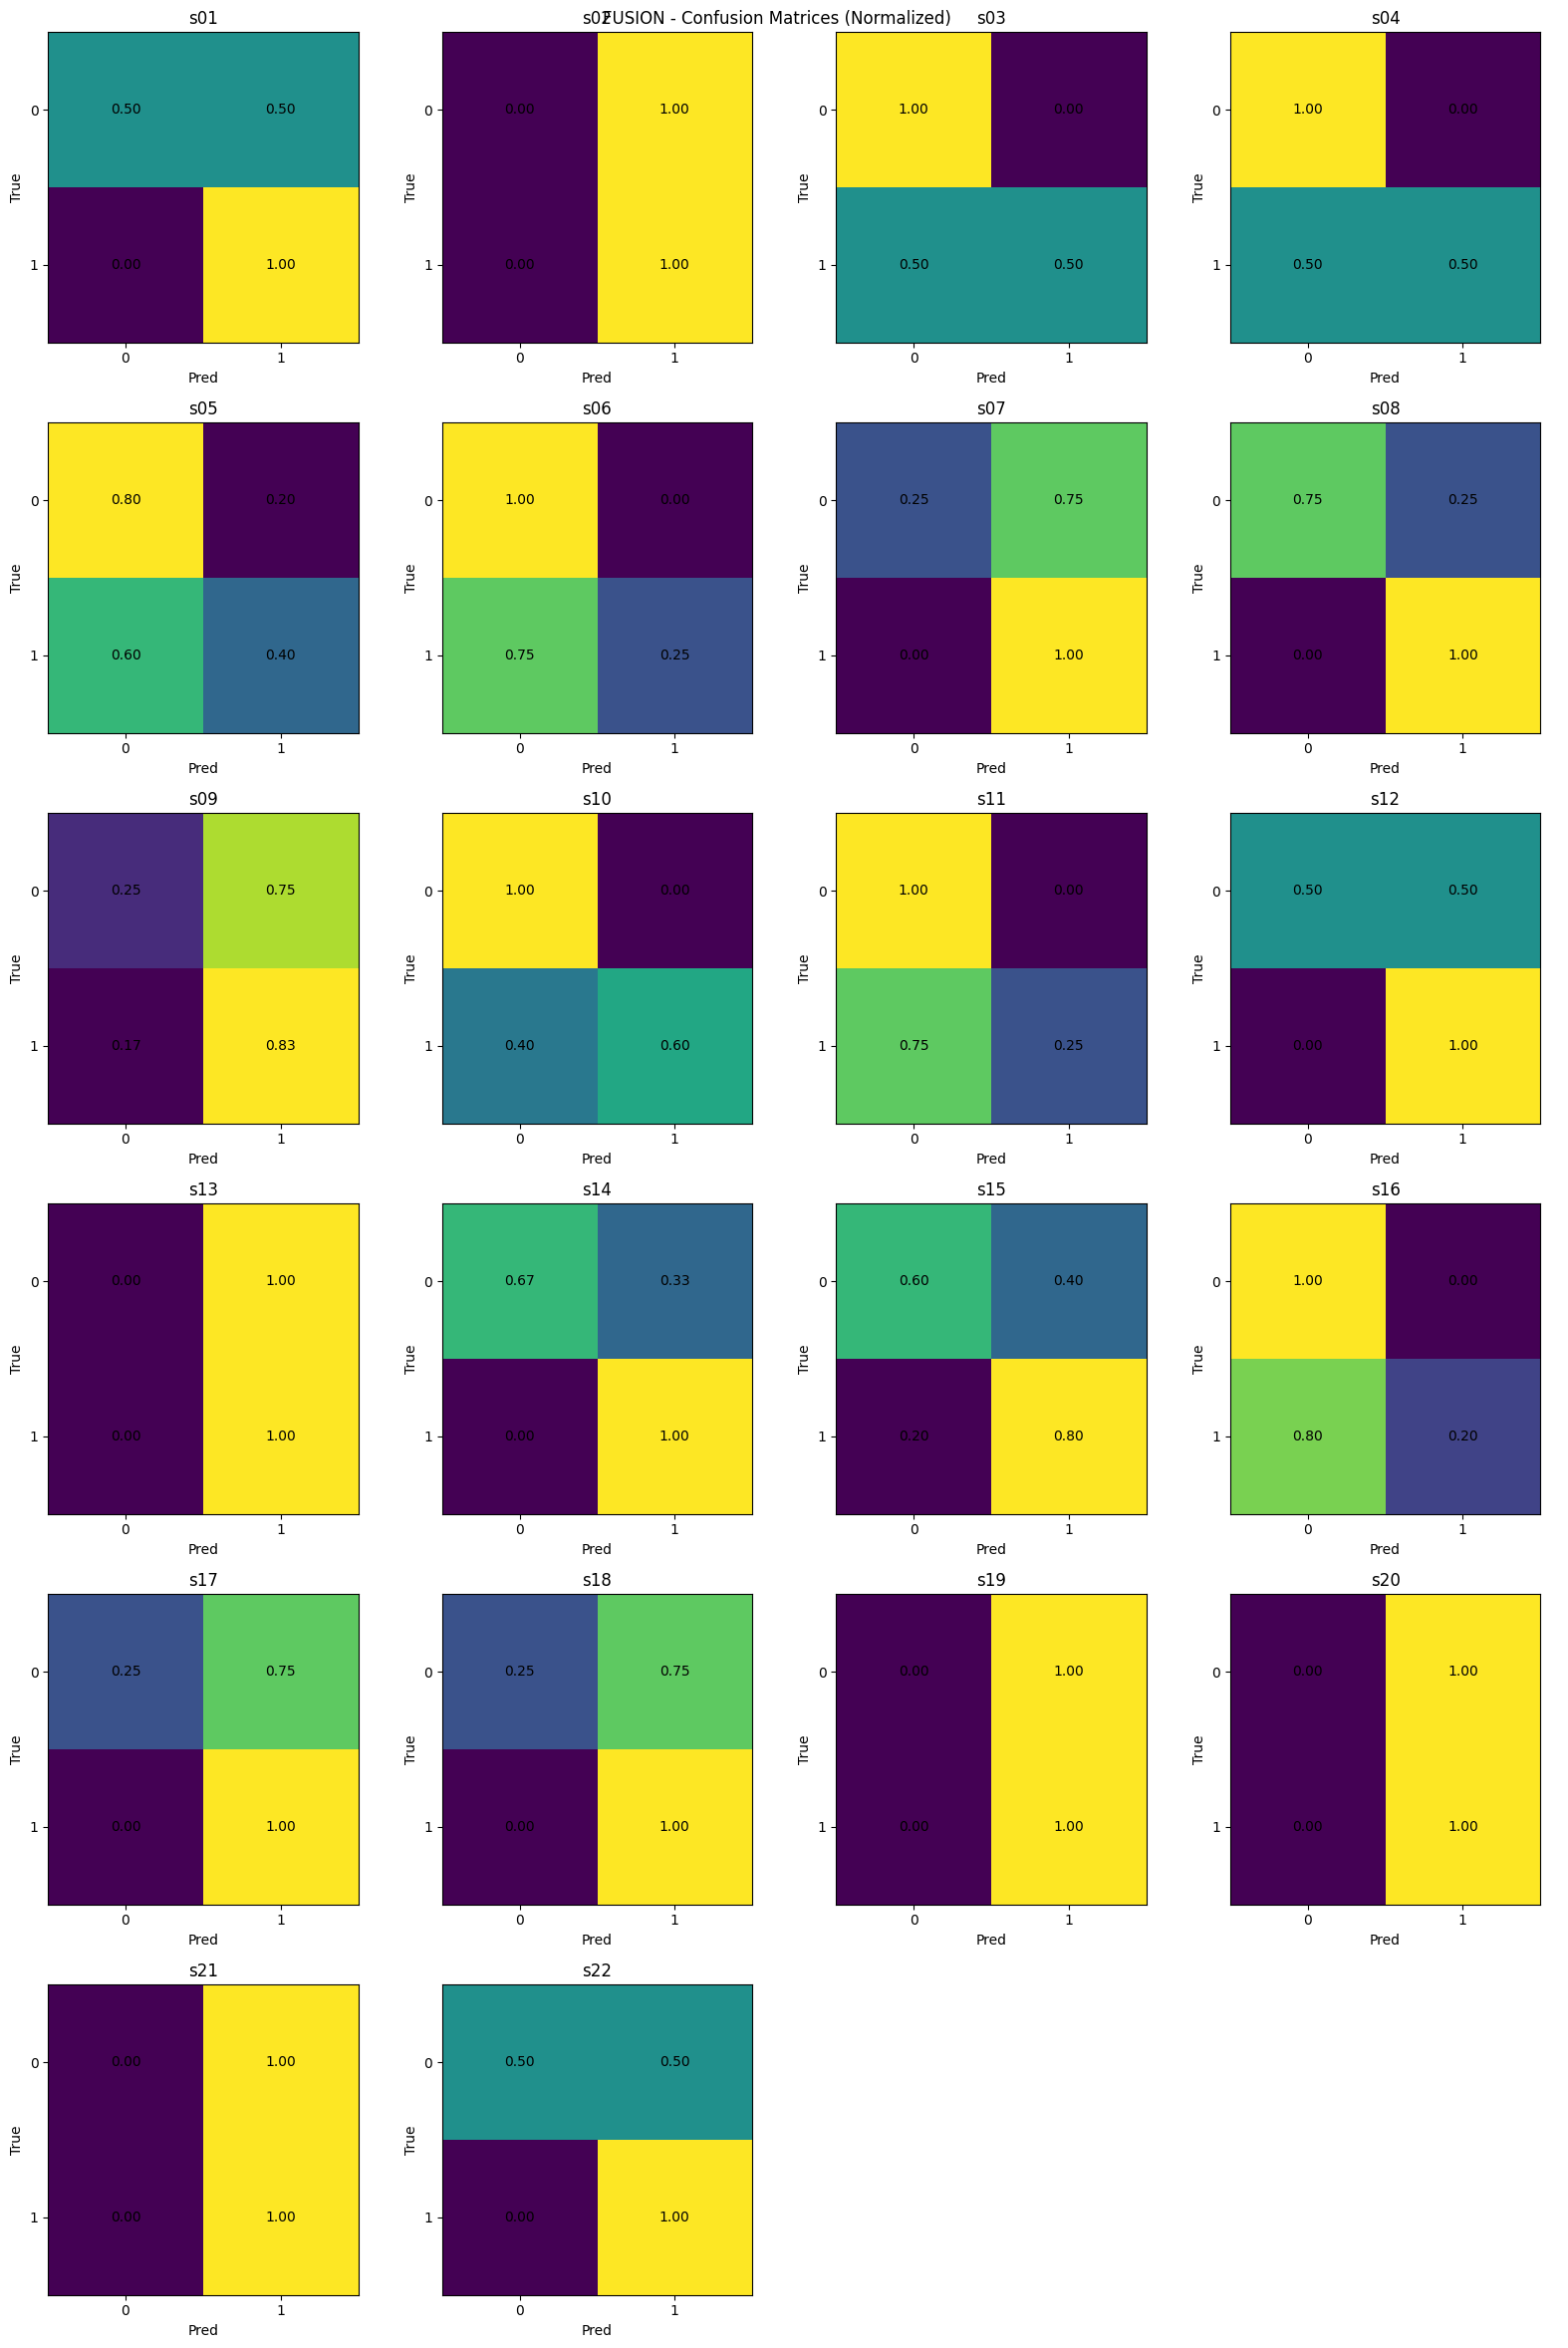

Main split FiLM trial-level stats


,split,selected_stage,sid,trial,label,pred,correct,prob_0,prob_1,loss,...,gate_mean,gate_std,gate_min,gate_max,video_norm,modulation_norm,relative_modulation,subject,model,run_type
0,val,stage1,s01,0,1,1,1,0.140387,0.859613,0.676228,...,0.197999,0.064314,0.078792,0.400503,34.484184,1.020292,0.029587,s01,FUSION,main_subject_dependent
1,val,stage1,s01,7,0,0,1,0.818686,0.181314,0.676228,...,0.307316,0.132561,0.057739,0.595527,34.729458,1.673733,0.048193,s01,FUSION,main_subject_dependent
2,val,stage1,s01,23,1,1,1,0.096833,0.903167,0.676228,...,0.181547,0.072095,0.081166,0.436682,33.613609,1.005123,0.029902,s01,FUSION,main_subject_dependent
3,val,stage1,s01,21,0,1,0,0.105216,0.894784,0.676228,...,0.208432,0.054287,0.081178,0.376564,33.870117,0.831443,0.024548,s01,FUSION,main_subject_dependent
4,val,stage1,s01,15,1,1,1,0.126225,0.873775,0.343132,...,0.162452,0.082275,0.055286,0.437838,35.803448,0.989853,0.027647,s01,FUSION,main_subject_dependent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,val,stage1,s22,3,1,1,1,0.200391,0.799609,0.809526,...,0.420094,0.176691,0.068506,0.723452,24.609240,1.762202,0.071607,s22,FUSION,main_subject_dependent
216,val,stage1,s22,27,0,1,0,0.066912,0.933088,0.809526,...,0.543296,0.237612,0.054017,0.886685,24.491816,1.761910,0.071939,s22,FUSION,main_subject_dependent
217,val,stage1,s22,15,0,0,1,0.796464,0.203536,0.809526,...,0.276408,0.091128,0.094429,0.504154,24.582041,0.911420,0.037077,s22,FUSION,main_subject_dependent
218,val,stage1,s22,24,0,0,1,0.513411,0.486589,0.727187,...,0.377787,0.150041,0.071674,0.655106,24.813807,0.431807,0.017402,s22,FUSION,main_subject_dependent


Main split FiLM summary


,metric,mean,std,min,max
0,gamma_mean,1.001086,0.001458,0.996202,1.004620
1,gamma_std,0.038140,0.026827,0.007953,0.098508
2,gamma_deviation_from_1,0.034661,0.026971,0.006270,0.097901
3,beta_mean,0.000108,0.000943,-0.003403,0.002934
4,beta_std,0.038783,0.027252,0.008015,0.098804
5,beta_abs_mean,0.035486,0.027420,0.006387,0.098337
6,gate_mean,0.194681,0.077935,0.118697,0.543296
7,gate_std,0.063779,0.042462,0.016085,0.237612
8,relative_modulation,0.017271,0.016433,0.001566,0.081890


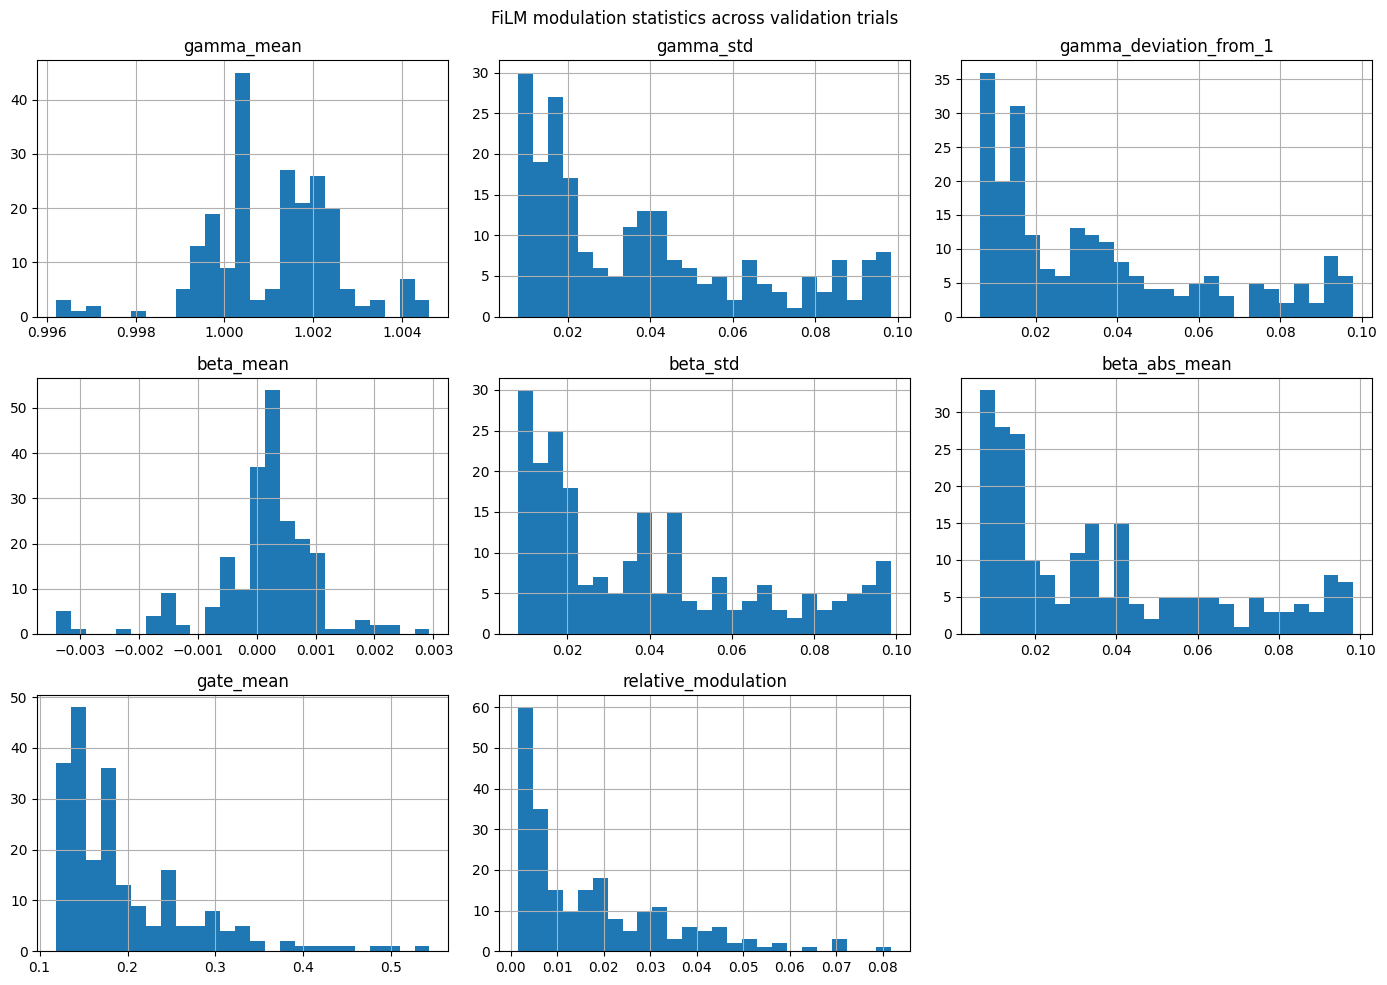

/tmp/ipykernel_2656/2276684111.py:838: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(lab) for lab in labels])


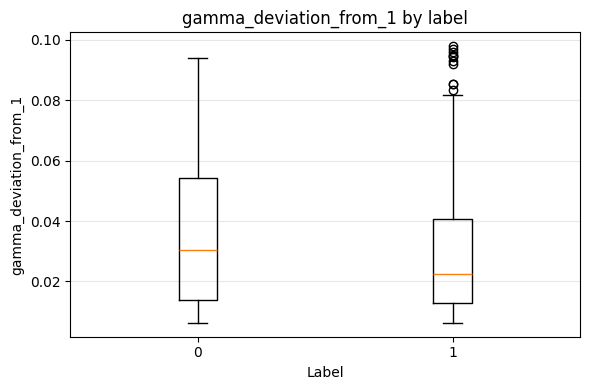

/tmp/ipykernel_2656/2276684111.py:838: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(lab) for lab in labels])


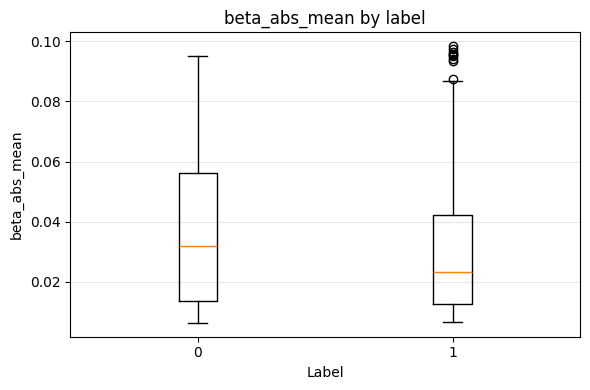

/tmp/ipykernel_2656/2276684111.py:838: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(lab) for lab in labels])


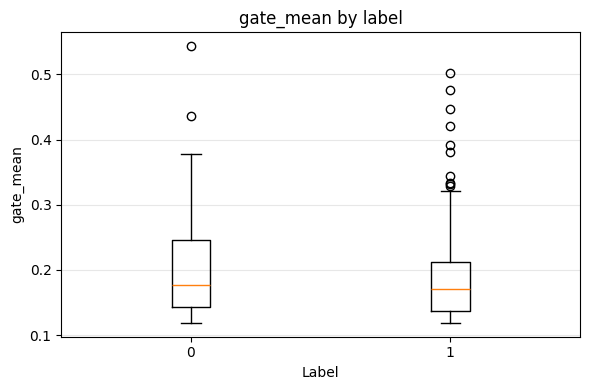

/tmp/ipykernel_2656/2276684111.py:838: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(lab) for lab in labels])


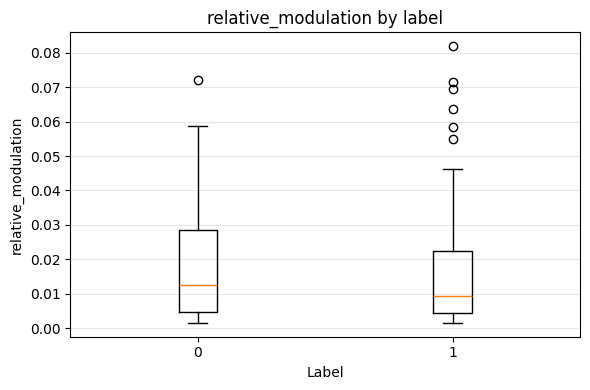

/tmp/ipykernel_2656/2276684111.py:865: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Wrong", "Correct"])


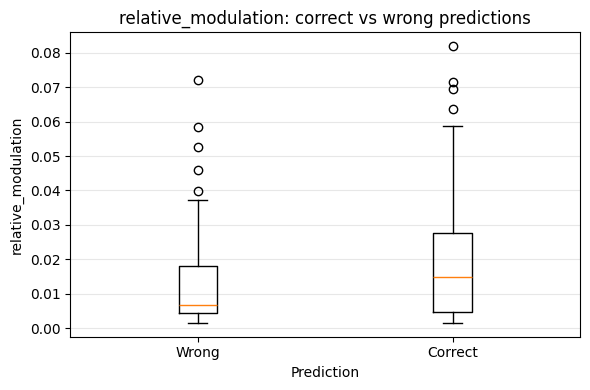

/tmp/ipykernel_2656/2276684111.py:865: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Wrong", "Correct"])


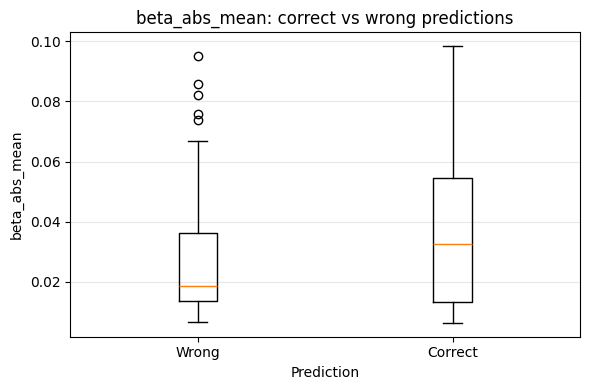

/tmp/ipykernel_2656/2276684111.py:865: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Wrong", "Correct"])


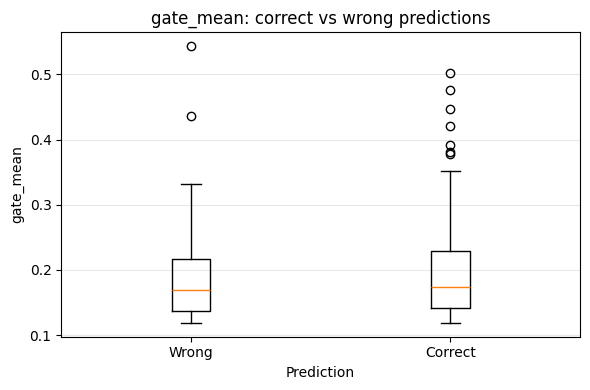

In [ ]:
# =========================================================
# 1) STANDARDIZE ALL RESULTS
# =========================================================
eeg_std = standardize_eeg_results(all_eeg_sd, model_name="EEG")
video_std = standardize_video_results(all_video_sd, model_name="VIDEO")
fusion_std = standardize_fusion_results(all_fusion_sd, model_name="FUSION")
concat_fusion_std = standardize_fusion_results(all_concat_fusion_sd, model_name="CONCAT_FUSION")
decision_fusion_std = standardize_fusion_results(all_decision_fusion_sd, model_name="DECISION_FUSION")



all_std = {
    "EEG": eeg_std,
    "VIDEO": video_std,
    "CONCAT_FUSION": concat_fusion_std,
    "DECISION_FUSION": decision_fusion_std,
    "FUSION": fusion_std,
}

# =========================================================
# 2) BUILD ALL TABLES
# =========================================================
eeg_subject_df = build_subject_metrics_table(eeg_std)
eeg_summary_df = build_summary_table(eeg_std)

video_subject_df = build_subject_metrics_table(video_std)
video_summary_df = build_summary_table(video_std)

concat_fusion_subject_df = build_subject_metrics_table(concat_fusion_std)
concat_fusion_summary_df = build_summary_table(concat_fusion_std)

decision_fusion_subject_df = build_subject_metrics_table(decision_fusion_std)
decision_fusion_summary_df = build_summary_table(decision_fusion_std)

fusion_subject_df = build_subject_metrics_table(fusion_std)
fusion_summary_df = build_summary_table(fusion_std)


print("EEG subject metrics")
display(eeg_subject_df)
print("\nEEG summary")
display(eeg_summary_df)

print("\n" + "=" * 80)
print("VIDEO subject metrics")
display(video_subject_df)
print("\nVIDEO summary")
display(video_summary_df)

print("\n" + "=" * 80)
print("CONCAT FUSION subject metrics")
display(concat_fusion_subject_df)
print("\nCONCAT FUSION summary")
display(concat_fusion_summary_df)

print("\n" + "=" * 80)
print("DECISION FUSION subject metrics")
print(decision_fusion_subject_df)
print("\nDECISION FUSION summary")
print(decision_fusion_summary_df)

print("\n" + "=" * 80)
print("FUSION subject metrics")
display(fusion_subject_df)
print("\nFUSION summary")
display(fusion_summary_df)


# =========================================================
# 3) ONE BIG COMPARISON TABLE (MEAN METRICS OF ALL MODELS)
# =========================================================
all_summary_df = pd.concat(
    [
        eeg_summary_df,
        video_summary_df,
        concat_fusion_summary_df,
        decision_fusion_summary_df,
        fusion_summary_df,
    ],
    axis=0,
    ignore_index=True
)

display(all_summary_df)

print("GLOBAL SUMMARY OF ALL MODELS")
print(all_summary_df)

# =========================================================
# 4) SAVE ALL TABLES TO CSV
# =========================================================
save_tables_to_csv(eeg_std, prefix="eeg")
save_tables_to_csv(video_std, prefix="video")
save_tables_to_csv(concat_fusion_std, prefix="concat_fusion")
save_tables_to_csv(decision_fusion_std, prefix="decision_fusion")
save_tables_to_csv(fusion_std, prefix="fusion")
# =========================================================
# 5) PLOT GLOBAL METRICS FOR EACH MODEL
# =========================================================
for name, std in all_std.items():
    print(f"\n{name} - mean curves")
    plot_mean_curves(std)

    print(f"\n{name} - best validation accuracy")
    plot_metric_bar(std, metric="best_val_acc")

    print(f"\n{name} - F1")
    plot_metric_bar(std, metric="f1")

    print(f"\n{name} - balanced accuracy")
    plot_metric_bar(std, metric="balanced_acc")

    print(f"\n{name} - metric boxplots")
    plot_metric_box(std)

    print(f"\n{name} - all confusion matrices")
    plot_all_subject_confusions(std, normalize=True)


# =========================================================
# FiLM ANALYSIS
# =========================================================
main_film_stats_df = collect_main_film_stats(all_fusion_sd)
main_film_summary_df = build_main_film_summary_table(main_film_stats_df)

print("Main split FiLM trial-level stats")
display(main_film_stats_df)

print("Main split FiLM summary")
display(main_film_summary_df)

plot_film_parameter_histograms(main_film_stats_df)

plot_film_boxplot_by_label(main_film_stats_df, "gamma_deviation_from_1")
plot_film_boxplot_by_label(main_film_stats_df, "beta_abs_mean")
plot_film_boxplot_by_label(main_film_stats_df, "gate_mean")
plot_film_boxplot_by_label(main_film_stats_df, "relative_modulation")

plot_film_boxplot_correct_vs_wrong(main_film_stats_df, "relative_modulation")
plot_film_boxplot_correct_vs_wrong(main_film_stats_df, "beta_abs_mean")
plot_film_boxplot_correct_vs_wrong(main_film_stats_df, "gate_mean")


# 10. LOSO Experiments

In [ ]:
all_eeg_loso = run_all_eeg_shared_split(
    dataset_path=DEAP_ROOT,
    image_root=IMAGE_ROOT,
    label_type=LABEL_TYPE,
    mode=2,
    max_subject_id=22,
    split_mode="loso",
    train_ratio=0.8,   # ignored by LOSO, can leave it
    seed=42,
    model_name="EEG_TR",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    verbose=1,
)


Running EEG experiment for s01 | split_mode=loso
split info: {'split_mode': 'loso', 'target_sid': 's01', 'n_total_pairs': 874, 'n_train_pairs': 834, 'n_val_pairs': 40, 'stratified': False, 'train_label_counts': {0: 376, 1: 458}, 'val_label_counts': {0: 21, 1: 19}}
EEG train dataset size: 834
EEG val dataset size: 40

Epoch 1/20
Train 0.7055/0.5180 | Val 0.6923/0.5250 | Score 0.4163
↗ New best Score 0.4163

Epoch 2/20
Train 0.6924/0.5325 | Val 0.6956/0.5000 | Score 0.4022

Epoch 3/20
Train 0.6969/0.5469 | Val 0.6993/0.4750 | Score 0.3879

Epoch 4/20
Train 0.6924/0.5397 | Val 0.7013/0.4750 | Score 0.3868

Epoch 5/20
Train 0.6911/0.5529 | Val 0.7099/0.4750 | Score 0.3825

Epoch 6/20
Train 0.6931/0.5397 | Val 0.7078/0.4750 | Score 0.3836

Epoch 7/20
Train 0.6900/0.5577 | Val 0.6949/0.4250 | Score 0.3650

Epoch 8/20
Train 0.6898/0.5421 | Val 0.7068/0.4500 | Score 0.3716

Epoch 9/20
Train 0.6882/0.5493 | Val 0.7014/0.4750 | Score 0.3868

Epoch 10/20
Train 0.6938/0.5397 | Val 0.7347/0.4750 |

In [ ]:
all_video_loso = {"subject_results": {}}

for sid_num in range(1, 23):
    sid = f"s{sid_num:02d}"
    print("\n" + "=" * 60)
    print(f"Running VIDEO LOSO for {sid}")
    print("=" * 60)

    result = run_experiment(
        deap_root=DEAP_ROOT,
        image_root=IMAGE_ROOT,
        split_mode="loso",
        target_sid=sid,
        label_type=LABEL_TYPE,
        max_subject_id=22,
        num_frames=NUM_FRAMES,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        lr=LR,
        freeze_backbone=True,
        num_workers=NUM_WORKERS,
        seed=42,
        save_path=f"video_loso_{sid}_label{LABEL_TYPE}.pth",
    )

    all_video_loso["subject_results"][sid] = {
        "best_val_acc": result["best_val_acc"],
        "last_val_acc": result["history"]["val_acc"][-1] if len(result["history"]["val_acc"]) > 0 else None,
        "save_path": result["save_path"],
        "split_info": result["split_info"],
        "history": result["history"],
        "detailed_metrics": result["detailed_metrics"],
    }

valid = [v["best_val_acc"] for v in all_video_loso["subject_results"].values()]
all_video_loso["mean_acc"] = sum(valid) / len(valid)

print("Mean VIDEO LOSO acc:", all_video_loso["mean_acc"])


Running VIDEO LOSO for s01
device: cuda
split info: {'split_mode': 'loso', 'target_sid': 's01', 'n_total_pairs': 874, 'n_train_pairs': 834, 'n_val_pairs': 40, 'stratified': False, 'train_label_counts': {0: 376, 1: 458}, 'val_label_counts': {0: 21, 1: 19}}
train dataset size: 834
val dataset size: 40
Epoch [1/20] | Train Loss: 0.7492 | Train Acc: 0.5168 | Val Loss: 0.7511 | Val Acc: 0.4750
Epoch [2/20] | Train Loss: 0.7221 | Train Acc: 0.5504 | Val Loss: 0.7369 | Val Acc: 0.5250
Epoch [3/20] | Train Loss: 0.6714 | Train Acc: 0.5875 | Val Loss: 0.7094 | Val Acc: 0.5250
Epoch [4/20] | Train Loss: 0.6558 | Train Acc: 0.6307 | Val Loss: 0.7358 | Val Acc: 0.5250
Epoch [5/20] | Train Loss: 0.6569 | Train Acc: 0.6055 | Val Loss: 0.7718 | Val Acc: 0.5250
Epoch [6/20] | Train Loss: 0.6389 | Train Acc: 0.6331 | Val Loss: 0.7587 | Val Acc: 0.5250
Epoch [7/20] | Train Loss: 0.6461 | Train Acc: 0.6475 | Val Loss: 0.7257 | Val Acc: 0.4000
Epoch [8/20] | Train Loss: 0.6264 | Train Acc: 0.6463 | Val L

In [ ]:
all_fusion_loso = run_all_fusion_shared_split(
    eeg_root=DEAP_ROOT,
    image_root=IMAGE_ROOT,

    eeg_results=all_eeg_loso,
    video_results=all_video_loso,

    label_type=LABEL_TYPE,
    eeg_mode=2,
    max_subject_id=22,
    split_mode="loso",

    train_ratio=0.8,   # ignored by LOSO
    seed=42,

    num_frames=NUM_FRAMES,
    batch_size=BATCH_SIZE,

    stage1_epochs=10,
    stage2_epochs=5,
    stage1_lr=1e-3,
    stage2_head_lr=1e-4,
    stage2_encoder_lr=5e-6,
    weight_decay=WEIGHT_DECAY,
)

print(all_fusion_loso["mean_best_acc"])

# 11. LOSO Results and Visualization

In [ ]:
# =========================
# 11.1 Standardize LOSO results
# =========================

eeg_loso_std = standardize_eeg_results(
    all_eeg_loso,
    model_name="EEG_LOSO"
)

video_loso_std = standardize_video_results(
    all_video_loso,
    model_name="VIDEO_LOSO"
)

fusion_loso_std = standardize_fusion_results(
    all_fusion_loso,
    model_name="FUSION_LOSO"
)

print("LOSO results standardized.")
print("EEG subjects:", len(eeg_loso_std["subject_results"]))
print("VIDEO subjects:", len(video_loso_std["subject_results"]))
print("FUSION subjects:", len(fusion_loso_std["subject_results"]))

In [ ]:
# =========================
# 11.2 LOSO subject-level metric tables
# =========================

eeg_loso_df = build_subject_metrics_table(eeg_loso_std)
video_loso_df = build_subject_metrics_table(video_loso_std)
fusion_loso_df = build_subject_metrics_table(fusion_loso_std)

print("EEG LOSO subject metrics")
display(eeg_loso_df)

print("VIDEO LOSO subject metrics")
display(video_loso_df)

print("FUSION LOSO subject metrics")
display(fusion_loso_df)

In [ ]:
# =========================
# 11.3 LOSO summary tables
# =========================

eeg_loso_summary = build_summary_table(eeg_loso_std)
video_loso_summary = build_summary_table(video_loso_std)
fusion_loso_summary = build_summary_table(fusion_loso_std)

print("EEG LOSO summary")
display(eeg_loso_summary)

print("VIDEO LOSO summary")
display(video_loso_summary)

print("FUSION LOSO summary")
display(fusion_loso_summary)

loso_global_summary = pd.concat(
    [eeg_loso_summary, video_loso_summary, fusion_loso_summary],
    ignore_index=True
)

print("GLOBAL LOSO SUMMARY")
display(loso_global_summary)

In [ ]:
# =========================
# 11.4 LOSO global comparison plot
# =========================

plot_df = loso_global_summary.copy()

metric = "acc_mean"

plt.figure(figsize=(7, 4))
plt.bar(plot_df["model_name"], plot_df[metric])
plt.title(f"LOSO comparison - {metric}")
plt.ylabel(metric)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
# =========================
# 11.5 LOSO subject-level comparison
# =========================

def make_loso_subject_comparison(eeg_df, video_df, fusion_df):
    cols = ["subject", "acc", "balanced_acc", "f1", "best_val_acc"]

    eeg_small = eeg_df[cols].rename(columns={
        "acc": "eeg_acc",
        "balanced_acc": "eeg_balanced_acc",
        "f1": "eeg_f1",
        "best_val_acc": "eeg_best_val_acc",
    })

    video_small = video_df[cols].rename(columns={
        "acc": "video_acc",
        "balanced_acc": "video_balanced_acc",
        "f1": "video_f1",
        "best_val_acc": "video_best_val_acc",
    })

    fusion_small = fusion_df[cols].rename(columns={
        "acc": "fusion_acc",
        "balanced_acc": "fusion_balanced_acc",
        "f1": "fusion_f1",
        "best_val_acc": "fusion_best_val_acc",
    })

    df = (
        eeg_small
        .merge(video_small, on="subject", how="outer")
        .merge(fusion_small, on="subject", how="outer")
        .sort_values("subject")
        .reset_index(drop=True)
    )

    df["fusion_gain_vs_eeg"] = df["fusion_acc"] - df["eeg_acc"]
    df["fusion_gain_vs_video"] = df["fusion_acc"] - df["video_acc"]

    return df


loso_subject_comparison = make_loso_subject_comparison(
    eeg_loso_df,
    video_loso_df,
    fusion_loso_df
)

display(loso_subject_comparison)

In [ ]:
# =========================
# 11.6 LOSO subject-level accuracy plot
# =========================

plt.figure(figsize=(12, 5))

plt.plot(
    loso_subject_comparison["subject"],
    loso_subject_comparison["eeg_acc"],
    marker="o",
    label="EEG LOSO"
)

plt.plot(
    loso_subject_comparison["subject"],
    loso_subject_comparison["video_acc"],
    marker="o",
    label="VIDEO LOSO"
)

plt.plot(
    loso_subject_comparison["subject"],
    loso_subject_comparison["fusion_acc"],
    marker="o",
    label="FUSION LOSO"
)

plt.title("LOSO accuracy per left-out subject")
plt.xlabel("Left-out subject")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# =========================
# 11.7 LOSO fusion gain plot
# =========================

gain_df = loso_subject_comparison[[
    "subject",
    "fusion_gain_vs_eeg",
    "fusion_gain_vs_video"
]].copy()

gain_df.plot(
    x="subject",
    y=["fusion_gain_vs_eeg", "fusion_gain_vs_video"],
    kind="bar",
    figsize=(12, 5)
)

plt.axhline(0, linestyle="--")
plt.title("LOSO fusion gain over unimodal models")
plt.xlabel("Left-out subject")
plt.ylabel("Accuracy gain")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
# =========================
# 11.8 LOSO confusion matrices
# =========================

plot_all_confusion_matrices(eeg_loso_std, normalize=True)
plot_all_confusion_matrices(video_loso_std, normalize=True)
plot_all_confusion_matrices(fusion_loso_std, normalize=True)

In [ ]:
# =========================
# 11.9 Export LOSO tables
# =========================

save_tables_to_csv(eeg_loso_std, out_dir="metrics_exports_loso", prefix="eeg_loso")
save_tables_to_csv(video_loso_std, out_dir="metrics_exports_loso", prefix="video_loso")
save_tables_to_csv(fusion_loso_std, out_dir="metrics_exports_loso", prefix="fusion_loso")

loso_subject_comparison.to_csv(
    "metrics_exports_loso/loso_subject_comparison.csv",
    index=False
)

loso_global_summary.to_csv(
    "metrics_exports_loso/loso_global_summary.csv",
    index=False
)

print("LOSO exports saved.")

#SAVE

In [ ]:
!find /content -type f -name "*.pth" > /content/pth_list.txt
!zip -@ /content/all_pth_files.zip < /content/pth_list.txt

  adding: content/fusion_loso_s10_stage2_label0.pth (deflated 7%)
  adding: content/video_loso_s18_label0.pth (deflated 7%)
  adding: content/fusion_loso_s02_stage2_label0.pth (deflated 7%)
  adding: content/fusion_loso_s19_stage2_label0.pth (deflated 7%)
  adding: content/fusion_subject_dependent_s17_stage2_label0.pth (deflated 7%)
  adding: content/fusion_film_stage1_s01_label0.pth (deflated 7%)
  adding: content/video_loso_s12_label0.pth (deflated 7%)
  adding: content/fusion_subject_dependent_s22_stage1_label0.pth (deflated 7%)
  adding: content/best_resnet18_subject_dependent_s01_label0.pth (deflated 7%)
  adding: content/fusion_loso_s06_stage1_label0.pth (deflated 7%)
  adding: content/fusion_subject_dependent_s01_stage2_label0.pth (deflated 7%)
  adding: content/best_resnet18_subject_dependent_s04_label0.pth (deflated 7%)
  adding: content/best_resnet18_subject_dependent_s20_label0.pth (deflated 7%)
  adding: content/fusion_subject_dependent_s14_stage1_label0.pth (deflated 7%)
 

In [ ]:
from google.colab import files
files.download('/content/all_pth_files.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>